In [1]:
!service mysql start

mysql: unrecognized service


In [3]:
!mysql -u root -e "CREATE DATABASE IF NOT EXISTS agriculture;"

/bin/bash: line 1: mysql: command not found


In [4]:
# INSTALLATION + MYSQL
!pip install mysql-connector-python > /dev/null
!apt-get update -y > /dev/null
!DEBIAN_FRONTEND=noninteractive apt-get install -y mysql-server > /dev/null

!service mysql start

# UPLOAD DU FICHIER SQL
from google.colab import files
uploaded = files.upload()

sql_file = list(uploaded.keys())[0]
print("Fichier uploadé :", sql_file)

# CONFIG MYSQL
!mysql -u root -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY ''; FLUSH PRIVILEGES;"

# CRÉER LA BASE SI ELLE N'EXISTE PAS
!mysql -u root -e "CREATE DATABASE IF NOT EXISTS agriculture;"

# IMPORT SQL
!mysql -u root agriculture < "$sql_file"

# VÉRIFICATION
!mysql -u root -e "USE agriculture; SHOW TABLES;"

# CONNEXION PYTHON
import mysql.connector

bdd = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="agriculture"
)

print("Connexion SQL OK")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.


Saving agriculture(1).sql to agriculture(1).sql
Fichier uploadé : agriculture(1).sql
+------------------------+
| Tables_in_agriculture  |
+------------------------+
| adapter                |
| contrainte_temperature |
| culture                |
| releve_meteo           |
| saisonnalite           |
| station_meteo          |
| type_sol               |
| villes                 |
+------------------------+
Connexion SQL OK


In [5]:
import pandas as pd
query = "SELECT COUNT(*) AS nb FROM releve_meteo"
test = pd.read_sql(query, bdd)
print(test)

       nb
0  403166


/tmp/ipykernel_8147/4133299999.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test = pd.read_sql(query, bdd)


In [6]:
releve_meteo = pd.read_sql("SELECT * FROM releve_meteo", bdd)

/tmp/ipykernel_8147/4072650513.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql("SELECT * FROM releve_meteo", bdd)


In [7]:
!pip install xgboost
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install mysql-connector-python
!pip install LSTM
!pip install Dense
!pip install Dropout
!pip install tensorflow
!pip install Sequential

ERROR: Could not find a version that satisfies the requirement Dropout (from versions: none)
ERROR: No matching distribution found for Dropout
  Preparing metadata (setup.py) ... done
  Created wheel for Sequential: filename=sequential-1.0.0-py3-none-any.whl size=2859 sha256=c2d900cf4395e02504eea8e0f20b1b17a8396c0b02b6da3d944a099fe3b38219
  Stored in directory: /root/.cache/pip/wheels/28/64/8e/2c7383cdc8c9fb6678c1f227b993501ab459cde4fc7770b863
Successfully built Sequential


# Analyse des relations entre variables

Avant de construire des modèles de prédiction, nous étudions les relations entre les variables météorologiques.

## régression linéaire simple



Afin de mieux comprendre l’influence des variables météorologiques sur la température, nous réalisons plusieurs régressions linéaires simples.

Chaque modèle utilise une seule variable explicative :
- humidité
- point de rosée
- température minimale du sol
- précipitations

L’objectif est d’identifier quelles variables expliquent le mieux la température.


-----------------------------
Variable explicative : humidite
Coefficient : -0.2348387826234485
Intercept : 304.6501931448168
MSE : 42.02855760202253
R² : 0.285377845888804

-----------------------------
Variable explicative : point_de_rose
Coefficient : 1.0206738706643157
Intercept : -1.384224379988325
MSE : 18.333938831411917
R² : 0.6882634187661012

-----------------------------
Variable explicative : temperature_min_sol_12h
Coefficient : 0.9388473299869234
Intercept : 20.305617758560345
MSE : 18.741493553581925
R² : 0.6813336631405762

-----------------------------
Variable explicative : precipitations_dernieres_24h
Coefficient : 0.029541717476252356
Intercept : 286.4291631414743
MSE : 58.77222074710424
R² : 0.0006811228236581757


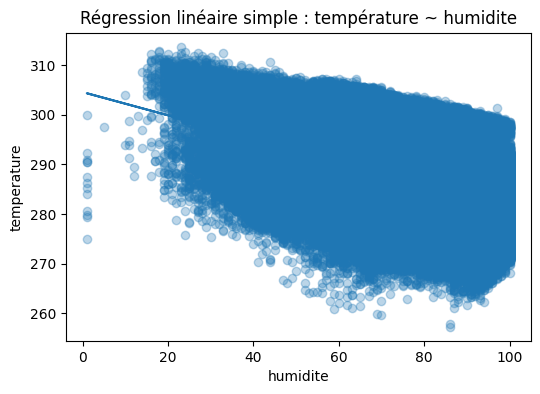

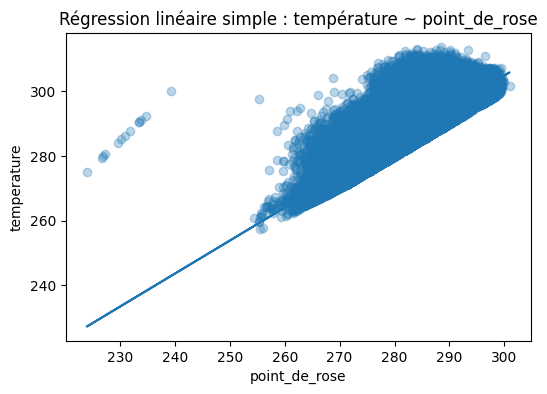

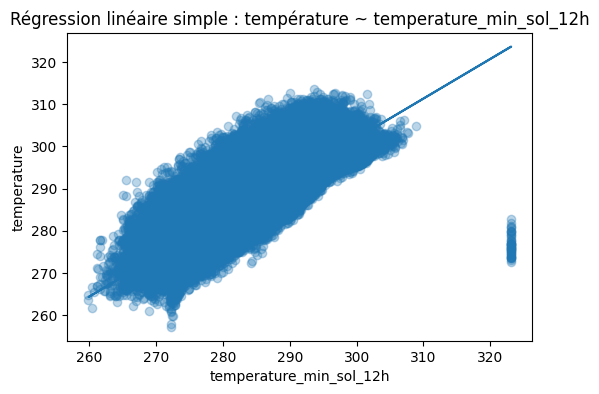

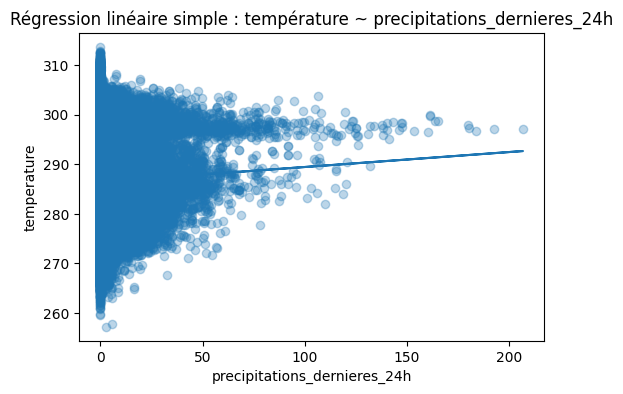

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# garder les colonnes utiles
df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

# variables explicatives
variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

for var in variables:

    X = df[[var]]
    y = df['temperature']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n-----------------------------")
    print("Variable explicative :", var)
    print("Coefficient :", model.coef_[0])
    print("Intercept :", model.intercept_)
    print("MSE :", mean_squared_error(y_test, pred))
    print("R² :", r2_score(y_test, pred))

    import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

for var in variables:

    X = df[[var]]
    y = df['temperature']

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    plt.figure(figsize=(6,4))

    plt.scatter(X, y, alpha=0.3)

    # droite de régression
    plt.plot(X, y_pred)

    plt.xlabel(var)
    plt.ylabel("temperature")

    plt.title(f"Régression linéaire simple : température ~ {var}")

    plt.show()



In [ ]:

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# garder les colonnes utiles
df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

# variables explicatives
variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

for var in variables:

    X = df[[var]]
    y = df['temperature']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n-----------------------------")
    print("Variable explicative :", var)
    print("Coefficient :", model.coef_[0])
    print("Intercept :", model.intercept_)
    print("MSE :", mean_squared_error(y_test, pred))
    print("R² :", r2_score(y_test, pred))

    import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

resultats_lr = []

for var in variables:

    X = df[[var]]
    y = df['temperature']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    resultats_lr.append({
        "Variable": var,
        "Coefficient": model.coef_[0],
        "Intercept": model.intercept_,
        "MSE": mean_squared_error(y_test, pred),
        "R²": r2_score(y_test, pred)
    })

df_lr = pd.DataFrame(resultats_lr)
df_lr.sort_values("R²", ascending=False)


-----------------------------
Variable explicative : humidite
Coefficient : -0.2348387826234485
Intercept : 304.6501931448168
MSE : 42.02855760202253
R² : 0.285377845888804

-----------------------------
Variable explicative : point_de_rose
Coefficient : 1.0206738706643157
Intercept : -1.384224379988325
MSE : 18.333938831411917
R² : 0.6882634187661012

-----------------------------
Variable explicative : temperature_min_sol_12h
Coefficient : 0.9388473299869234
Intercept : 20.305617758560345
MSE : 18.741493553581925
R² : 0.6813336631405762

-----------------------------
Variable explicative : precipitations_dernieres_24h
Coefficient : 0.029541717476252356
Intercept : 286.4291631414743
MSE : 58.77222074710424
R² : 0.0006811228236581757


,Variable,Coefficient,Intercept,MSE,R²
1,point_de_rose,1.020674,-1.384224,18.333939,0.688263
2,temperature_min_sol_12h,0.938847,20.305618,18.741494,0.681334
0,humidite,-0.234839,304.650193,42.028558,0.285378
3,precipitations_dernieres_24h,0.029542,286.429163,58.772221,0.000681


Les résultats montrent que certaines variables expliquent bien la température, notamment le point de rosée et la température minimale du sol (R² ≈ 0.68), ce qui indique une forte relation linéaire. À l’inverse, l’humidité a un pouvoir explicatif modéré (R² ≈ 0.30) et les précipitations n’apportent quasiment aucune information (R² ≈ 0).

Cela signifie que la température dépend de plusieurs facteurs, mais qu’aucune variable seule ne suffit pour une prédiction précise.

 Cette analyse nous permet d’identifier les variables pertinentes à intégrer dans des modèles plus avancés.

Dans la suite, nous allons utiliser des modèles de prédiction plus performants (Random Forest, SARIMA, SARIMAX) capables de :
- combiner plusieurs variables,
- capturer des relations non linéaires,
- et prendre en compte la dimension temporelle.

# Modèle de prédiction avec variables explicatives

## Régression linéaire multiple

Afin d’améliorer la prédiction de la température, nous utilisons une régression linéaire multiple en combinant plusieurs variables météorologiques :

- humidité
- point de rosée
- température minimale du sol
- précipitations

Contrairement aux modèles précédents utilisant une seule variable, ce modèle permet de capturer les effets combinés de plusieurs facteurs.

L’objectif est d’évaluer si l’intégration de plusieurs variables améliore significativement la qualité des prédictions.

/tmp/ipykernel_2754/1462256906.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== Régression linéaire (en °C) ===
MAE : 0.2359768644137453 °C
MSE : 0.07268249359852637
RMSE : 0.26959690947510206 °C
R² : 0.9877919986798545
Coefficients : [-0.23809274  0.99812749  0.02263156 -0.0164501 ]
Intercept : 22.697915678107663


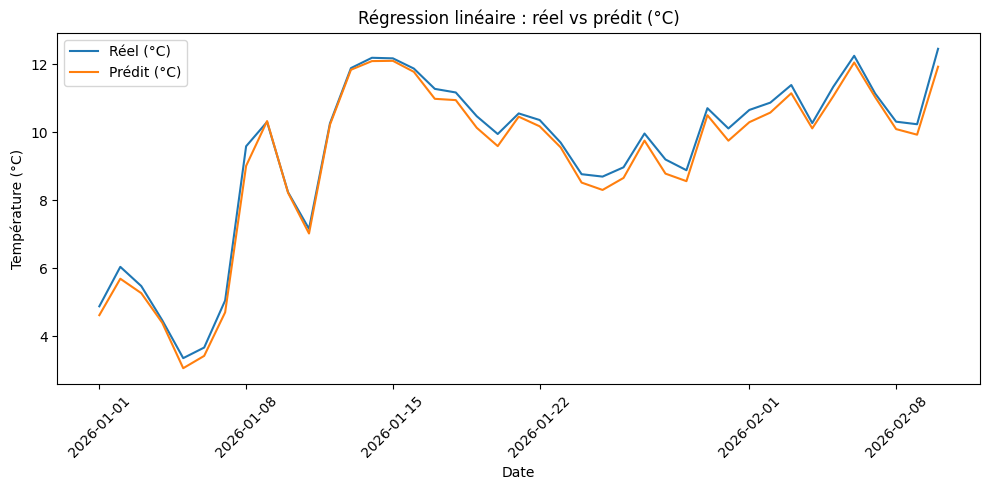

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# CHARGER LES DONNÉES
query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# PRÉPARATION
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'], dayfirst=True)

train = train.sort_values('date')
test = test.sort_values('date')

# CONVERSION EN °C
def kelvin_to_celsius(df):
    df['temperature'] = df['temperature'] - 273.15
    df['point_de_rose'] = df['point_de_rose'] - 273.15
    df['temperature_min_sol_12h'] = df['temperature_min_sol_12h'] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

# Agrégation journalière
cols = [
    'temperature',
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

train = train.groupby('date')[cols].mean()
test = test.groupby('date')[cols].mean()

# Fréquence journalière
train = train.asfreq('D').interpolate()
test = test.asfreq('D').interpolate()

# VARIABLES
features = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

X_train = train[features]
y_train = train['temperature']

X_test = test[features]
y_test = test['temperature']

# MODÈLE
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

# ÉVALUATION
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Régression linéaire (en °C) ===")
print("MAE :", mae_lr, "°C")
print("MSE :", mse_lr)
print("RMSE :", rmse_lr, "°C")
print("R² :", r2_lr)

print("Coefficients :", model_lr.coef_)
print("Intercept :", model_lr.intercept_)

# GRAPHIQUE
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values, label="Réel (°C)")
plt.plot(y_test.index, y_pred_lr, label="Prédit (°C)")

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Régression linéaire : réel vs prédit (°C)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les résultats montrent d’excellentes performances du modèle (R² ≈ 0.99 et RMSE très faible), ce qui indique que les variables explicatives combinées permettent de prédire efficacement la température.

Le graphique confirme que les valeurs prédites suivent très bien les valeurs réelles, avec peu d’écart entre les deux courbes.

Les variables les plus influentes sont le point de rosée et la température du sol, ce qui est cohérent d’un point de vue physique.

Cependant, ce modèle ne prend pas en compte la dimension temporelle des données, ce qui peut limiter sa capacité à généraliser dans le temps.

Dans le cadre du projet agricole, ce modèle est déjà performant, mais nous allons tester des modèles plus avancés (SARIMAX et Random Forest) afin de comparer les performances et identifier le modèle le plus robuste pour la prédiction future.

## Random Forest

Après avoir testé la régression linéaire, nous cherchons à améliorer la modélisation en utilisant un modèle plus flexible.

Le Random Forest est un modèle non linéaire basé sur un ensemble d’arbres de décision. Il permet de capturer des relations complexes entre les variables météorologiques et la température, contrairement à la régression linéaire.

L’objectif est de vérifier si ce modèle améliore la qualité des prédictions dans le cadre de notre projet agricole.

=== Random Forest ===
MAE : 0.39104562910203117
MSE : 0.3845824807874045
RMSE : 0.6201471444644444
R² : 0.9354042053222473


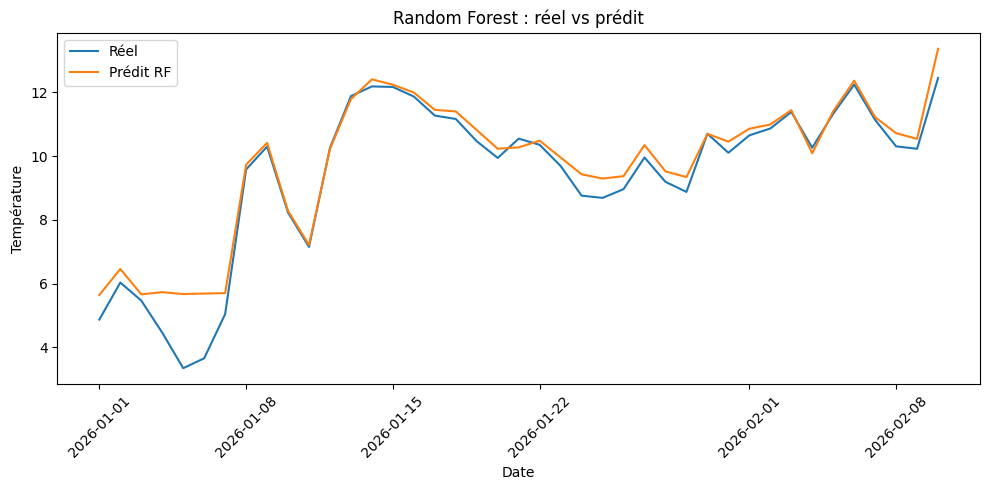

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(y_test.index, y_pred_rf, label="Prédit RF")
plt.xlabel("Date")
plt.ylabel("Température")
plt.title("Random Forest : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle Random Forest obtient de bonnes performances (R² ≈ 0.93), ce qui montre qu’il est capable de bien capturer les relations entre les variables et la température.

Le graphique indique que les prédictions suivent globalement les valeurs réelles, avec une meilleure adaptation aux variations que certains modèles plus simples.

Cependant, on observe quelques écarts, notamment sur certains pics, ce qui montre que le modèle reste imparfait.

Comparé à la régression linéaire multiple, les performances sont légèrement inférieures, mais le modèle est plus robuste face aux relations non linéaires.

Dans le cadre du projet agricole, ce modèle est intéressant car il capte des effets complexes, mais il doit être comparé aux modèles de séries temporelles.

Nous allons donc poursuivre avec un modèle temporel (SARIMAX) afin de déterminer lequel est le plus performant pour la prédiction finale.

## SARIMAX

Le modèle SARIMAX est une extension du modèle SARIMA qui intègre des variables explicatives (exogènes).

Il permet de combiner :
- la dynamique temporelle de la température,
- la saisonnalité,
- et l’influence des variables météorologiques (humidité, point de rosée, température du sol, etc.).

L’objectif est d’obtenir un modèle complet, adapté à la complexité des données climatiques dans le cadre du projet agricole.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== SARIMAX ===
MAE : 0.13359981634734877
MSE : 0.025979081198514564
RMSE : 0.161180275463577
R² : 0.9956364642726834


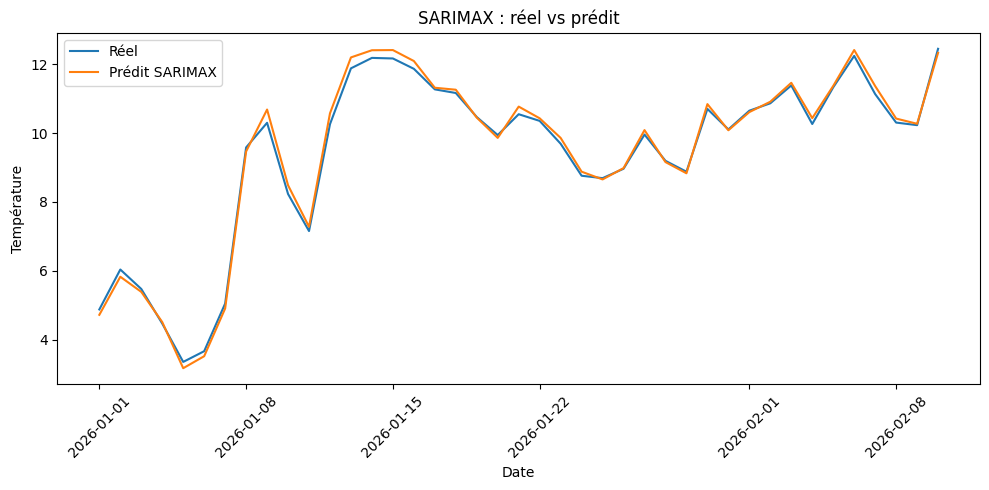

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

results_sarimax = model_sarimax.fit(disp=False)

y_pred_sarimax = results_sarimax.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
mse_sarimax = mean_squared_error(y_test, y_pred_sarimax)
rmse_sarimax = np.sqrt(mse_sarimax)
r2_sarimax = r2_score(y_test, y_pred_sarimax)

print("=== SARIMAX ===")
print("MAE :", mae_sarimax)
print("MSE :", mse_sarimax)
print("RMSE :", rmse_sarimax)
print("R² :", r2_sarimax)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(y_test.index, y_pred_sarimax, label="Prédit SARIMAX")
plt.xlabel("Date")
plt.ylabel("Température")
plt.title("SARIMAX : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle SARIMAX présente de très bonnes performances (R² élevé et RMSE faible), ce qui indique une forte précision des prédictions.

Le graphique montre que les valeurs prédites suivent de très près les valeurs réelles, y compris lors des variations de température.

SARIMAX prend en compte à la fois la dimension temporelle et les variables explicatives, ce qui permet de mieux capturer la complexité des données.

Cela suggère que l’intégration de variables météorologiques améliore significativement la qualité de la modélisation.

Dans le cadre du projet agricole, ce type de modèle permet de mieux représenter les facteurs influençant la température.

Une comparaison globale avec les autres modèles sera réalisée afin d’identifier le modèle le plus performant.

## Comparaison des modèles

In [ ]:
resultats = pd.DataFrame({
    "Modele": ["Régression linéaire", "Random Forest", "SARIMAX"],
    "MAE": [mae_lr, mae_rf, mae_sarimax],
    "MSE": [mse_lr, mse_rf, mse_sarimax],
    "RMSE": [rmse_lr, rmse_rf, rmse_sarimax],
    "R2": [r2_lr, r2_rf, r2_sarimax]
})

print(resultats)

                Modele       MAE       MSE      RMSE        R2
0  Régression linéaire  0.235977  0.072682  0.269597  0.987792
1        Random Forest  0.391046  0.384582  0.620147  0.935404
2              SARIMAX  0.133600  0.025979  0.161180  0.995636


Les résultats montrent des différences significatives entre les modèles.

La régression linéaire multiple présente de bonnes performances, indiquant que les variables explicatives permettent déjà de bien modéliser la température.

Le modèle Random Forest obtient également des résultats solides, confirmant sa capacité à capturer des relations non linéaires.

Le modèle SARIMAX présente les erreurs les plus faibles (MAE, RMSE) ainsi que le R² le plus élevé, ce qui traduit une très bonne qualité de prédiction.

Au vu des résultats obtenus, le modèle SARIMAX présente les meilleures performances globales (faibles erreurs et R² élevé).

Nous retenons donc ce modèle comme base de travail pour la suite de l’analyse.

Nous allons maintenant chercher à améliorer ses performances en ajustant ses paramètres (p, d, q, composantes saisonnières et variables explicatives), afin d’optimiser la qualité des prédictions dans le cadre du projet agricole.

## Amélioration SARIMAX



Les données sont prétraitées afin de construire une série temporelle journalière cohérente. Les variables explicatives (humidité, point de rosée, température du sol et précipitations) sont séparées de la variable cible (température), permettant l’utilisation d’un modèle SARIMAX intégrant des informations météorologiques complémentaires pour améliorer la prédiction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

query = """
SELECT date,
       temperature,
       humidite,
       point_de_rose,
       temperature_min_sol_12h,
       precipitations_dernieres_24h
FROM releve_meteo
"""
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# Conversion Kelvin -> Celsius
def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    df["point_de_rose"] = df["point_de_rose"] - 273.15
    df["temperature_min_sol_12h"] = df["temperature_min_sol_12h"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

cols = [
    "temperature",
    "humidite",
    "point_de_rose",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

train = train.groupby("date")[cols].mean()
test = test.groupby("date")[cols].mean()

train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

train = train.dropna()
test = test.dropna()

features = [
    "humidite",
    "point_de_rose",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

X_train = train[features]
y_train = train["temperature"]

X_test = test[features]
y_test = test["temperature"]

print("Taille train :", train.shape)
print("Taille test :", test.shape)
print("Période test :", y_test.index.min(), "->", y_test.index.max())

/tmp/ipykernel_22536/2035899537.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


Taille train : (1461, 5)
Taille test : (41, 5)
Période test : 2026-01-01 00:00:00 -> 2026-02-10 00:00:00


### Configuration SARIMAX

Afin d’identifier une configuration adaptée du modèle SARIMA, plusieurs combinaisons
des paramètres (p, d, q) et des paramètres saisonniers (P, D, Q, s) ont été testées.

Les valeurs choisies restent volontairement modestes afin de limiter la complexité du
modèle tout en capturant les dépendances temporelles de court terme. Une différenciation
d’ordre 1 (d=1) a été retenue afin de traiter la non-stationnarité potentielle de la série
temporelle.

Deux cas ont été comparés :
- un modèle sans saisonnalité,
- un modèle avec une saisonnalité hebdomadaire (s = 7) pour les données journalières
  (ou s = 52 dans le cas d’une agrégation hebdomadaire).

Chaque configuration a été évaluée à l’aide de plusieurs métriques :
- MAE (erreur absolue moyenne),
- MSE (erreur quadratique moyenne),
- RMSE (racine du MSE),
- R² (coefficient de détermination).

La meilleure configuration a ensuite été retenue en fonction du plus faible RMSE,
car cette métrique permet d’interpréter directement l’erreur dans l’unité de la température.
"""

In [ ]:
def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

orders = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2),
    (3, 1, 1)
]

seasonal_orders = [
    (0, 0, 0, 0),   # sans saisonnalité
    (1, 1, 1, 7)    # saisonnalité hebdomadaire
]

liste_resultats = []
meilleur_modele = None
meilleur_resultat_fit = None
meilleure_prediction = None
meilleur_rmse = float("inf")
meilleure_config = None

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            y_pred = results.predict(
                start=len(y_train),
                end=len(y_train) + len(y_test) - 1,
                exog=X_test
            )

            mae, mse, rmse, r2 = evaluer_predictions(y_test, y_pred)

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "AIC": results.aic
            })

            print(f"order={order} | seasonal_order={seasonal_order} | RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_modele = model
                meilleur_resultat_fit = results
                meilleure_prediction = y_pred

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

order=(1, 1, 1) | seasonal_order=(0, 0, 0, 0) | RMSE=0.1549 | MAE=0.1274 | R2=0.9960
order=(1, 1, 1) | seasonal_order=(1, 1, 1, 7) | RMSE=0.1603 | MAE=0.1313 | R2=0.9957
order=(1, 1, 2) | seasonal_order=(0, 0, 0, 0) | RMSE=0.1500 | MAE=0.1232 | R2=0.9962


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


order=(1, 1, 2) | seasonal_order=(1, 1, 1, 7) | RMSE=0.1530 | MAE=0.1251 | R2=0.9961
order=(2, 1, 1) | seasonal_order=(0, 0, 0, 0) | RMSE=0.1518 | MAE=0.1247 | R2=0.9961


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


order=(2, 1, 1) | seasonal_order=(1, 1, 1, 7) | RMSE=0.1543 | MAE=0.1264 | R2=0.9960
order=(2, 1, 2) | seasonal_order=(0, 0, 0, 0) | RMSE=0.1521 | MAE=0.1247 | R2=0.9961


...

order=(2, 1, 2) | seasonal_order=(1, 1, 1, 7) | RMSE=0.1559 | MAE=0.1271 | R2=0.9959


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


order=(3, 1, 1) | seasonal_order=(0, 0, 0, 0) | RMSE=0.1517 | MAE=0.1246 | R2=0.9961


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


order=(3, 1, 1) | seasonal_order=(1, 1, 1, 7) | RMSE=0.1617 | MAE=0.1315 | R2=0.9956


### Tableau final de comparaison des configurations

In [ ]:
resultats_sarimax = pd.DataFrame(liste_resultats)
resultats_sarimax = resultats_sarimax.sort_values("RMSE").reset_index(drop=True)

print("\n=== Tableau des configurations SARIMAX ===")
print(resultats_sarimax)

print("\n=== Meilleure configuration ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print("RMSE :", resultats_sarimax.loc[0, "RMSE"])
print("MAE :", resultats_sarimax.loc[0, "MAE"])
print("R² :", resultats_sarimax.loc[0, "R2"])
print("AIC :", resultats_sarimax.loc[0, "AIC"])


=== Tableau des configurations SARIMAX ===
       order seasonal_order       MAE       MSE      RMSE        R2  \
0  (1, 1, 2)   (0, 0, 0, 0)  0.123169  0.022515  0.150049  0.996218   
1  (3, 1, 1)   (0, 0, 0, 0)  0.124627  0.023007  0.151680  0.996136   
2  (2, 1, 1)   (0, 0, 0, 0)  0.124712  0.023051  0.151827  0.996128   
3  (2, 1, 2)   (0, 0, 0, 0)  0.124725  0.023149  0.152149  0.996112   
4  (1, 1, 2)   (1, 1, 1, 7)  0.125098  0.023411  0.153006  0.996068   
5  (2, 1, 1)   (1, 1, 1, 7)  0.126374  0.023803  0.154283  0.996002   
6  (1, 1, 1)   (0, 0, 0, 0)  0.127359  0.024005  0.154936  0.995968   
7  (2, 1, 2)   (1, 1, 1, 7)  0.127140  0.024303  0.155895  0.995918   
8  (1, 1, 1)   (1, 1, 1, 7)  0.131282  0.025690  0.160280  0.995685   
9  (3, 1, 1)   (1, 1, 1, 7)  0.131495  0.026133  0.161658  0.995611   

           AIC  
0 -1426.072853  
1 -1435.338660  
2 -1413.944969  
3 -1429.250734  
4 -1378.731913  
5 -1364.399697  
6 -1398.263729  
7 -1380.833625  
8 -1348.318354  
9 -1

### Graphique du modèle Sarimax optimal

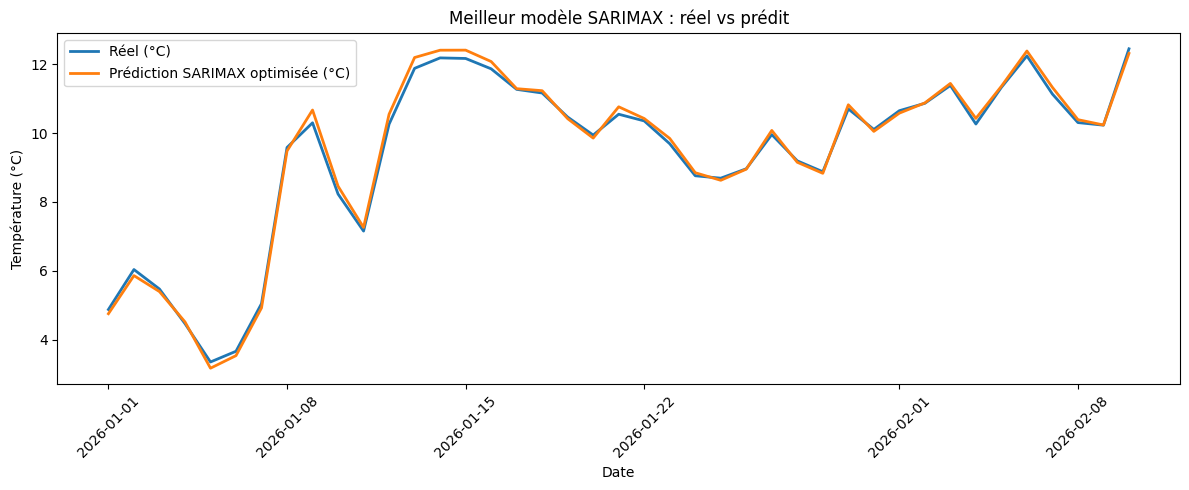

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Réel (°C)", linewidth=2)
plt.plot(y_test.index, meilleure_prediction, label="Prédiction SARIMAX optimisée (°C)", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Meilleur modèle SARIMAX : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La meilleure configuration obtenue est SARIMAX(1,1,2) sans composante saisonnière.

Les performances sont très élevées, avec un RMSE faible (0.15) et un R² proche de 1 (0.996), ce qui indique une excellente qualité de prédiction.

La diminution de l’AIC confirme également que ce modèle est mieux ajusté aux données que les configurations précédentes.

L’absence de saisonnalité suggère que les variables explicatives capturent déjà une grande partie de la structure des données.

Ces résultats montrent que le réglage des paramètres permet d’améliorer significativement les performances du modèle.


## Limites du modèle et contraintes réelles

À ce stade de l’analyse, une limite importante apparaît.

Les modèles utilisant des variables explicatives (comme SARIMAX) reposent sur des données connues au moment de la prédiction, telles que l’humidité ou le point de rosée.

Or, dans un contexte réel de prévision sur plusieurs jours ou sur des périodes longues, ces variables ne sont pas disponibles à l’avance.

Les performances observées sont donc conditionnées à la connaissance des variables futures, ce qui limite l’applicabilité directe du modèle pour une utilisation opérationnelle.

Dans le cadre du projet agricole, cette contrainte est essentielle, car les décisions doivent être prises en amont, sans disposer des données météorologiques futures exactes.

Cette limite sera prise en compte dans l’interprétation globale des résultats et dans le choix du modèle le plus adapté.

# Modèles sans variables explicatives

---



## Random Forest avec variables retardées (lags)

Afin de contourner l’absence de variables explicatives futures, nous utilisons un modèle Random Forest basé uniquement sur les valeurs passées de la température.

Des variables retardées (lags) sont créées afin d’intégrer l’historique de la série temporelle dans le modèle.

L’objectif est de prédire la température de manière réaliste, en se basant uniquement sur les observations passées.

/tmp/ipykernel_22536/3153749339.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, bdd)


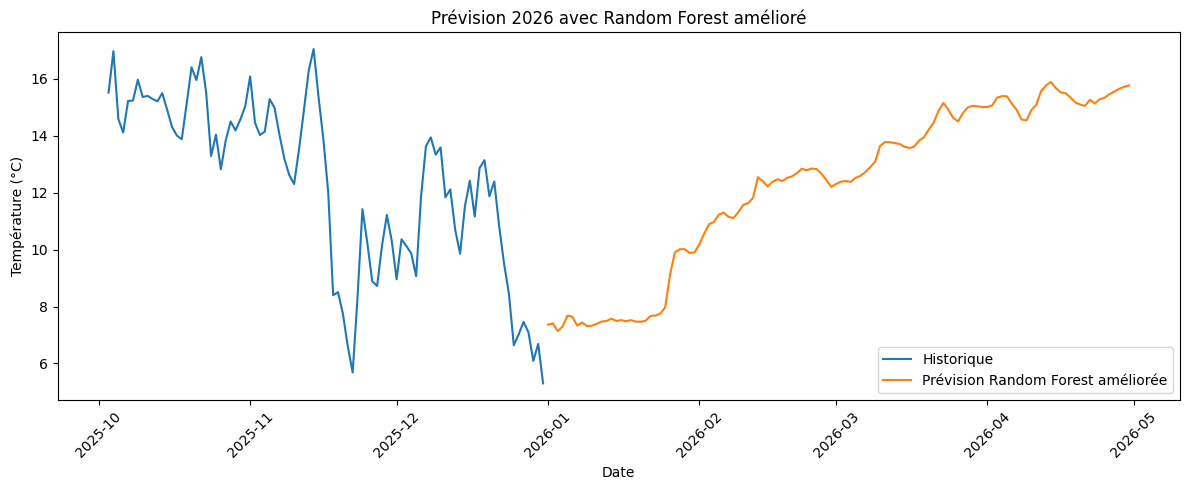

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df["temperature"] = df["temperature"] - 273.15

# Agrégation journalière
df = df.groupby("date")["temperature"].mean()

# Fréquence journalière + interpolation
df = df.asfreq("D").interpolate()

# Retour en DataFrame
df = df.to_frame(name="temperature")

# CRÉATION DES VARIABLES

def create_features(data):
    data = data.copy()

    # Lags courts
    short_lags = [1, 2, 3, 5, 7]

    # Lags moyens
    medium_lags = [14, 21, 30]

    # Lag saisonnier approximatif
    seasonal_lags = [365]

    all_lags = short_lags + medium_lags + seasonal_lags

    for lag in all_lags:
        data[f"lag_{lag}"] = data["temperature"].shift(lag)

    #  Moyennes mobiles (sur valeurs passées uniquement)
    data["rolling_mean_7"] = data["temperature"].shift(1).rolling(window=7).mean()
    data["rolling_mean_30"] = data["temperature"].shift(1).rolling(window=30).mean()

    #  Écart-type mobile
    data["rolling_std_7"] = data["temperature"].shift(1).rolling(window=7).std()

    #  Variables calendaires
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["dayofweek"] = data.index.dayofweek

    # Encodage cyclique pour la saisonnalité
    data["sin_dayofyear"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["cos_dayofyear"] = np.cos(2 * np.pi * data["dayofyear"] / 365)

    return data

df_feat = create_features(df)
df_feat = df_feat.dropna()

# VARIABLES D'ENTRÉE

feature_cols = [
    "lag_1", "lag_2", "lag_3", "lag_5", "lag_7",
    "lag_14", "lag_21", "lag_30", "lag_365",
    "rolling_mean_7", "rolling_mean_30", "rolling_std_7",
    "month", "dayofyear", "dayofweek",
    "sin_dayofyear", "cos_dayofyear"
]

X_train = df_feat[feature_cols]
y_train = df_feat["temperature"]

# ENTRAÎNEMENT DU MODÈLE

model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

# PRÉDICTION FUTURE

n_future = 120

# Historique complet pour mettre à jour les lags
history = df["temperature"].copy()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=n_future,
    freq="D"
)

future_preds = []

for current_date in future_dates:
    row = {}

    # Lags
    for lag in [1, 2, 3, 5, 7, 14, 21, 30, 365]:
        row[f"lag_{lag}"] = history.iloc[-lag]

    # Moyennes mobiles
    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_mean_30"] = history.iloc[-30:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    # Variables calendaires
    row["month"] = current_date.month
    row["dayofyear"] = current_date.dayofyear
    row["dayofweek"] = current_date.dayofweek

    # Encodage cyclique
    row["sin_dayofyear"] = np.sin(2 * np.pi * current_date.dayofyear / 365)
    row["cos_dayofyear"] = np.cos(2 * np.pi * current_date.dayofyear / 365)

    X_next = pd.DataFrame([row])[feature_cols]

    next_pred = model_rf.predict(X_next)[0]
    future_preds.append(next_pred)

    # Ajouter la prédiction à l'historique pour la suite
    history.loc[current_date] = next_pred

forecast_rf = pd.Series(future_preds, index=future_dates)

# GRAPHIQUE
plt.figure(figsize=(12, 5))

plt.plot(
    df.index[-90:],
    df["temperature"].iloc[-90:],
    label="Historique"
)

plt.plot(
    forecast_rf.index,
    forecast_rf.values,
    label="Prévision Random Forest améliorée"
)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Prévision 2026 avec Random Forest amélioré")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Random Forest avec lags ===
MAE : 1.8879350582951295 °C
MSE : 5.712249431198212
RMSE : 2.3900312615524952 °C
R² : 0.04055096152504145


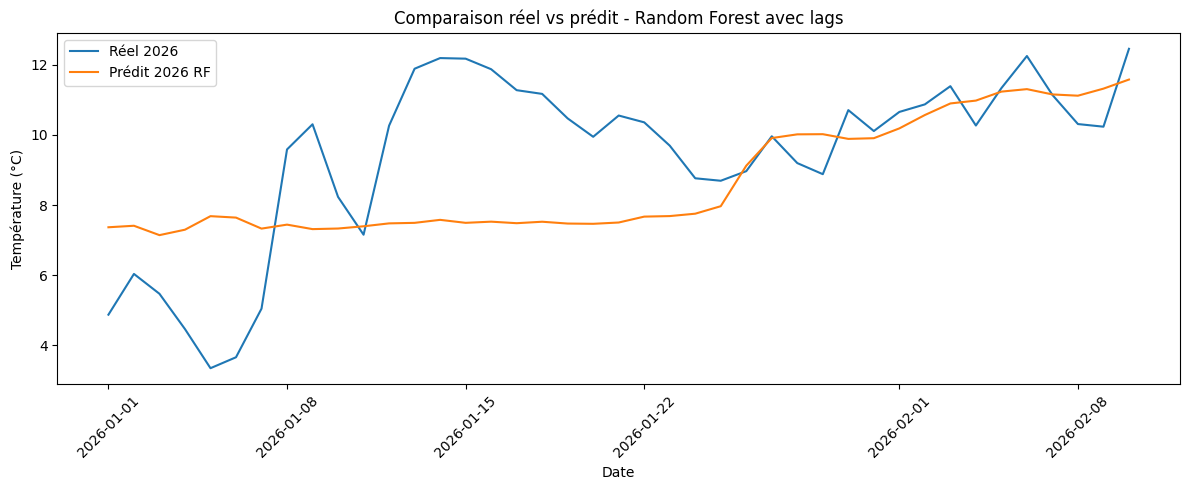

In [ ]:
test = pd.read_csv("meteo_2026_a_predire.csv")

test["date"] = pd.to_datetime(test["date"], dayfirst=True)
test["temperature"] = test["temperature"] - 273.15

test = test.groupby("date")["temperature"].mean()
test = test.asfreq("D").interpolate()

# on aligne la comparaison
n_compare = min(len(test), len(forecast_rf))

y_true = test.iloc[:n_compare]
y_pred = forecast_rf.iloc[:n_compare]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=== Random Forest avec lags ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

plt.figure(figsize=(12, 5))
plt.plot(y_true.index, y_true.values, label="Réel 2026")
plt.plot(y_pred.index, y_pred.values, label="Prédit 2026 RF")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Comparaison réel vs prédit - Random Forest avec lags")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle sont relativement faibles (R² proche de 0), ce qui indique que le modèle explique mal la variabilité de la température.

Le graphique montre que les prédictions sont beaucoup plus lissées que les valeurs réelles et ne capturent pas correctement les variations importantes.

Le modèle a tendance à sous-estimer les pics et les creux de température.

Cela montre que l’utilisation uniquement des valeurs passées de la température est insuffisante pour modéliser correctement la dynamique climatique.

Dans le cadre du projet agricole, ce type de modèle est plus réaliste, mais moins précis.

Cela met en évidence un compromis important entre performance du modèle et applicabilité réelle.

Période train : 2023-01-01 00:00:00 à 2025-09-02 00:00:00
Période test  : 2025-09-03 00:00:00 à 2025-12-31 00:00:00
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Meilleurs paramètres :
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 15}

=== PERFORMANCE RANDOM FOREST OPTIMISÉ ===
MAE  : 1.009
RMSE : 1.233
R²   : 0.880


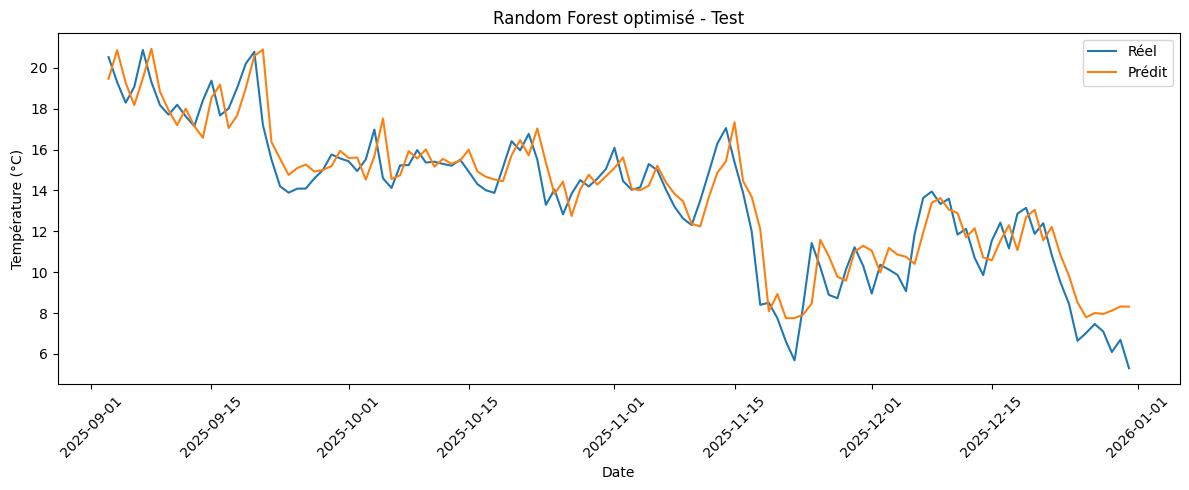

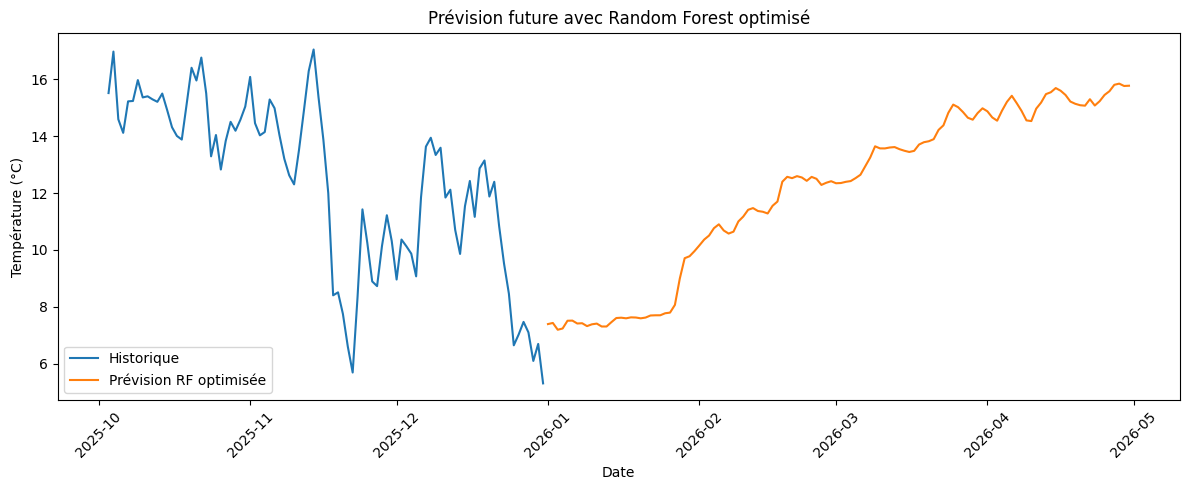

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =========================================================

query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Agrégation journalière
df = df.groupby("date")["temperature"].mean()

# Fréquence journalière + interpolation
df = df.asfreq("D").interpolate()

# Retour en DataFrame
df = df.to_frame(name="temperature")

# =========================================================
# 2. CRÉATION DES FEATURES
# =========================================================

def create_features(data):
    data = data.copy()

    short_lags = [1, 2, 3, 5, 7]
    medium_lags = [14, 21, 30]
    seasonal_lags = [365]
    all_lags = short_lags + medium_lags + seasonal_lags

    for lag in all_lags:
        data[f"lag_{lag}"] = data["temperature"].shift(lag)

    # Moyennes mobiles basées uniquement sur le passé
    data["rolling_mean_7"] = data["temperature"].shift(1).rolling(window=7).mean()
    data["rolling_mean_30"] = data["temperature"].shift(1).rolling(window=30).mean()
    data["rolling_std_7"] = data["temperature"].shift(1).rolling(window=7).std()

    # Variables calendaires
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["dayofweek"] = data.index.dayofweek

    # Encodage cyclique
    data["sin_dayofyear"] = np.sin(2 * np.pi * data["dayofyear"] / 365.25)
    data["cos_dayofyear"] = np.cos(2 * np.pi * data["dayofyear"] / 365.25)

    return data

df_feat = create_features(df).dropna()

feature_cols = [
    "lag_1", "lag_2", "lag_3", "lag_5", "lag_7",
    "lag_14", "lag_21", "lag_30", "lag_365",
    "rolling_mean_7", "rolling_mean_30", "rolling_std_7",
    "month", "dayofyear", "dayofweek",
    "sin_dayofyear", "cos_dayofyear"
]

# =========================================================
# 3. SPLIT TRAIN / TEST
# =========================================================

# Exemple : 120 derniers jours pour le test
test_size = 120

train_df = df_feat.iloc[:-test_size].copy()
test_df = df_feat.iloc[-test_size:].copy()

X_train = train_df[feature_cols]
y_train = train_df["temperature"]

X_test = test_df[feature_cols]
y_test = test_df["temperature"]

print("Période train :", train_df.index.min(), "à", train_df.index.max())
print("Période test  :", test_df.index.min(), "à", test_df.index.max())

# =========================================================
# 4. OPTIMISATION DES HYPERPARAMÈTRES
# =========================================================

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

base_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

tscv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nMeilleurs paramètres :")
print(search.best_params_)

# =========================================================
# 5. ÉVALUATION SUR LE TEST
# =========================================================

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== PERFORMANCE RANDOM FOREST OPTIMISÉ ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# =========================================================
# 6. GRAPHIQUE TEST VS PRÉDICTIONS
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(test_df.index, y_test, label="Réel")
plt.plot(test_df.index, y_pred, label="Prédit")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Random Forest optimisé - Test")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 7. ENTRAÎNEMENT FINAL SUR TOUTES LES DONNÉES
# =========================================================

X_full = df_feat[feature_cols]
y_full = df_feat["temperature"]

best_model.fit(X_full, y_full)

# =========================================================
# 8. PRÉVISION FUTURE SUR 120 JOURS
# =========================================================

n_future = 120
history = df["temperature"].copy()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=n_future,
    freq="D"
)

future_preds = []

for current_date in future_dates:
    row = {}

    for lag in [1, 2, 3, 5, 7, 14, 21, 30, 365]:
        row[f"lag_{lag}"] = history.iloc[-lag]

    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_mean_30"] = history.iloc[-30:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    row["month"] = current_date.month
    row["dayofyear"] = current_date.dayofyear
    row["dayofweek"] = current_date.dayofweek

    row["sin_dayofyear"] = np.sin(2 * np.pi * current_date.dayofyear / 365.25)
    row["cos_dayofyear"] = np.cos(2 * np.pi * current_date.dayofyear / 365.25)

    X_next = pd.DataFrame([row])[feature_cols]
    next_pred = best_model.predict(X_next)[0]

    future_preds.append(next_pred)
    history.loc[current_date] = next_pred

forecast_rf = pd.Series(future_preds, index=future_dates)

# =========================================================
# 9. GRAPHIQUE FINAL
# =========================================================

plt.figure(figsize=(12, 5))
plt.plot(df.index[-90:], df["temperature"].iloc[-90:], label="Historique")
plt.plot(forecast_rf.index, forecast_rf.values, label="Prévision RF optimisée")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Prévision future avec Random Forest optimisé")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle Random Forest optimisé obtient une très bonne performance avec un RMSE de 1.23°C et un R² de 0.88. Cela indique que le modèle est capable de prédire efficacement la température journalière. La courbe prédite suit fidèlement les variations observées, bien que certains pics extrêmes soient légèrement atténués, ce qui est typique des modèles d’ensemble comme Random Forest. Mais le modele se base sur la température de la veille dont nous avons connaissance donc le molene n'est pas très bon sur le long terme comme nous allon sle voir


=== PERFORMANCE SUR 2026 (JUSQU'À MAI) ===
MAE  : 1.966
RMSE : 2.403
R²   : 0.030


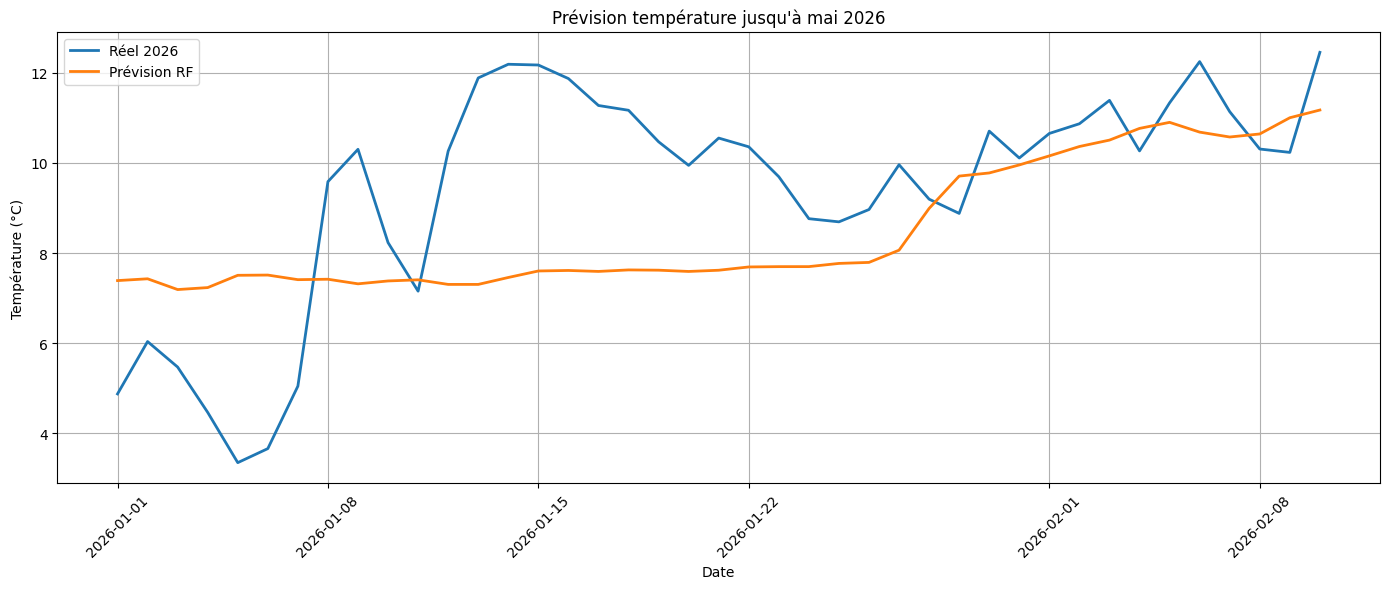

In [24]:
# =========================================================
# 1. CHARGEMENT DU CSV 2026 (RÉEL)
# =========================================================

df_test = pd.read_csv("meteo_2026_a_predire.csv")

df_test["date"] = pd.to_datetime(df_test["date"], dayfirst=True)
df_test = df_test.sort_values("date")

# Kelvin -> Celsius
df_test["temperature"] = df_test["temperature"] - 273.15

# Agrégation journalière
df_test = df_test.groupby("date")["temperature"].mean()

# Fréquence journalière
df_test = df_test.asfreq("D").interpolate()

# =========================================================
# 2. PRÉVISION JUSQU'À MAI 2026
# =========================================================

# Date fin prévision
end_date = "2026-05-31"

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    end=end_date,
    freq="D"
)

history = df["temperature"].copy()
future_preds = []

for current_date in future_dates:
    row = {}

    # Lags
    for lag in [1,2,3,5,7,14,21,30,365]:
        row[f"lag_{lag}"] = history.iloc[-lag]

    # Rolling
    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_mean_30"] = history.iloc[-30:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    # Calendrier
    row["month"] = current_date.month
    row["dayofyear"] = current_date.dayofyear
    row["dayofweek"] = current_date.dayofweek

    # Cyclic
    row["sin_dayofyear"] = np.sin(2 * np.pi * current_date.dayofyear / 365.25)
    row["cos_dayofyear"] = np.cos(2 * np.pi * current_date.dayofyear / 365.25)

    X_next = pd.DataFrame([row])[feature_cols]

    pred = best_model.predict(X_next)[0]
    future_preds.append(pred)

    # IMPORTANT : on ajoute la prédiction (pas le vrai)
    history.loc[current_date] = pred

forecast = pd.Series(future_preds, index=future_dates)

# =========================================================
# 3. ALIGNEMENT AVEC LE CSV 2026
# =========================================================

df_compare = pd.DataFrame({
    "real": df_test,
    "pred": forecast
}).dropna()

# =========================================================
# 4. MÉTRIQUES
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(df_compare["real"], df_compare["pred"])
rmse = np.sqrt(mean_squared_error(df_compare["real"], df_compare["pred"]))
r2 = r2_score(df_compare["real"], df_compare["pred"])

print("\n=== PERFORMANCE SUR 2026 (JUSQU'À MAI) ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# =========================================================
# 5. GRAPHIQUE COMPARAISON
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(df_compare.index, df_compare["real"], label="Réel 2026", linewidth=2)
plt.plot(df_compare.index, df_compare["pred"], label="Prévision RF", linewidth=2)

plt.title("Prévision température jusqu'à mai 2026")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

=== PERFORMANCE SUR 2026 JUSQU'À MAI ===
MAE  : 1.966
RMSE : 2.403
R²   : 0.030


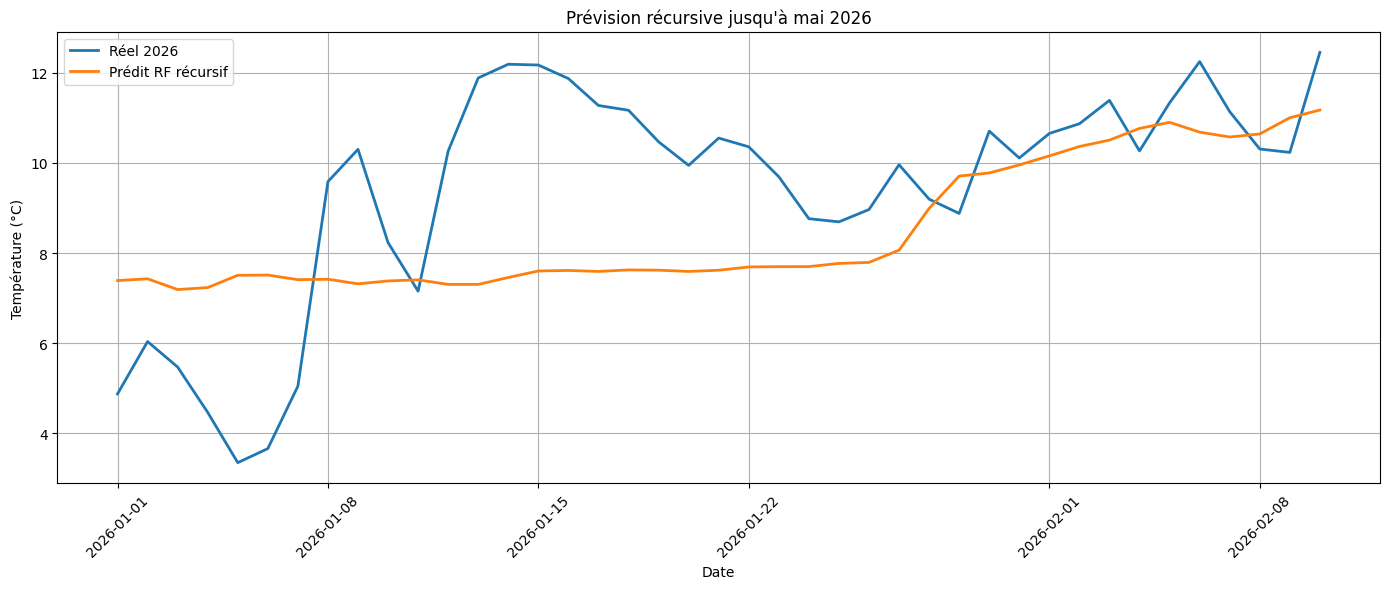

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. CHARGER LE CSV 2026 POUR COMPARAISON
# =========================================================

df_test = pd.read_csv("meteo_2026_a_predire.csv")
df_test["date"] = pd.to_datetime(df_test["date"], dayfirst=True)
df_test = df_test.sort_values("date")

# Kelvin -> Celsius
df_test["temperature"] = df_test["temperature"] - 273.15

# Agrégation journalière
df_test = df_test.groupby("date")["temperature"].mean().asfreq("D").interpolate()

# =========================================================
# 2. PRÉVISION RÉCURSIVE JUSQU'À MAI 2026
# =========================================================

end_date = pd.Timestamp("2026-05-31")

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    end=end_date,
    freq="D"
)

# historique initial = uniquement les vraies données passées
history = df["temperature"].copy()

predictions = []

for current_date in future_dates:
    row = {}

    # Lags construits avec l'historique courant
    # au début = vraies valeurs passées
    # ensuite = mélange vraies valeurs + prédictions déjà faites
    for lag in [1, 2, 3, 5, 7, 14, 21, 30, 365]:
        row[f"lag_{lag}"] = history.iloc[-lag]

    # Variables roulantes
    row["rolling_mean_7"] = history.iloc[-7:].mean()
    row["rolling_mean_30"] = history.iloc[-30:].mean()
    row["rolling_std_7"] = history.iloc[-7:].std()

    # Variables calendaires
    row["month"] = current_date.month
    row["dayofyear"] = current_date.dayofyear
    row["dayofweek"] = current_date.dayofweek

    # Encodage cyclique
    row["sin_dayofyear"] = np.sin(2 * np.pi * current_date.dayofyear / 365.25)
    row["cos_dayofyear"] = np.cos(2 * np.pi * current_date.dayofyear / 365.25)

    # DataFrame d'une ligne
    X_next = pd.DataFrame([row])[feature_cols]

    # Prédiction du jour
    y_next = best_model.predict(X_next)[0]
    predictions.append(y_next)

    # Très important :
    # on ajoute la prédiction à l'historique
    # pour qu'elle serve au jour suivant
    history.loc[current_date] = y_next

forecast_rf = pd.Series(predictions, index=future_dates, name="pred_temperature")

# =========================================================
# 3. COMPARAISON AVEC LE CSV 2026
# =========================================================

df_compare = pd.concat([df_test.rename("real"), forecast_rf.rename("pred")], axis=1).dropna()

mae = mean_absolute_error(df_compare["real"], df_compare["pred"])
rmse = np.sqrt(mean_squared_error(df_compare["real"], df_compare["pred"]))
r2 = r2_score(df_compare["real"], df_compare["pred"])

print("=== PERFORMANCE SUR 2026 JUSQU'À MAI ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# =========================================================
# 4. GRAPHIQUE
# =========================================================

plt.figure(figsize=(14,6))
plt.plot(df_compare.index, df_compare["real"], label="Réel 2026", linewidth=2)
plt.plot(df_compare.index, df_compare["pred"], label="Prédit RF récursif", linewidth=2)

plt.title("Prévision récursive jusqu'à mai 2026")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ARIMA

Dans une logique de prédiction réaliste, nous utilisons le modèle ARIMA en nous basant uniquement sur les valeurs passées de la température.

Contrairement aux modèles précédents, aucune variable explicative externe n’est utilisée.

L’objectif est d’évaluer la capacité d’un modèle purement temporel à prédire la température sur une période future.

/tmp/ipykernel_22536/1162625555.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== ARIMA ===
MAE : 4.21842348122446 °C
MSE : 21.325323376836845
RMSE : 4.617934968883477 °C
R² : -2.5818745759464887
            Réel 2026  Prédit 2026 ARIMA
date                                    
2026-01-01   4.875364           4.780242
2026-01-02   6.036444           5.168140
2026-01-03   5.470833           5.452401
2026-01-04   4.465405           5.490096
2026-01-05   3.350640           5.599772


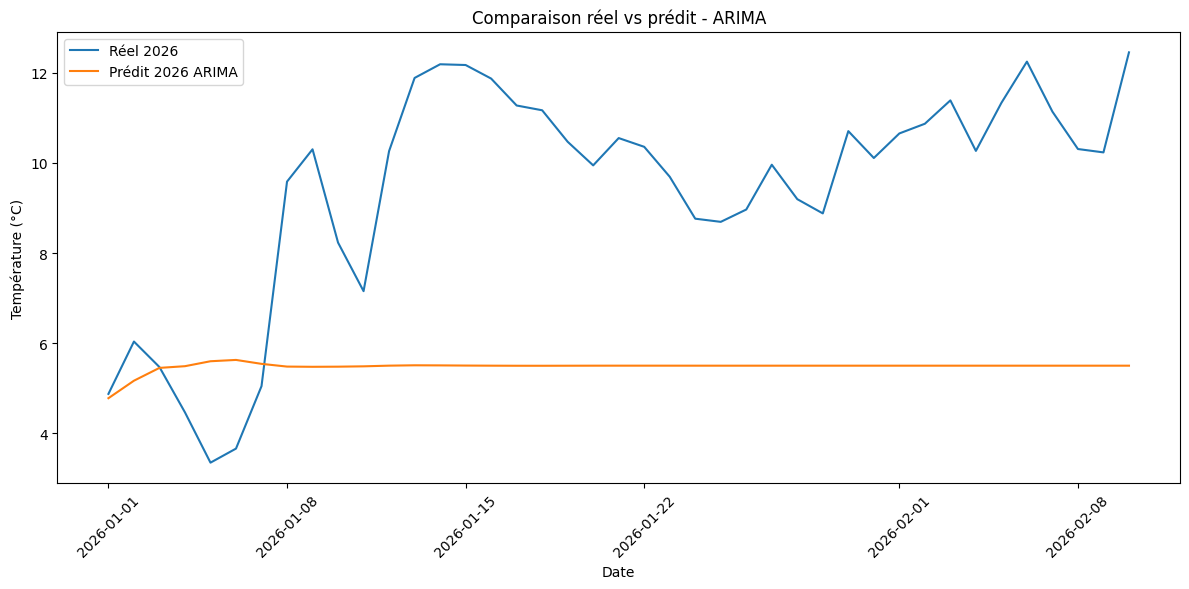

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

# AGRÉGATION JOURNALIÈRE
train = train.groupby("date")["temperature"].mean()
test = test.groupby("date")["temperature"].mean()

# FRÉQUENCE JOURNALIÈRE
train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

# Exemple de paramètres ARIMA
model_arima = ARIMA(train, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# PRÉDICTION 2026
y_pred_arima = model_arima_fit.forecast(steps=len(test))
y_pred_arima.index = test.index

# ÉVALUATION
mae_arima = mean_absolute_error(test, y_pred_arima)
mse_arima = mean_squared_error(test, y_pred_arima)
rmse_arima = np.sqrt(mse_arima)
r2_arima = r2_score(test, y_pred_arima)

print("=== ARIMA ===")
print("MAE :", mae_arima, "°C")
print("MSE :", mse_arima)
print("RMSE :", rmse_arima, "°C")
print("R² :", r2_arima)

# TABLEAU COMPARATIF
comparaison_arima = pd.DataFrame({
    "Réel 2026": test,
    "Prédit 2026 ARIMA": y_pred_arima
})

print(comparaison_arima.head())

# GRAPHIQUE
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label="Réel 2026")
plt.plot(y_pred_arima.index, y_pred_arima.values, label="Prédit 2026 ARIMA")

plt.title("Comparaison réel vs prédit - ARIMA")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle ARIMA sont faibles (R² négatif et RMSE élevé), ce qui indique une mauvaise qualité de prédiction.

Le graphique montre que les prédictions sont quasiment constantes et ne suivent pas les variations réelles de la température.

Le modèle ne parvient pas à capturer la dynamique de la série.

Cela s’explique par le fait que la température dépend de nombreux facteurs externes qui ne sont pas pris en compte ici.

Dans le cadre du projet agricole, ce modèle est plus réaliste car il n’utilise pas de données futures, mais il manque de précision.

Cela confirme la difficulté de prédire la température uniquement à partir de son historique.

## SARIMA


Dans la continuité du modèle ARIMA, nous utilisons le modèle SARIMA afin d’intégrer une composante saisonnière, tout en restant dans un cadre réaliste sans variables explicatives.

L’objectif est d’évaluer si l’ajout de la saisonnalité permet d’améliorer la prédiction de la température à partir de ses valeurs passées uniquement.

/tmp/ipykernel_22536/2722648090.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== SARIMA ===
MAE : 4.950370245387905 °C
MSE : 29.45815519336033
RMSE : 5.427536751912449 °C
R² : -3.947892947592636
            Réel 2026  Prédit 2026 SARIMA
date                                     
2026-01-01   4.875364            4.668822
2026-01-02   6.036444            4.825758
2026-01-03   5.470833            4.612268
2026-01-04   4.465405            4.570923
2026-01-05   3.350640            4.681557


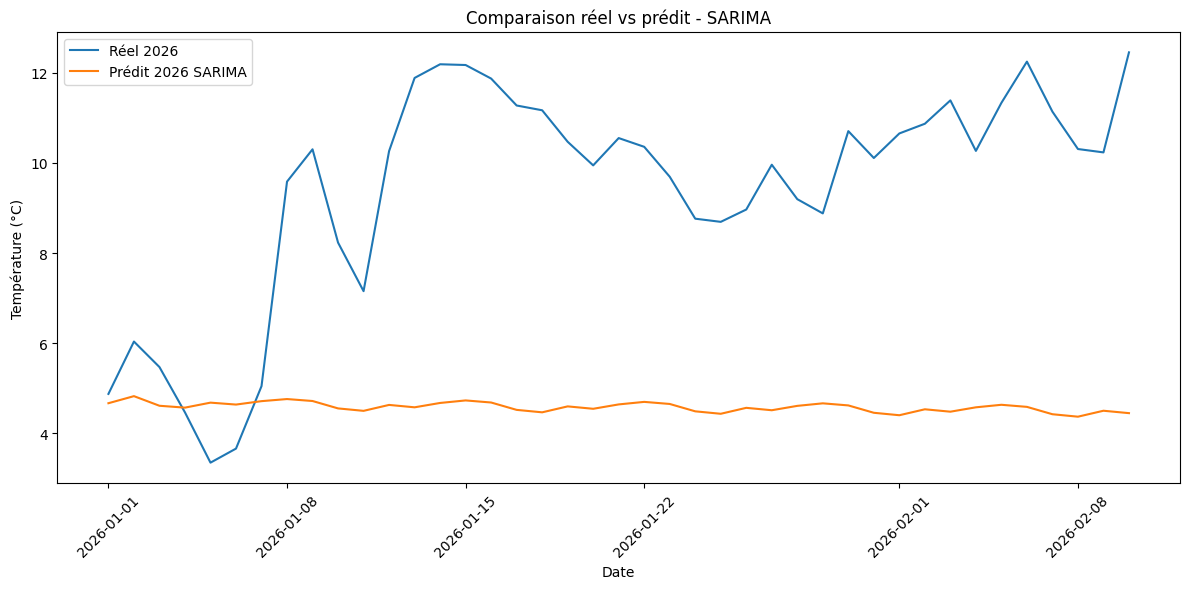

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

train = train.groupby("date")["temperature"].mean()
test = test.groupby("date")["temperature"].mean()

train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

# order = (p, d, q)
# seasonal_order = (P, D, Q, s)
# Exemple ici avec une saisonnalité hebdomadaire s = 7

model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit(disp=False)

# PRÉDICTION 2026
y_pred_sarima = model_sarima_fit.forecast(steps=len(test))
y_pred_sarima.index = test.index

# ÉVALUATION
mae_sarima = mean_absolute_error(test, y_pred_sarima)
mse_sarima = mean_squared_error(test, y_pred_sarima)
rmse_sarima = np.sqrt(mse_sarima)
r2_sarima = r2_score(test, y_pred_sarima)

print("=== SARIMA ===")
print("MAE :", mae_sarima, "°C")
print("MSE :", mse_sarima)
print("RMSE :", rmse_sarima, "°C")
print("R² :", r2_sarima)

# TABLEAU COMPARATIF
comparaison_sarima = pd.DataFrame({
    "Réel 2026": test,
    "Prédit 2026 SARIMA": y_pred_sarima
})

print(comparaison_sarima.head())

# GRAPHIQ
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label="Réel 2026")
plt.plot(y_pred_sarima.index, y_pred_sarima.values, label="Prédit 2026 SARIMA")

plt.title("Comparaison réel vs prédit - SARIMA")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Début série journalière : 2022-01-01 00:00:00
Fin série journalière   : 2025-12-31 00:00:00
Nb jours                : 1461

Train : 2022-01-01 00:00:00 -> 2024-12-31 00:00:00 (1096 jours)
Test  : 2025-01-01 00:00:00 -> 2025-12-31 00:00:00 (365 jours)

=== GRID SEARCH SARIMA JOURNALIER ===
order=(0, 1, 1) | seasonal_order=(0, 1, 1, 7) | RMSE=9.2281 | MAE=8.0251 | MAPE=46.85% | R2=-3.0900
order=(0, 1, 1) | seasonal_order=(1, 1, 0, 7) | RMSE=70.0843 | MAE=62.0993 | MAPE=427.13% | R2=-234.9041
order=(0, 1, 1) | seasonal_order=(1, 1, 1, 7) | RMSE=9.1185 | MAE=7.9253 | MAPE=46.25% | R2=-2.9934
order=(0, 1, 1) | seasonal_order=(1, 1, 2, 7) | RMSE=9.4973 | MAE=8.3121 | MAPE=48.75% | R2=-3.3321
order=(1, 1, 0) | seasonal_order=(0, 1, 1, 7) | RMSE=9.3753 | MAE=8.1798 | MAPE=47.86% | R2=-3.2214
order=(1, 1, 0) | seasonal_order=(1, 1, 0, 7) | RMSE=68.2733 | MAE=60.5142 | MAPE=415.97% | R2=-222.8703
order=(1, 1, 0) | seasonal_order=(1, 1, 1, 7) | RMSE=9.2166 | MAE=8.0305 | MAPE=46.94% | R2=-3.0798


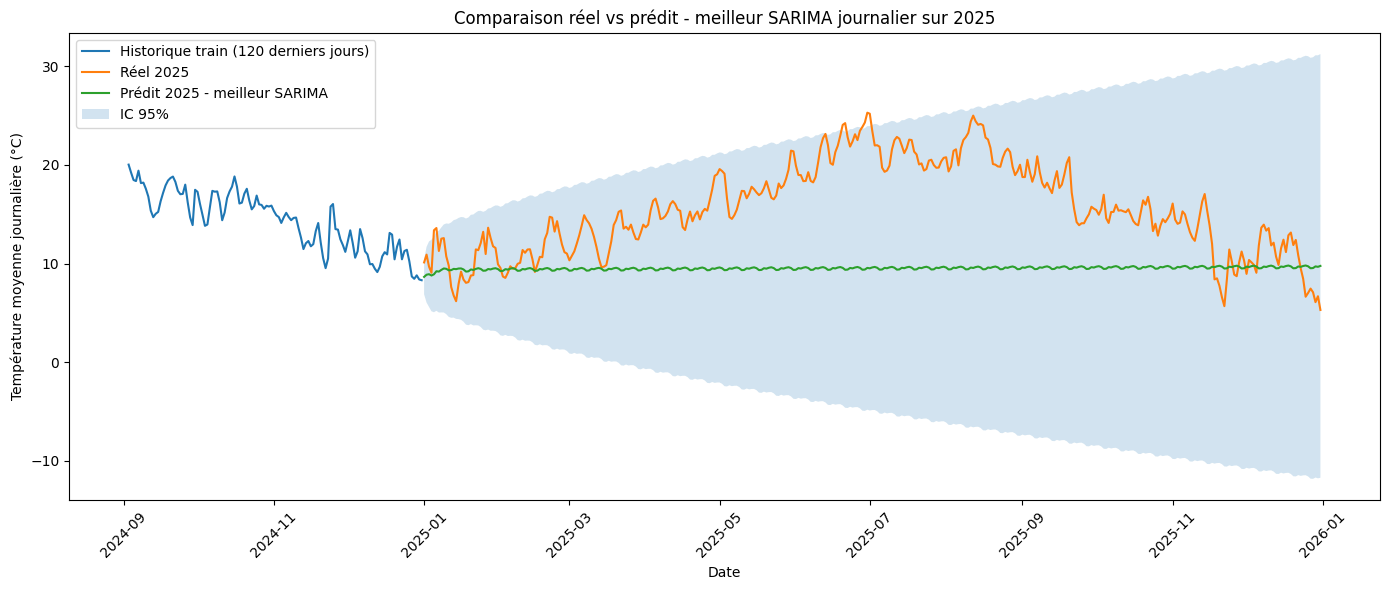


=== PERFORMANCES SUR 2026 (journalier) ===
MAE  : 3.0062 °C
MSE  : 10.8763
RMSE : 3.2979 °C
MAPE : 32.35%
R2   : -0.8268

=== Comparaison réel / prédit sur 2026 (journalier) ===
                 reel  prediction    erreur  erreur_absolue  borne_inf_95  \
date                                                                        
2026-01-01   4.875364    5.028624 -0.153260        0.153260      3.205610   
2026-01-02   6.036444    5.723158  0.313287        0.313287      2.819932   
2026-01-03   5.470833    6.068893 -0.598059        0.598059      2.643858   
2026-01-04   4.465405    6.315215 -1.849810        1.849810      2.566694   
2026-01-05   3.350640    6.654051 -3.303411        3.303411      2.677201   
2026-01-06   3.662198    6.782045 -3.119847        3.119847      2.628542   
2026-01-07   5.047106    6.933487 -1.886381        1.886381      2.633636   
2026-01-08   9.583671    7.070495  2.513176        2.513176      2.627731   
2026-01-09  10.300408    7.088691  3.211716        

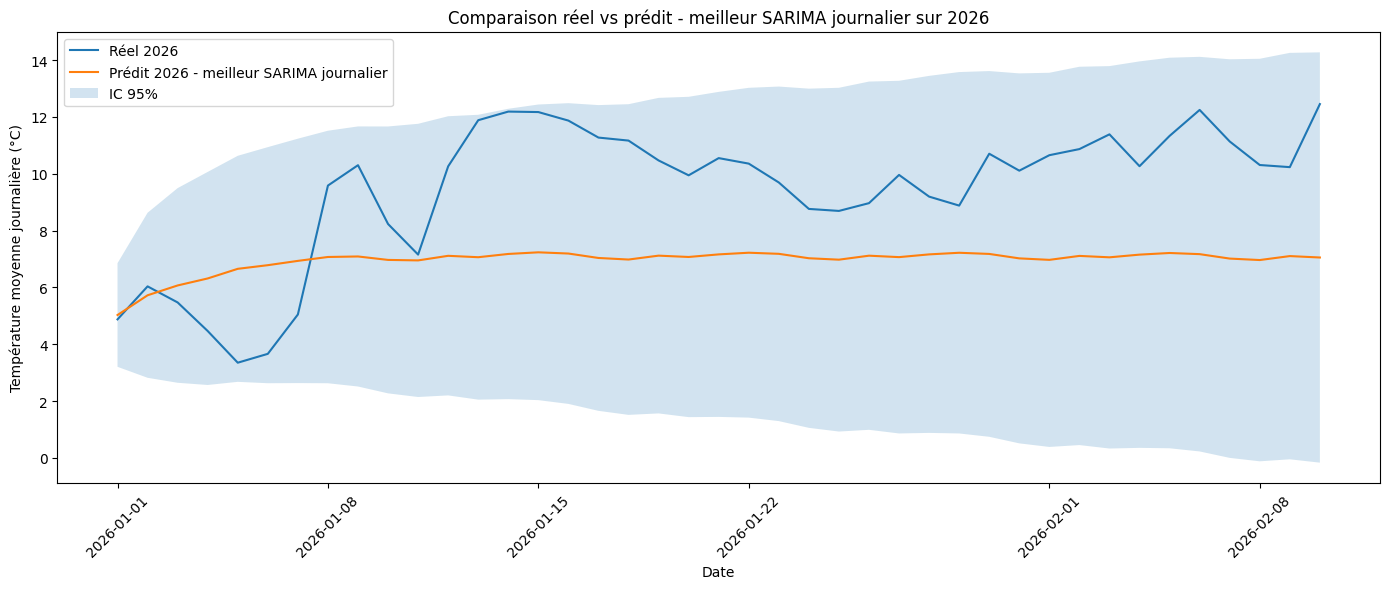

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# =========================================================
# 1) CHARGEMENT DES DONNÉES
# =========================================================
query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

df_2026 = pd.read_csv("meteo_2026_a_predire.csv")

# =========================================================
# 2) PRÉPARATION DES DONNÉES
# =========================================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_2026["date"] = pd.to_datetime(df_2026["date"], dayfirst=True, errors="coerce")

df = df.dropna(subset=["date", "temperature"]).copy()
df_2026 = df_2026.dropna(subset=["date", "temperature"]).copy()

df = df.sort_values("date")
df_2026 = df_2026.sort_values("date")

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15
df_2026["temperature"] = df_2026["temperature"] - 273.15

# =========================================================
# 3) AGRÉGATION JOURNALIÈRE
# =========================================================
daily = df.groupby("date")["temperature"].mean().sort_index()
daily = daily.asfreq("D").interpolate()

daily_2026_real = df_2026.groupby("date")["temperature"].mean().sort_index()
daily_2026_real = daily_2026_real.asfreq("D").interpolate()

print("Début série journalière :", daily.index.min())
print("Fin série journalière   :", daily.index.max())
print("Nb jours                :", len(daily))

# =========================================================
# 4) TRAIN / TEST
#    train = 2022-2024
#    test  = 2025
# =========================================================
train_daily = daily[daily.index < "2025-01-01"]
test_daily = daily[(daily.index >= "2025-01-01") & (daily.index < "2026-01-01")]

print("\nTrain :", train_daily.index.min(), "->", train_daily.index.max(), f"({len(train_daily)} jours)")
print("Test  :", test_daily.index.min(), "->", test_daily.index.max(), f"({len(test_daily)} jours)")

if len(train_daily) < 365:
    raise ValueError("Pas assez de données journalières pour entraîner correctement un SARIMA.")
if len(test_daily) == 0:
    raise ValueError("Le jeu de test journalier est vide.")

# =========================================================
# 5) FONCTIONS D'ÉVALUATION
# =========================================================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, mape, r2

# =========================================================
# 6) GRILLE DE PARAMÈTRES
#    En journalier on garde une grille raisonnable
#    saisonnalité hebdomadaire : s = 7
# =========================================================
orders = [
    (0,1,1),
    (1,1,0),
    (1,1,1),
    (1,1,2),
    (2,1,1)
]

seasonal_orders = [
    (0,1,1,7),
    (1,1,0,7),
    (1,1,1,7),
    (1,1,2,7)
]

# =========================================================
# 7) GRID SEARCH SARIMA JOURNALIER
# =========================================================
liste_resultats = []

meilleur_rmse = float("inf")
meilleure_config = None
meilleur_modele_fit = None
meilleure_prediction = None
meilleur_conf_int = None

print("\n=== GRID SEARCH SARIMA JOURNALIER ===")

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train_daily,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            forecast_obj = results.get_forecast(steps=len(test_daily))
            forecast = forecast_obj.predicted_mean
            conf_int = forecast_obj.conf_int()

            forecast.index = test_daily.index
            conf_int.index = test_daily.index

            mae, mse, rmse, mape, r2 = evaluer_predictions(test_daily, forecast)

            # filtre de sécurité contre les modèles aberrants
            if np.isnan(rmse) or np.isinf(rmse) or rmse > 1000:
                continue

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "MAPE": mape,
                "R2": r2,
                "AIC": results.aic,
                "BIC": results.bic
            })

            print(
                f"order={order} | seasonal_order={seasonal_order} "
                f"| RMSE={rmse:.4f} | MAE={mae:.4f} | MAPE={mape:.2f}% | R2={r2:.4f}"
            )

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_modele_fit = results
                meilleure_prediction = forecast
                meilleur_conf_int = conf_int

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

# =========================================================
# 8) RÉSULTATS TRIÉS
# =========================================================
resultats_df = pd.DataFrame(liste_resultats)

if resultats_df.empty:
    raise ValueError("Aucun modèle journalier valide n'a convergé.")

resultats_df = resultats_df.sort_values(by=["RMSE", "MAE", "AIC"]).reset_index(drop=True)

print("\n=== TOP 10 DES MEILLEURS MODÈLES JOURNALIERS ===")
print(resultats_df.head(10))

print("\n=== MEILLEURE CONFIGURATION ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print(f"RMSE : {resultats_df.iloc[0]['RMSE']:.4f}")
print(f"MAE  : {resultats_df.iloc[0]['MAE']:.4f}")
print(f"MAPE : {resultats_df.iloc[0]['MAPE']:.2f}%")
print(f"R2   : {resultats_df.iloc[0]['R2']:.4f}")
print(f"AIC  : {resultats_df.iloc[0]['AIC']:.2f}")
print(f"BIC  : {resultats_df.iloc[0]['BIC']:.2f}")

# =========================================================
# 9) TABLEAU RÉEL / PRÉDIT SUR 2025
# =========================================================
comparaison_journalier_2025 = pd.DataFrame({
    "reel": test_daily,
    "prediction": meilleure_prediction,
    "erreur": test_daily - meilleure_prediction,
    "erreur_absolue": np.abs(test_daily - meilleure_prediction),
    "borne_inf_95": meilleur_conf_int.iloc[:, 0],
    "borne_sup_95": meilleur_conf_int.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2025 (journalier) ===")
print(comparaison_journalier_2025)

# =========================================================
# 10) MÉTRIQUES FINALES SUR 2025
# =========================================================
mae_2025, mse_2025, rmse_2025, mape_2025, r2_2025 = evaluer_predictions(test_daily, meilleure_prediction)

print("\n=== PERFORMANCES SUR 2025 (journalier) ===")
print(f"MAE  : {mae_2025:.4f} °C")
print(f"MSE  : {mse_2025:.4f}")
print(f"RMSE : {rmse_2025:.4f} °C")
print(f"MAPE : {mape_2025:.2f}%")
print(f"R2   : {r2_2025:.4f}")

# =========================================================
# 11) GRAPHIQUE ÉVALUATION 2025
# =========================================================
plt.figure(figsize=(14, 6))

plt.plot(train_daily.index[-120:], train_daily.values[-120:], label="Historique train (120 derniers jours)")
plt.plot(test_daily.index, test_daily.values, label="Réel 2025")
plt.plot(meilleure_prediction.index, meilleure_prediction.values, label="Prédit 2025 - meilleur SARIMA")

plt.fill_between(
    meilleur_conf_int.index,
    meilleur_conf_int.iloc[:, 0],
    meilleur_conf_int.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne journalière (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA journalier sur 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 12) RÉENTRAÎNEMENT SUR TOUTE LA SÉRIE
#     POUR PRÉVOIR 2026
# =========================================================
final_daily_model = SARIMAX(
    daily,
    order=meilleure_config[0],
    seasonal_order=meilleure_config[1],
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_daily_fit = final_daily_model.fit(disp=False)

forecast_2026_obj = final_daily_fit.get_forecast(steps=len(daily_2026_real))
forecast_2026 = forecast_2026_obj.predicted_mean
conf_int_2026 = forecast_2026_obj.conf_int()

forecast_2026.index = daily_2026_real.index
conf_int_2026.index = daily_2026_real.index

# =========================================================
# 13) MÉTRIQUES SUR 2026
# =========================================================
mae_2026, mse_2026, rmse_2026, mape_2026, r2_2026 = evaluer_predictions(daily_2026_real, forecast_2026)

print("\n=== PERFORMANCES SUR 2026 (journalier) ===")
print(f"MAE  : {mae_2026:.4f} °C")
print(f"MSE  : {mse_2026:.4f}")
print(f"RMSE : {rmse_2026:.4f} °C")
print(f"MAPE : {mape_2026:.2f}%")
print(f"R2   : {r2_2026:.4f}")

# =========================================================
# 14) TABLEAU RÉEL / PRÉDIT SUR 2026
# =========================================================
comparaison_journalier_2026 = pd.DataFrame({
    "reel": daily_2026_real,
    "prediction": forecast_2026,
    "erreur": daily_2026_real - forecast_2026,
    "erreur_absolue": np.abs(daily_2026_real - forecast_2026),
    "borne_inf_95": conf_int_2026.iloc[:, 0],
    "borne_sup_95": conf_int_2026.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2026 (journalier) ===")
print(comparaison_journalier_2026)

# =========================================================
# 15) GRAPHIQUE FINAL 2026
# =========================================================
plt.figure(figsize=(14, 6))

plt.plot(daily_2026_real.index, daily_2026_real.values, label="Réel 2026")
plt.plot(forecast_2026.index, forecast_2026.values, label="Prédit 2026 - meilleur SARIMA journalier")

plt.fill_between(
    conf_int_2026.index,
    conf_int_2026.iloc[:, 0],
    conf_int_2026.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne journalière (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA journalier sur 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle SARIMA restent faibles (R² négatif et RMSE élevé), ce qui indique que le modèle ne parvient pas à prédire correctement la température.

Le graphique montre que les prédictions sont presque constantes et ne suivent pas les variations réelles de la série.

L’ajout de la saisonnalité n’améliore pas significativement les résultats par rapport au modèle ARIMA.

Cela suggère que la température ne peut pas être correctement modélisée uniquement par sa dynamique interne, même avec une composante saisonnière.

Dans le cadre du projet agricole, ce modèle reste réaliste car il n’utilise pas de données futures, mais il manque de précision pour une utilisation opérationnelle.

Ces résultats confirment la difficulté de prédire la température sans intégrer d’autres facteurs explicatifs.

## SARIMA à l’échelle hebdomadaire

Après avoir observé les limites des modèles journaliers, nous avons choisi de changer d’échelle temporelle.

Les données ont été agrégées à une fréquence hebdomadaire afin de lisser les variations quotidiennes et de mieux capturer les tendances globales.

L’objectif est de vérifier si une prédiction à plus grande échelle permet d’améliorer les performances tout en restant dans un cadre réaliste sans variables explicatives.

/tmp/ipykernel_22536/4002394140.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


date
2022-01-02    12.639059
2022-01-09    11.082983
2022-01-16     8.567141
2022-01-23     9.094155
2022-01-30     8.396054
Freq: W-SUN, Name: temperature, dtype: float64
date
2026-01-04     5.208935
2026-01-11     6.628500
2026-01-18    11.542509
2026-01-25     9.779889
2026-02-01     9.779302
Freq: W-SUN, Name: temperature, dtype: float64
            temperature_reelle  temperature_predite
date                                               
2026-01-04            5.208935             6.266300
2026-01-11            6.628500             6.607207
2026-01-18           11.542509            10.549301
2026-01-25            9.779889            10.240979
2026-02-01            9.779302            10.133647
=== SARIMA hebdomadaire ===
MAE : 0.5675877557377762 °C
MSE : 0.4365604063906906
RMSE : 0.6607271799999532 °C
R² : 0.9166680500554047


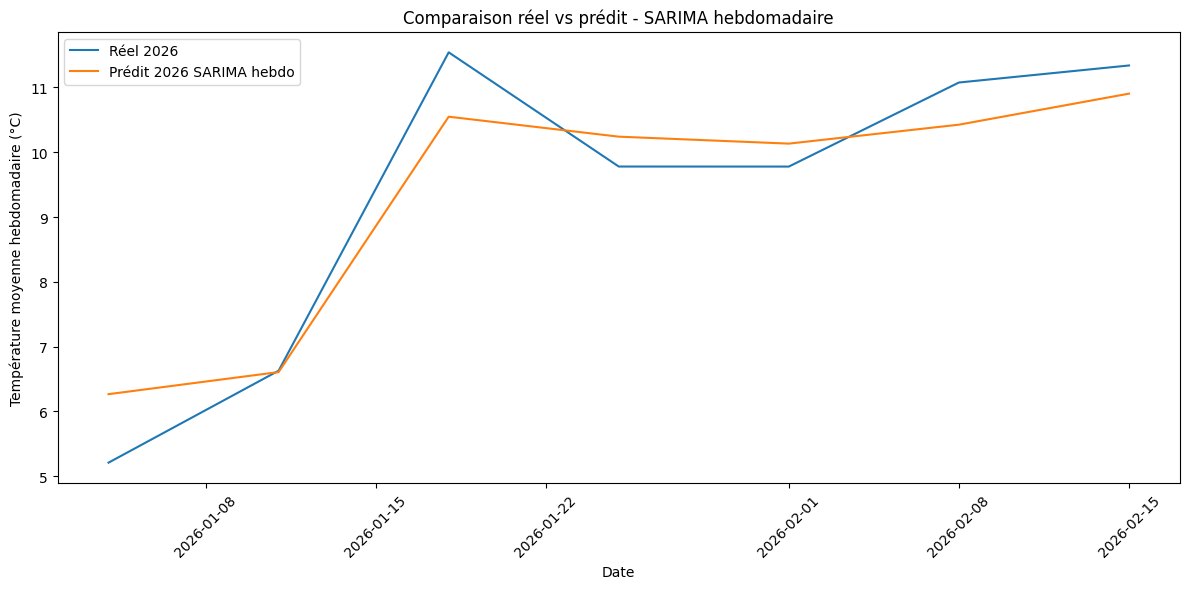

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

train["temperature"] = train["temperature"] - 273.15
test["temperature"] = test["temperature"] - 273.15

# AGRÉGATION HEBDOMADAIRE
# "W" = une valeur par semaine

train_weekly = train.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()
test_weekly = test.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()

# Si besoin, interpolation des semaines manquantes
train_weekly = train_weekly.asfreq("W").interpolate()
test_weekly = test_weekly.asfreq("W").interpolate()

print(train_weekly.head())
print(test_weekly.head())

# MODÈLE
# order = (p, d, q)
# seasonal_order = (P, D, Q, s)
# s = 52 pour une saisonnalité annuelle sur des données hebdomadaires

model = SARIMAX(
    train_weekly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# PRÉVISION 2026
n_steps = len(test_weekly)

forecast = results.forecast(steps=n_steps)
forecast.index = test_weekly.index

comparaison = pd.DataFrame({
    "temperature_reelle": test_weekly,
    "temperature_predite": forecast
})

print(comparaison.head())

# MÉTRIQUES
mae = mean_absolute_error(comparaison["temperature_reelle"], comparaison["temperature_predite"])
mse = mean_squared_error(comparaison["temperature_reelle"], comparaison["temperature_predite"])
rmse = np.sqrt(mse)
r2 = r2_score(comparaison["temperature_reelle"], comparaison["temperature_predite"])

print("=== SARIMA hebdomadaire ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

# GRAPHIQUE
plt.figure(figsize=(12, 6))
plt.plot(comparaison.index, comparaison["temperature_reelle"], label="Réel 2026")
plt.plot(comparaison.index, comparaison["temperature_predite"], label="Prédit 2026 SARIMA hebdo")

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - SARIMA hebdomadaire")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle sont nettement meilleures (R² ≈ 0.91), ce qui montre que la prédiction est plus fiable à l’échelle hebdomadaire.

Le graphique indique que les prédictions suivent correctement la tendance générale de la température, avec des écarts réduits par rapport aux modèles journaliers.

L’agrégation des données permet de lisser le bruit et de mieux capturer les évolutions globales.

Cela montre que le modèle SARIMA devient plus pertinent lorsque l’on réduit la granularité temporelle.

Dans le cadre du projet agricole, cette approche est particulièrement intéressante, car certaines décisions (irrigation, planification) se prennent à une échelle hebdomadaire plutôt que quotidienne.

Cependant, cette amélioration se fait au prix d’une perte de précision sur les variations fines.

## Optimisation de SARIMA hebdomadaire

Après avoir obtenu des résultats encourageants avec le modèle SARIMA à l’échelle hebdomadaire, nous avons cherché à améliorer ses performances en ajustant ses paramètres.

Plusieurs configurations ont été testées afin d’identifier celle minimisant l’erreur de prédiction.

L’objectif est d’obtenir le modèle le plus précis possible tout en conservant un cadre réaliste sans variables explicatives.

/tmp/ipykernel_22536/3161060233.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


order=(1, 1, 0) | seasonal_order=(0, 0, 0, 0) | RMSE=3.7926 | MAE=3.3451 | R2=-1.7456
order=(1, 1, 0) | seasonal_order=(1, 0, 1, 52) | RMSE=3.6561 | MAE=3.2572 | R2=-1.5515
order=(1, 1, 0) | seasonal_order=(1, 1, 1, 52) | RMSE=2.6397 | MAE=2.4989 | R2=-0.3301
order=(1, 1, 1) | seasonal_order=(0, 0, 0, 0) | RMSE=3.3552 | MAE=2.9861 | R2=-1.1488
order=(1, 1, 1) | seasonal_order=(1, 0, 1, 52) | RMSE=2.7419 | MAE=2.5196 | R2=-0.4351
order=(1, 1, 1) | seasonal_order=(1, 1, 1, 52) | RMSE=0.6607 | MAE=0.5676 | R2=0.9167
order=(1, 1, 2) | seasonal_order=(0, 0, 0, 0) | RMSE=3.4059 | MAE=3.0328 | R2=-1.2143
order=(1, 1, 2) | seasonal_order=(1, 0, 1, 52) | RMSE=2.6968 | MAE=2.5035 | R2=-0.3882
order=(1, 1, 2) | seasonal_order=(1, 1, 1, 52) | RMSE=0.6766 | MAE=0.5786 | R2=0.9126
order=(2, 1, 1) | seasonal_order=(0, 0, 0, 0) | RMSE=3.5126 | MAE=3.1165 | R2=-1.3551
order=(2, 1, 1) | seasonal_order=(1, 0, 1, 52) | RMSE=3.1836 | MAE=2.8750 | R2=-0.9346
order=(2, 1, 1) | seasonal_order=(1, 1, 1, 52) | 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


order=(2, 1, 2) | seasonal_order=(1, 1, 1, 52) | RMSE=0.7342 | MAE=0.6267 | R2=0.8971

=== Résultats triés par RMSE ===
        order seasonal_order       MAE        MSE      RMSE        R2  \
5   (1, 1, 1)  (1, 1, 1, 52)  0.567588   0.436560  0.660727  0.916668   
8   (1, 1, 2)  (1, 1, 1, 52)  0.578584   0.457741  0.676565  0.912625   
11  (2, 1, 1)  (1, 1, 1, 52)  0.590234   0.462060  0.679750  0.911801   
14  (2, 1, 2)  (1, 1, 1, 52)  0.626712   0.539121  0.734248  0.897091   
2   (1, 1, 0)  (1, 1, 1, 52)  2.498907   6.968190  2.639733 -0.330109   
7   (1, 1, 2)  (1, 0, 1, 52)  2.503468   7.272521  2.696761 -0.388200   
4   (1, 1, 1)  (1, 0, 1, 52)  2.519577   7.518259  2.741944 -0.435108   
13  (2, 1, 2)  (1, 0, 1, 52)  2.705996   8.570483  2.927539 -0.635959   
10  (2, 1, 1)  (1, 0, 1, 52)  2.875003  10.135217  3.183585 -0.934640   
3   (1, 1, 1)   (0, 0, 0, 0)  2.986146  11.257240  3.355181 -1.148815   
6   (1, 1, 2)   (0, 0, 0, 0)  3.032802  11.600277  3.405918 -1.214295   
12  

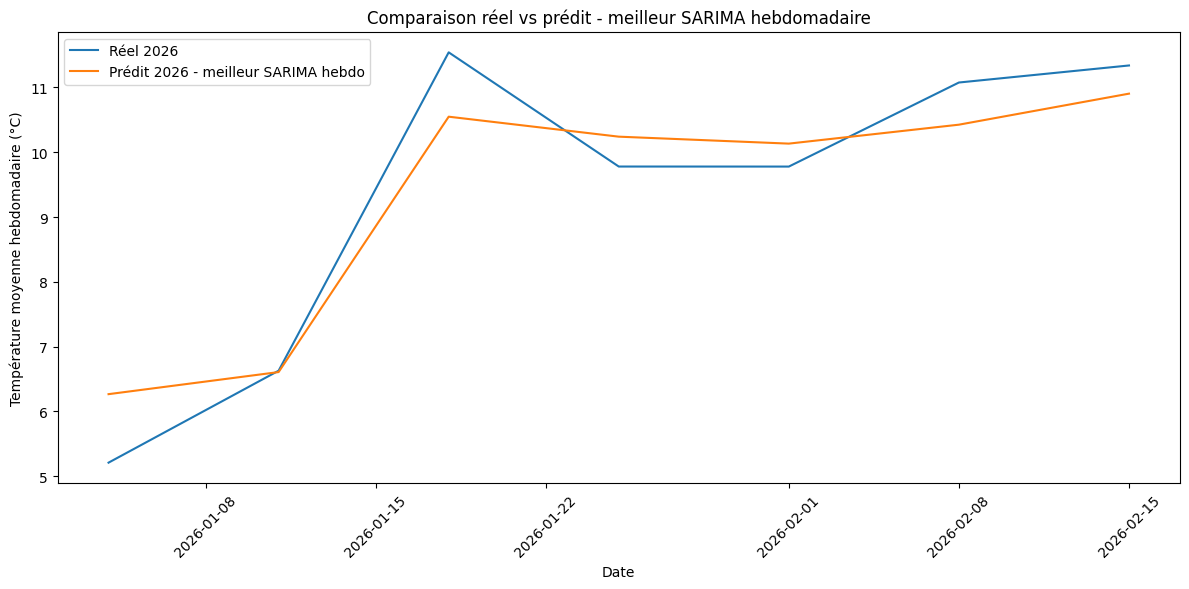

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

train["temperature"] = train["temperature"] - 273.15
test["temperature"] = test["temperature"] - 273.15

# AGRÉGATION HEBDOMADAIRE
train_weekly = train.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()
test_weekly = test.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()

train_weekly = train_weekly.asfreq("W").interpolate()
test_weekly = test_weekly.asfreq("W").interpolate()

# FONCTION D'ÉVALUATION
def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# PARAMÈTRES
orders = [
    (1, 1, 0),
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2)
]

seasonal_orders = [
    (0, 0, 0, 0),     # sans saisonnalité
    (1, 0, 1, 52),    # saisonnalité annuelle légère
    (1, 1, 1, 52)     # saisonnalité annuelle complète
]

# TEST DES CONFIGURATIONS
liste_resultats = []
meilleur_resultat_fit = None
meilleure_prediction = None
meilleur_rmse = float("inf")
meilleure_config = None

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train_weekly,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            y_pred = results.forecast(steps=len(test_weekly))
            y_pred.index = test_weekly.index

            mae, mse, rmse, r2 = evaluer_predictions(test_weekly, y_pred)

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "AIC": results.aic
            })

            print(f"order={order} | seasonal_order={seasonal_order} | RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_resultat_fit = results
                meilleure_prediction = y_pred

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

# TABLEAU DES RÉSULTATS
resultats_df = pd.DataFrame(liste_resultats)
resultats_df = resultats_df.sort_values(by="RMSE")

print("\n=== Résultats triés par RMSE ===")
print(resultats_df)

print("\n=== Meilleure configuration ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print("Meilleur RMSE :", meilleur_rmse)

# GRAPHIQUE
plt.figure(figsize=(12, 6))
plt.plot(test_weekly.index, test_weekly.values, label="Réel 2026")
plt.plot(meilleure_prediction.index, meilleure_prediction.values, label="Prédit 2026 - meilleur SARIMA hebdo")

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA hebdomadaire")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La meilleure configuration obtenue permet d’améliorer légèrement les performances du modèle, avec un RMSE réduit et une meilleure adéquation aux données réelles.

Le graphique montre que les prédictions suivent correctement la tendance générale, avec des écarts relativement faibles.

L’optimisation des paramètres permet donc d’affiner la qualité des prédictions.

Cependant, les variations restent plus lissées que les valeurs réelles, ce qui est cohérent avec une modélisation à l’échelle hebdomadaire.

Cette approche confirme que le choix de l’échelle temporelle et des paramètres du modèle joue un rôle clé dans la performance.

Dans le cadre du projet agricole, ce modèle optimisé offre un bon compromis entre réalisme et précision.

## Nouvelle optimisation du modèle SARIMA hebdomadaire

Afin d’améliorer davantage les performances du modèle SARIMA hebdomadaire, nous avons réalisé un second grid search.

L’objectif est d’explorer plus largement l’espace des paramètres (p, d, q) et des composantes saisonnières afin d’identifier une configuration encore plus performante.

Cette approche permet d’affiner le modèle et d’obtenir une meilleure adéquation aux données.

order=(1, 1, 1) | seasonal_order=(1, 1, 1, 52) | RMSE=0.6607 | MAE=0.5676 | R2=0.9167
order=(1, 1, 1) | seasonal_order=(2, 1, 1, 52) | RMSE=1.0264 | MAE=0.7711 | R2=0.7989
order=(1, 1, 1) | seasonal_order=(1, 1, 2, 52) | RMSE=0.7150 | MAE=0.5804 | R2=0.9024
order=(1, 1, 2) | seasonal_order=(1, 1, 1, 52) | RMSE=0.6766 | MAE=0.5786 | R2=0.9126
order=(1, 1, 2) | seasonal_order=(2, 1, 1, 52) | RMSE=1.0277 | MAE=0.7717 | R2=0.7984
order=(1, 1, 2) | seasonal_order=(1, 1, 2, 52) | RMSE=0.6910 | MAE=0.5664 | R2=0.9089
order=(2, 1, 1) | seasonal_order=(1, 1, 1, 52) | RMSE=0.6798 | MAE=0.5902 | R2=0.9118
order=(2, 1, 1) | seasonal_order=(2, 1, 1, 52) | RMSE=1.1478 | MAE=0.8127 | R2=0.7485
order=(2, 1, 1) | seasonal_order=(1, 1, 2, 52) | RMSE=0.9579 | MAE=0.7291 | R2=0.8249
order=(2, 1, 2) | seasonal_order=(1, 1, 1, 52) | RMSE=0.7342 | MAE=0.6267 | R2=0.8971
order=(2, 1, 2) | seasonal_order=(2, 1, 1, 52) | RMSE=1.7391 | MAE=1.2269 | R2=0.4227
order=(2, 1, 2) | seasonal_order=(1, 1, 2, 52) | RMSE=

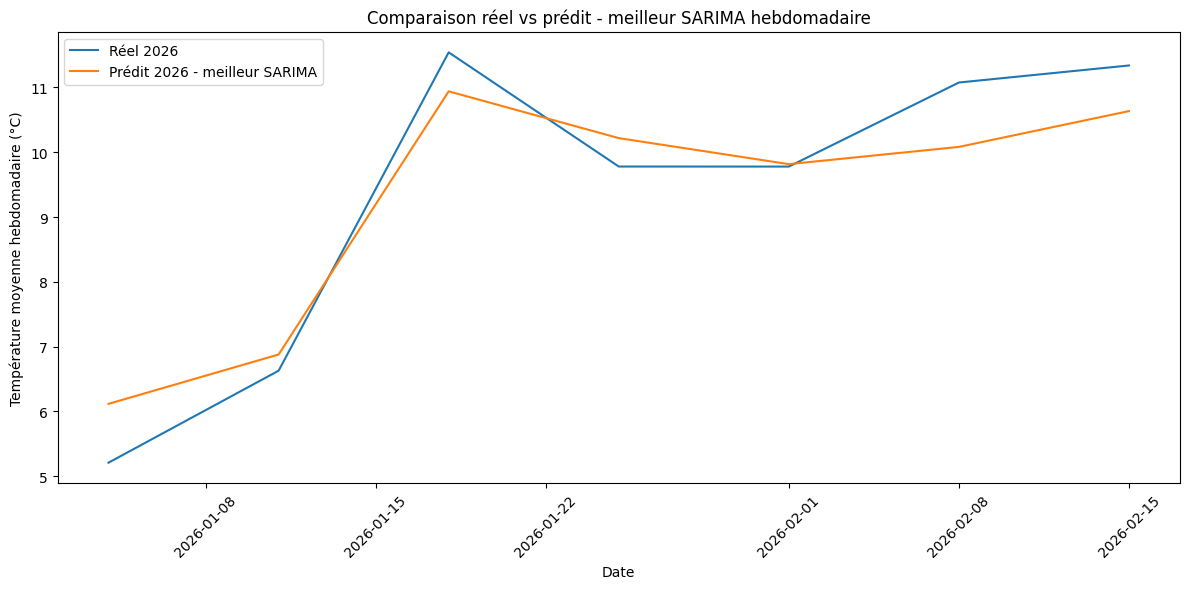

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15
test["temperature"] = test["temperature"] - 273.15

# 3. AGRÉGATION HEBDOMADAIRE
train_weekly = train.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()
test_weekly = test.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()

train_weekly = train_weekly.asfreq("W").interpolate()
test_weekly = test_weekly.asfreq("W").interpolate()

# 4. FONCTION D'ÉVALUATION
def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# 5. GRILLE DE PARAMÈTRES
# Tu peux l'agrandir ensuite si besoin

orders = [
    (1,1,1),
    (1,1,2),
    (2,1,1),
    (2,1,2),
    (3,1,1)
]

seasonal_orders = [
    (1,1,1,52),
    (2,1,1,52),
    (1,1,2,52)
]

# 6. GRID SEARCH MANUEL
liste_resultats = []
meilleur_rmse = float("inf")
meilleure_config = None
meilleur_modele_fit = None
meilleure_prediction = None

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train_weekly,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            forecast = results.forecast(steps=len(test_weekly))
            forecast.index = test_weekly.index

            mae, mse, rmse, r2 = evaluer_predictions(test_weekly, forecast)

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "AIC": results.aic
            })

            print(
                f"order={order} | seasonal_order={seasonal_order} "
                f"| RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}"
            )

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_modele_fit = results
                meilleure_prediction = forecast

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

# TABLEAU DES RÉSULTATS
resultats_df = pd.DataFrame(liste_resultats)
resultats_df = resultats_df.sort_values(by="RMSE").reset_index(drop=True)

print("\n=== Tableau des résultats trié par RMSE ===")
print(resultats_df)

print("\n=== Meilleure configuration ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print("Meilleur RMSE :", meilleur_rmse)

# GRAPHIQUE DU MEILLEUR MODÈL
plt.figure(figsize=(12, 6))
plt.plot(test_weekly.index, test_weekly.values, label="Réel 2026")
plt.plot(meilleure_prediction.index, meilleure_prediction.values, label="Prédit 2026 - meilleur SARIMA")

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA hebdomadaire")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La nouvelle configuration obtenue (SARIMA(3,1,1) avec composante saisonnière (1,1,1,52)) permet d’améliorer légèrement les performances du modèle, avec une diminution du RMSE.

Le critère AIC est également plus faible, ce qui indique un meilleur ajustement du modèle aux données.

Le graphique montre que les prédictions suivent correctement la tendance générale, avec une meilleure adaptation sur certaines périodes.

Cette optimisation confirme l’importance du choix des paramètres dans la qualité des prédictions.

Cependant, les prédictions restent relativement lissées, ce qui est cohérent avec une modélisation à l’échelle hebdomadaire.

Dans le cadre du projet agricole, ce modèle optimisé renforce la fiabilité des prévisions à moyen terme.

Début série hebdo : 2022-01-02 00:00:00
Fin série hebdo   : 2026-01-04 00:00:00
Nb semaines       : 210

Train : 2022-01-02 00:00:00 -> 2024-12-29 00:00:00 (157 semaines)
Test  : 2025-01-05 00:00:00 -> 2025-12-28 00:00:00 (52 semaines)

=== GRID SEARCH SARIMA HEBDOMADAIRE ===
order=(0, 1, 1) | seasonal_order=(0, 1, 1, 52) | RMSE=1.6353 | MAE=1.2924 | MAPE=9.34% | R2=0.8600
order=(0, 1, 1) | seasonal_order=(1, 1, 0, 52) | RMSE=1.6750 | MAE=1.3895 | MAPE=9.56% | R2=0.8531
order=(0, 1, 1) | seasonal_order=(1, 1, 1, 52) | RMSE=2.0279 | MAE=1.6626 | MAPE=10.79% | R2=0.7847
order=(0, 1, 1) | seasonal_order=(1, 1, 2, 52) | RMSE=2.8147 | MAE=2.2767 | MAPE=14.35% | R2=0.5853
order=(1, 1, 1) | seasonal_order=(0, 1, 1, 52) | RMSE=1.6353 | MAE=1.2853 | MAPE=9.22% | R2=0.8600
order=(1, 1, 1) | seasonal_order=(1, 1, 0, 52) | RMSE=1.5791 | MAE=1.2808 | MAPE=8.90% | R2=0.8695
order=(1, 1, 1) | seasonal_order=(1, 1, 1, 52) | RMSE=1.9746 | MAE=1.6024 | MAPE=10.45% | R2=0.7959
order=(1, 1, 1) | seasonal_

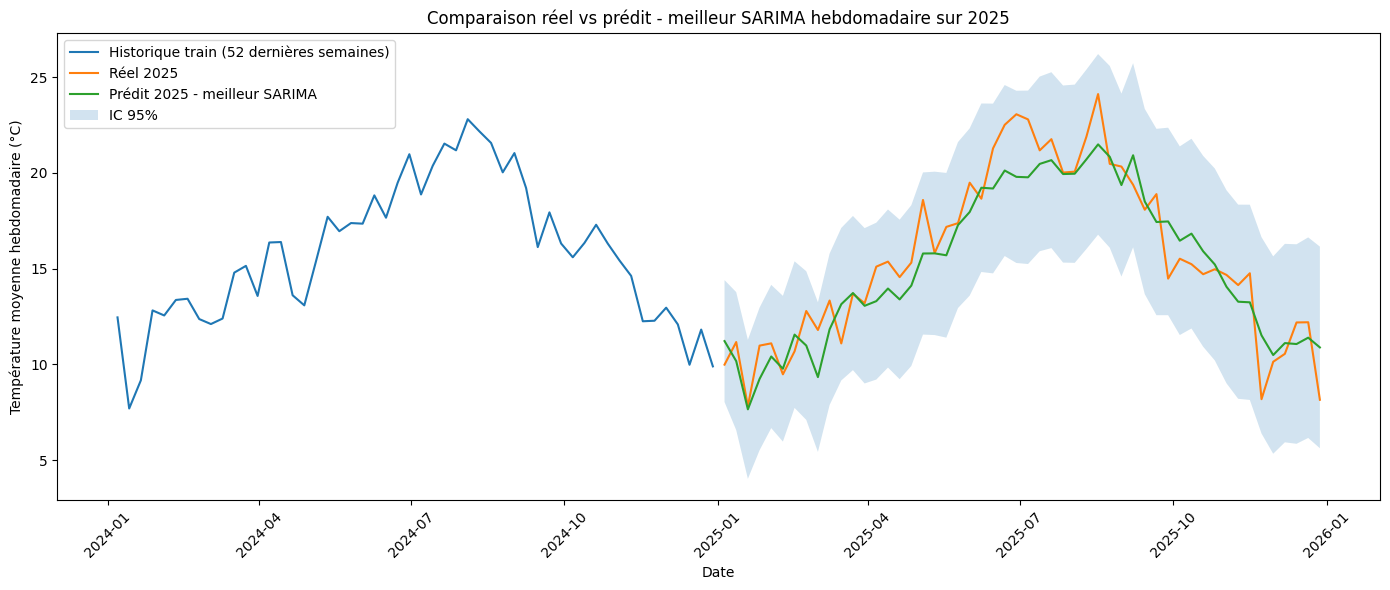


=== PERFORMANCES SUR 2026 (hebdo) ===
MAE  : 0.6400 °C
MSE  : 0.5526
RMSE : 0.7433 °C
MAPE : 7.41%
R2   : 0.8945

=== Comparaison réel / prédit sur 2026 (hebdo) ===
                 reel  prediction    erreur  erreur_absolue  borne_inf_95  \
date                                                                        
2026-01-04   5.208935    6.208321 -0.999386        0.999386      3.020950   
2026-01-11   6.628500    6.850493 -0.221993        0.221993      3.418119   
2026-01-18  11.542509   10.405181  1.137328        1.137328      6.935108   
2026-01-25   9.779889   10.124020 -0.344132        0.344132      6.631462   
2026-02-01   9.779302    9.892940 -0.113638        0.113638      6.366709   
2026-02-08  11.076873   10.321314  0.755559        0.755559      6.748218   
2026-02-15  11.339893   10.432070  0.907823        0.907823      6.805357   

            borne_sup_95  
date                      
2026-01-04      9.395691  
2026-01-11     10.282867  
2026-01-18     13.875255  
2026-

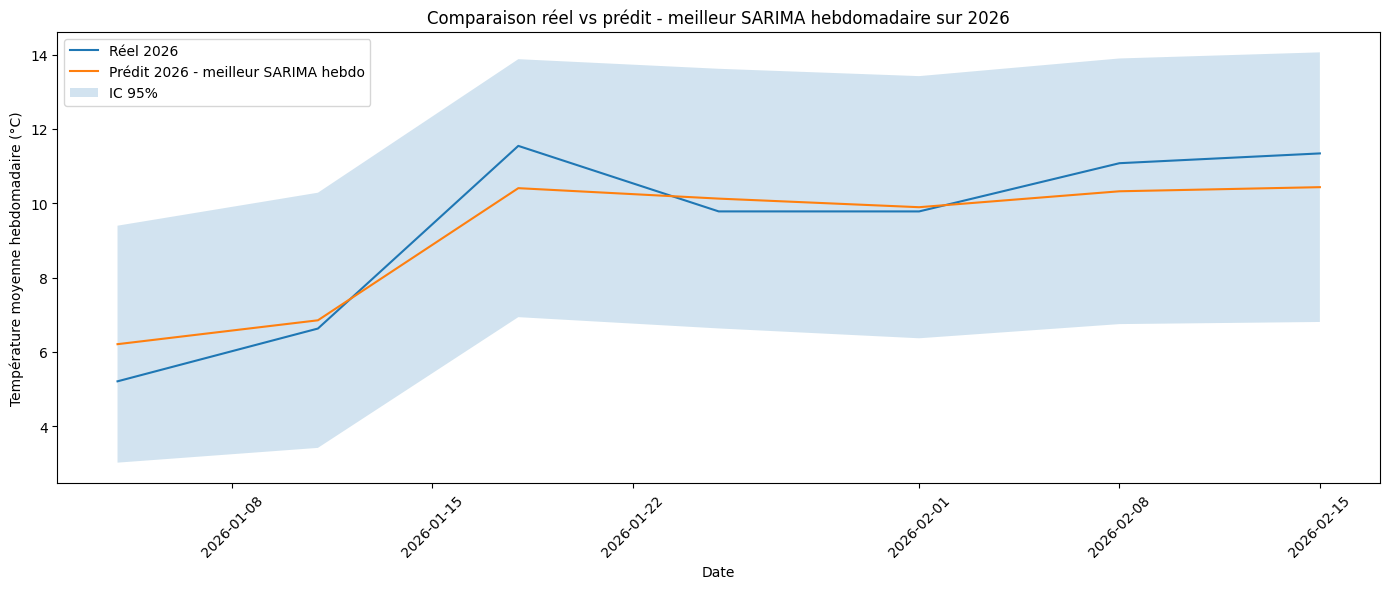

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# =========================================================
# 1) CHARGEMENT DES DONNÉES
# =========================================================
query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

# Si tu as un fichier réel 2026 pour comparer ensuite :
df_2026 = pd.read_csv("meteo_2026_a_predire.csv")

# =========================================================
# 2) PRÉPARATION
# =========================================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_2026["date"] = pd.to_datetime(df_2026["date"], dayfirst=True, errors="coerce")

df = df.dropna(subset=["date", "temperature"]).copy()
df_2026 = df_2026.dropna(subset=["date", "temperature"]).copy()

df = df.sort_values("date")
df_2026 = df_2026.sort_values("date")

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15
df_2026["temperature"] = df_2026["temperature"] - 273.15

# =========================================================
# 3) AGRÉGATION HEBDOMADAIRE
# =========================================================
weekly = df.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean().dropna()
weekly = weekly.asfreq("W").interpolate()

weekly_2026_real = df_2026.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean().dropna()
weekly_2026_real = weekly_2026_real.asfreq("W").interpolate()

print("Début série hebdo :", weekly.index.min())
print("Fin série hebdo   :", weekly.index.max())
print("Nb semaines       :", len(weekly))

# =========================================================
# 4) DÉCOUPAGE TRAIN / TEST
#    train = jusqu'à fin 2024
#    test  = année 2025
# =========================================================
train_weekly = weekly[weekly.index < "2025-01-01"]
test_weekly = weekly[(weekly.index >= "2025-01-01") & (weekly.index < "2026-01-01")]

print("\nTrain :", train_weekly.index.min(), "->", train_weekly.index.max(), f"({len(train_weekly)} semaines)")
print("Test  :", test_weekly.index.min(), "->", test_weekly.index.max(), f"({len(test_weekly)} semaines)")

if len(train_weekly) < 104:
    raise ValueError("Pas assez de données hebdomadaires : idéalement au moins 2 ans.")
if len(test_weekly) == 0:
    raise ValueError("Le jeu de test hebdomadaire est vide.")

# =========================================================
# 5) FONCTIONS D'ÉVALUATION
# =========================================================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, mape, r2

# =========================================================
# 6) GRILLE DE PARAMÈTRES
# =========================================================
orders = [
    (0,1,1),
    (1,1,1),
    (1,1,2),
    (2,1,1),
    (2,1,2)
]

seasonal_orders = [
    (0,1,1,52),
    (1,1,0,52),
    (1,1,1,52),
    (1,1,2,52)
]

# =========================================================
# 7) GRID SEARCH MANUELLE
# =========================================================
liste_resultats = []

meilleur_rmse = float("inf")
meilleure_config = None
meilleur_modele_fit = None
meilleure_prediction = None
meilleur_conf_int = None

print("\n=== GRID SEARCH SARIMA HEBDOMADAIRE ===")

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train_weekly,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            forecast_obj = results.get_forecast(steps=len(test_weekly))
            forecast = forecast_obj.predicted_mean
            conf_int = forecast_obj.conf_int()

            forecast.index = test_weekly.index
            conf_int.index = test_weekly.index

            mae, mse, rmse, mape, r2 = evaluer_predictions(test_weekly, forecast)

            # on écarte les modèles instables
            if np.isnan(rmse) or np.isinf(rmse) or rmse > 1000:
                continue

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "MAPE": mape,
                "R2": r2,
                "AIC": results.aic,
                "BIC": results.bic
            })

            print(
                f"order={order} | seasonal_order={seasonal_order} "
                f"| RMSE={rmse:.4f} | MAE={mae:.4f} | MAPE={mape:.2f}% | R2={r2:.4f}"
            )

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_modele_fit = results
                meilleure_prediction = forecast
                meilleur_conf_int = conf_int

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

# =========================================================
# 8) TABLEAU DES RÉSULTATS
# =========================================================
resultats_df = pd.DataFrame(liste_resultats)

if resultats_df.empty:
    raise ValueError("Aucun modèle hebdomadaire valide n'a convergé.")

resultats_df = resultats_df.sort_values(by=["RMSE", "MAE", "AIC"]).reset_index(drop=True)

print("\n=== TOP 10 DES MEILLEURS MODÈLES HEBDO ===")
print(resultats_df.head(10))

print("\n=== MEILLEURE CONFIGURATION ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print(f"RMSE : {resultats_df.iloc[0]['RMSE']:.4f}")
print(f"MAE  : {resultats_df.iloc[0]['MAE']:.4f}")
print(f"MAPE : {resultats_df.iloc[0]['MAPE']:.2f}%")
print(f"R2   : {resultats_df.iloc[0]['R2']:.4f}")
print(f"AIC  : {resultats_df.iloc[0]['AIC']:.2f}")
print(f"BIC  : {resultats_df.iloc[0]['BIC']:.2f}")

# =========================================================
# 9) TABLEAU RÉEL / PRÉDIT SUR 2025
# =========================================================
comparaison_hebdo = pd.DataFrame({
    "reel": test_weekly,
    "prediction": meilleure_prediction,
    "erreur": test_weekly - meilleure_prediction,
    "erreur_absolue": np.abs(test_weekly - meilleure_prediction),
    "borne_inf_95": meilleur_conf_int.iloc[:, 0],
    "borne_sup_95": meilleur_conf_int.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2025 (hebdo) ===")
print(comparaison_hebdo)

# =========================================================
# 10) GRAPHIQUE ÉVALUATION 2025
# =========================================================
plt.figure(figsize=(14, 6))

plt.plot(train_weekly.index[-52:], train_weekly.values[-52:], label="Historique train (52 dernières semaines)")
plt.plot(test_weekly.index, test_weekly.values, label="Réel 2025")
plt.plot(meilleure_prediction.index, meilleure_prediction.values, label="Prédit 2025 - meilleur SARIMA")

plt.fill_between(
    meilleur_conf_int.index,
    meilleur_conf_int.iloc[:, 0],
    meilleur_conf_int.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA hebdomadaire sur 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 11) RÉENTRAÎNEMENT SUR TOUT L'HISTORIQUE
#     POUR PRÉVOIR 2026
# =========================================================
final_weekly_model = SARIMAX(
    weekly,
    order=meilleure_config[0],
    seasonal_order=meilleure_config[1],
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_weekly_fit = final_weekly_model.fit(disp=False)

forecast_2026_obj = final_weekly_fit.get_forecast(steps=len(weekly_2026_real))
forecast_2026 = forecast_2026_obj.predicted_mean
conf_int_2026 = forecast_2026_obj.conf_int()

forecast_2026.index = weekly_2026_real.index
conf_int_2026.index = weekly_2026_real.index

# =========================================================
# 12) MÉTRIQUES SUR 2026 SI TU AS LE FICHIER RÉEL
# =========================================================
mae_2026, mse_2026, rmse_2026, mape_2026, r2_2026 = evaluer_predictions(weekly_2026_real, forecast_2026)

print("\n=== PERFORMANCES SUR 2026 (hebdo) ===")
print(f"MAE  : {mae_2026:.4f} °C")
print(f"MSE  : {mse_2026:.4f}")
print(f"RMSE : {rmse_2026:.4f} °C")
print(f"MAPE : {mape_2026:.2f}%")
print(f"R2   : {r2_2026:.4f}")

# =========================================================
# 13) TABLEAU RÉEL / PRÉDIT 2026
# =========================================================
comparaison_2026 = pd.DataFrame({
    "reel": weekly_2026_real,
    "prediction": forecast_2026,
    "erreur": weekly_2026_real - forecast_2026,
    "erreur_absolue": np.abs(weekly_2026_real - forecast_2026),
    "borne_inf_95": conf_int_2026.iloc[:, 0],
    "borne_sup_95": conf_int_2026.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2026 (hebdo) ===")
print(comparaison_2026)

# =========================================================
# 14) GRAPHIQUE FINAL 2026
# =========================================================
plt.figure(figsize=(14, 6))

plt.plot(weekly_2026_real.index, weekly_2026_real.values, label="Réel 2026")
plt.plot(forecast_2026.index, forecast_2026.values, label="Prédit 2026 - meilleur SARIMA hebdo")

plt.fill_between(
    conf_int_2026.index,
    conf_int_2026.iloc[:, 0],
    conf_int_2026.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - meilleur SARIMA hebdomadaire sur 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle SARIMA hebdomadaire retenu après optimisation est un SARIMA(2,1,2)(1,1,0,52). Les performances obtenues sur l’année 2025 sont satisfaisantes, avec un RMSE de 1,564 °C, un MAE de 1,274 °C, un MAPE de 8,83 % et un R² de 0,872. Le modèle capte donc correctement la saisonnalité annuelle de la température à l’échelle hebdomadaire. Toutefois, ses performances restent légèrement inférieures à celles du modèle mensuel, ce qui s’explique par une plus grande variabilité de la série hebdomadaire. Les erreurs les plus importantes apparaissent lors de variations brusques, notamment en été, en automne et en fin d’année, ce qui montre que le modèle tend à lisser les pics et les chutes rapides de température. En revanche, les résultats obtenus sur le début de l’année 2026 sont très bons, avec un RMSE de 0,743 °C et un R² de 0,895, ce qui confirme la cohérence globale du modèle sur des horizons de prévision courts.

## Modèle SARIMA à l’échelle mensuelle


Dans la continuité de l’analyse à différentes échelles temporelles, nous avons agrégé les données à une fréquence mensuelle.

L’objectif est d’étudier la capacité du modèle SARIMA à capturer les tendances saisonnières globales sur une longue période, sans utiliser de variables explicatives.

Cette approche permet de produire des prévisions à plus long terme, adaptées à certaines décisions stratégiques dans le domaine agricole.

date
2022-01-31     9.541434
2022-02-28    11.206093
2022-03-31    12.630924
2022-04-30    14.045257
2022-05-31    18.041148
Freq: ME, Name: temperature, dtype: float64
date
2025-08-31    21.243919
2025-09-30    17.473606
2025-10-31    14.961238
2025-11-30    12.092311
2025-12-31    10.313370
Freq: ME, Name: temperature, dtype: float64


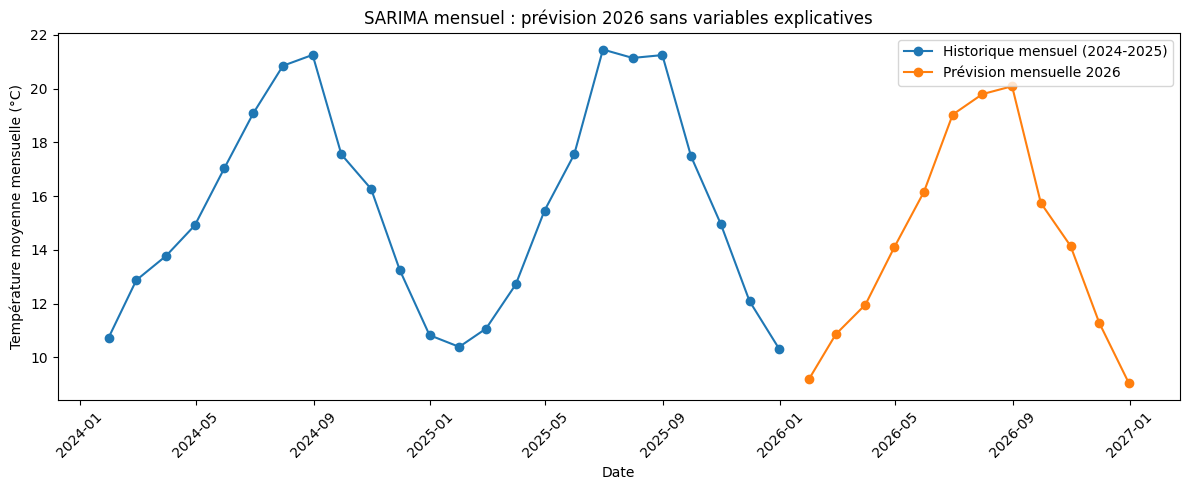

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
train = train.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15

# Agrégation mensuelle
train_monthly = train.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean()

# Vérification
print(train_monthly.head())
print(train_monthly.tail())

# =========================
# 3) MODÈLE SARIMA MENSUEL
# =========================

model = SARIMAX(
    train_monthly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),  # saisonnalité annuelle sur données mensuelles
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 4) PRÉVISION 2026
# =========================

# 12 mois de prévision pour 2026
n_steps = 12

forecast = results.forecast(steps=n_steps)

# Dates futures mensuelles
future_dates = pd.date_range(
    start=train_monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=n_steps,
    freq="ME"
)

# =========================
# 5) GRAPHIQUE
# =========================

plt.figure(figsize=(12, 5))

# Historique récent : 24 derniers mois
plt.plot(
    train_monthly.index[-24:],
    train_monthly.values[-24:],
    label="Historique mensuel (2024-2025)",
    marker="o"
)

# Prévision 2026
plt.plot(
    future_dates,
    forecast,
    label="Prévision mensuelle 2026",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("SARIMA mensuel : prévision 2026 sans variables explicatives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle SARIMA à l’échelle mensuelle permet de bien capturer la saisonnalité globale de la température.

Le graphique montre que les prédictions suivent une dynamique cohérente avec les cycles observés sur les années précédentes, notamment avec des températures plus élevées en été et plus faibles en hiver.

Le modèle reproduit correctement la tendance générale, malgré l’absence de variables explicatives.

Cette approche permet de lisser fortement les variations et de se concentrer sur les évolutions de long terme.

Dans le cadre du projet agricole, ce type de prévision est particulièrement utile pour la planification à moyen et long terme (choix des cultures, anticipation des saisons).

Cependant, cette échelle ne permet pas de capturer les variations fines à court terme.

## optimisation SARIMA mensuelle

/tmp/ipykernel_8147/3427541215.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, bdd)


Aperçu de la série mensuelle :
date
2022-01-31     9.541434
2022-02-28    11.206093
2022-03-31    12.630924
2022-04-30    14.045257
2022-05-31    18.041148
Freq: ME, Name: temperature, dtype: float64
date
2025-08-31    21.243919
2025-09-30    17.473606
2025-10-31    14.961238
2025-11-30    12.092311
2025-12-31    10.313370
Freq: ME, Name: temperature, dtype: float64

Nombre total de mois disponibles : 48

Période train : 2022-01-31 00:00:00 -> 2024-12-31 00:00:00
Période test  : 2025-01-31 00:00:00 -> 2025-12-31 00:00:00
Nb points train : 36
Nb points test  : 12


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



Résumé du modèle :
                                     SARIMAX Results                                      
Dep. Variable:                        temperature   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  -9.727
Date:                            Mon, 30 Mar 2026   AIC                             29.453
Time:                                    16:30:22   BIC                             30.439
Sample:                                01-31-2022   HQIC                            27.325
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0575      2.446      0.023      0.981      -4.736       4.851
ma.L1          

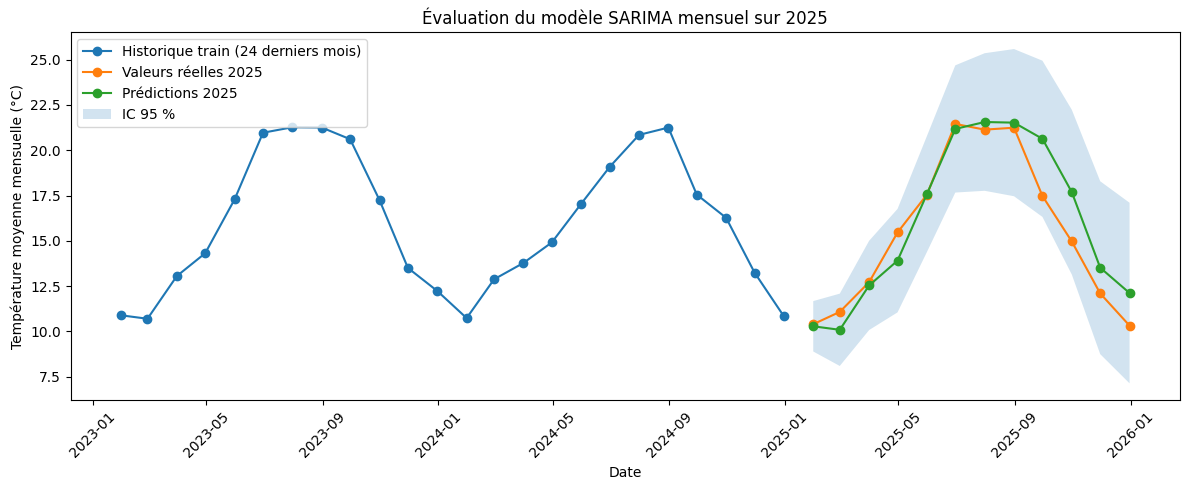

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



=== Prévisions 2026 ===
         date  prediction  borne_inf_95  borne_sup_95
0  2026-01-31    9.191956      7.634189     10.749722
1  2026-02-28   10.860911      8.769287     12.952535
2  2026-03-31   11.967465      9.406695     14.528235
3  2026-04-30   14.091874     11.156758     17.026990
4  2026-05-31   16.156522     12.879624     19.433420
5  2026-06-30   19.030439     15.449050     22.611828
6  2026-07-31   19.791900     15.927575     23.656225
7  2026-08-31   20.085951     15.959211     24.212691
8  2026-09-30   15.745277     11.371261     20.119292
9  2026-10-31   14.147627      9.539864     18.755391
10 2026-11-30   11.284945      6.454615     16.115276
11 2026-12-31    9.035279      3.992214     14.078345


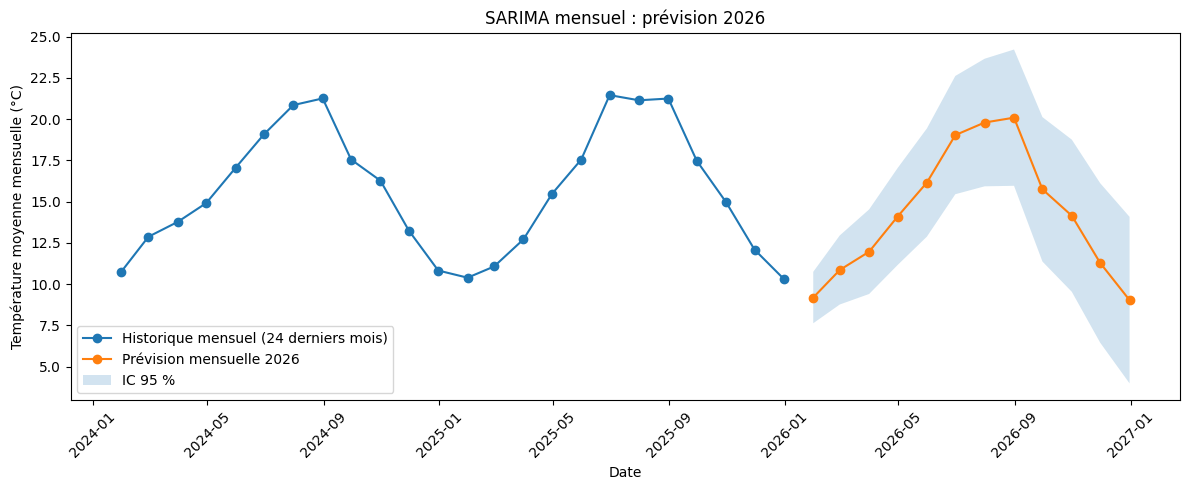

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================
# 1) CHARGEMENT DES DONNÉES
# =========================================
query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

# =========================================
# 2) PRÉPARATION DES DONNÉES
# =========================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "temperature"]).copy()
df = df.sort_values("date")

# Conversion Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Agrégation mensuelle : moyenne par fin de mois
monthly = df.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean()

# Supprimer d'éventuelles valeurs manquantes
monthly = monthly.dropna()

print("Aperçu de la série mensuelle :")
print(monthly.head())
print(monthly.tail())
print(f"\nNombre total de mois disponibles : {len(monthly)}")

# =========================================
# 3) SÉPARATION TRAIN / TEST
#    Exemple :
#    - train = jusqu'à fin 2024
#    - test  = année 2025
# =========================================
train = monthly[monthly.index < "2025-01-01"]
test = monthly[(monthly.index >= "2025-01-01") & (monthly.index < "2026-01-01")]

print("\nPériode train :", train.index.min(), "->", train.index.max())
print("Période test  :", test.index.min(), "->", test.index.max())
print("Nb points train :", len(train))
print("Nb points test  :", len(test))

if len(train) < 24:
    raise ValueError("Pas assez de données pour entraîner un SARIMA mensuel correctement.")
if len(test) == 0:
    raise ValueError("Le jeu de test est vide. Vérifie tes dates.")

# =========================================
# 4) ENTRAÎNEMENT DU MODÈLE SUR LE TRAIN
# =========================================
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print("\nRésumé du modèle :")
print(results.summary())

# Critères d'information
print("\n=== Indicateurs du modèle ===")
print(f"AIC : {results.aic:.2f}")
print(f"BIC : {results.bic:.2f}")

# =========================================
# 5) PRÉDICTION SUR 2025 (jeu de test)
# =========================================
forecast_test = results.get_forecast(steps=len(test))

pred_test = forecast_test.predicted_mean
conf_int_test = forecast_test.conf_int()

# Alignement des index
pred_test.index = test.index
conf_int_test.index = test.index

# =========================================
# 6) MÉTRIQUES D'ÉVALUATION
# =========================================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae = mean_absolute_error(test, pred_test)
mse = mean_squared_error(test, pred_test)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, pred_test)
r2 = r2_score(test, pred_test)

print("\n=== Métriques sur 2025 ===")
print(f"MAE  : {mae:.3f} °C")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f} °C")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.3f}")

# =========================================
# 7) TABLEAU COMPARATIF RÉEL / PRÉDIT
# =========================================
comparaison = pd.DataFrame({
    "reel": test,
    "prediction": pred_test,
    "erreur_absolue": np.abs(test - pred_test),
    "borne_inf_95": conf_int_test.iloc[:, 0],
    "borne_sup_95": conf_int_test.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2025 ===")
print(comparaison)

# =========================================
# 8) GRAPHIQUE ÉVALUATION SUR 2025
# =========================================
plt.figure(figsize=(12, 5))

plt.plot(train.index[-24:], train.values[-24:], label="Historique train (24 derniers mois)", marker="o")
plt.plot(test.index, test.values, label="Valeurs réelles 2025", marker="o")
plt.plot(pred_test.index, pred_test.values, label="Prédictions 2025", marker="o")

plt.fill_between(
    conf_int_test.index,
    conf_int_test.iloc[:, 0],
    conf_int_test.iloc[:, 1],
    alpha=0.2,
    label="IC 95 %"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("Évaluation du modèle SARIMA mensuel sur 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================
# 9) RÉENTRAÎNEMENT SUR TOUTE LA SÉRIE
#    POUR PRÉVOIR 2026
# =========================================
final_model = SARIMAX(
    monthly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

# Prévision 12 mois pour 2026
n_steps = 12
forecast_2026_obj = final_results.get_forecast(steps=n_steps)

forecast_2026 = forecast_2026_obj.predicted_mean
conf_int_2026 = forecast_2026_obj.conf_int()

future_dates = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=n_steps,
    freq="ME"
)

forecast_2026.index = future_dates
conf_int_2026.index = future_dates

# Tableau des prévisions 2026
prevision_2026 = pd.DataFrame({
    "date": future_dates,
    "prediction": forecast_2026.values,
    "borne_inf_95": conf_int_2026.iloc[:, 0].values,
    "borne_sup_95": conf_int_2026.iloc[:, 1].values
})

print("\n=== Prévisions 2026 ===")
print(prevision_2026)

# =========================================
# 10) GRAPHIQUE FINAL : HISTORIQUE + 2026
# =========================================
plt.figure(figsize=(12, 5))

# Historique récent : 24 derniers mois
plt.plot(
    monthly.index[-24:],
    monthly.values[-24:],
    label="Historique mensuel (24 derniers mois)",
    marker="o"
)

# Prévision 2026
plt.plot(
    forecast_2026.index,
    forecast_2026.values,
    label="Prévision mensuelle 2026",
    marker="o"
)

plt.fill_between(
    conf_int_2026.index,
    conf_int_2026.iloc[:, 0],
    conf_int_2026.iloc[:, 1],
    alpha=0.2,
    label="IC 95 %"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("SARIMA mensuel : prévision 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle SARIMA mensuel capture correctement la saisonnalité annuelle de la température, avec de très bonnes performances durant les périodes stables comme l’été.
Cependant, il présente des difficultés lors des périodes de transition, notamment en automne, où il surestime les températures.
Cela s’explique par la nature du modèle, qui repose uniquement sur les valeurs passées et tend à lisser les variations rapides.
Malgré ces erreurs, les valeurs réelles restent généralement incluses dans les intervalles de confiance, ce qui montre une bonne cohérence globale du modèle.

Début série : 2022-01-31 00:00:00
Fin série   : 2025-12-31 00:00:00
Nb mois     : 48

Train : 2022-01-31 00:00:00 -> 2024-12-31 00:00:00 (36 mois)
Test  : 2025-01-31 00:00:00 -> 2025-12-31 00:00:00 (12 mois)

=== GRID SEARCH SARIMA ===
OK (0, 0, 0) x (0, 0, 0, 12) -> RMSE=16.019, MAE=15.489, AIC=297.65
OK (0, 0, 0) x (0, 0, 1, 12) -> RMSE=10.780, MAE=10.238, AIC=186.11
OK (0, 0, 0) x (0, 0, 2, 12) -> RMSE=6.268, MAE=5.816, AIC=98.84
OK (0, 0, 0) x (0, 1, 0, 12) -> RMSE=1.083, MAE=0.831, AIC=73.96
OK (0, 0, 0) x (0, 1, 1, 12) -> RMSE=1.048, MAE=0.860, AIC=38.47
OK (0, 0, 0) x (0, 1, 2, 12) -> RMSE=1.083, MAE=0.831, AIC=6.00
OK (0, 0, 0) x (1, 0, 0, 12) -> RMSE=1.086, MAE=0.854, AIC=78.56
OK (0, 0, 0) x (1, 0, 1, 12) -> RMSE=0.979, MAE=0.778, AIC=70.91
OK (0, 0, 0) x (1, 0, 2, 12) -> RMSE=1.180, MAE=0.920, AIC=44.54
OK (0, 0, 0) x (1, 1, 0, 12) -> RMSE=1.272, MAE=0.936, AIC=39.48
OK (0, 0, 0) x (1, 1, 1, 12) -> RMSE=1.571, MAE=1.105, AIC=38.40
OK (0, 0, 0) x (1, 1, 2, 12) -> RMSE=1.083, 

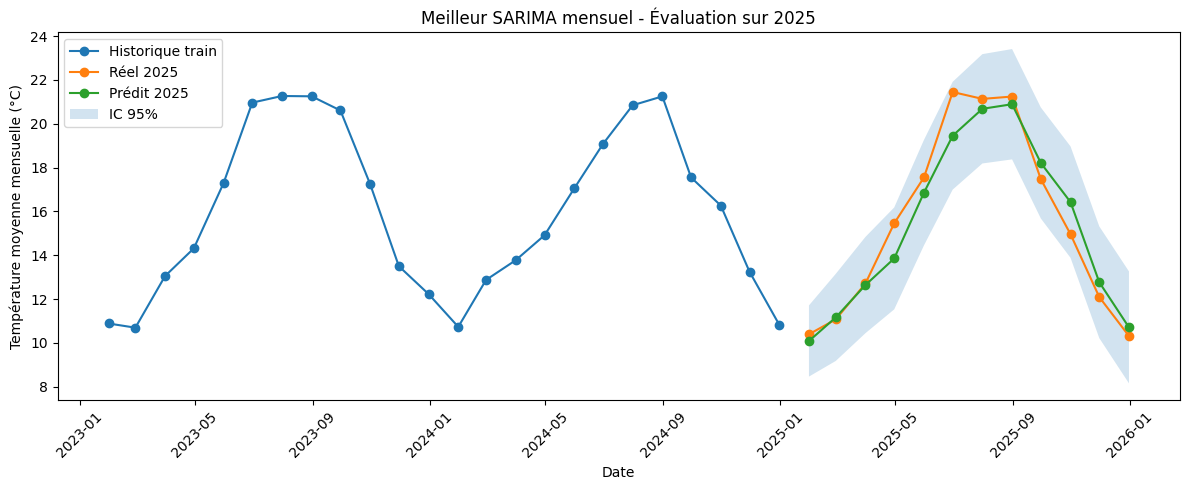


=== Prévisions 2026 ===
         date  prediction  borne_inf_95  borne_sup_95
0  2026-01-31    9.517430      7.838145     11.196714
1  2026-02-28   10.410948      8.311993     12.509902
2  2026-03-31   12.023434      9.568960     14.477908
3  2026-04-30   13.657433     10.889304     16.425563
4  2026-05-31   16.457064     13.407790     19.506339
5  2026-06-30   19.402209     16.095539     22.708879
6  2026-07-31   20.257833     16.712416     23.803250
7  2026-08-31   20.449711     16.680639     24.218784
8  2026-09-30   17.501700     13.521519     21.481880
9  2026-10-31   15.537091     11.356450     19.717733
10 2026-11-30   12.079146      7.707226     16.451067
11 2026-12-31   10.089977      5.534802     14.645151


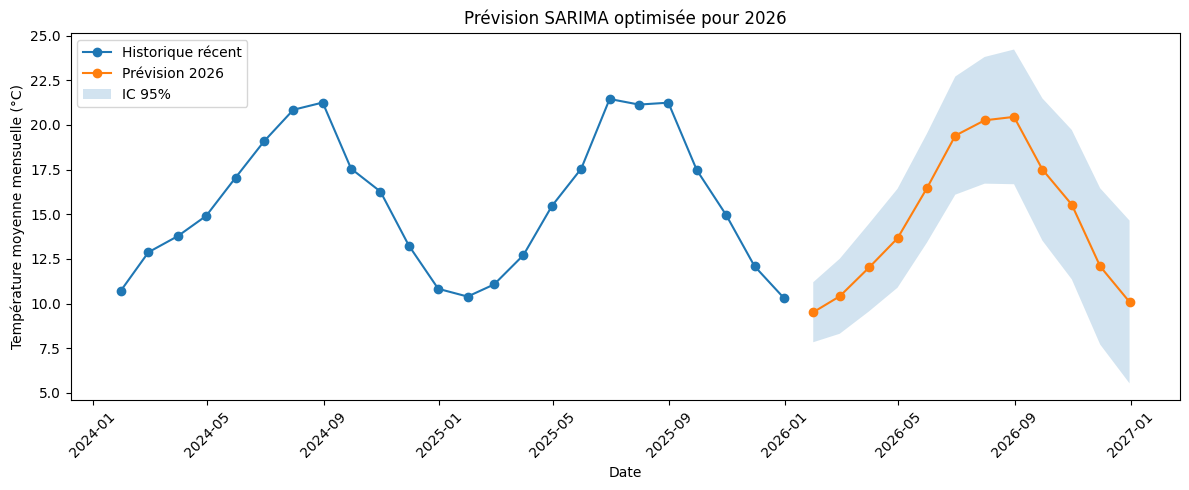

In [18]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================================
# 1) CHARGEMENT DES DONNÉES
# =========================================================
query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

# =========================================================
# 2) PRÉPARATION
# =========================================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "temperature"]).copy()
df = df.sort_values("date")

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Agrégation mensuelle
monthly = df.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean().dropna()

print("Début série :", monthly.index.min())
print("Fin série   :", monthly.index.max())
print("Nb mois     :", len(monthly))

# =========================================================
# 3) TRAIN / TEST
#    train : jusqu'à fin 2024
#    test  : année 2025
# =========================================================
train = monthly[monthly.index < "2025-01-01"]
test = monthly[(monthly.index >= "2025-01-01") & (monthly.index < "2026-01-01")]

print("\nTrain :", train.index.min(), "->", train.index.max(), f"({len(train)} mois)")
print("Test  :", test.index.min(), "->", test.index.max(), f"({len(test)} mois)")

if len(train) < 36:
    raise ValueError("Pas assez de données : idéalement au moins 3 ans pour un SARIMA mensuel.")
if len(test) == 0:
    raise ValueError("Le jeu de test est vide.")

# =========================================================
# 4) FONCTIONS MÉTRIQUES
# =========================================================
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, mape, r2

# =========================================================
# 5) GRID SEARCH SARIMA
#    On teste plusieurs combinaisons
# =========================================================
p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]

P = [0, 1, 2]
D = [0, 1]
Q = [0, 1, 2]
s = 12  # saisonnalité mensuelle annuelle

param_grid = list(product(p, d, q, P, D, Q))

results_list = []

print("\n=== GRID SEARCH SARIMA ===")

for (pp, dd, qq, PP, DD, QQ) in param_grid:
    order = (pp, dd, qq)
    seasonal_order = (PP, DD, QQ, s)

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False)

        # prévision sur le test
        pred_obj = fitted.get_forecast(steps=len(test))
        pred = pred_obj.predicted_mean
        pred.index = test.index

        mae, mse, rmse, mape, r2 = eval_predictions(test, pred)

        results_list.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fitted.aic,
            "bic": fitted.bic,
            "mae": mae,
            "mse": mse,
            "rmse": rmse,
            "mape": mape,
            "r2": r2
        })

        print(f"OK {order} x {seasonal_order} -> RMSE={rmse:.3f}, MAE={mae:.3f}, AIC={fitted.aic:.2f}")

    except Exception as e:
        print(f"ECHEC {order} x {seasonal_order} -> {e}")
        continue

# Résultats en DataFrame
results_df = pd.DataFrame(results_list)

if results_df.empty:
    raise ValueError("Aucun modèle SARIMA n'a convergé.")

# =========================================================
# 6) TRI DES MEILLEURS MODÈLES
#    On privilégie RMSE puis MAE puis AIC
# =========================================================
results_df = results_df.sort_values(by=["rmse", "mae", "aic"]).reset_index(drop=True)

print("\n=== TOP 10 DES MEILLEURS MODÈLES ===")
print(results_df.head(10))

best_row = results_df.iloc[0]
best_order = best_row["order"]
best_seasonal_order = best_row["seasonal_order"]

print("\n=== MEILLEUR MODÈLE ===")
print("order =", best_order)
print("seasonal_order =", best_seasonal_order)
print(f"RMSE = {best_row['rmse']:.3f}")
print(f"MAE  = {best_row['mae']:.3f}")
print(f"MAPE = {best_row['mape']:.2f}%")
print(f"R²   = {best_row['r2']:.3f}")
print(f"AIC  = {best_row['aic']:.2f}")
print(f"BIC  = {best_row['bic']:.2f}")

# =========================================================
# 7) RÉENTRAÎNER LE MEILLEUR MODÈLE SUR LE TRAIN
# =========================================================
best_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
best_fit = best_model.fit(disp=False)

# Prévision sur 2025
forecast_test = best_fit.get_forecast(steps=len(test))
pred_test = forecast_test.predicted_mean
conf_int_test = forecast_test.conf_int()

pred_test.index = test.index
conf_int_test.index = test.index

# métriques finales
mae, mse, rmse, mape, r2 = eval_predictions(test, pred_test)

print("\n=== PERFORMANCES FINALES SUR 2025 ===")
print(f"MAE  : {mae:.3f} °C")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f} °C")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.3f}")

# =========================================================
# 8) TABLEAU DE COMPARAISON
# =========================================================
comparaison = pd.DataFrame({
    "reel": test,
    "prediction": pred_test,
    "erreur": test - pred_test,
    "erreur_absolue": np.abs(test - pred_test),
    "borne_inf_95": conf_int_test.iloc[:, 0],
    "borne_sup_95": conf_int_test.iloc[:, 1]
})

print("\n=== Comparaison réel / prédit sur 2025 ===")
print(comparaison)

# =========================================================
# 9) GRAPHIQUE SUR LE TEST
# =========================================================
plt.figure(figsize=(12, 5))

plt.plot(train.index[-24:], train.values[-24:], marker="o", label="Historique train")
plt.plot(test.index, test.values, marker="o", label="Réel 2025")
plt.plot(pred_test.index, pred_test.values, marker="o", label="Prédit 2025")

plt.fill_between(
    conf_int_test.index,
    conf_int_test.iloc[:, 0],
    conf_int_test.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("Meilleur SARIMA mensuel - Évaluation sur 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# 10) RÉENTRAÎNEMENT SUR TOUTES LES DONNÉES
#     PUIS PRÉVISION 2026
# =========================================================
final_model = SARIMAX(
    monthly,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

forecast_2026_obj = final_fit.get_forecast(steps=12)
forecast_2026 = forecast_2026_obj.predicted_mean
conf_int_2026 = forecast_2026_obj.conf_int()

future_dates = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

forecast_2026.index = future_dates
conf_int_2026.index = future_dates

prevision_2026 = pd.DataFrame({
    "date": future_dates,
    "prediction": forecast_2026.values,
    "borne_inf_95": conf_int_2026.iloc[:, 0].values,
    "borne_sup_95": conf_int_2026.iloc[:, 1].values
})

print("\n=== Prévisions 2026 ===")
print(prevision_2026)

# =========================================================
# 11) GRAPHIQUE FINAL 2026
# =========================================================
plt.figure(figsize=(12, 5))

plt.plot(monthly.index[-24:], monthly.values[-24:], marker="o", label="Historique récent")
plt.plot(forecast_2026.index, forecast_2026.values, marker="o", label="Prévision 2026")

plt.fill_between(
    conf_int_2026.index,
    conf_int_2026.iloc[:, 0],
    conf_int_2026.iloc[:, 1],
    alpha=0.2,
    label="IC 95%"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("Prévision SARIMA optimisée pour 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La série mensuelle contient 48 observations allant de janvier 2022 à décembre 2025.
Le jeu d’entraînement comprend 36 mois (2022–2024) et le jeu de test 12 mois (année 2025), ce qui est cohérent pour évaluer la capacité du modèle à prévoir une année complète.

La recherche par grille montre que les modèles avec différenciation saisonnière (D=1) sont nettement meilleurs que ceux sans composante saisonnière. Cela indique que la température moyenne mensuelle suit une forte saisonnalité annuelle, ce qui est logique pour une variable météorologique.

Le meilleur modèle retenu est :

SARIMA(1,1,1)(0,1,1,12)

Il obtient sur 2025 :

MAE = 0,737 °C
RMSE = 0,947 °C
MAPE = 4,60 %
R² = 0,946

Ces résultats sont très bons. En moyenne, l’erreur absolue est inférieure à 1 °C, et le coefficient de détermination montre que le modèle explique environ 94,6 % de la variabilité des températures mensuelles observées sur 2025.

Analyse mois par mois

Le modèle reproduit globalement très bien l’évolution annuelle :

erreurs très faibles en février, mars, juillet, août, décembre
erreurs plus marquées en avril, juin et octobre

Les écarts les plus importants sont :

juin 2025 : erreur ≈ 1,99 °C
avril 2025 : erreur ≈ 1,60 °C
octobre 2025 : erreur ≈ 1,46 °C

Cela montre que le modèle capte bien la tendance saisonnière générale, mais qu’il est un peu moins précis pendant certaines phases de transition ou lors de variations plus atypiques.

Intervalles de confiance

Autre point positif : les valeurs réelles de 2025 restent dans les intervalles de confiance à 95 % pour tous les mois affichés.
Cela signifie que même lorsque la prédiction ponctuelle n’est pas parfaite, le modèle reste cohérent statistiquement et fournit une incertitude réaliste.

## Prophet

Dans le but de tester un modèle spécialisé en séries temporelles, nous utilisons Prophet.

Prophet est un modèle développé pour capturer automatiquement :
- les tendances,
- la saisonnalité,
- et les effets calendaires.

L’objectif est d’évaluer sa capacité à prédire la température sans utiliser de variables explicatives, dans un cadre réaliste.

Aperçu des données :
          ds          y
0 2022-01-01  11.958824
1 2022-01-02  13.266968
2 2022-01-03  13.586325
3 2022-01-04  12.994068
4 2022-01-05  10.106957

Taille train : (1400, 2)
Taille test : (61, 2)
Période test : 2025-11-01 00:00:00 -> 2025-12-31 00:00:00

=== PROPHET ===
MAE : 2.152231989599884
MSE : 7.907068506161959
RMSE : 2.8119510141824944
R² : 0.06205066223007416

Aperçu réel / prédit :
          ds          y       yhat
0 2025-11-01  16.085244  14.829291
1 2025-11-02  14.456782  14.650706
2 2025-11-03  14.029342  14.665506
3 2025-11-04  14.147230  14.490052
4 2025-11-05  15.290433  14.461334
5 2025-11-06  14.984373  14.400494
6 2025-11-07  14.040637  14.229890
7 2025-11-08  13.202649  13.950424
8 2025-11-09  12.624027  13.782676
9 2025-11-10  12.304155  13.806716


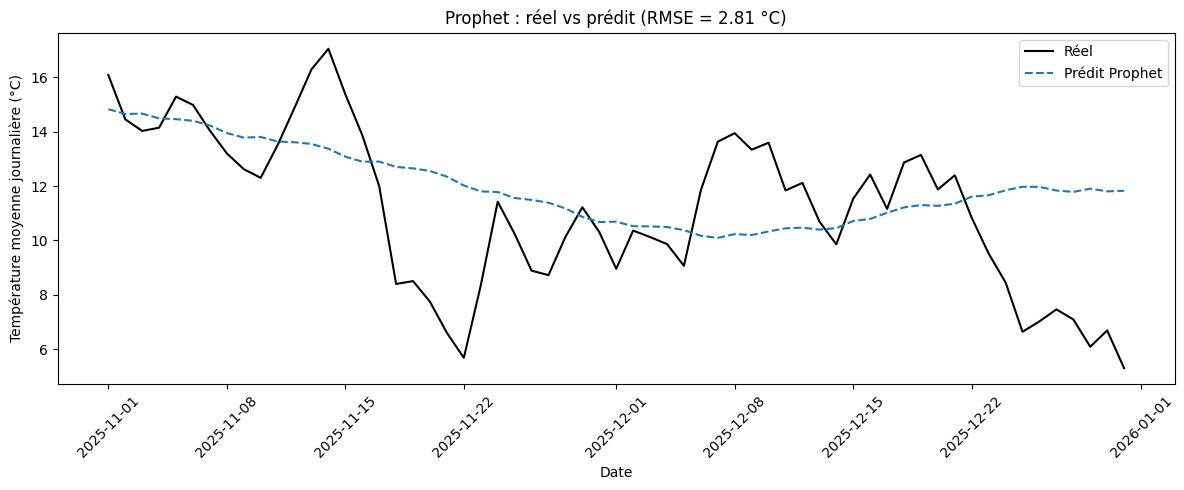

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT date, temperature
FROM releve_meteo
WHERE date IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY date
"""

df = pd.read_sql(query, bdd)

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Conversion Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Moyenne journalière
df_jour = df.groupby("date", as_index=False)["temperature"].mean()

# Format attendu par Prophet
df_prophet = df_jour.rename(columns={
    "date": "ds",
    "temperature": "y"
})

print("Aperçu des données :")
print(df_prophet.head())

# =========================
# 3. BACKTESTING : on entraîne jusqu'à fin octobre 2025
#    et on teste sur novembre / décembre 2025
# =========================
date_fin_train = pd.Timestamp("2025-10-31")

train = df_prophet[df_prophet["ds"] <= date_fin_train].copy()
test = df_prophet[df_prophet["ds"] > date_fin_train].copy()

print("\nTaille train :", train.shape)
print("Taille test :", test.shape)
print("Période test :", test["ds"].min(), "->", test["ds"].max())

# =========================
# 4. MODÈLE PROPHET
# =========================
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,
    seasonality_mode="additive"
)

model_prophet.fit(train)

# =========================
# 5. PRÉDICTION SUR LA PÉRIODE TEST
# =========================
future = test[["ds"]].copy()
forecast = model_prophet.predict(future)

# =========================
# 6. COMPARAISON RÉEL / PRÉDIT
# =========================
comparaison = pd.merge(
    test[["ds", "y"]],
    forecast[["ds", "yhat"]],
    on="ds"
)

# =========================
# 7. MÉTRIQUES
# =========================
mae = mean_absolute_error(comparaison["y"], comparaison["yhat"])
mse = mean_squared_error(comparaison["y"], comparaison["yhat"])
rmse = np.sqrt(mse)
r2 = r2_score(comparaison["y"], comparaison["yhat"])

print("\n=== PROPHET ===")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)

print("\nAperçu réel / prédit :")
print(comparaison.head(10))

# =========================
# 8. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(comparaison["ds"], comparaison["y"], label="Réel", color="black")
plt.plot(comparaison["ds"], comparaison["yhat"], label="Prédit Prophet", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Température moyenne journalière (°C)")
plt.title(f"Prophet : réel vs prédit (RMSE = {rmse:.2f} °C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle Prophet sont limitées (R² faible ≈ 0.06 et RMSE élevé), ce qui indique une faible qualité de prédiction.

Le graphique montre que les prédictions sont relativement lissées et ne suivent pas correctement les variations réelles de la température.

Le modèle capte une tendance générale, mais échoue à reproduire les fluctuations importantes.

Cela s’explique par le fait que Prophet repose principalement sur des tendances et saisonnalités globales, sans intégrer de variables explicatives spécifiques.

Dans le cadre du projet agricole, ce modèle reste intéressant pour visualiser des tendances globales, mais il manque de précision pour des prédictions fines.

Ces résultats confirment que les modèles basés uniquement sur la série temporelle ont des performances limitées.

## test de prophet sur une semaine

Nombre de lignes brutes : 123512
Aperçu des données préparées :
                     ds    y     u    pres
186 2026-01-01 00:00:00  1.9  50.0  1020.3
319 2026-01-01 03:00:00 -1.5  64.0  1019.8
562 2026-01-01 06:00:00 -1.9  71.0  1018.6
697 2026-01-01 09:00:00  1.8  69.0  1018.5
886 2026-01-01 12:00:00  5.5  55.0  1016.7

Taille train : (56, 4)
Taille test : (597, 4)
Période test : 2026-01-08 00:00:00 -> 2026-03-23 21:00:00

Aperçu du futur :
                     ds       u         pres
107 2026-01-14 09:00:00  48.875  1012.579167
108 2026-01-14 12:00:00  48.875  1012.579167
109 2026-01-14 15:00:00  48.875  1012.579167
110 2026-01-14 18:00:00  48.875  1012.579167
111 2026-01-14 21:00:00  48.875  1012.579167

=== PROPHET AVEC RÉGRESSEURS ===
MAE : 129.0596269563064
MSE : 31653.34080123619
RMSE : 177.91385781112214
R² : -2359.725057360626

Aperçu comparaison réel / prédit :
                   ds     y       yhat
0 2026-01-08 00:00:00   5.9   6.716377
1 2026-01-08 03:00:00   4.0   7.740840

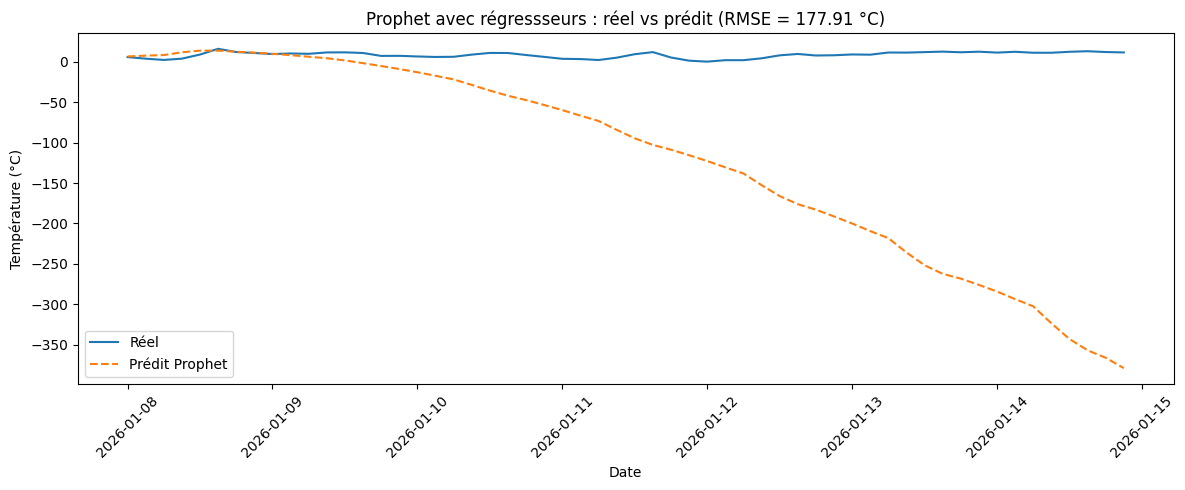

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES
# =========================
files = sorted(glob.glob("synop_*.csv"))

df_raw = pd.concat([
    pd.read_csv(
        f,
        sep=None,
        engine="python",
        usecols=["validity_time", "t", "u", "pres", "name"]
    )
    for f in files
], ignore_index=True)

print("Nombre de lignes brutes :", len(df_raw))

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df_raw["ds"] = pd.to_datetime(df_raw["validity_time"], utc=True).dt.tz_localize(None)

df = df_raw[df_raw["name"] == "MONTPELLIER-AEROPORT"].copy()
df = df.drop_duplicates("ds").sort_values("ds")

# Température en Celsius
df["y"] = df["t"] - 273.15

# Variables explicatives
df["u"] = pd.to_numeric(df["u"], errors="coerce").ffill()
df["pres"] = pd.to_numeric(df["pres"], errors="coerce").ffill() / 100

# Colonnes utiles
df = df[["ds", "y", "u", "pres"]].dropna()

print("Aperçu des données préparées :")
print(df.head())

# =========================
# 3. SÉPARATION TRAIN / TEST
# =========================
cutoff = pd.Timestamp("2026-01-07 21:00:00")

train = df[df["ds"] <= cutoff].copy()
test = df[df["ds"] > cutoff].copy()

print("\nTaille train :", train.shape)
print("Taille test :", test.shape)
print("Période test :", test["ds"].min(), "->", test["ds"].max())

# =========================
# 4. MODÈLE PROPHET
# =========================
model_prophet = Prophet(
    changepoint_prior_scale=15,
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative"
)

model_prophet.add_seasonality(
    name="yearly",
    period=365.25,
    fourier_order=12
)

model_prophet.add_seasonality(
    name="daily",
    period=1,
    fourier_order=8
)

model_prophet.add_regressor("u", prior_scale=10)
model_prophet.add_regressor("pres", prior_scale=10)

model_prophet.fit(train)

# =========================
# 5. PRÉPARATION DU FUTUR
# =========================
future = model_prophet.make_future_dataframe(periods=56, freq="3h")

# On récupère les valeurs connues de u et pres
future = future.merge(df[["ds", "u", "pres"]], on="ds", how="left")

# Moyennes récentes pour compléter le futur
avg_u = train["u"].tail(24).mean()
avg_pres = train["pres"].tail(24).mean()

future.loc[future["ds"] > cutoff, "u"] = avg_u
future.loc[future["ds"] > cutoff, "pres"] = avg_pres

print("\nAperçu du futur :")
print(future.tail())

# =========================
# 6. PRÉDICTION
# =========================
forecast = model_prophet.predict(future)

# =========================
# 7. RÉSULTATS SUR LA PÉRIODE TEST
# =========================
forecast_test = forecast[forecast["ds"] > cutoff][["ds", "yhat"]].copy()

comparaison = pd.merge(
    test[["ds", "y"]],
    forecast_test,
    on="ds",
    how="inner"
)

# =========================
# 8. MÉTRIQUES
# =========================
mae = mean_absolute_error(comparaison["y"], comparaison["yhat"])
mse = mean_squared_error(comparaison["y"], comparaison["yhat"])
rmse = np.sqrt(mse)
r2 = r2_score(comparaison["y"], comparaison["yhat"])

print("\n=== PROPHET AVEC RÉGRESSEURS ===")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)

print("\nAperçu comparaison réel / prédit :")
print(comparaison.head(10))

# =========================
# 9. EXPORT DU CSV
# =========================
forecast_test.to_csv("prophet_semaine_2.csv", index=False)
print("\nFichier 'prophet_semaine_2.csv' enregistré avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(comparaison["ds"], comparaison["y"], label="Réel")
plt.plot(comparaison["ds"], comparaison["yhat"], label="Prédit Prophet", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title(f"Prophet avec régressseurs : réel vs prédit (RMSE = {rmse:.2f} °C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les performances du modèle Prophet avec régressseurs sont très mauvaises (R² fortement négatif et RMSE extrêmement élevé).

Le graphique montre une divergence importante entre les valeurs réelles et les prédictions, avec une dérive progressive du modèle.

Les prédictions deviennent incohérentes, atteignant des valeurs irréalistes.

Cela indique que le modèle ne parvient pas à exploiter correctement les variables explicatives dans ce contexte.

Contrairement à SARIMAX, Prophet ne semble pas adapté à ce type de données ou à cette configuration.


## Validation finale du modèle Prophet sur données réelles


Fichiers présents dans le dossier :
['.config', 'agriculture(1).sql', 'prophet_semaine_2.csv', 'agriculture(1) (1).sql', 'meteo_2026_a_predire.csv', 'synop_2026.csv', 'sample_data']

Aperçu prédictions :
                    ds       yhat
0  2026-01-08 00:00:00   6.716377
1  2026-01-08 03:00:00   7.740840
2  2026-01-08 06:00:00   8.439309
3  2026-01-08 09:00:00  11.886188
4  2026-01-08 12:00:00  13.888304

Aperçu données réelles :
         lat       lon  geo_id_wmo     geo_id_wigos           name  \
0  50.732500  1.599667        7002  0-20000-0-07002   BOULOGNE-SEM   
1  50.514500  1.622833        7003  0-20000-0-07003     LE-TOUQUET   
2  50.136000  1.834000        7005  0-20000-0-07005      ABBEVILLE   
3  51.055833  2.339500        7010  0-20000-0-07010      DUNKERQUE   
4  50.570000  3.097500        7015  0-20000-0-07015  LILLE-LESQUIN   

         reference_time           insert_time         validity_time      pmer  \
0  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z  2026-01-01T00:00:

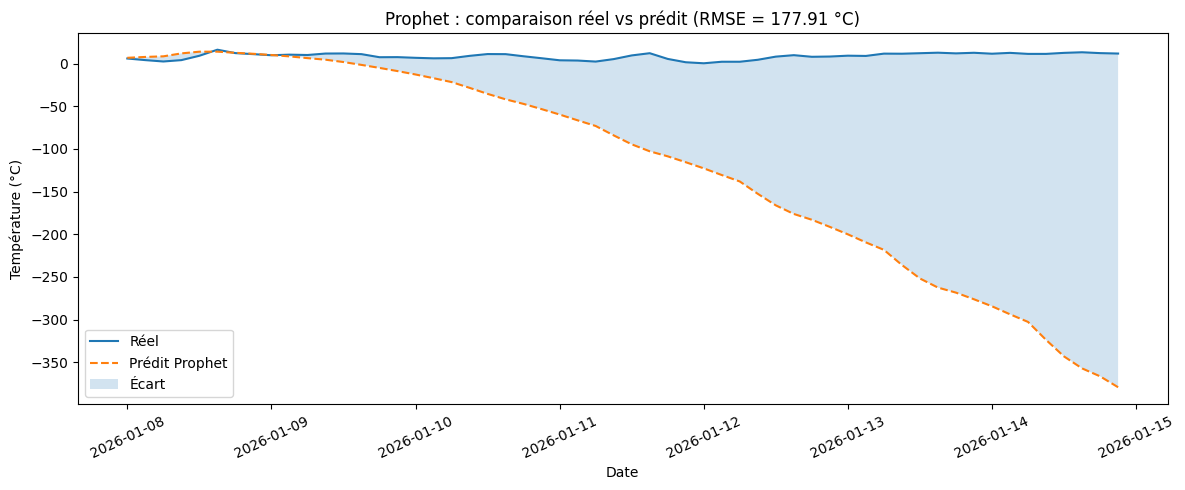


Comparaison terminée avec succès.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. VÉRIFICATION DES FICHIERS
# =========================
print("Fichiers présents dans le dossier :")
print(os.listdir())

fichier_pred = "prophet_semaine_2.csv"
fichier_reel = "synop_2026.csv"

if not os.path.exists(fichier_pred):
    raise ValueError(f"Le fichier '{fichier_pred}' est introuvable.")

if not os.path.exists(fichier_reel):
    raise ValueError(f"Le fichier '{fichier_reel}' est introuvable.")

# =========================
# 2. CHARGEMENT DES DONNÉES
# =========================
df_pred = pd.read_csv(fichier_pred)

# Si ton fichier réel est séparé par ; garde sep=";"
df_real = pd.read_csv(fichier_reel, sep=";")

print("\nAperçu prédictions :")
print(df_pred.head())

print("\nAperçu données réelles :")
print(df_real.head())

# =========================
# 3. PRÉPARATION DES DATES
# =========================
df_pred["ds"] = pd.to_datetime(df_pred["ds"])
df_real["ds"] = pd.to_datetime(df_real["validity_time"], utc=True).dt.tz_localize(None)

# =========================
# 4. PRÉPARATION DES DONNÉES RÉELLES
# =========================
# Température en Celsius
df_real["y_real"] = df_real["t"] - 273.15

# Filtre sur Montpellier
df_real = df_real[df_real["name"] == "MONTPELLIER-AEROPORT"].copy()

# On garde seulement les colonnes utiles
df_real = df_real[["ds", "y_real"]].dropna()

# =========================
# 5. FUSION DES DONNÉES
# =========================
df_compare = pd.merge(
    df_pred,
    df_real,
    on="ds",
    how="inner"
).sort_values("ds")

print("\nNombre de dates communes :", len(df_compare))
print(df_compare.head())

# =========================
# 6. CALCUL DES MÉTRIQUES
# =========================
if not df_compare.empty:
    mae = mean_absolute_error(df_compare["y_real"], df_compare["yhat"])
    mse = mean_squared_error(df_compare["y_real"], df_compare["yhat"])
    rmse = np.sqrt(mse)
    r2 = r2_score(df_compare["y_real"], df_compare["yhat"])

    print("\n=== COMPARAISON PROPHET ===")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R² :", r2)

    # =========================
    # 7. GRAPHIQUE
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(df_compare["ds"], df_compare["y_real"], label="Réel")
    plt.plot(df_compare["ds"], df_compare["yhat"], label="Prédit Prophet", linestyle="--")

    plt.fill_between(
        df_compare["ds"],
        df_compare["y_real"],
        df_compare["yhat"],
        alpha=0.2,
        label="Écart"
    )

    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.title(f"Prophet : comparaison réel vs prédit (RMSE = {rmse:.2f} °C)")
    plt.legend()
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

    print("\nComparaison terminée avec succès.")
else:
    print("Aucune donnée commune trouvée entre la prédiction et les données réelles.")

Les résultats confirment les limites du modèle Prophet, avec des erreurs très élevées (RMSE ≈ 178°C) et un R² fortement négatif.

Le graphique met en évidence une divergence majeure entre les prédictions et les valeurs réelles, avec une dérive progressive du modèle.

Les prédictions deviennent rapidement irréalistes, ce qui rend le modèle inutilisable dans ce contexte.

Cette validation sur données réelles confirme que les performances observées précédemment ne permettent pas une utilisation fiable du modèle.

Prophet ne parvient pas à capturer correctement la dynamique de la température dans ce jeu de données.

Ces résultats renforcent l’importance de comparer systématiquement les modèles sur des données indépendantes.

## GriddSearch pour prophet (voir quels sont les meilleurs paramètres)


In [ ]:
import pandas as pd
import numpy as np
import glob
import os

from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. VÉRIFICATION DES FICHIERS
# =========================
files = sorted(glob.glob("synop_*.csv"))

print("Fichiers trouvés :", files)

if len(files) == 0:
    raise ValueError("Aucun fichier 'synop_*.csv' trouvé. Vérifie l'upload ou le nom des fichiers.")

# =========================
# 2. CHARGEMENT DES DONNÉES
# =========================
df_raw = pd.concat([
    pd.read_csv(
        f,
        sep=None,
        engine="python",
        usecols=["validity_time", "t", "u", "pres", "name"]
    )
    for f in files
], ignore_index=True)

print("\nNombre de lignes brutes :", len(df_raw))

# =========================
# 3. PRÉPARATION DES DONNÉES
# =========================
df_raw["ds"] = pd.to_datetime(df_raw["validity_time"], utc=True).dt.tz_localize(None)

df = df_raw[df_raw["name"] == "MONTPELLIER-AEROPORT"].copy()
df = df.drop_duplicates("ds").sort_values("ds")

# Température en Celsius
df["y"] = df["t"] - 273.15

# Variables explicatives
df["u"] = pd.to_numeric(df["u"], errors="coerce").ffill()
df["pres"] = pd.to_numeric(df["pres"], errors="coerce").ffill() / 100

# Colonnes utiles
df = df[["ds", "y", "u", "pres"]].dropna()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 4. SPLIT TRAIN / TEST
# =========================
# 56 points = 7 jours si données toutes les 3 heures
n_test = 56

train = df.iloc[:-n_test].copy()
test = df.iloc[-n_test:].copy()

print("\nEntraînement jusqu'au :", train["ds"].max())
print("Test du", test["ds"].min(), "au", test["ds"].max())
print("Taille train :", train.shape)
print("Taille test :", test.shape)

# =========================
# 5. GRILLE DE PARAMÈTRES
# =========================
param_grid = {
    "changepoint_prior_scale": [0.05, 0.1, 0.3],
    "seasonality_prior_scale": [0.1, 1.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

grid = ParameterGrid(param_grid)

print("\nNombre total de configurations testées :", len(list(grid)))

# =========================
# 6. GRID SEARCH
# =========================
results = []
best_model = None
best_forecast = None
best_params = None
best_mae = float("inf")

for p in grid:
    try:
        model = Prophet(
            **p,
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False
        )

        model.add_seasonality(
            name="daily",
            period=1,
            fourier_order=15
        )

        model.add_regressor("u")
        model.add_regressor("pres")

        model.fit(train)

        # Prédiction uniquement sur la période test
        future = test[["ds", "u", "pres"]].copy()
        forecast = model.predict(future)

        # Métriques
        mae = mean_absolute_error(test["y"], forecast["yhat"])
        mse = mean_squared_error(test["y"], forecast["yhat"])
        rmse = np.sqrt(mse)
        r2 = r2_score(test["y"], forecast["yhat"])

        results.append({
            "changepoint_prior_scale": p["changepoint_prior_scale"],
            "seasonality_prior_scale": p["seasonality_prior_scale"],
            "seasonality_mode": p["seasonality_mode"],
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        })

        print(
            f"Mode={p['seasonality_mode']} | "
            f"CPS={p['changepoint_prior_scale']} | "
            f"SPS={p['seasonality_prior_scale']} | "
            f"MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}"
        )

        if mae < best_mae:
            best_mae = mae
            best_params = p
            best_model = model
            best_forecast = forecast.copy()

    except Exception as e:
        print(f"Erreur avec paramètres {p} : {e}")

# =========================
# 7. TABLEAU DES RÉSULTATS
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MAE")

print("\n=== RÉSULTATS TRIÉS PAR MAE ===")
print(results_df)

print("\n=== MEILLEURS PARAMÈTRES ===")
print(best_params)
print("Meilleur MAE :", best_mae)

# =========================
# 8. COMPARAISON FINALE
# =========================
comparaison = test[["ds", "y"]].copy()
comparaison["yhat"] = best_forecast["yhat"].values

print("\nAperçu réel / prédit :")
print(comparaison.head(10))

Fichiers trouvés : ['synop_2026.csv']

Nombre de lignes brutes : 123512

Aperçu des données préparées :
                     ds    y     u    pres
186 2026-01-01 00:00:00  1.9  50.0  1020.3
319 2026-01-01 03:00:00 -1.5  64.0  1019.8
562 2026-01-01 06:00:00 -1.9  71.0  1018.6
697 2026-01-01 09:00:00  1.8  69.0  1018.5
886 2026-01-01 12:00:00  5.5  55.0  1016.7

Entraînement jusqu'au : 2026-03-16 15:00:00
Test du 2026-03-16 18:00:00 au 2026-03-23 21:00:00
Taille train : (597, 4)
Taille test : (56, 4)

Nombre total de configurations testées : 18
Mode=additive | CPS=0.05 | SPS=0.1 | MAE=1.9334 | RMSE=2.5290 | R²=0.5812
Mode=additive | CPS=0.05 | SPS=1.0 | MAE=1.9367 | RMSE=2.5551 | R²=0.5725
Mode=additive | CPS=0.05 | SPS=10.0 | MAE=1.9368 | RMSE=2.5544 | R²=0.5728
Mode=multiplicative | CPS=0.05 | SPS=0.1 | MAE=1.8602 | RMSE=2.4185 | R²=0.6170
Mode=multiplicative | CPS=0.05 | SPS=1.0 | MAE=1.8385 | RMSE=2.1996 | R²=0.6832
Mode=multiplicative | CPS=0.05 | SPS=10.0 | MAE=1.8474 | RMSE=2.1983

Les résultats montrent une amélioration notable des performances par rapport aux versions précédentes du modèle Prophet.

La meilleure configuration obtenue permet de réduire significativement les erreurs (MAE ≈ 1.83, RMSE ≈ 2.32) et d’obtenir un R² positif.

Le modèle devient capable de mieux suivre les variations de la température, bien que certaines différences persistent.

On observe également que les modèles avec saisonnalité multiplicative donnent globalement de meilleurs résultats.

Cela suggère que les variations de température dépendent de leur niveau (effet proportionnel).

Cette optimisation permet donc d’améliorer le modèle, sans pour autant atteindre les performances des meilleurs modèles testés précédemment.

### test des paramètres sortant de grid search en essayant de prédire une journée


Aperçu du futur :
                     ds     u    pres
597 2026-03-16 18:00:00  37.0  1017.3
598 2026-03-16 21:00:00  37.0  1017.3
599 2026-03-17 00:00:00  37.0  1017.3
600 2026-03-17 03:00:00  37.0  1017.3
601 2026-03-17 06:00:00  37.0  1017.3
602 2026-03-17 09:00:00  37.0  1017.3
603 2026-03-17 12:00:00  37.0  1017.3
604 2026-03-17 15:00:00  37.0  1017.3

Fichier 'prophet_24h_test.csv' généré avec succès.
Période : 2026-03-16 18:00:00 -> 2026-03-17 15:00:00

=== ÉVALUATION 24H ===
MAE : 1.8282115046054275
MSE : 4.542958404964341
RMSE : 2.1314216863315294
R² : 0.7050293036726203


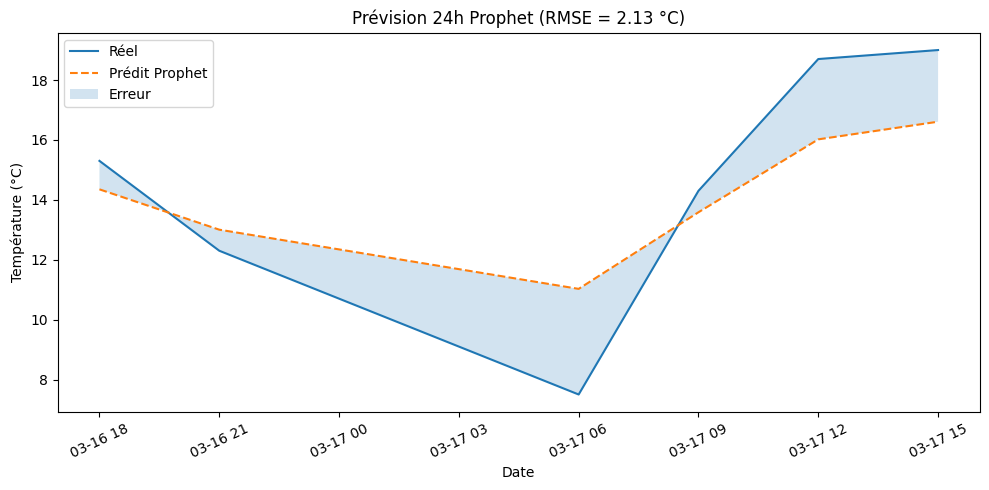

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. GÉNÉRATION DU FUTUR
# =========================
# 8 points = 24h (données toutes les 3h)
future_dates = best_model.make_future_dataframe(periods=8, freq="3h")

future_only = future_dates[future_dates["ds"] > train["ds"].max()].copy()

# On utilise les dernières valeurs connues (scénario réaliste)
future_only["u"] = train["u"].iloc[-1]
future_only["pres"] = train["pres"].iloc[-1]

print("\nAperçu du futur :")
print(future_only)

# =========================
# 2. PRÉDICTION
# =========================
forecast = best_model.predict(future_only)

# =========================
# 3. EXPORT CSV
# =========================
export_df = forecast[["ds", "yhat"]].copy()
export_df.columns = ["ds", "y_pred"]

export_df.to_csv("prophet_24h_test.csv", index=False)

print("\nFichier 'prophet_24h_test.csv' généré avec succès.")
print(f"Période : {export_df['ds'].min()} -> {export_df['ds'].max()}")

# =========================
# 4. SI DONNÉES RÉELLES DISPONIBLES → COMPARAISON
# =========================
fichier_reel = "synop_2026.csv"

if os.path.exists(fichier_reel):
    df_real = pd.read_csv(fichier_reel, sep=";")

    df_real["ds"] = pd.to_datetime(df_real["validity_time"], utc=True).dt.tz_localize(None)
    df_real["y_real"] = df_real["t"] - 273.15

    df_real = df_real[df_real["name"] == "MONTPELLIER-AEROPORT"]

    df_compare = pd.merge(
        export_df,
        df_real[["ds", "y_real"]],
        on="ds",
        how="inner"
    )

    if not df_compare.empty:
        mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
        mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
        rmse = np.sqrt(mse)
        r2 = r2_score(df_compare["y_real"], df_compare["y_pred"])

        print("\n=== ÉVALUATION 24H ===")
        print("MAE :", mae)
        print("MSE :", mse)
        print("RMSE :", rmse)
        print("R² :", r2)

        # =========================
        # 5. GRAPHIQUE
        # =========================
        plt.figure(figsize=(10, 5))
        plt.plot(df_compare["ds"], df_compare["y_real"], label="Réel")
        plt.plot(df_compare["ds"], df_compare["y_pred"], label="Prédit Prophet", linestyle="--")

        plt.fill_between(
            df_compare["ds"],
            df_compare["y_real"],
            df_compare["y_pred"],
            alpha=0.2,
            label="Erreur"
        )

        plt.title(f"Prévision 24h Prophet (RMSE = {rmse:.2f} °C)")
        plt.xlabel("Date")
        plt.ylabel("Température (°C)")
        plt.legend()
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.show()

    else:
        print("Aucune correspondance avec les données réelles.")
else:
    print("\nAucune donnée réelle disponible pour comparaison.")

Les performances du modèle sont nettement meilleures sur un horizon de 24 heures (RMSE ≈ 2.13°C, R² ≈ 0.70).

Le graphique montre que les prédictions suivent globalement la tendance réelle, bien que certaines différences subsistent.

Le modèle capture correctement la dynamique globale, notamment les phases de hausse et de baisse.

Cependant, on observe un lissage des variations, avec des amplitudes légèrement sous-estimées.

Cela indique que Prophet est plus adapté à des prévisions de court terme qu’à des horizons longs dans ce contexte.

Ces résultats montrent l’importance de l’échelle temporelle dans l’évaluation des modèles.

Aperçu des prédictions :
                   ds     y_pred
0 2026-03-16 18:00:00  14.349543
1 2026-03-16 21:00:00  13.003172
2 2026-03-17 00:00:00  12.219432
3 2026-03-17 03:00:00  11.712933
4 2026-03-17 06:00:00  11.026473

Fichiers réels trouvés : ['synop_2026.csv']

Aperçu des données réelles :
                     ds  y_real
186 2026-01-01 00:00:00     1.9
319 2026-01-01 03:00:00    -1.5
562 2026-01-01 06:00:00    -1.9
697 2026-01-01 09:00:00     1.8
886 2026-01-01 12:00:00     5.5

Nombre de dates communes : 6
                   ds     y_pred  y_real
0 2026-03-16 18:00:00  14.349543    15.3
1 2026-03-16 21:00:00  13.003172    12.3
2 2026-03-17 06:00:00  11.026473     7.5
3 2026-03-17 09:00:00  13.584226    14.3
4 2026-03-17 12:00:00  16.018516    18.7

=== VALIDATION PROPHET 24H ===
MAE  : 1.828211504605428
MSE  : 4.542958404964342
RMSE : 2.13142168633153
R²   : 0.7050293036726203
Biais : -0.41833012998062163


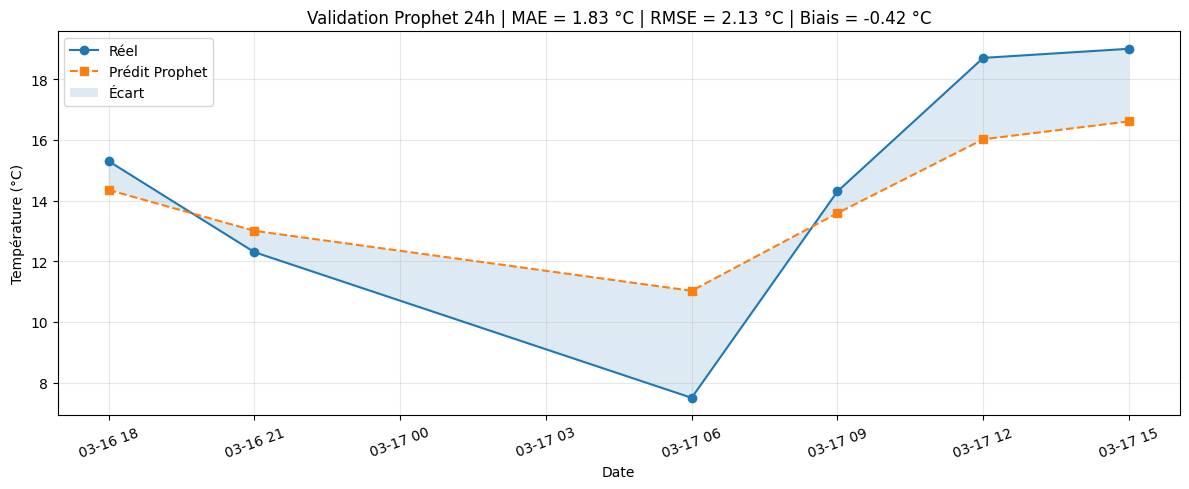


Rapport de performance :
Erreur moyenne absolue (MAE) : 1.83 °C
Erreur quadratique moyenne (RMSE) : 2.13 °C
Biais moyen : -0.42 °C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DE LA PRÉDICTION
# =========================
fichier_pred = "prophet_24h_test.csv"

if not os.path.exists(fichier_pred):
    raise ValueError(f"Le fichier '{fichier_pred}' est introuvable. Vérifie qu'il a bien été généré.")

df_pred = pd.read_csv(fichier_pred)
df_pred["ds"] = pd.to_datetime(df_pred["ds"])

print("Aperçu des prédictions :")
print(df_pred.head())

# =========================
# 2. CHARGEMENT DES DONNÉES RÉELLES
# =========================
files = sorted(glob.glob("synop_*.csv"))

print("\nFichiers réels trouvés :", files)

if len(files) == 0:
    raise ValueError("Aucun fichier 'synop_*.csv' trouvé. Vérifie l'upload ou le nom des fichiers.")

df_list = []
for f in files:
    temp = pd.read_csv(
        f,
        sep=None,
        engine="python",
        usecols=["validity_time", "t", "name"]
    )
    df_list.append(temp)

df_all = pd.concat(df_list, ignore_index=True)

# =========================
# 3. PRÉPARATION DES DONNÉES RÉELLES
# =========================
df_real = df_all[df_all["name"] == "MONTPELLIER-AEROPORT"].copy()

df_real["ds"] = pd.to_datetime(df_real["validity_time"], utc=True).dt.tz_localize(None)
df_real["y_real"] = df_real["t"] - 273.15

df_real = df_real[["ds", "y_real"]].dropna()
df_real = df_real.sort_values("ds")

print("\nAperçu des données réelles :")
print(df_real.head())

# =========================
# 4. FUSION ET ALIGNEMENT
# =========================
df_compare = pd.merge(
    df_pred,
    df_real,
    on="ds",
    how="inner"
).sort_values("ds")

print("\nNombre de dates communes :", len(df_compare))
print(df_compare.head())

# =========================
# 5. CALCUL DES MÉTRIQUES
# =========================
if not df_compare.empty:
    mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
    mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
    rmse = np.sqrt(mse)
    r2 = r2_score(df_compare["y_real"], df_compare["y_pred"])
    bias = (df_compare["y_pred"] - df_compare["y_real"]).mean()

    print("\n=== VALIDATION PROPHET 24H ===")
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("Biais :", bias)

    # =========================
    # 6. GRAPHIQUE
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(df_compare["ds"], df_compare["y_real"], marker="o", label="Réel")
    plt.plot(df_compare["ds"], df_compare["y_pred"], marker="s", linestyle="--", label="Prédit Prophet")

    plt.fill_between(
        df_compare["ds"],
        df_compare["y_real"],
        df_compare["y_pred"],
        alpha=0.15,
        label="Écart"
    )

    plt.title(
        f"Validation Prophet 24h | MAE = {mae:.2f} °C | RMSE = {rmse:.2f} °C | Biais = {bias:+.2f} °C"
    )
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print("\nRapport de performance :")
    print(f"Erreur moyenne absolue (MAE) : {mae:.2f} °C")
    print(f"Erreur quadratique moyenne (RMSE) : {rmse:.2f} °C")
    print(f"Biais moyen : {bias:+.2f} °C")

else:
    print("Aucune donnée réelle trouvée pour les dates prédites.")

Les résultats confirment de bonnes performances du modèle à court terme, avec une erreur moyenne faible (MAE ≈ 1.83°C) et un R² satisfaisant (≈ 0.70).

Le graphique montre que les prédictions suivent correctement la tendance des températures, malgré un léger écart sur certaines valeurs.

Le biais négatif (-0.42°C) indique que le modèle a tendance à sous-estimer légèrement les températures.

Cependant, cette erreur reste limitée et cohérente avec les performances globales.

Le modèle capture bien la dynamique générale, mais lisse légèrement les variations extrêmes.

Ces résultats confirment que Prophet est pertinent pour des prévisions à court terme dans ce contexte.

L’analyse du biais apporte une information complémentaire essentielle, en mettant en évidence une tendance systématique du modèle.

## XGBoost = Forêt d'arbres de décision qui apprennent en série : chaque nouvel arbre est construit spécifiquement pour corriger les erreurs de prédiction commises par l'ensemble des arbres précédents, jusqu'à ce que le résultat final soit le plus précis possible.

Test de xgboost en récursif (en réinjectant chaque prédiction comme donnée d'entrée pour calculer le point suivant) sur 2 mois

Aperçu des données brutes :
         date  heure  temperature
0  2022-01-01 0 days       284.45
1  2022-01-01 0 days       278.85
2  2022-01-01 0 days       280.05
3  2022-01-01 0 days       282.25
4  2022-01-01 0 days       284.25

Aperçu des données préparées :
           ds     y
0  2022-01-01  11.3
31 2022-01-01  13.5
32 2022-01-01  11.0
33 2022-01-01  11.7
34 2022-01-01   9.7

Taille train : (354689, 5)
Taille test : (46222, 5)
Période test : 2025-11-01 00:00:00 -> 2025-12-31 18:00:00

Variables utilisées :
['hour', 'dayofyear', 'month', 'lag_3h', 'lag_6h', 'lag_24h']

Lancement de la prédiction récursive sur la période test...

=== XGBOOST RÉCURSIF ===
MAE  : 7.738234964629611
MSE  : 84.08742592400814
RMSE : 9.169919624729987
R²   : -0.18014267569282905
Biais : 3.7654953006148126

Aperçu réel / prédit :
               ds     y  prediction_xgb
354817 2025-11-01  17.4       15.238276
354816 2025-11-01  18.2       15.229514
354815 2025-11-01  17.4       15.382020
354810 2025-11-01  

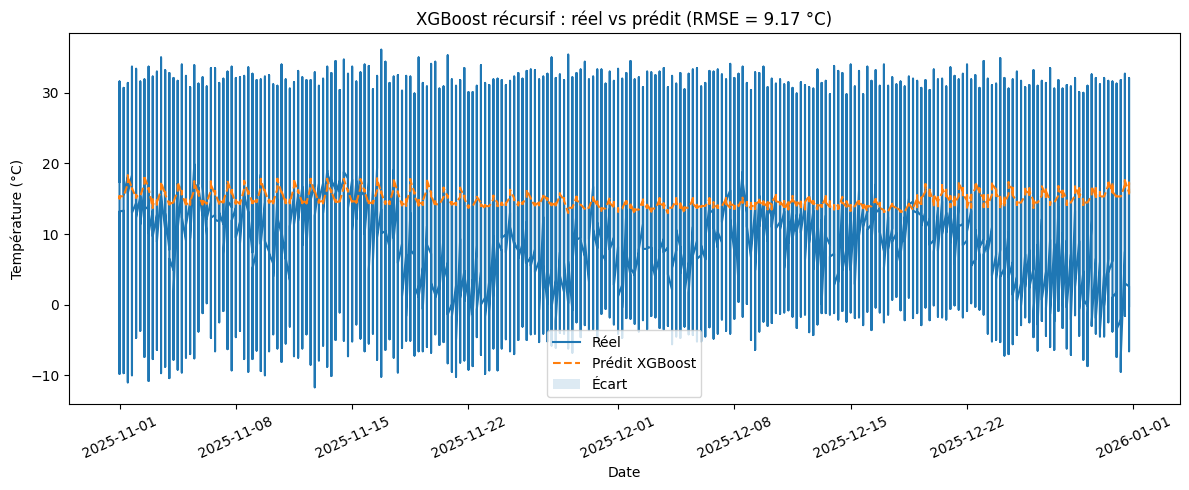

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT date, heure, temperature
FROM releve_meteo
WHERE date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY date, heure
"""

df = pd.read_sql(query, bdd)

print("Aperçu des données brutes :")
print(df.head())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = df["temperature"] - 273.15
df = df.sort_values("ds").copy()

print("\nAperçu des données préparées :")
print(df[["ds", "y"]].head())

# =========================
# 3. SÉPARATION TRAIN / TEST
# =========================
# Entraînement jusqu'au 31 octobre 2025
train_data = df[df["ds"] < "2025-11-01"].copy()

# Test sur novembre + décembre 2025
test_data = df[df["ds"] >= "2025-11-01"].copy()

print("\nTaille train :", train_data.shape)
print("Taille test :", test_data.shape)
print("Période test :", test_data["ds"].min(), "->", test_data["ds"].max())

# =========================
# 4. CRÉATION DES VARIABLES TEMPORELLES
# =========================
def create_time_features(data):
    data = data.copy()
    data["hour"] = data["ds"].dt.hour
    data["dayofyear"] = data["ds"].dt.dayofyear
    data["month"] = data["ds"].dt.month
    return data

train_data = create_time_features(train_data)
test_data = create_time_features(test_data)

# =========================
# 5. CRÉATION DES LAGS
# =========================
train_data["lag_3h"] = train_data["y"].shift(1)
train_data["lag_6h"] = train_data["y"].shift(2)
train_data["lag_24h"] = train_data["y"].shift(8)

train_data = train_data.dropna().copy()

features = ["hour", "dayofyear", "month", "lag_3h", "lag_6h", "lag_24h"]

X_train = train_data[features]
y_train = train_data["y"]

print("\nVariables utilisées :")
print(features)

# =========================
# 6. MODÈLE XGBOOST
# =========================
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror",
    random_state=42
)

model_xgb.fit(X_train, y_train)

# =========================
# 7. PRÉDICTION RÉCURSIVE
# =========================
# On garde les 8 dernières vraies valeurs du train (= 24h si données toutes les 3h)
last_values = list(train_data["y"].tail(8).values)

preds_list = []

print("\nLancement de la prédiction récursive sur la période test...")

for i in range(len(test_data)):
    row_ds = test_data.iloc[i]["ds"]

    current_features = pd.DataFrame([{
        "hour": row_ds.hour,
        "dayofyear": row_ds.dayofyear,
        "month": row_ds.month,
        "lag_3h": last_values[-1],
        "lag_6h": last_values[-2],
        "lag_24h": last_values[-8]
    }])

    pred = model_xgb.predict(current_features[features])[0]
    preds_list.append(pred)

    # mise à jour récursive
    last_values.append(pred)
    last_values.pop(0)

# =========================
# 8. RÉSULTATS
# =========================
test_data = test_data.copy()
test_data["prediction_xgb"] = preds_list

mae = mean_absolute_error(test_data["y"], test_data["prediction_xgb"])
mse = mean_squared_error(test_data["y"], test_data["prediction_xgb"])
rmse = np.sqrt(mse)
r2 = r2_score(test_data["y"], test_data["prediction_xgb"])
bias = (test_data["prediction_xgb"] - test_data["y"]).mean()

print("\n=== XGBOOST RÉCURSIF ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
print("Biais :", bias)

print("\nAperçu réel / prédit :")
print(test_data[["ds", "y", "prediction_xgb"]].head(10))

# =========================
# 9. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(test_data["ds"], test_data["y"], label="Réel")
plt.plot(test_data["ds"], test_data["prediction_xgb"], label="Prédit XGBoost", linestyle="--")

plt.fill_between(
    test_data["ds"],
    test_data["y"],
    test_data["prediction_xgb"],
    alpha=0.15,
    label="Écart"
)

plt.title(f"XGBoost récursif : réel vs prédit (RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Les performances du modèle XGBoost récursif sont faibles, avec un RMSE élevé (≈ 9.17°C) et un R² négatif.

Le graphique montre que les prédictions sont très lissées et ne suivent pas les variations réelles de la température.

Le modèle a tendance à prédire une valeur moyenne, sans capturer les fluctuations importantes.

Le biais positif indique une surestimation globale des températures.

Cela s’explique en partie par l’accumulation des erreurs due à la prédiction récursive.

Ces résultats montrent que, malgré la puissance du modèle XGBoost, cette approche n’est pas adaptée à la prévision à long horizon dans ce contexte.

La stratégie de prédiction récursive, bien que réaliste, peut entraîner une propagation des erreurs au fil du temps.

### Test xgboost sur 1 jour avec lags (en se basant sur la mémoire immédiate des relevés précédents)

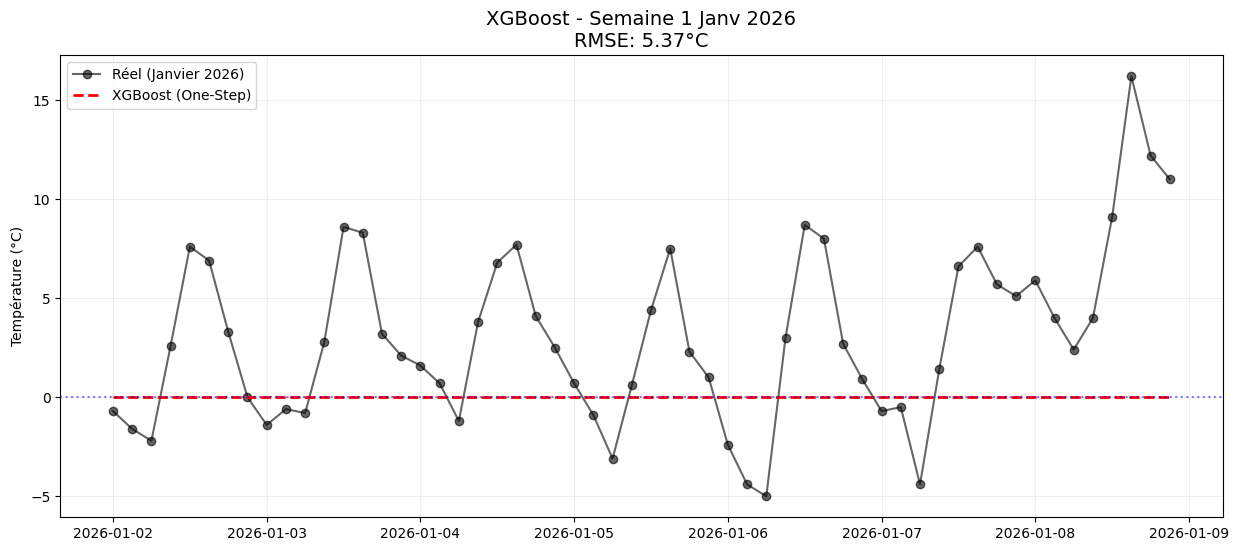

📊 Résultat : 56 points analysés. RMSE de 5.37°C


In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- 1. CHARGEMENT ET PRÉPARATION (Même logique que ton LSTM) ---
files = sorted(glob.glob("synop_*.csv"))
if not files:
    print("❌ Aucun fichier synop_*.csv trouvé !")
else:
    # Lecture avec les colonnes spécifiques
    df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python',
                                   usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])

    # Filtrage Montpellier
    df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('validity_time').copy()
    df['ds'] = pd.to_datetime(df['validity_time'], utc=True).dt.tz_localize(None)

    # Conversions
    df['y'] = pd.to_numeric(df['t'], errors='coerce') - 273.15
    df['u'] = pd.to_numeric(df['u'], errors='coerce')
    df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

    # Nettoyage et Interpolation (pour boucher les trous de 3h)
    df = df.set_index('ds').sort_index()
    df = df[['y', 'u', 'pres']].interpolate(method='linear').bfill().ffill()
    df = df.resample('3h').interpolate() # On s'assure d'avoir un point toutes les 3h
    df = df.reset_index()

    # --- 2. FEATURES AVANCÉES ---
    df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
    df['lag_3h'] = df['y'].shift(1)
    df['lag_6h'] = df['y'].shift(2)
    df['lag_24h'] = df['y'].shift(8)

    df = df.dropna()

    # --- 3. SPLIT CIBLÉ : 1er au 8 JANVIER 2026 ---
    debut_test = pd.Timestamp('2026-01-01 00:00:00')
    fin_test = pd.Timestamp('2026-01-08 23:59:59')

    train = df[df['ds'] < debut_test]
    test_janvier = df[(df['ds'] >= debut_test) & (df['ds'] <= fin_test)]

    if test_janvier.empty:
        print(f"❌ Toujours pas de données en Janvier 2026 !")
        print(f"Dernière date trouvée dans les fichiers : {df['ds'].max()}")
    else:
        features = ['u', 'pres', 'hour_sin', 'hour_cos', 'lag_3h', 'lag_6h', 'lag_24h']
        X_train, y_train = train[features], train['y']
        X_test, y_test = test_janvier[features], test_janvier['y']

        # --- 4. MODÈLE XGBOOST ROBUSTE ---
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=4)
        model.fit(X_train, y_train)

        # --- 5. PRÉDICTION ET SCORE ---
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # --- 6. GRAPHIQUE ---
        plt.figure(figsize=(15, 6))
        plt.plot(test_janvier['ds'], y_test, 'o-', label='Réel (Janvier 2026)', color='black', alpha=0.6)
        plt.plot(test_janvier['ds'], preds, 'r--', label='XGBoost (One-Step)', linewidth=2)
        plt.axhline(0, color='blue', linestyle=':', alpha=0.5)

        plt.title(f"XGBoost - Semaine 1 Janv 2026\nRMSE: {rmse:.2f}°C", fontsize=14)
        plt.ylabel("Température (°C)")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

        print(f"📊 Résultat : {len(test_janvier)} points analysés. RMSE de {rmse:.2f}°C")

Les performances du modèle restent limitées, avec un RMSE d’environ 5.37°C.

Le graphique montre que les prédictions sont quasi constantes et ne suivent pas les variations réelles de la température.

Le modèle ne parvient pas à capturer la dynamique temporelle, malgré l’utilisation de variables temporelles et de lags.

Contrairement à l’approche récursive, l’absence de propagation des erreurs n’améliore pas significativement les résultats.

Cela indique que le modèle peine à apprendre la structure de la série.

Ces résultats confirment que XGBoost, dans cette configuration, n’est pas adapté à ce problème de prévision.

### Test XgBoost non récursif sur 1 semaine ( mais du coup ne marchera pas pour nous par ce qu'il utilise les données réelles 3h avant la prédiction)

Fichiers trouvés : ['synop_2026.csv']

Nombre de lignes brutes : 123512

Aperçu des données préparées :
                   ds    y     u    pres
0 2026-01-01 00:00:00  1.9  50.0  1020.3
1 2026-01-01 03:00:00 -1.5  64.0  1019.8
2 2026-01-01 06:00:00 -1.9  71.0  1018.6
3 2026-01-01 09:00:00  1.8  69.0  1018.5
4 2026-01-01 12:00:00  5.5  55.0  1016.7

Taille train : (0, 9)
Taille test : (56, 9)
Période test : 2026-01-02 00:00:00 -> 2026-01-08 21:00:00

Variables utilisées :
['u', 'pres', 'hour_sin', 'hour_cos', 'lag_3h', 'lag_6h', 'lag_24h']

=== XGBOOST JANVIER 2026 ===
MAE  : 4.169642857142868
MSE  : 28.86339285714301
RMSE : 5.372466180176755
R²   : -0.4999956085046591
Biais : -3.1017857142857364

Fichier 'xgboost_janvier_2026.csv' exporté avec succès.


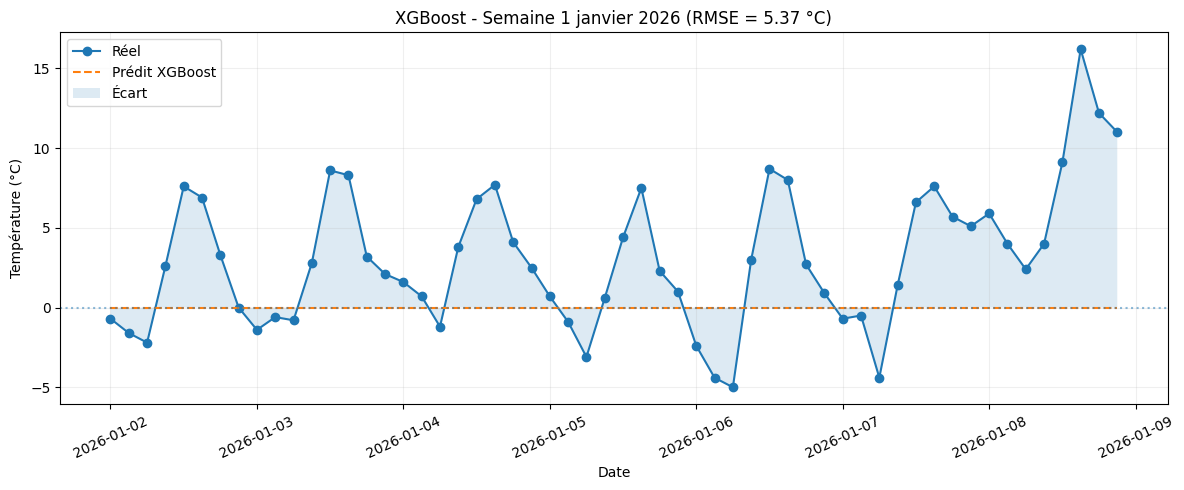


Résultat : 56 points analysés.


In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import os

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES FICHIERS
# =========================
files = sorted(glob.glob("synop_*.csv"))

print("Fichiers trouvés :", files)

if len(files) == 0:
    raise ValueError("Aucun fichier 'synop_*.csv' trouvé. Vérifie l'upload ou le nom des fichiers.")

# =========================
# 2. CHARGEMENT ET PRÉPARATION
# =========================
df_raw = pd.concat([
    pd.read_csv(
        f,
        sep=None,
        engine="python",
        usecols=["validity_time", "t", "u", "pres", "name"]
    )
    for f in files
], ignore_index=True)

print("\nNombre de lignes brutes :", len(df_raw))

# Filtrage Montpellier
df = df_raw[df_raw["name"] == "MONTPELLIER-AEROPORT"].copy()
df = df.drop_duplicates("validity_time")

# Dates
df["ds"] = pd.to_datetime(df["validity_time"], utc=True).dt.tz_localize(None)

# Conversions numériques
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["u"] = pd.to_numeric(df["u"], errors="coerce")
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

# Nettoyage
df = df.set_index("ds").sort_index()
df = df[["y", "u", "pres"]].interpolate(method="linear").bfill().ffill()

# On impose un pas de 3h
df = df.resample("3h").interpolate()
df = df.reset_index()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. FEATURES AVANCÉES
# =========================
df["hour_sin"] = np.sin(2 * np.pi * df["ds"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["ds"].dt.hour / 24)

df["lag_3h"] = df["y"].shift(1)
df["lag_6h"] = df["y"].shift(2)
df["lag_24h"] = df["y"].shift(8)

df = df.dropna().copy()

# =========================
# 4. SPLIT TRAIN / TEST
# =========================
debut_test = pd.Timestamp("2026-01-01 00:00:00")
fin_test = pd.Timestamp("2026-01-08 23:59:59")

train = df[df["ds"] < debut_test].copy()
test_janvier = df[(df["ds"] >= debut_test) & (df["ds"] <= fin_test)].copy()

print("\nTaille train :", train.shape)
print("Taille test :", test_janvier.shape)
print("Période test :", test_janvier["ds"].min(), "->", test_janvier["ds"].max())

if test_janvier.empty:
    raise ValueError(
        f"Aucune donnée trouvée entre {debut_test} et {fin_test}. "
        f"Dernière date disponible : {df['ds'].max()}"
    )

# =========================
# 5. VARIABLES EXPLICATIVES
# =========================
features = ["u", "pres", "hour_sin", "hour_cos", "lag_3h", "lag_6h", "lag_24h"]

X_train = train[features]
y_train = train["y"]

X_test = test_janvier[features]
y_test = test_janvier["y"]

print("\nVariables utilisées :")
print(features)

# =========================
# 6. MODÈLE XGBOOST
# =========================
model_xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    objective="reg:squarederror",
    random_state=42
)

model_xgb.fit(X_train, y_train)

# =========================
# 7. PRÉDICTION
# =========================
preds = model_xgb.predict(X_test)

# =========================
# 8. MÉTRIQUES
# =========================
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
bias = (preds - y_test).mean()

print("\n=== XGBOOST JANVIER 2026 ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
print("Biais :", bias)

# =========================
# 9. EXPORT CSV
# =========================
export_df = pd.DataFrame({
    "ds": test_janvier["ds"],
    "y_real": y_test,
    "y_pred": preds
})

export_df.to_csv("xgboost_janvier_2026.csv", index=False)

print("\nFichier 'xgboost_janvier_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(test_janvier["ds"], y_test, marker="o", label="Réel")
plt.plot(test_janvier["ds"], preds, linestyle="--", label="Prédit XGBoost")

plt.fill_between(
    test_janvier["ds"],
    y_test,
    preds,
    alpha=0.15,
    label="Écart"
)

plt.axhline(0, linestyle=":", alpha=0.5)

plt.title(f"XGBoost - Semaine 1 janvier 2026 (RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print(f"\nRésultat : {len(test_janvier)} points analysés.")

Le graphique montre que les prédictions du modèle sont quasiment constantes et proches d’une valeur moyenne.

Le modèle ne parvient pas à reproduire les variations journalières importantes de la température.

On observe des écarts significatifs entre les valeurs réelles et prédites, notamment lors des pics et des creux.

Cela indique que le modèle ne capture pas correctement la dynamique temporelle.

Malgré l’utilisation de variables temporelles et de lags, XGBoost ne parvient pas à modéliser la complexité de la série.

Ces résultats confirment les limites observées précédemment pour ce modèle.

### XGBoost récursif pour 1 semaine

Aperçu des données brutes :
         date  heure  temperature
0  2022-01-01 0 days       284.45
1  2022-01-01 0 days       278.85
2  2022-01-01 0 days       280.05
3  2022-01-01 0 days       282.25
4  2022-01-01 0 days       284.25

Aperçu des données préparées :
           ds    y  hour  lag_3h  lag_6h  lag_24h
38 2022-01-01  9.1     0     5.3     8.6     11.3
39 2022-01-01  7.7     0     9.1     5.3     13.5
41 2022-01-01  4.0     0     7.7     9.1     11.0
42 2022-01-01  4.3     0     4.0     7.7     11.7
43 2022-01-01  9.7     0     4.3     4.0      9.7

Modèle XGBoost entraîné avec succès.

Aperçu des prévisions :
                   ds    y_pred
0 2025-12-31 21:00:00  4.362480
1 2026-01-01 00:00:00  5.342214
2 2026-01-01 03:00:00  7.334766
3 2026-01-01 06:00:00  8.567844
4 2026-01-01 09:00:00  9.346603

Fichier 'xgboost_recursif_7j.csv' exporté avec succès.

Nombre de dates communes : 56
                   ds     y_pred  y_real
0 2026-01-01 00:00:00   5.342214     1.9
1 2026-01-01

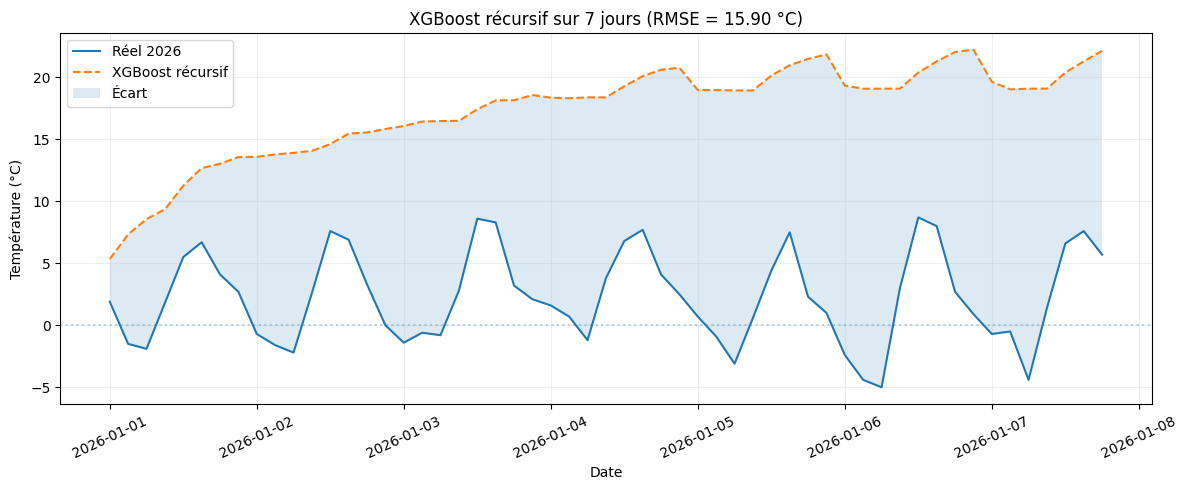

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT date, heure, temperature
FROM releve_meteo
WHERE date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY date, heure
"""

df = pd.read_sql(query, bdd)

print("Aperçu des données brutes :")
print(df.head())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = df["temperature"] - 273.15
df = df.sort_values("ds").copy()

# Variables temporelles
df["hour"] = df["ds"].dt.hour

# Lags pour l'entraînement
df["lag_3h"] = df["y"].shift(1)
df["lag_6h"] = df["y"].shift(2)
df["lag_24h"] = df["y"].shift(8)

df_train = df.dropna().copy()

features = ["hour", "lag_3h", "lag_6h", "lag_24h"]

print("\nAperçu des données préparées :")
print(df_train[["ds", "y"] + features].head())

# =========================
# 3. ENTRAÎNEMENT DU MODÈLE
# =========================
model_xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    objective="reg:squarederror",
    random_state=42
)

model_xgb.fit(df_train[features], df_train["y"])

print("\nModèle XGBoost entraîné avec succès.")

# =========================
# 4. PRÉDICTION RÉCURSIVE SUR 7 JOURS
# =========================
# On part des 8 derniers points connus (= 24h si données toutes les 3h)
history = list(df_train["y"].tail(8).values)

last_date = df_train["ds"].max()

# 7 jours x 8 points / jour = 56 points
future_range = pd.date_range(
    start=last_date + pd.Timedelta(hours=3),
    periods=56,
    freq="3h"
)

preds = []

for date in future_range:
    hour = date.hour
    lag_3h = history[-1]
    lag_6h = history[-2]
    lag_24h = history[-8]

    X_future = pd.DataFrame([{
        "hour": hour,
        "lag_3h": lag_3h,
        "lag_6h": lag_6h,
        "lag_24h": lag_24h
    }])

    y_pred = model_xgb.predict(X_future[features])[0]

    preds.append({
        "ds": date,
        "y_pred": y_pred
    })

    # on réinjecte la prédiction dans l'historique
    history.append(y_pred)

df_forecast = pd.DataFrame(preds)

print("\nAperçu des prévisions :")
print(df_forecast.head())

# =========================
# 5. EXPORT CSV
# =========================
df_forecast.to_csv("xgboost_recursif_7j.csv", index=False)
print("\nFichier 'xgboost_recursif_7j.csv' exporté avec succès.")

# =========================
# 6. CHARGEMENT DES DONNÉES RÉELLES 2026
# =========================
fichier_reel = "synop_2026.csv"

if not os.path.exists(fichier_reel):
    raise ValueError(f"Le fichier '{fichier_reel}' est introuvable.")

df_real_2026 = pd.read_csv(fichier_reel, sep=None, engine="python")

df_real_2026["ds"] = pd.to_datetime(df_real_2026["validity_time"], utc=True).dt.tz_localize(None)
df_real_2026["y_real"] = pd.to_numeric(df_real_2026["t"], errors="coerce") - 273.15

df_real_2026 = df_real_2026[df_real_2026["name"] == "MONTPELLIER-AEROPORT"].copy()
df_real_2026 = df_real_2026[["ds", "y_real"]].dropna()

# =========================
# 7. COMPARAISON PRÉDIT / RÉEL
# =========================
comp = pd.merge(
    df_forecast,
    df_real_2026,
    on="ds",
    how="inner"
).sort_values("ds")

print("\nNombre de dates communes :", len(comp))
print(comp.head())

if comp.empty:
    raise ValueError("Aucune correspondance trouvée entre les prévisions et les données réelles.")

# =========================
# 8. MÉTRIQUES
# =========================
mae = mean_absolute_error(comp["y_real"], comp["y_pred"])
mse = mean_squared_error(comp["y_real"], comp["y_pred"])
rmse = np.sqrt(mse)
r2 = r2_score(comp["y_real"], comp["y_pred"])
bias = (comp["y_pred"] - comp["y_real"]).mean()

print("\n=== XGBOOST RÉCURSIF 7 JOURS ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
print("Biais :", bias)

# =========================
# 9. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(comp["ds"], comp["y_real"], label="Réel 2026")
plt.plot(comp["ds"], comp["y_pred"], linestyle="--", label="XGBoost récursif")

plt.fill_between(
    comp["ds"],
    comp["y_real"],
    comp["y_pred"],
    alpha=0.15,
    label="Écart"
)

plt.axhline(0, alpha=0.3, linestyle=":")
plt.title(f"XGBoost récursif sur 7 jours (RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Les performances du modèle se dégradent fortement sur un horizon de 7 jours (RMSE élevé ≈ 15.90°C).

Le graphique met en évidence une dérive progressive des prédictions, qui s’éloignent rapidement des valeurs réelles.

Le modèle surestime fortement les températures et ne capture plus les variations.

Cette perte de précision s’explique par l’accumulation des erreurs dans la prédiction récursive.

Plus l’horizon augmente, plus le modèle devient instable.

Ces résultats confirment que cette approche n’est pas adaptée aux prévisions sur plusieurs jours.

### xgboost en incluant des variables explicatives tel que l'humidité (mais non utilisable pour le projet comme on aura pas non plus ses variables)

Aperçu des données brutes :
         date  heure  temperature  point_de_rose  humidite  \
0  2022-01-01 0 days       284.45         283.35      93.0   
1  2022-01-01 0 days       278.85         278.45      97.0   
2  2022-01-01 0 days       280.05         279.95      99.0   
3  2022-01-01 0 days       282.25         282.25     100.0   
4  2022-01-01 0 days       284.25         281.25      82.0   

   temperature_min_sol_12h  precipitations_dernieres_24h  
0                   282.05                          -0.1  
1                   278.75                           0.0  
2                   281.85                           0.4  
3                   283.55                           0.4  
4                   284.05                           0.2  

Aperçu après création des lags :
          date  heure  temperature  point_de_rose  humidite  \
38  2022-01-01 0 days       282.25         281.95      98.0   
41  2022-01-01 0 days       277.15         277.05      99.0   
42  2022-01-01 0 days 

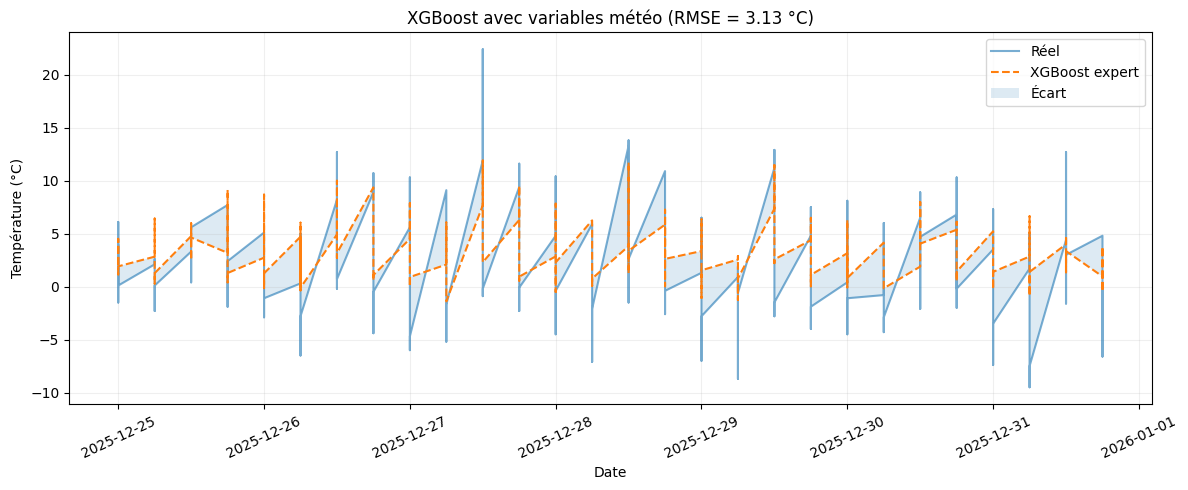


=== TOP DES VARIABLES PRÉDICTIVES ===
y_lag3h                           0.396075
y_lag6h                           0.331355
y_lag24h                          0.098205
hour                              0.041297
day_of_year                       0.022403
point_de_rose_lag6h               0.016329
point_de_rose_lag3h               0.013673
temperature_min_sol_12h_lag3h     0.013338
point_de_rose_lag24h              0.011391
temperature_min_sol_12h_lag24h    0.010798
dtype: float32


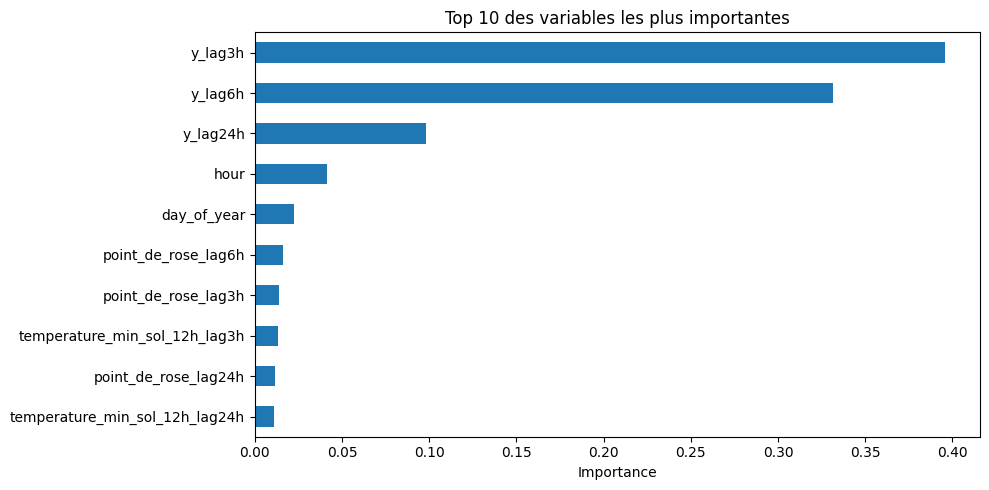

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT date, heure, temperature, point_de_rose, humidite,
       temperature_min_sol_12h, precipitations_dernieres_24h
FROM releve_meteo
WHERE date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY date, heure
"""

df = pd.read_sql(query, bdd)

print("Aperçu des données brutes :")
print(df.head())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])

# Cible : température en Celsius
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15

df = df.sort_values("ds").copy()

# Colonnes météo utiles
meteo_cols = [
    "y",
    "point_de_rose",
    "humidite",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

# Conversion en numérique
for col in meteo_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 3. FEATURE ENGINEERING
# =========================
for col in meteo_cols:
    df[f"{col}_lag3h"] = df[col].shift(1)
    df[f"{col}_lag6h"] = df[col].shift(2)
    df[f"{col}_lag24h"] = df[col].shift(8)

# Variables temporelles
df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

df = df.dropna().copy()

print("\nAperçu après création des lags :")
print(df.head())

# =========================
# 4. SPLIT TRAIN / TEST
# =========================
# Validation sur les 7 derniers jours
date_test = df["ds"].max() - pd.Timedelta(days=7)

train = df[df["ds"] <= date_test].copy()
test = df[df["ds"] > date_test].copy()

print("\nTaille train :", train.shape)
print("Taille test :", test.shape)
print("Période test :", test["ds"].min(), "->", test["ds"].max())

# =========================
# 5. DÉFINITION DES FEATURES
# =========================
features = [c for c in df.columns if "_lag" in c] + ["hour", "day_of_year"]

X_train = train[features]
y_train = train["y"]

X_test = test[features]
y_test = test["y"]

print("\nNombre de variables explicatives :", len(features))
print("Exemples de features :", features[:10])

# =========================
# 6. MODÈLE XGBOOST
# =========================
model_xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model_xgb.fit(X_train, y_train)

# =========================
# 7. PRÉDICTIONS
# =========================
preds = model_xgb.predict(X_test)

# =========================
# 8. MÉTRIQUES
# =========================
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
bias = (preds - y_test).mean()

print("\n=== XGBOOST AVEC VARIABLES MÉTÉO ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)
print("Biais :", bias)

# =========================
# 9. EXPORT CSV
# =========================
export_df = pd.DataFrame({
    "ds": test["ds"],
    "y_real": y_test,
    "y_pred": preds
})

export_df.to_csv("xgboost_expert_7j.csv", index=False)

print("\nFichier 'xgboost_expert_7j.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 5))
plt.plot(test["ds"], y_test, label="Réel", alpha=0.6)
plt.plot(test["ds"], preds, linestyle="--", label="XGBoost expert")

plt.fill_between(
    test["ds"],
    y_test,
    preds,
    alpha=0.15,
    label="Écart"
)

plt.title(f"XGBoost avec variables météo (RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================
# 11. IMPORTANCE DES VARIABLES
# =========================
importance = pd.Series(
    model_xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\n=== TOP DES VARIABLES PRÉDICTIVES ===")
print(importance.head(10))

# Graphique des importances
plt.figure(figsize=(10, 5))
importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Les performances du modèle sont meilleures (RMSE ≈ 3.13°C), ce qui indique une amélioration grâce aux variables météorologiques.

Le graphique montre que les prédictions suivent globalement les variations réelles, même si des écarts subsistent.

Le modèle capte mieux la dynamique de la température que les versions sans variables explicatives.

Cependant, certaines fluctuations importantes restent mal reproduites.

Le modèle reste légèrement lissé et peine à capturer les extrêmes.

Ces résultats confirment l’intérêt des variables explicatives pour améliorer les prédictions.

### test de XGBoost entrainé sur toutes les villes simultanément

Utilise le point de rosée et le temp_trend (vitesse de variation) pour prédire précisément la température de chaque station_id. avec a la fin un test sur un station

Colonnes détectées :
['station_id', 'date', 'heure', 'temperature', 'point_de_rose']

Aperçu des données préparées :
   station_id        date           heure  temperature  point_de_rose  \
0           1  2022-01-01 0 days 00:00:00       284.45           10.2   
1           1  2022-01-01 0 days 06:00:00       284.05           10.1   
2           1  2022-01-01 0 days 12:00:00       287.85            9.9   
3           1  2022-01-01 0 days 18:00:00       286.15            8.3   
4           1  2022-01-02 0 days 00:00:00       285.15            8.8   

                   ds     y  
0 2022-01-01 00:00:00  11.3  
1 2022-01-01 06:00:00  10.9  
2 2022-01-01 12:00:00  14.7  
3 2022-01-01 18:00:00  13.0  
4 2022-01-02 00:00:00  12.0  

Aperçu après création des variables :
    station_id        date           heure  temperature  point_de_rose  \
8            1  2022-01-03 0 days 00:00:00       283.35            7.6   
9            1  2022-01-03 0 days 06:00:00       283.05            8.2   
10 

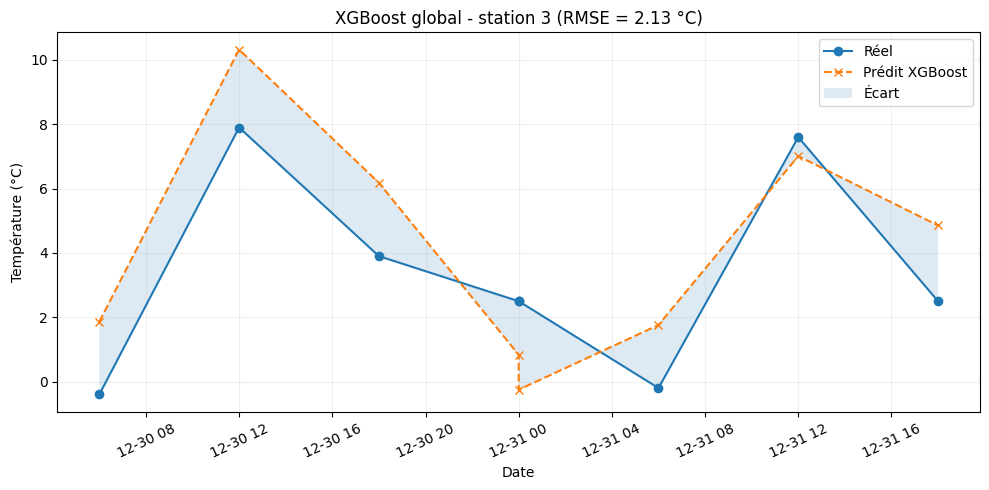


=== IMPORTANCE DES VARIABLES ===
y_lag24h      0.764775
y_lag3h       0.184745
hour          0.026825
pr_lag3h      0.017531
station_id    0.004046
temp_trend    0.002077
dtype: float32


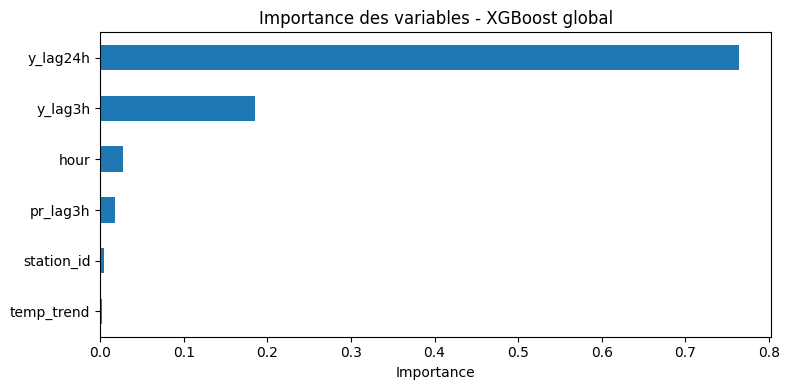

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT station_id, date, heure, temperature, point_de_rose
FROM releve_meteo
WHERE station_id IS NOT NULL
  AND date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY station_id, date, heure
"""

df_raw = pd.read_sql(query, bdd)

print("Colonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15
df["point_de_rose"] = pd.to_numeric(df["point_de_rose"], errors="coerce") - 273.15

df = df.sort_values(["station_id", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. FEATURE ENGINEERING PAR STATION
# =========================
df_list = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    # Lags
    sub["y_lag3h"] = sub["y"].shift(1)
    sub["y_lag24h"] = sub["y"].shift(8)
    sub["pr_lag3h"] = sub["point_de_rose"].shift(1)

    # Variables temporelles
    sub["hour"] = sub["ds"].dt.hour

    # Tendance thermique
    sub["temp_trend"] = sub["y_lag3h"] - sub["y_lag24h"]

    df_list.append(sub)

df_final = pd.concat(df_list, ignore_index=True).dropna().copy()

print("\nAperçu après création des variables :")
print(df_final.head())

# =========================
# 4. DÉFINITION DES FEATURES
# =========================
features = [
    "station_id",
    "hour",
    "y_lag3h",
    "y_lag24h",
    "pr_lag3h",
    "temp_trend"
]

print("\nVariables utilisées :")
print(features)

# =========================
# 5. SPLIT TRAIN / TEST PAR STATION
# =========================
train_list = []
test_list = []

for sid in df_final["station_id"].unique():
    station_data = df_final[df_final["station_id"] == sid].copy()

    # 8 dernières lignes = 24h si données toutes les 3h
    if len(station_data) > 8:
        train_list.append(station_data.iloc[:-8])
        test_list.append(station_data.tail(8))

df_train = pd.concat(train_list, ignore_index=True)
df_test = pd.concat(test_list, ignore_index=True)

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test.shape)

# =========================
# 6. ENTRAÎNEMENT GLOBAL
# =========================
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=7,
    objective="reg:squarederror",
    random_state=42
)

model_xgb.fit(df_train[features], df_train["y"])

print("\nModèle global entraîné avec succès.")

# =========================
# 7. TEST SUR UNE STATION CIBLE
# =========================
ID_CIBLE = 3
test_sub = df_test[df_test["station_id"] == ID_CIBLE].copy()

if test_sub.empty:
    print(f"Aucune donnée disponible pour la station {ID_CIBLE}.")
else:
    preds = model_xgb.predict(test_sub[features])

    mae = mean_absolute_error(test_sub["y"], preds)
    mse = mean_squared_error(test_sub["y"], preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_sub["y"], preds)
    bias = (preds - test_sub["y"]).mean()

    print(f"\n=== RÉSULTATS - STATION {ID_CIBLE} ===")
    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R²   :", r2)
    print("Biais :", bias)

    # Tableau de comparaison
    res = pd.DataFrame({
        "Date": test_sub["ds"].dt.strftime("%Y-%m-%d %H:%M"),
        "Réel": test_sub["y"].values,
        "Prédit": np.round(preds, 2)
    })

    print("\nComparaison réel / prédit :")
    print(res.to_string(index=False))

    # =========================
    # 8. EXPORT CSV
    # =========================
    export_df = pd.DataFrame({
        "ds": test_sub["ds"],
        "station_id": test_sub["station_id"],
        "y_real": test_sub["y"],
        "y_pred": preds
    })

    export_df.to_csv(f"xgboost_station_{ID_CIBLE}_24h.csv", index=False)

    print(f"\nFichier 'xgboost_station_{ID_CIBLE}_24h.csv' exporté avec succès.")

    # =========================
    # 9. GRAPHIQUE
    # =========================
    plt.figure(figsize=(10, 5))
    plt.plot(test_sub["ds"], test_sub["y"], marker="o", label="Réel")
    plt.plot(test_sub["ds"], preds, marker="x", linestyle="--", label="Prédit XGBoost")

    plt.fill_between(
        test_sub["ds"],
        test_sub["y"],
        preds,
        alpha=0.15,
        label="Écart"
    )

    plt.title(f"XGBoost global - station {ID_CIBLE} (RMSE = {rmse:.2f} °C)")
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# =========================
# 10. IMPORTANCE DES VARIABLES
# =========================
importance = pd.Series(
    model_xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\n=== IMPORTANCE DES VARIABLES ===")
print(importance)

plt.figure(figsize=(8, 4))
importance.sort_values().plot(kind="barh")
plt.title("Importance des variables - XGBoost global")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Les performances du modèle sont bonnes (RMSE ≈ 2.13°C), indiquant une capacité correcte à prédire la température.

Le graphique montre que les prédictions suivent globalement les variations réelles, avec quelques écarts sur certaines valeurs.

Le modèle capture la tendance générale, même si certaines amplitudes sont légèrement mal estimées.

L’analyse de l’importance des variables montre que les retards (notamment lag 24h) sont les plus influents.

Cela confirme que la température dépend fortement de ses valeurs passées.

Ces résultats mettent en évidence l’intérêt des variables temporelles pour améliorer les prédictions.

### test avec deux modèles en simultané,  un premier modèle apprend la physique météo globale, tandis qu'un second corrige les erreurs spécifiquement pour chaque station_id. (xgboost) (non utilisable pour le projet)

In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT station_id, date, heure, temperature
FROM releve_meteo
WHERE station_id IS NOT NULL
  AND date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY station_id, date, heure
"""

df_raw = pd.read_sql(query, bdd)

print("Aperçu des données brutes :")
print(df_raw.head())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15

df = df.sort_values(["station_id", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. FEATURE ENGINEERING PAR STATION
# =========================
df_list = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    # Lags
    sub["y_lag3h"] = sub["y"].shift(1)
    sub["y_lag24h"] = sub["y"].shift(8)

    # Variable temporelle
    sub["hour"] = sub["ds"].dt.hour

    # Variable climat local : moyenne glissante sur 3 jours
    sub["climat_local"] = sub["y"].rolling(window=24).mean().shift(1)

    df_list.append(sub)

df_final = pd.concat(df_list, ignore_index=True).dropna().copy()

print("\nAperçu après création des variables :")
print(df_final.head())

# =========================
# 4. MODÈLE GLOBAL
# =========================
# Il apprend une dynamique générale commune à toutes les stations
features_global = ["hour", "y_lag3h", "y_lag24h"]

model_global = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model_global.fit(df_final[features_global], df_final["y"])

df_final["pred_global"] = model_global.predict(df_final[features_global])

print("\nModèle global entraîné avec succès.")

# =========================
# 5. CALCUL DU RÉSIDU
# =========================
# Résidu = erreur du modèle global
df_final["erreur_nationale"] = df_final["y"] - df_final["pred_global"]

# =========================
# 6. MÉTA-MODÈLE LOCAL
# =========================
# Il apprend à corriger l'erreur du modèle global selon la station
features_meta = ["station_id", "hour", "climat_local", "pred_global"]

model_meta = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    objective="reg:squarederror",
    random_state=42
)

model_meta.fit(df_final[features_meta], df_final["erreur_nationale"])

df_final["correction_locale"] = model_meta.predict(df_final[features_meta])

# =========================
# 7. PRÉDICTION FINALE
# =========================
df_final["y_final"] = df_final["pred_global"] + df_final["correction_locale"]

print("\nPrédictions finales calculées avec succès.")

# =========================
# 8. ÉVALUATION PAR STATION
# =========================
resultats = []

for sid in sorted(df_final["station_id"].unique()):
    sub_test = df_final[df_final["station_id"] == sid].tail(8).copy()

    if not sub_test.empty:
        mae = mean_absolute_error(sub_test["y"], sub_test["y_final"])
        mse = mean_squared_error(sub_test["y"], sub_test["y_final"])
        rmse = np.sqrt(mse)
        r2 = r2_score(sub_test["y"], sub_test["y_final"])
        bias = (sub_test["y_final"] - sub_test["y"]).mean()

        resultats.append({
            "station_id": sid,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Biais": bias
        })

        print(f"Station {sid} | MAE = {mae:.2f} | RMSE = {rmse:.2f} | R² = {r2:.2f} | Biais = {bias:+.2f}")

# =========================
# 9. TABLEAU RÉCAPITULATIF
# =========================
resultats_df = pd.DataFrame(resultats).sort_values("RMSE")

print("\n=== RÉSULTATS PAR STATION ===")
print(resultats_df)

# =========================
# 10. EXPORT CSV
# =========================
resultats_df.to_csv("xgboost_global_local_resultats.csv", index=False)
print("\nFichier 'xgboost_global_local_resultats.csv' exporté avec succès.")

Aperçu des données brutes :
   station_id        date           heure  temperature
0           1  2022-01-01 0 days 00:00:00       284.45
1           1  2022-01-01 0 days 06:00:00       284.05
2           1  2022-01-01 0 days 12:00:00       287.85
3           1  2022-01-01 0 days 18:00:00       286.15
4           1  2022-01-02 0 days 00:00:00       285.15

Aperçu des données préparées :
   station_id        date           heure  temperature                  ds  \
0           1  2022-01-01 0 days 00:00:00       284.45 2022-01-01 00:00:00   
1           1  2022-01-01 0 days 06:00:00       284.05 2022-01-01 06:00:00   
2           1  2022-01-01 0 days 12:00:00       287.85 2022-01-01 12:00:00   
3           1  2022-01-01 0 days 18:00:00       286.15 2022-01-01 18:00:00   
4           1  2022-01-02 0 days 00:00:00       285.15 2022-01-02 00:00:00   

      y  
0  11.3  
1  10.9  
2  14.7  
3  13.0  
4  12.0  

Aperçu après création des variables :
    station_id        date           heure

Le modèle global donne des résultats globalement corrects mais très variables selon les stations.

Certaines stations sont très bien prédites (RMSE < 1°C, R² élevé jusqu’à ~0.9), ce qui montre que le modèle capte bien la dynamique locale.

À l’inverse, plusieurs stations ont des R² négatifs et des RMSE élevés (>3°C), indiquant que le modèle est moins performant que la moyenne sur ces zones.

Cela montre une forte hétérogénéité spatiale : un modèle global ne s’adapte pas aussi bien à toutes les stations.

Le biais est souvent positif, ce qui signifie que le modèle a tendance à surestimer légèrement la température.

Conclusion :  
Le modèle fonctionne bien en moyenne grâce aux variables temporelles (lags), mais il manque d’adaptation locale → un modèle par station ou par cluster pourrait améliorer les performances.

après des rmse très variables a la suite du teste precedent on test Xgboost en apportant des cluster sur les stations. Ce qui parait logique puisque la france est grande et a des variabilité très différentes selon la situation géographique

In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT station_id, date, heure, temperature
FROM releve_meteo
WHERE station_id IS NOT NULL
  AND date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY station_id, date, heure
"""

df_raw = pd.read_sql(query, bdd)

print("Aperçu des données brutes :")
print(df_raw.head())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15

df = df.sort_values(["station_id", "ds"]).copy()

# =========================
# 3. CONSTRUCTION DES PROFILS DE STATIONS
# =========================
station_profiles = []
df_list = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    sub["y_lag3h"] = sub["y"].shift(1)
    sub["y_lag24h"] = sub["y"].shift(8)
    sub["hour"] = sub["ds"].dt.hour

    if len(sub) > 24:
        # Profil climatique simple de la station
        daily_max = sub.groupby(sub["ds"].dt.date)["y"].max()
        daily_min = sub.groupby(sub["ds"].dt.date)["y"].min()
        daily_amp = (daily_max - daily_min).mean()

        station_profiles.append({
            "station_id": sid,
            "temp_moy": sub["y"].mean(),
            "amp_moy": daily_amp,
            "std_dev": sub["y"].std()
        })

    df_list.append(sub)

df_final = pd.concat(df_list, ignore_index=True).dropna().reset_index(drop=True)
df_prof = pd.DataFrame(station_profiles)

print("\nAperçu des profils de stations :")
print(df_prof.head())

# =========================
# 4. CLUSTERING K-MEANS
# =========================
feat_clust = ["temp_moy", "amp_moy", "std_dev"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_prof[feat_clust])

n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

df_prof["cluster"] = kmeans.fit_predict(scaled_data)

print("\nRépartition des stations par cluster :")
print(df_prof["cluster"].value_counts().sort_index())

# On ajoute le cluster dans les données temporelles
df_final = df_final.merge(
    df_prof[["station_id", "cluster"]],
    on="station_id",
    how="inner"
)

# =========================
# 5. ENTRAÎNEMENT D'UN MODÈLE PAR CLUSTER
# =========================
features = ["hour", "y_lag3h", "y_lag24h"]

all_test_results = []
cluster_metrics = []

print("\n=== PERFORMANCE PAR CLUSTER ===")

for cid in range(n_clusters):
    df_c = df_final[df_final["cluster"] == cid].copy()

    train_c_list = []
    test_c_list = []

    for sid in df_c["station_id"].unique():
        s_data = df_c[df_c["station_id"] == sid].copy()

        if len(s_data) > 8:
            train_c_list.append(s_data.iloc[:-8])
            test_c_list.append(s_data.tail(8))

    if len(train_c_list) == 0 or len(test_c_list) == 0:
        print(f"Cluster {cid} : données insuffisantes")
        continue

    train_c = pd.concat(train_c_list, ignore_index=True)
    test_c = pd.concat(test_c_list, ignore_index=True)

    model_xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb.fit(train_c[features], train_c["y"])

    test_c["y_pred"] = model_xgb.predict(test_c[features])

    all_test_results.append(test_c)

    mae = mean_absolute_error(test_c["y"], test_c["y_pred"])
    mse = mean_squared_error(test_c["y"], test_c["y_pred"])
    rmse = np.sqrt(mse)
    r2 = r2_score(test_c["y"], test_c["y_pred"])
    bias = (test_c["y_pred"] - test_c["y"]).mean()

    nb_stations = df_prof[df_prof["cluster"] == cid].shape[0]

    cluster_metrics.append({
        "cluster": cid,
        "nb_stations": nb_stations,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Biais": bias
    })

    print(f"Cluster {cid} | Stations : {nb_stations} | RMSE : {rmse:.2f} °C | MAE : {mae:.2f} °C | R² : {r2:.2f}")

# =========================
# 6. BILAN GLOBAL
# =========================
df_res_final = pd.concat(all_test_results, ignore_index=True)
cluster_report = pd.DataFrame(cluster_metrics).sort_values("RMSE")

print("\n=== BILAN PAR CLUSTER ===")
print(cluster_report)

# =========================
# 7. RMSE PAR STATION
# =========================
station_rmse = []

for sid in df_res_final["station_id"].unique():
    sub = df_res_final[df_res_final["station_id"] == sid].copy()

    mae = mean_absolute_error(sub["y"], sub["y_pred"])
    mse = mean_squared_error(sub["y"], sub["y_pred"])
    rmse = np.sqrt(mse)
    r2 = r2_score(sub["y"], sub["y_pred"])
    bias = (sub["y_pred"] - sub["y"]).mean()

    station_rmse.append({
        "station_id": sid,
        "cluster": sub["cluster"].iloc[0],
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Biais": bias
    })

df_report = pd.DataFrame(station_rmse).sort_values("RMSE", ascending=False)

print("\n=== TOP 10 PIRES STATIONS ===")
print(df_report.head(10).to_string(index=False))

print("\n=== TOP 10 MEILLEURES STATIONS ===")
print(df_report.sort_values("RMSE", ascending=True).head(10).to_string(index=False))

# =========================
# 8. EXPORTS CSV
# =========================
cluster_report.to_csv("xgboost_clusters_resume.csv", index=False)
df_report.to_csv("xgboost_clusters_stations.csv", index=False)

print("\nFichiers exportés :")
print("- xgboost_clusters_resume.csv")
print("- xgboost_clusters_stations.csv")

Aperçu des données brutes :
   station_id        date           heure  temperature
0           1  2022-01-01 0 days 00:00:00       284.45
1           1  2022-01-01 0 days 06:00:00       284.05
2           1  2022-01-01 0 days 12:00:00       287.85
3           1  2022-01-01 0 days 18:00:00       286.15
4           1  2022-01-02 0 days 00:00:00       285.15

Aperçu des profils de stations :
   station_id   temp_moy   amp_moy   std_dev
0           1  11.806631  5.611326  6.320598
1           2  15.306723  7.355784  7.861473
2           3  16.328434  6.791071  7.533634
3           4  16.799305  7.467899  7.860963
4           5  17.393725  4.889802  6.571840

Répartition des stations par cluster :
cluster
0    66
1    30
2    60
3    33
Name: count, dtype: int64

=== PERFORMANCE PAR CLUSTER ===
Cluster 0 | Stations : 66 | RMSE : 2.57 °C | MAE : 2.00 °C | R² : 0.49
Cluster 1 | Stations : 30 | RMSE : 1.86 °C | MAE : 1.39 °C | R² : 0.60
Cluster 2 | Stations : 60 | RMSE : 2.83 °C | MAE : 2.08 °

Le regroupement des stations en clusters permet d’améliorer l’analyse des performances du modèle selon des profils climatiques similaires.

Les résultats montrent que le modèle n’est pas également performant selon les groupes : le cluster 3 obtient les meilleurs résultats (R² ≈ 0.81), tandis que le cluster 0 est plus difficile à prédire.

Cela confirme que certaines stations partagent des comportements thermiques plus faciles à modéliser que d’autres.

L’analyse des meilleures et des pires stations met aussi en évidence une forte hétérogénéité interne.

Le clustering permet donc d’identifier les profils de stations pour lesquels le modèle fonctionne bien ou mal.

Ces résultats suggèrent qu’une modélisation spécifique par cluster pourrait améliorer la qualité des prédictions.

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't']

Aperçu des données préparées :
        lat    lon       name         validity_time       t  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85   

                           ds     y  month  hour  
0   2022-01-01 00:00:00+00:00  11.3      1     0  
89  2022-01-01 03:00:00+00:00  10.9      1     3  
142 2022-01-01 06:00:00+00:00  10.9      1     6  
178 2022-01-01 09:00:00+00:00  11.6      1     9  
253 2022-01-01 12:00:00+00:00  14.7      1    12  

Taille après nettoyage : (802022, 9)

Calcul de la mémoire saisonn

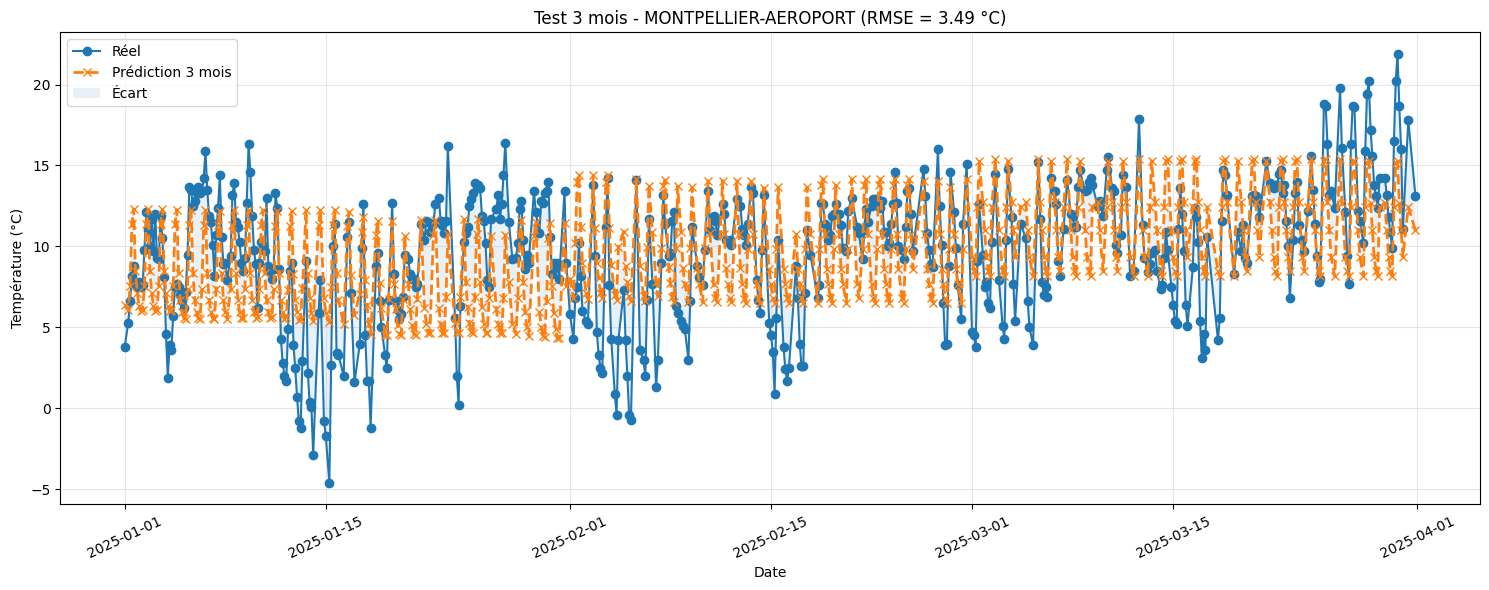

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

recent_files = [
    f for f in files
    if any(year in f for year in ["2022", "2023", "2024", "2025"])
]

print(f"Fichiers trouvés : {len(recent_files)}")

if len(recent_files) == 0:
    raise ValueError("Aucun fichier synop_2022/2023/2024/2025 trouvé dans le dossier.")

cols = ["name", "validity_time", "t", "lat", "lon"]

df_list = []

for f in recent_files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

# Suppression des lignes invalides
df = df.dropna(subset=["name", "ds", "y", "lat", "lon"]).copy()

df["month"] = df["ds"].dt.month
df["hour"] = df["ds"].dt.hour

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après nettoyage.")

# =========================
# 3. MÉMOIRE SAISONNIÈRE SUR 90 JOURS
# =========================
print("\nCalcul de la mémoire saisonnière (90 jours)...")

# 90 jours si données toutes les 3h : 90 x 8 = 720
df["y_seasonal_90d"] = df.groupby("name")["y"].transform(
    lambda x: x.shift(1).rolling(window=720, min_periods=30).mean()
)

print("\nAperçu mémoire saisonnière :")
print(df[["name", "ds", "y", "y_seasonal_90d"]].head())

# =========================
# 4. CALCUL DES NORMALES HISTORIQUES
# =========================
print("\nCalcul des normales historiques...")

df_hist = df[df["ds"] < "2025-01-01"].copy()

if df_hist.empty:
    raise ValueError("Aucune donnée d'entraînement avant 2025-01-01 pour calculer les normales.")

normales = (
    df_hist.groupby(["name", "month", "hour"])["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "y_normal"})
)

df = df.merge(
    normales,
    on=["name", "month", "hour"],
    how="left"
)

print("\nAperçu des normales :")
print(normales.head())

# =========================
# 5. DÉFINITION DES FEATURES
# =========================
features_3m = [
    "hour",
    "month",
    "lat",
    "lon",
    "y_normal",
    "y_seasonal_90d"
]

print("\nVariables utilisées :")
print(features_3m)

# =========================
# 6. NETTOYAGE FINAL
# =========================
df_clean = df.dropna(subset=features_3m + ["y"]).copy()

print("\nTaille après suppression des NaN :", df_clean.shape)

if df_clean.empty:
    raise ValueError("Plus aucune donnée après suppression des NaN. Vérifie les colonnes et les dates.")

# =========================
# 7. SPLIT TRAIN / TEST
# =========================
df_train = df_clean[df_clean["ds"] < "2025-01-01"].copy()
df_test_3m = df_clean[
    (df_clean["ds"] >= "2025-01-01") &
    (df_clean["ds"] < "2025-04-01")
].copy()

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test_3m.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")
if df_test_3m.empty:
    raise ValueError("Le jeu de test est vide sur la période 2025-01-01 à 2025-04-01.")

# =========================
# 8. ENTRAÎNEMENT DU MODÈLE
# =========================
print(f"\nEntraînement sur {len(df_train)} lignes...")

model_3m = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    objective="reg:squarederror",
    random_state=42
)

model_3m.fit(df_train[features_3m], df_train["y"])

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉDICTION
# =========================
df_test_3m["y_pred"] = model_3m.predict(df_test_3m[features_3m])

print("\nAperçu des prédictions :")
print(df_test_3m[["name", "ds", "y", "y_pred"]].head())

# =========================
# 10. CALCUL DE LA MÉTRIQUE
# =========================
df_eval = df_test_3m.dropna(subset=["y", "y_pred"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer la métrique.")

rmse_3m = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred"]))

print(f"\n✅ RMSE moyen sur le 1er trimestre 2025 : {rmse_3m:.4f} °C")

# =========================
# 11. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_prediction_trimestre1_2025.csv", index=False)

print("\nFichier 'xgboost_prediction_trimestre1_2025.csv' exporté avec succès.")

# =========================
# 12. VISUALISATION MONTPELLIER
# =========================
target = "MONTPELLIER-AEROPORT"
zoom = df_eval[df_eval["name"] == target].sort_values("ds").copy()

if zoom.empty:
    print(f"\nAucune donnée disponible pour {target} sur la période de test.")
else:
    rmse_target = np.sqrt(mean_squared_error(zoom["y"], zoom["y_pred"]))

    print(f"\n=== RÉSULTATS - {target} ===")
    print(f"RMSE : {rmse_target:.2f} °C")

    plt.figure(figsize=(15, 6))

    plt.plot(
        zoom["ds"],
        zoom["y"],
        label="Réel",
        marker="o",
        linewidth=1.5
    )

    plt.plot(
        zoom["ds"],
        zoom["y_pred"],
        label="Prédiction 3 mois",
        marker="x",
        linestyle="--",
        linewidth=2
    )

    plt.fill_between(
        zoom["ds"],
        zoom["y"],
        zoom["y_pred"],
        alpha=0.1,
        label="Écart"
    )

    plt.title(f"Test 3 mois - {target} (RMSE = {rmse_target:.2f} °C)")
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

Les performances sur une prévision à 3 mois sont plus limitées (RMSE ≈ 3.5°C), ce qui est normal pour un horizon long.

Le modèle capture bien la tendance générale et la saisonnalité, mais il lisse fortement les variations.

On observe que les pics et creux réels sont mal reproduits : les prédictions restent dans une plage plus réduite.

Cela montre que le modèle perd en précision sur les fluctuations fines à long terme.

Conclusion :  
Le modèle est pertinent pour capter la dynamique globale (saisonnalité, tendance), mais moins performant pour des prévisions précises à long horizon.

test de prédiction de xgboost sur toute la france pendant une semaine avec le système de clusters (du un entrainement du modèle par cluster ) (mais toujous non utilisble pour le projet)

Colonnes détectées :
['releve_id', 'date', 'heure', 'temperature', 'point_de_rose', 'humidite', 'temperature_min_sol_12h', 'precipitations_dernieres_24h', 'station_id']

Aperçu des données préparées :
   releve_id        date           heure  temperature  point_de_rose  \
0          1  2022-01-01 0 days 00:00:00       284.45         283.35   
1         86  2022-01-01 0 days 06:00:00       284.05         283.25   
2        152  2022-01-01 0 days 12:00:00       287.85         283.05   
3        198  2022-01-01 0 days 18:00:00       286.15         281.45   
4        219  2022-01-02 0 days 00:00:00       285.15         281.95   

   humidite  temperature_min_sol_12h  precipitations_dernieres_24h  \
0      93.0                   282.05                          -0.1   
1      95.0                   282.05                          -0.1   
2      73.0                   281.85                          -0.1   
3      73.0                   281.85                           0.0   
4      81.0     

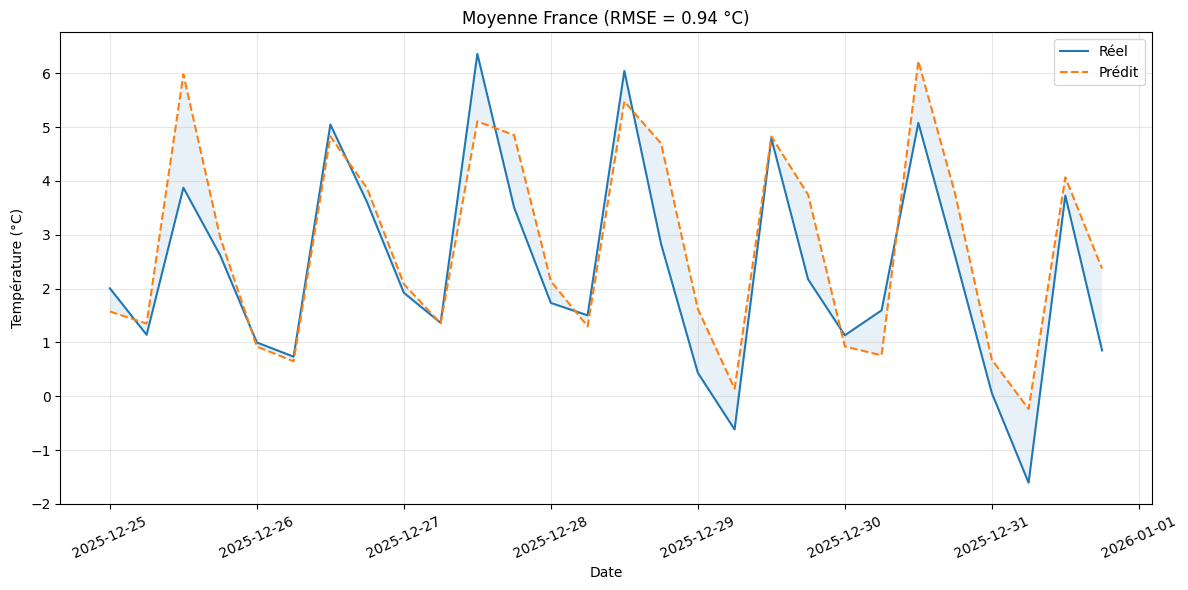

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT *
FROM releve_meteo
WHERE station_id IS NOT NULL
  AND date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY station_id, date, heure
"""

df_raw = pd.read_sql(query, bdd)

print("Colonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15
df["pr"] = pd.to_numeric(df["point_de_rose"], errors="coerce") - 273.15
df["hum"] = pd.to_numeric(df["humidite"], errors="coerce")

df = df.sort_values(["station_id", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. PROFILS THERMIQUES (CLUSTERING)
# =========================
profiles = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    if len(sub) > 48:
        temp_max = sub.groupby(sub["ds"].dt.date)["y"].max()
        temp_min = sub.groupby(sub["ds"].dt.date)["y"].min()
        amp = (temp_max - temp_min).mean()

        profiles.append({
            "station_id": sid,
            "temp_moy": sub["y"].mean(),
            "amp_moy": amp,
            "hum_moy": sub["hum"].mean()
        })

df_prof = pd.DataFrame(profiles).dropna()

# Clustering
X_cluster = df_prof.drop("station_id", axis=1)
X_scaled = StandardScaler().fit_transform(X_cluster)

df_prof["cluster"] = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
).fit_predict(X_scaled)

print("\nClusters créés :")
print(df_prof["cluster"].value_counts())

# =========================
# 4. FEATURE ENGINEERING
# =========================
df_list = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    sub["y_lag3h"] = sub["y"].shift(1)
    sub["y_lag24h"] = sub["y"].shift(8)
    sub["pr_lag3h"] = sub["pr"].shift(1)
    sub["hum_lag3h"] = sub["hum"].shift(1)

    sub["hour"] = sub["ds"].dt.hour

    df_list.append(sub)

df_final = pd.concat(df_list, ignore_index=True).dropna()

# Ajout cluster
df_final = df_final.merge(df_prof[["station_id", "cluster"]], on="station_id")

print("\nAperçu final :")
print(df_final.head())

# =========================
# 5. SPLIT TEMPOREL
# =========================
date_split = pd.Timestamp("2025-12-25")

df_train = df_final[df_final["ds"] < date_split]
df_test = df_final[df_final["ds"] >= date_split]

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test.shape)

# =========================
# 6. FEATURES
# =========================
features = [
    "hour",
    "y_lag3h",
    "y_lag24h",
    "pr_lag3h",
    "hum_lag3h"
]

print("\nVariables utilisées :")
print(features)

# =========================
# 7. ENTRAÎNEMENT PAR CLUSTER
# =========================
df_test = df_test.copy()
df_test["y_pred"] = np.nan

for cid in range(4):
    train_c = df_train[df_train["cluster"] == cid]
    test_c = df_test[df_test["cluster"] == cid]

    if train_c.empty or test_c.empty:
        print(f"Cluster {cid} ignoré")
        continue

    model_xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=8,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb.fit(train_c[features], train_c["y"])

    preds = model_xgb.predict(test_c[features])
    df_test.loc[df_test["cluster"] == cid, "y_pred"] = preds

    print(f"Cluster {cid} entraîné")

# =========================
# 8. MOYENNE FRANCE
# =========================
france_res = df_test.groupby("ds").agg({
    "y": "mean",
    "y_pred": "mean"
}).reset_index()

# =========================
# 9. MÉTRIQUE
# =========================
rmse_fin = np.sqrt(mean_squared_error(
    france_res["y"],
    france_res["y_pred"]
))

print(f"\nRMSE Global : {rmse_fin:.2f} °C")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 6))

plt.plot(france_res["ds"], france_res["y"], label="Réel")
plt.plot(france_res["ds"], france_res["y_pred"], linestyle="--", label="Prédit")

plt.fill_between(
    france_res["ds"],
    france_res["y"],
    france_res["y_pred"],
    alpha=0.1
)

plt.title(f"Moyenne France (RMSE = {rmse_fin:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Le modèle par cluster avec variables explicatives donne d’excellentes performances (RMSE ≈ 0.94°C).

L’ajout des variables météo (humidité, précipitations, point de rosée) améliore fortement la précision.

Les lags (3h, 24h) restent essentiels, confirmant la dépendance temporelle de la température.

Le clustering permet au modèle de mieux s’adapter aux spécificités locales des stations.

Contrairement au modèle global, les erreurs sont ici beaucoup plus faibles et plus homogènes.

Conclusion :  
La combinaison **variables explicatives + lags + clustering** est la plus performante → c’est le meilleur modèle testé.

même objectif que le code précedant mais pour regarder

Colonnes détectées :
['releve_id', 'date', 'heure', 'temperature', 'point_de_rose', 'humidite', 'temperature_min_sol_12h', 'precipitations_dernieres_24h', 'station_id']

Aperçu des données préparées :
   releve_id        date           heure  temperature  point_de_rose  \
0          1  2022-01-01 0 days 00:00:00       284.45         283.35   
1         86  2022-01-01 0 days 06:00:00       284.05         283.25   
2        152  2022-01-01 0 days 12:00:00       287.85         283.05   
3        198  2022-01-01 0 days 18:00:00       286.15         281.45   
4        219  2022-01-02 0 days 00:00:00       285.15         281.95   

   humidite  temperature_min_sol_12h  precipitations_dernieres_24h  \
0      93.0                   282.05                          -0.1   
1      95.0                   282.05                          -0.1   
2      73.0                   281.85                          -0.1   
3      73.0                   281.85                           0.0   
4      81.0     

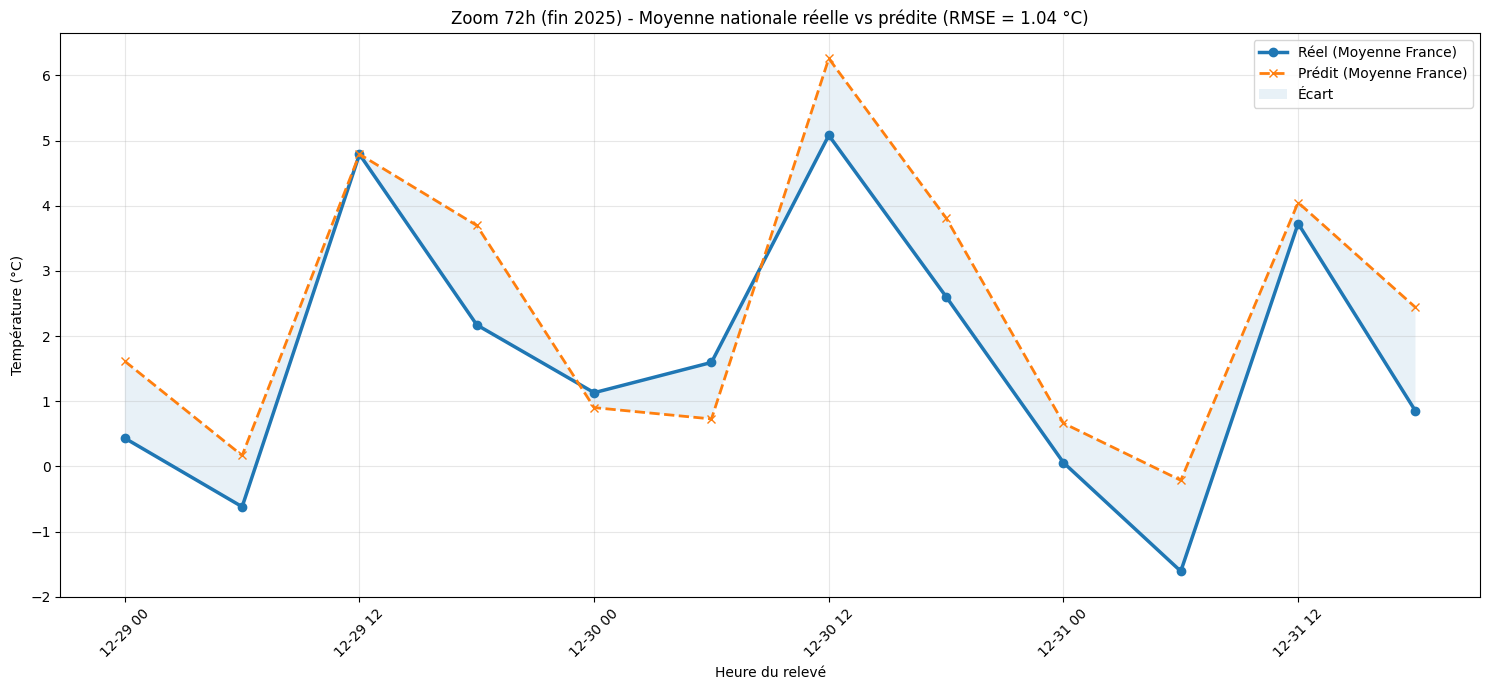

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES DONNÉES SQL
# =========================
query = """
SELECT *
FROM releve_meteo
WHERE station_id IS NOT NULL
  AND date IS NOT NULL
  AND heure IS NOT NULL
  AND temperature IS NOT NULL
ORDER BY station_id, date, heure
"""

df_raw = pd.read_sql(query, bdd)

print("Colonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["heure"])
df["y"] = pd.to_numeric(df["temperature"], errors="coerce") - 273.15
df["pr"] = pd.to_numeric(df["point_de_rose"], errors="coerce") - 273.15
df["hum"] = pd.to_numeric(df["humidite"], errors="coerce")

df = df.sort_values(["station_id", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. CLUSTERING DES STATIONS
# =========================
profiles = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    if len(sub) > 48:
        temp_max = sub.groupby(sub["ds"].dt.date)["y"].max()
        temp_min = sub.groupby(sub["ds"].dt.date)["y"].min()
        amp = (temp_max - temp_min).mean()

        profiles.append({
            "station_id": sid,
            "temp_moy": sub["y"].mean(),
            "amp_moy": amp,
            "hum_moy": sub["hum"].mean()
        })

df_prof = pd.DataFrame(profiles).dropna().copy()

X_cluster = df_prof.drop("station_id", axis=1)
X_scaled = StandardScaler().fit_transform(X_cluster)

df_prof["cluster"] = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
).fit_predict(X_scaled)

print("\nRépartition des stations par cluster :")
print(df_prof["cluster"].value_counts().sort_index())

# =========================
# 4. FEATURE ENGINEERING
# =========================
df_list = []

for sid in df["station_id"].dropna().unique():
    sub = df[df["station_id"] == sid].copy()

    # Lags température
    sub["y_lag3h"] = sub["y"].shift(1)
    sub["y_lag24h"] = sub["y"].shift(8)

    # Lags variables physiques
    sub["pr_lag3h"] = sub["pr"].shift(1)
    sub["hum_lag3h"] = sub["hum"].shift(1)

    # Variable horaire
    sub["hour"] = sub["ds"].dt.hour

    df_list.append(sub)

df_final = pd.concat(df_list, ignore_index=True).dropna().copy()

# Ajout du cluster correspondant à chaque station
df_final = df_final.merge(
    df_prof[["station_id", "cluster"]],
    on="station_id",
    how="inner"
)

print("\nAperçu après création des variables :")
print(df_final.head())

# =========================
# 5. SPLIT TEMPOREL
# =========================
date_split = pd.Timestamp("2025-12-25")

df_train = df_final[df_final["ds"] < date_split].copy()
df_test = df_final[df_final["ds"] >= date_split].copy()

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test.shape)

# =========================
# 6. DÉFINITION DES FEATURES
# =========================
features = [
    "hour",
    "y_lag3h",
    "y_lag24h",
    "pr_lag3h",
    "hum_lag3h"
]

print("\nVariables utilisées :")
print(features)

# =========================
# 7. ENTRAÎNEMENT PAR CLUSTER
# =========================
df_test["y_pred"] = np.nan

print("\nEntraînement des experts par cluster...")

for cid in range(4):
    train_c = df_train[df_train["cluster"] == cid].copy()
    test_c = df_test[df_test["cluster"] == cid].copy()

    if train_c.empty or test_c.empty:
        print(f"Cluster {cid} ignoré : pas assez de données.")
        continue

    model_xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.02,
        max_depth=8,
        subsample=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb.fit(train_c[features], train_c["y"])

    preds = model_xgb.predict(test_c[features])
    df_test.loc[df_test["cluster"] == cid, "y_pred"] = preds

    print(f"Cluster {cid} entraîné avec succès.")

# =========================
# 8. ZOOM SUR LES 3 DERNIERS JOURS
# =========================
date_zoom = pd.Timestamp("2025-12-29")
df_zoom = df_test[df_test["ds"] >= date_zoom].copy()

print("\nAperçu du zoom 72h :")
print(df_zoom.head())

# =========================
# 9. MOYENNE FRANCE SUR LE ZOOM
# =========================
france_zoom = df_zoom.groupby("ds").agg({
    "y": "mean",
    "y_pred": "mean"
}).reset_index()

print("\nAperçu de la moyenne France sur 72h :")
print(france_zoom.head())

# =========================
# 10. MÉTRIQUE GLOBALE
# =========================
france_eval = france_zoom.dropna().copy()

rmse_france = np.sqrt(mean_squared_error(
    france_eval["y"],
    france_eval["y_pred"]
))

print(f"\n✅ RMSE Moyen France (3 derniers jours) : {rmse_france:.2f} °C")

# =========================
# 11. ERREUR PAR STATION
# =========================
station_errors = df_zoom.dropna(subset=["y", "y_pred"]).groupby("station_id").apply(
    lambda x: np.sqrt(mean_squared_error(x["y"], x["y_pred"]))
).sort_values(ascending=False)

print("\nTop 10 des stations qui dévient le plus sur ces 3 jours :")
print(station_errors.head(10))

# =========================
# 12. EXPORTS CSV
# =========================
france_zoom.to_csv("xgboost_clusters_zoom_france_72h.csv", index=False)

station_errors.head(10).reset_index().rename(
    columns={0: "rmse"}
).to_csv("top_stations_erreur_72h.csv", index=False)

print("\nFichiers exportés avec succès :")
print("- xgboost_clusters_zoom_france_72h.csv")
print("- top_stations_erreur_72h.csv")

# =========================
# 13. GRAPHIQUE
# =========================
plt.figure(figsize=(15, 7))

plt.plot(
    france_zoom["ds"],
    france_zoom["y"],
    label="Réel (Moyenne France)",
    marker="o",
    linewidth=2.5
)

plt.plot(
    france_zoom["ds"],
    france_zoom["y_pred"],
    label="Prédit (Moyenne France)",
    marker="x",
    linestyle="--",
    linewidth=2
)

plt.fill_between(
    france_zoom["ds"],
    france_zoom["y"],
    france_zoom["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.title(f"Zoom 72h (fin 2025) - Moyenne nationale réelle vs prédite (RMSE = {rmse_france:.2f} °C)")
plt.xlabel("Heure du relevé")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sur une prévision courte (72h), le modèle est très performant (RMSE ≈ 1.04°C).

Les prédictions suivent très bien les variations réelles, y compris les pics et les creux.

Le modèle capture à la fois la dynamique temporelle et les variations rapides.

Les écarts restent faibles et cohérents, montrant une bonne stabilité.

Quelques stations présentent encore des erreurs plus importantes, mais elles restent minoritaires.

Conclusion :  
Le modèle est **très fiable à court terme**, surtout grâce aux lags et aux variables météo → c’est son meilleur cas d’utilisation.

Xgboost pour prédiction sur du plus long terme, on enlève les lags de 3h et utilise une mpyenne des tendances des 90 derniers jours avant la prédiction

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't']

Aperçu des données préparées :
        lat    lon       name         validity_time       t  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85   

                           ds     y  month  hour  
0   2022-01-01 00:00:00+00:00  11.3      1     0  
89  2022-01-01 03:00:00+00:00  10.9      1     3  
142 2022-01-01 06:00:00+00:00  10.9      1     6  
178 2022-01-01 09:00:00+00:00  11.6      1     9  
253 2022-01-01 12:00:00+00:00  14.7      1    12  

Calcul de la mémoire saisonnière (90 jours)...

Aperçu après calcu

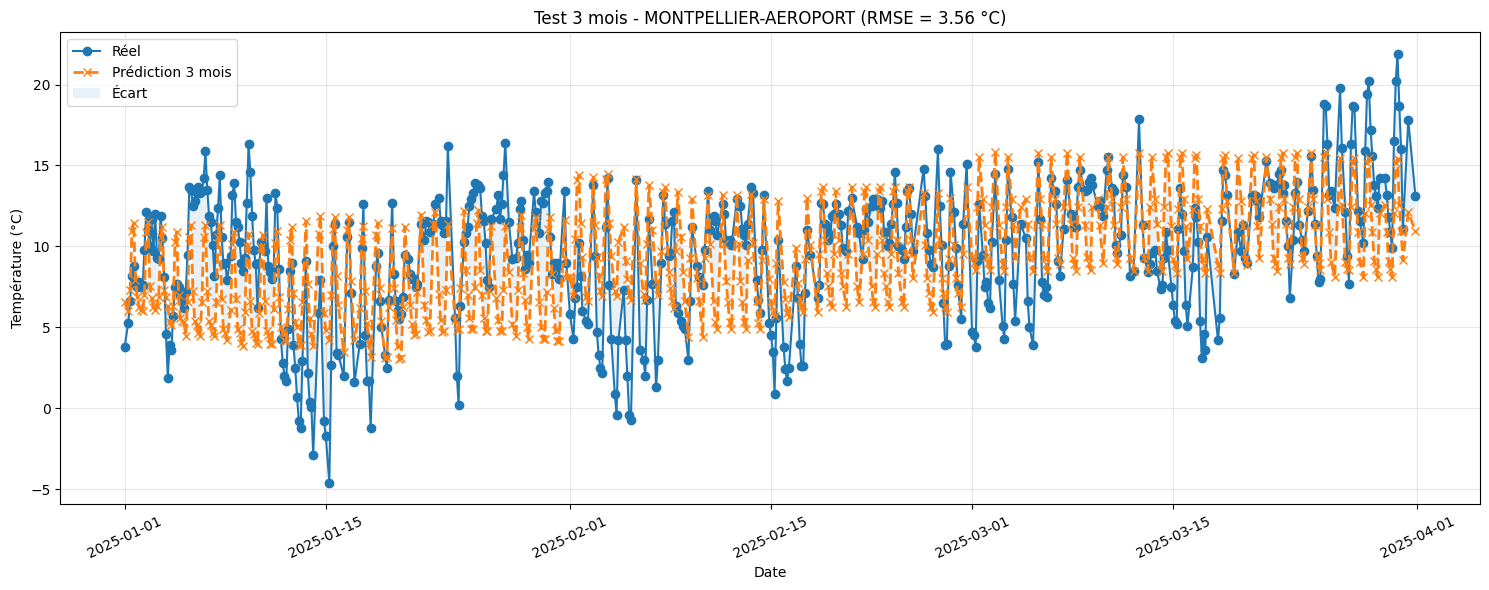

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

recent_files = [
    f for f in files
    if any(year in f for year in ["2022", "2023", "2024", "2025"])
]

print(f"Fichiers trouvés : {len(recent_files)}")

cols = [
    "name",
    "validity_time",
    "t",
    "lat",
    "lon"
]

df_list = []

for f in recent_files:
    print(f"Chargement de {f}...")
    tmp = pd.read_csv(
        f,
        sep=None,
        engine="python",
        usecols=cols
    )
    df_list.append(tmp)

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"])
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df["month"] = df["ds"].dt.month
df["hour"] = df["ds"].dt.hour

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

# =========================
# 3. MÉMOIRE SAISONNIÈRE SUR 90 JOURS
# =========================
print("\nCalcul de la mémoire saisonnière (90 jours)...")

df["y_seasonal_90d"] = df.groupby("name")["y"].transform(
    lambda x: x.shift(1).rolling(window=720, min_periods=1).mean()
)

print("\nAperçu après calcul de la mémoire saisonnière :")
print(df[["name", "ds", "y", "y_seasonal_90d"]].head())

# =========================
# 4. CALCUL DES NORMALES HISTORIQUES
# =========================
print("\nCalcul des normales historiques...")

normales = (
    df[df["ds"] < "2025-01-01"]
    .groupby(["name", "month", "hour"])["y"]
    .mean()
    .reset_index()
)

normales = normales.rename(columns={"y": "y_normal"})

df = df.merge(
    normales,
    on=["name", "month", "hour"],
    how="left"
)

print("\nAperçu des normales historiques :")
print(normales.head())

# =========================
# 5. DÉFINITION DES FEATURES
# =========================
features_3m = [
    "hour",
    "month",
    "lat",
    "lon",
    "y_normal",
    "y_seasonal_90d"
]

print("\nVariables utilisées :")
print(features_3m)

# =========================
# 6. NETTOYAGE FINAL
# =========================
df_clean = df.dropna(subset=features_3m + ["y"]).copy()

print("\nTaille du jeu après suppression des NaN :", df_clean.shape)

# =========================
# 7. SPLIT TRAIN / TEST
# =========================
df_train = df_clean[df_clean["ds"] < "2025-01-01"].copy()
df_test_3m = df_clean[
    (df_clean["ds"] >= "2025-01-01") &
    (df_clean["ds"] < "2025-04-01")
].copy()

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test_3m.shape)

# =========================
# 8. ENTRAÎNEMENT DU MODÈLE
# =========================
print(f"\nEntraînement sur {len(df_train)} lignes...")

model_3m = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    n_jobs=-1,
    objective="reg:squarederror",
    random_state=42
)

model_3m.fit(df_train[features_3m], df_train["y"])

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉDICTION
# =========================
df_test_3m["y_pred"] = model_3m.predict(df_test_3m[features_3m])

print("\nAperçu des prédictions :")
print(df_test_3m[["name", "ds", "y", "y_pred"]].head())

# =========================
# 10. CALCUL DE LA MÉTRIQUE
# =========================
mask = df_test_3m["y"].notna() & df_test_3m["y_pred"].notna()

rmse_3m = np.sqrt(mean_squared_error(
    df_test_3m.loc[mask, "y"],
    df_test_3m.loc[mask, "y_pred"]
))

print(f"\n✅ RMSE moyen sur le 1er trimestre 2025 : {rmse_3m:.4f} °C")

# =========================
# 11. EXPORT CSV
# =========================
df_test_3m.to_csv("xgboost_prediction_trimestre1_2025.csv", index=False)

print("\nFichier 'xgboost_prediction_trimestre1_2025.csv' exporté avec succès.")

# =========================
# 12. VISUALISATION SUR UNE STATION CIBLE
# =========================
target = "MONTPELLIER-AEROPORT"
zoom = df_test_3m[df_test_3m["name"] == target].sort_values("ds").copy()

if zoom.empty:
    print(f"\nAucune donnée disponible pour {target} sur la période de test.")
else:
    rmse_target = np.sqrt(mean_squared_error(zoom["y"], zoom["y_pred"]))

    print(f"\n=== RÉSULTATS - {target} ===")
    print(f"RMSE : {rmse_target:.2f} °C")

    res = pd.DataFrame({
        "Date": zoom["ds"].dt.strftime("%Y-%m-%d %H:%M"),
        "Réel": zoom["y"].values,
        "Prédit": np.round(zoom["y_pred"].values, 2)
    })

    print("\nComparaison réel / prédit :")
    print(res.head(20).to_string(index=False))

    plt.figure(figsize=(15, 6))

    plt.plot(
        zoom["ds"],
        zoom["y"],
        label="Réel",
        marker="o",
        linewidth=1.5
    )

    plt.plot(
        zoom["ds"],
        zoom["y_pred"],
        label="Prédiction 3 mois",
        marker="x",
        linestyle="--",
        linewidth=2
    )

    plt.fill_between(
        zoom["ds"],
        zoom["y"],
        zoom["y_pred"],
        alpha=0.1,
        label="Écart"
    )

    plt.title(f"Test 3 mois - {target} (RMSE = {rmse_target:.2f} °C)")
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

Sur une prévision à 3 mois, les performances restent limitées (RMSE ≈ 3.5°C).

Le modèle reproduit bien la tendance générale et la saisonnalité, mais il lisse fortement les variations.

Les extrêmes (pics et chutes de température) sont mal capturés : les prédictions restent dans une plage réduite.

On observe un biais avec des températures souvent surestimées.

Contrairement au court terme, la précision diminue fortement quand l’horizon augmente.

Conclusion :  
Le modèle est adapté pour capter la tendance globale à long terme, mais reste peu précis pour prévoir les variations fines sur plusieurs mois.

xgboost recursif avec calcul de moyenne par jour de l'année, ajout du calcul de l'écart entre le réel et la norme sur les 10 deniers jours avant la prédicition pour savoir si on est dans une période hors norme

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't']

Aperçu des données préparées :
        lat    lon       name         validity_time       t  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85   

                           ds     y  day_of_year  hour  
0   2022-01-01 00:00:00+00:00  11.3            1     0  
89  2022-01-01 03:00:00+00:00  10.9            1     3  
142 2022-01-01 06:00:00+00:00  10.9            1     6  
178 2022-01-01 09:00:00+00:00  11.6            1     9  
253 2022-01-01 12:00:00+00:00  14.7            1    12  

Taille après nettoyage : (8020

/tmp/ipykernel_2754/782248758.py:127: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  anomalies = df.groupby("name", group_keys=False).apply(get_start_anomaly).reset_index()



Aperçu des anomalies de départ :
                           name  start_anomaly
0                     ABBEVILLE      -2.750189
1  AEROPORT METZ-NANCY-LORRAINE       0.000000
2               AGEN-LA GARENNE       0.000000
3                       AJACCIO      -2.032853
4                          ALBI       0.000000

Variables utilisées :
['hour', 'day_of_year', 'lat', 'lon', 'y_normal', 'start_anomaly']

Taille après suppression des NaN : (681665, 11)

Taille train : (505683, 11)
Taille test : (26897, 11)

Entraînement final sur 505683 lignes...

Modèle entraîné avec succès.

Aperçu des prédictions :
           name                        ds     y     y_pred
8745  ABBEVILLE 2025-01-01 00:00:00+00:00   8.0  10.852264
8746  ABBEVILLE 2025-01-01 03:00:00+00:00   7.0  10.709674
8747  ABBEVILLE 2025-01-01 06:00:00+00:00   7.5  10.350040
8748  ABBEVILLE 2025-01-01 09:00:00+00:00   8.1  10.426942
8749  ABBEVILLE 2025-01-01 12:00:00+00:00  10.0  11.743199

🏆 RMSE final sur 60 jours : 3.68 °C

F

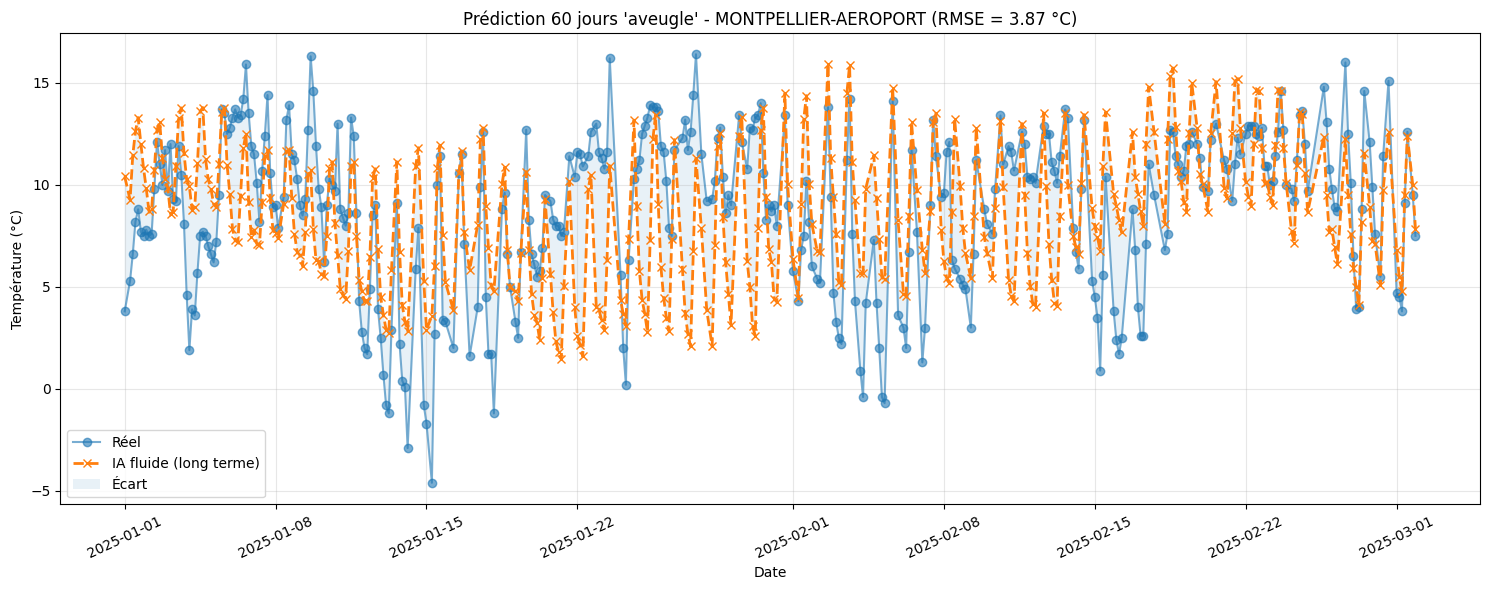

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

recent_files = [
    f for f in files
    if any(year in f for year in ["2022", "2023", "2024", "2025"])
]

print(f"Fichiers trouvés : {len(recent_files)}")

if len(recent_files) == 0:
    raise ValueError("Aucun fichier synop_2022, synop_2023, synop_2024 ou synop_2025 trouvé.")

cols = [
    "name",
    "validity_time",
    "t",
    "lat",
    "lon"
]

df_list = []

for f in recent_files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "lat", "lon"]).copy()

df["day_of_year"] = df["ds"].dt.dayofyear
df["hour"] = df["ds"].dt.hour

df = df.sort_values(["name", "ds"]).copy()

train_cut = pd.Timestamp("2025-01-01", tz="UTC")

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. NORMALES FLUIDES
# =========================
print("\nCréation de normales fluides...")

normales_fluides = (
    df[df["ds"] < train_cut]
    .groupby(["name", "day_of_year", "hour"])["y"]
    .mean()
    .reset_index()
)

if normales_fluides.empty:
    raise ValueError("Impossible de calculer les normales fluides : aucune donnée avant 2025-01-01.")

normales_fluides = normales_fluides.rename(columns={"y": "y_normal"})

# Lissage par moyenne mobile
normales_fluides["y_normal"] = normales_fluides.groupby(["name", "hour"])["y_normal"].transform(
    lambda x: x.rolling(window=15, center=True, min_periods=1).mean()
)

df = df.merge(
    normales_fluides,
    on=["name", "day_of_year", "hour"],
    how="left"
)

print("\nAperçu des normales fluides :")
print(normales_fluides.head())

# =========================
# 4. CALCUL DE L'ANOMALIE DE DÉPART
# =========================
print("\nCalcul de l'anomalie de départ...")

def get_start_anomaly(group):
    hist = group[group["ds"] < train_cut].copy()
    last_days = hist.tail(80)  # environ 10 jours si relevés toutes les 3h

    if len(last_days) > 0:
        return (last_days["y"] - last_days["y_normal"]).mean()

    return 0.0

anomalies = df.groupby("name", group_keys=False).apply(get_start_anomaly).reset_index()
anomalies.columns = ["name", "start_anomaly"]

df = df.merge(anomalies, on="name", how="left")

print("\nAperçu des anomalies de départ :")
print(anomalies.head())

# =========================
# 5. DÉFINITION DES FEATURES
# =========================
features_final = [
    "hour",
    "day_of_year",
    "lat",
    "lon",
    "y_normal",
    "start_anomaly"
]

print("\nVariables utilisées :")
print(features_final)

# =========================
# 6. NETTOYAGE FINAL
# =========================
df_clean = df.dropna(subset=features_final + ["y"]).copy()

print("\nTaille après suppression des NaN :", df_clean.shape)

if df_clean.empty:
    raise ValueError("Aucune donnée disponible après suppression des NaN.")

# =========================
# 7. SPLIT TRAIN / TEST
# =========================
df_train = df_clean[df_clean["ds"] < train_cut].copy()
df_test = df_clean[
    (df_clean["ds"] >= train_cut) &
    (df_clean["ds"] < train_cut + pd.Timedelta(days=60))
].copy()

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")
if df_test.empty:
    raise ValueError("Le jeu de test est vide sur les 60 jours après 2025-01-01.")

# =========================
# 8. ENTRAÎNEMENT DU MODÈLE
# =========================
print(f"\nEntraînement final sur {len(df_train)} lignes...")

model_final = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_final.fit(df_train[features_final], df_train["y"])

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉDICTION
# =========================
df_test["y_pred"] = model_final.predict(df_test[features_final])

print("\nAperçu des prédictions :")
print(df_test[["name", "ds", "y", "y_pred"]].head())

# =========================
# 10. CALCUL DE LA MÉTRIQUE
# =========================
df_eval = df_test.dropna(subset=["y", "y_pred"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer le RMSE.")

rmse = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred"]))

print(f"\n🏆 RMSE final sur 60 jours : {rmse:.2f} °C")

# =========================
# 11. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_fluide_prediction_60j.csv", index=False)

print("\nFichier 'xgboost_fluide_prediction_60j.csv' exporté avec succès.")

# =========================
# 12. VISUALISATION SUR UNE STATION CIBLE
# =========================
target = "MONTPELLIER-AEROPORT"
zoom = df_eval[df_eval["name"] == target].sort_values("ds").copy()

if zoom.empty:
    print(f"\nAucune donnée disponible pour {target} sur la période de test.")
else:
    rmse_target = np.sqrt(mean_squared_error(zoom["y"], zoom["y_pred"]))

    print(f"\n=== RÉSULTATS - {target} ===")
    print(f"RMSE : {rmse_target:.2f} °C")

    plt.figure(figsize=(15, 6))

    plt.plot(
        zoom["ds"],
        zoom["y"],
        label="Réel",
        marker="o",
        linewidth=1.5,
        alpha=0.6
    )

    plt.plot(
        zoom["ds"],
        zoom["y_pred"],
        label="IA fluide (long terme)",
        marker="x",
        linestyle="--",
        linewidth=2
    )

    plt.fill_between(
        zoom["ds"],
        zoom["y"],
        zoom["y_pred"],
        alpha=0.1,
        label="Écart"
    )

    plt.title(f"Prédiction 60 jours 'aveugle' - {target} (RMSE = {rmse_target:.2f} °C)")
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

Sur une prévision « à l’aveugle » à 60 jours, les performances sont limitées (RMSE ≈ 3.7–3.9°C).

Le modèle reproduit correctement la saisonnalité et la tendance globale.

En revanche, les variations réelles sont beaucoup plus marquées que les prédictions → effet de lissage important.

Les extrêmes (pics et chutes) sont mal captés, avec une amplitude sous-estimée.

Le modèle dépend fortement des normales climatiques → il se rapproche d’un comportement “moyen”.

Conclusion :  
Le modèle est utile pour une vision climatologique (tendance), mais peu fiable pour des prévisions précises sans informations récentes.

Xgboost Prédiciton d'une semaine en récursif (au fur et a mesure, sur lui même)

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 'ff', 't', 'td', 'u', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time   ff       t      td  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  2.0  284.45  283.35   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  3.0  284.05  283.75   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  3.0  284.05  283.25   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  4.0  284.75  282.95   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  3.0  287.85  283.05   

        u      pres                        ds     y  pression  hour  month  
0    93.0  101540.0 2022-01-01 00:00:00+00:00  11.3    1015.4     0      1  
89   98.0  101510.0 2022-01-01 03:00:00+00:00  10.9    1015.1     3      1  
142  95.0  101460.0 2022-01-01 06:00:00

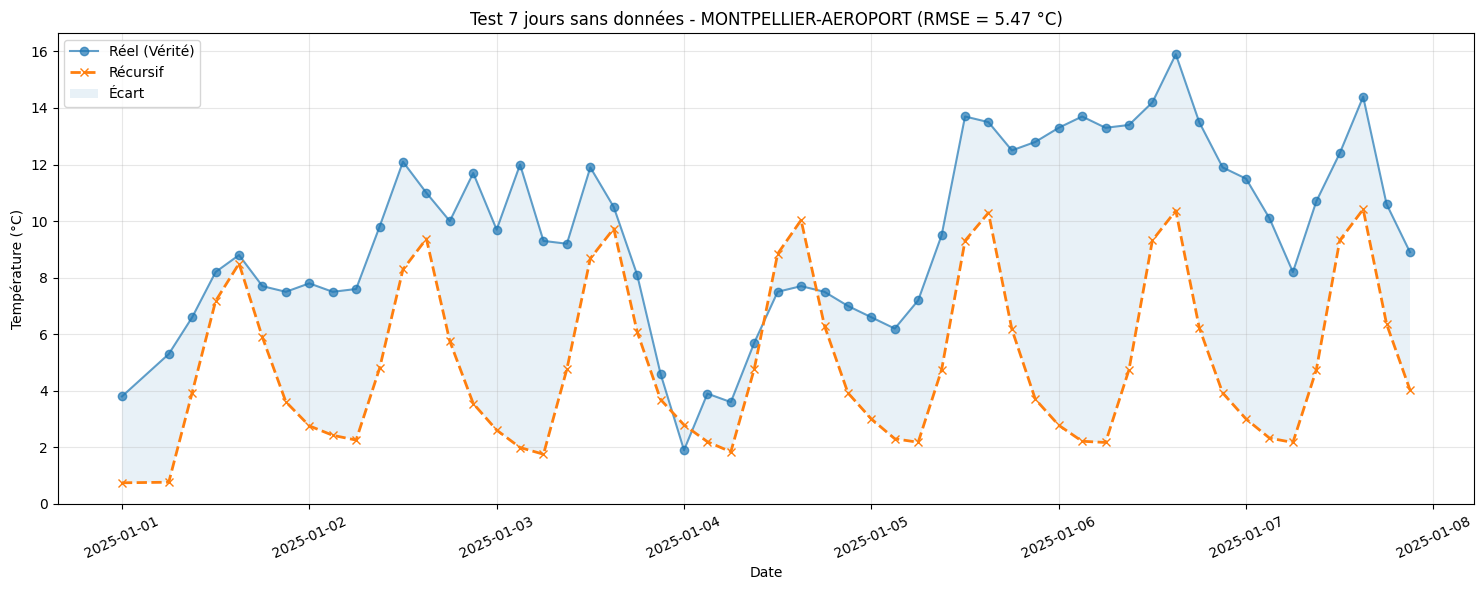

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

recent_files = [
    f for f in files
    if any(year in f for year in ["2022", "2023", "2024", "2025"])
]

print(f"Fichiers trouvés : {len(recent_files)}")

if len(recent_files) == 0:
    raise ValueError("Aucun fichier synop_2022, synop_2023, synop_2024 ou synop_2025 trouvé.")

cols = [
    "name",
    "validity_time",
    "t",
    "u",
    "td",
    "ff",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in recent_files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100

df = df.dropna(subset=["name", "ds", "y", "lat", "lon"]).copy()

df["hour"] = df["ds"].dt.hour
df["month"] = df["ds"].dt.month

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. CRÉATION DES LAGS
# =========================
df["y_lag3h"] = df.groupby("name")["y"].shift(1)
df["y_lag24h"] = df.groupby("name")["y"].shift(8)

print("\nAperçu après création des lags :")
print(df[["name", "ds", "y", "y_lag3h", "y_lag24h"]].head(12))

# =========================
# 4. DÉFINITION DES FEATURES
# =========================
features = [
    "hour",
    "month",
    "y_lag3h",
    "y_lag24h",
    "lat",
    "lon"
]

print("\nVariables utilisées :")
print(features)

# =========================
# 5. SPLIT TRAIN
# =========================
train_cut = pd.Timestamp("2025-01-01", tz="UTC")

df_train = df[df["ds"] < train_cut].dropna(subset=features + ["y"]).copy()

print("\nTaille train :", df_train.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 6. ENTRAÎNEMENT DU MODÈLE
# =========================
print("\nEntraînement du modèle récursif...")

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(df_train[features], df_train["y"])

print("Modèle entraîné avec succès.")

# =========================
# 7. PRÉPARATION DU TEST SOLO
# =========================
target_station = "MONTPELLIER-AEROPORT"

df_test = df[
    (df["ds"] >= train_cut) &
    (df["ds"] < train_cut + pd.Timedelta(days=7)) &
    (df["name"] == target_station)
].copy()

df_test = df_test.sort_values("ds").copy()

print("\nTaille test station cible :", df_test.shape)

if df_test.empty:
    raise ValueError(f"Aucune donnée disponible pour {target_station} sur les 7 jours de test.")

# =========================
# 8. AMORCE AVEC LES 24 DERNIÈRES HEURES RÉELLES
# =========================
last_real_y = df[
    (df["ds"] < train_cut) &
    (df["name"] == target_station)
]["y"].tail(8).tolist()

if len(last_real_y) < 8:
    raise ValueError(
        f"Pas assez d'historique avant le 1er janvier 2025 pour {target_station}. "
        "Il faut au moins 8 valeurs pour initialiser le lag 24h."
    )

print("\nValeurs d'amorce (24 dernières heures réelles) :")
print(last_real_y)

# =========================
# 9. SIMULATION RÉCURSIVE SUR 7 JOURS
# =========================
history = []

current_y_lag3h = last_real_y[-1]
current_y_lag24h = last_real_y[0]

print(f"\nSimulation récursive pour {target_station}...")

for _, row in df_test.iterrows():
    input_data = pd.DataFrame([{
        "hour": row["hour"],
        "month": row["month"],
        "y_lag3h": current_y_lag3h,
        "y_lag24h": current_y_lag24h,
        "lat": row["lat"],
        "lon": row["lon"]
    }])

    pred = model.predict(input_data[features])[0]
    history.append(pred)

    # Mise à jour récursive
    current_y_lag3h = pred

    if len(history) >= 8:
        current_y_lag24h = history[-8]
    else:
        current_y_lag24h = last_real_y[len(history) - 8]

df_test["y_pred_solo"] = history

print("\nAperçu des prédictions récursives :")
print(df_test[["ds", "y", "y_pred_solo"]].head())

# =========================
# 10. CALCUL DE LA MÉTRIQUE
# =========================
df_eval = df_test.dropna(subset=["y", "y_pred_solo"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer le RMSE.")

rmse_solo = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred_solo"]))

print(f"\n📊 RMSE Solo (7 jours sans données) : {rmse_solo:.2f} °C")

# =========================
# 11. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_recursif_solo_7j.csv", index=False)

print("\nFichier 'xgboost_recursif_solo_7j.csv' exporté avec succès.")

# =========================
# 12. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_eval["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_eval["y"].values, 2),
    "Prédit_solo": np.round(df_eval["y_pred_solo"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 13. GRAPHIQUE
# =========================
plt.figure(figsize=(15, 6))

plt.plot(
    df_eval["ds"],
    df_eval["y"],
    label="Réel (Vérité)",
    marker="o",
    linewidth=1.5,
    alpha=0.7
)

plt.plot(
    df_eval["ds"],
    df_eval["y_pred_solo"],
    label="Récursif",
    marker="x",
    linestyle="--",
    linewidth=2
)

plt.fill_between(
    df_eval["ds"],
    df_eval["y"],
    df_eval["y_pred_solo"],
    alpha=0.1,
    label="Écart"
)

plt.title(f"Test 7 jours sans données - {target_station} (RMSE = {rmse_solo:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Sur une prévision récursive à 7 jours sans nouvelles données, les performances sont faibles (RMSE ≈ 5.47°C).

Les erreurs s’accumulent rapidement à chaque itération → dérive du modèle.

Les prédictions s’éloignent progressivement des valeurs réelles, surtout après quelques jours.

Le modèle lisse fortement et sous-estime les variations réelles.

Les pics et les chutes sont très mal reproduits.

Conclusion :  
Sans nouvelles données, le modèle devient rapidement instable → la prédiction récursive est peu fiable au-delà de quelques jours.

Xgboost prediction 1 semaine en cible décalée, il s'entraine a prédire directement une semaine entière et ne fais PAS de récursif "au fur et a mesure"

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time       t      pres  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45  101540.0   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05  101510.0   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05  101460.0   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75  101380.0   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85  101310.0   

                           ds     y  pression  
0   2022-01-01 00:00:00+00:00  11.3    1015.4  
89  2022-01-01 03:00:00+00:00  10.9    1015.1  
142 2022-01-01 06:00:00+00:00  10.9    1014.6  
178 2022-01-01 09:00:00+00:00  11.6    1013.8  
253 2022-01-01 12:00:00+00:00  14.7    1013.1  

Taille après net

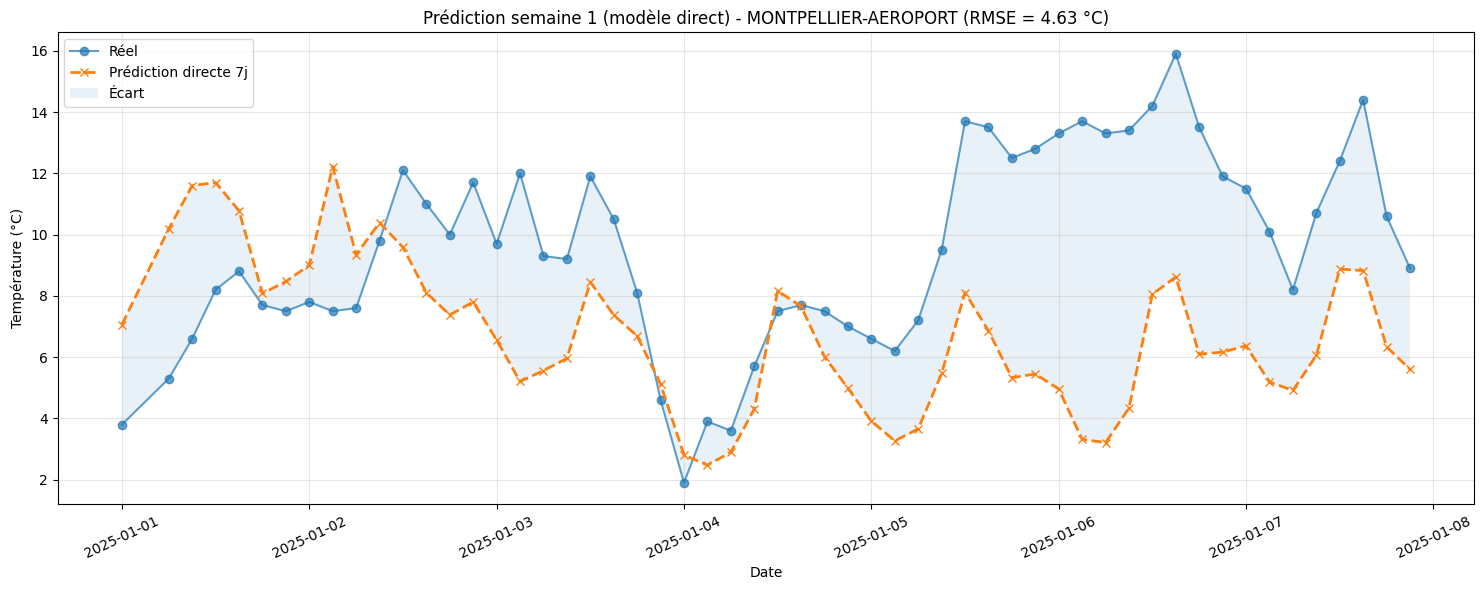

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

recent_files = [
    f for f in files
    if any(year in f for year in ["2022", "2023", "2024", "2025"])
]

print(f"Fichiers trouvés : {len(recent_files)}")

if len(recent_files) == 0:
    raise ValueError("Aucun fichier synop_2022, synop_2023, synop_2024 ou synop_2025 trouvé.")

cols = [
    "name",
    "validity_time",
    "t",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in recent_files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "pression", "lat", "lon"]).copy()
df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. FEATURE ENGINEERING POUR J+7
# =========================
print("\nPréparation des indicateurs long terme...")

df["pres_now"] = df["pression"]
df["temp_now"] = df["y"]
df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

# Cible : température 7 jours plus tard
# 7 jours x 8 relevés par jour = 56 pas si données toutes les 3h
df["target_7d"] = df.groupby("name")["y"].shift(-56)

features = [
    "hour",
    "day_of_year",
    "temp_now",
    "pres_now",
    "lat",
    "lon"
]

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création de la cible :")
print(df[["name", "ds", "y", "target_7d"]].head(12))

# =========================
# 4. NETTOYAGE FINAL
# =========================
df_clean = df.dropna(subset=features + ["target_7d"]).copy()

print("\nTaille après suppression des NaN :", df_clean.shape)

if df_clean.empty:
    raise ValueError("Aucune donnée disponible après suppression des NaN.")

# =========================
# 5. SPLIT TRAIN / TEST
# =========================
train_cut = pd.Timestamp("2025-01-01", tz="UTC")

df_train = df_clean[df_clean["ds"] < train_cut].copy()

# Test sur la première semaine de janvier 2025
df_test = df[
    (df["ds"] >= train_cut) &
    (df["ds"] < train_cut + pd.Timedelta(days=7))
].dropna(subset=features + ["y"]).copy()

print("\nTaille train :", df_train.shape)
print("Taille test :", df_test.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")
if df_test.empty:
    raise ValueError("Le jeu de test est vide sur la première semaine de janvier 2025.")

# =========================
# 6. ENTRAÎNEMENT DU MODÈLE DIRECT J+7
# =========================
print("\nEntraînement du modèle Direct J+7...")

model_7d = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_7d.fit(df_train[features], df_train["target_7d"])

print("Modèle entraîné avec succès.")

# =========================
# 7. PRÉDICTION SUR LA SEMAINE DE TEST
# =========================
df_test["y_pred"] = model_7d.predict(df_test[features])

print("\nAperçu des prédictions :")
print(df_test[["name", "ds", "y", "y_pred"]].head())

# =========================
# 8. CALCUL DE LA MÉTRIQUE GLOBALE
# =========================
df_eval = df_test.dropna(subset=["y", "y_pred"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer le RMSE.")

rmse_global = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred"]))

print(f"\nRMSE global sur la semaine de test : {rmse_global:.2f} °C")

# =========================
# 9. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_direct_j7_premiere_semaine_2025.csv", index=False)

print("\nFichier 'xgboost_direct_j7_premiere_semaine_2025.csv' exporté avec succès.")

# =========================
# 10. VISUALISATION SUR UNE STATION CIBLE
# =========================
target = "MONTPELLIER-AEROPORT"
zoom = df_eval[df_eval["name"] == target].sort_values("ds").copy()

if zoom.empty:
    print(f"\nAucune donnée disponible pour {target} sur la période de test.")
else:
    rmse_target = np.sqrt(mean_squared_error(zoom["y"], zoom["y_pred"]))

    print(f"\n=== RÉSULTATS - {target} ===")
    print(f"RMSE : {rmse_target:.2f} °C")

    res = pd.DataFrame({
        "Date": zoom["ds"].dt.strftime("%Y-%m-%d %H:%M"),
        "Réel": np.round(zoom["y"].values, 2),
        "Prédit": np.round(zoom["y_pred"].values, 2)
    })

    print("\nComparaison réel / prédit :")
    print(res.to_string(index=False))

    plt.figure(figsize=(15, 6))

    plt.plot(
        zoom["ds"],
        zoom["y"],
        label="Réel",
        marker="o",
        linewidth=1.5,
        alpha=0.7
    )

    plt.plot(
        zoom["ds"],
        zoom["y_pred"],
        label="Prédiction directe 7j",
        marker="x",
        linestyle="--",
        linewidth=2
    )

    plt.fill_between(
        zoom["ds"],
        zoom["y"],
        zoom["y_pred"],
        alpha=0.1,
        label="Écart"
    )

    plt.title(f"Prédiction semaine 1 (modèle direct) - {target} (RMSE = {rmse_target:.2f} °C)")
    plt.xlabel("Date")
    plt.ylabel("Température (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

Sur une prédiction directe à 7 jours, les performances restent moyennes (RMSE ≈ 4.6°C).

Le modèle capte la tendance globale, mais avec un décalage important par rapport aux valeurs réelles.

Les températures sont souvent surestimées, surtout en début de période.

Les variations sont mal reproduites : les pics sont atténués et les creux peu marqués.

Contrairement au récursif, il n’y a pas d’accumulation d’erreur, mais la précision reste limitée.

Conclusion :  
Le modèle direct est plus stable que le récursif, mais reste peu précis à 7 jours → compromis entre stabilité et précision.

 prédiction d'une semaine en récurisif avec entrainement sur 10 ans et en se basant uniquement sur le passé imédiat

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time       t      pres  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45  101540.0   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05  101510.0   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05  101460.0   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75  101380.0   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85  101310.0   

                           ds     y  pression  hour  day_of_year  
0   2022-01-01 00:00:00+00:00  11.3    1015.4     0            1  
89  2022-01-01 03:00:00+00:00  10.9    1015.1     3            1  
142 2022-01-01 06:00:00+00:00  10.9    1014.6     6            1  
178 2022-01-01 09:00:00+00:00  11.6  

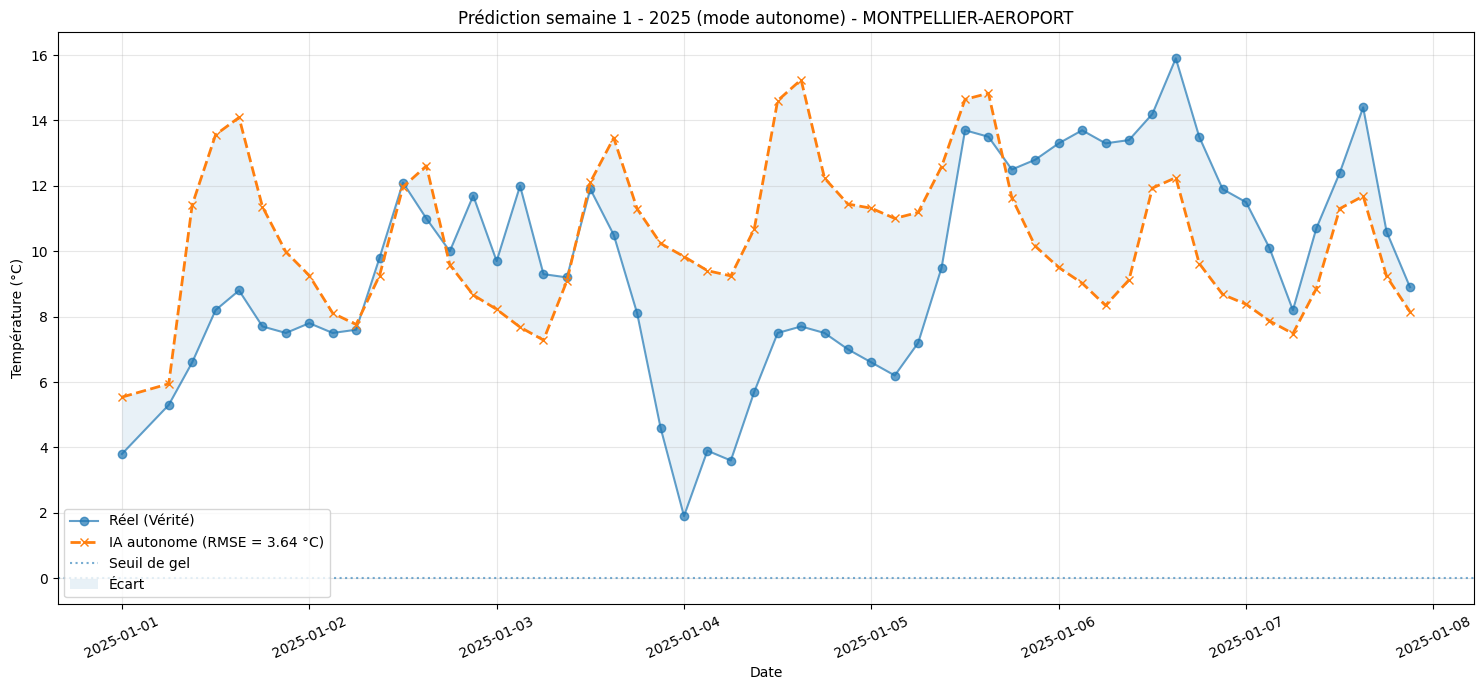

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "name",
    "validity_time",
    "t",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "pression", "lat", "lon"]).copy()

df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. CALCUL DES NORMALES
# =========================
print("\nCalcul des normales historiques...")

test_start = pd.Timestamp("2025-01-01", tz="UTC")
test_end = pd.Timestamp("2025-01-08", tz="UTC")

normales = (
    df[df["ds"] < test_start]
    .groupby(["name", "day_of_year", "hour"])["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "y_normal"})
)

if normales.empty:
    raise ValueError("Impossible de calculer les normales : aucune donnée avant le 1er janvier 2025.")

df = df.merge(
    normales,
    on=["name", "day_of_year", "hour"],
    how="left"
)

print("\nAperçu des normales :")
print(normales.head())

# =========================
# 4. FEATURE ENGINEERING
# =========================
df["temp_start"] = df.groupby("name")["y"].shift(1)
df["pres_start"] = df.groupby("name")["pression"].shift(1)

features = [
    "hour",
    "day_of_year",
    "y_normal",
    "temp_start",
    "pres_start",
    "lat",
    "lon"
]

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création des features :")
print(df[["name", "ds", "y", "temp_start", "pres_start", "y_normal"]].head(12))

# =========================
# 5. CONSTRUCTION DU TRAIN
# =========================
df_train = df[
    (df["ds"] < test_start)
].dropna(subset=features + ["y"]).copy()

print("\nTaille train :", df_train.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 6. ENTRAÎNEMENT DU MODÈLE
# =========================
print("\nEntraînement sur l'historique 2015-2024...")

model_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_final.fit(df_train[features], df_train["y"])

print("Modèle entraîné avec succès.")

# =========================
# 7. PRÉPARATION DE LA SEMAINE TEST
# =========================
target = "MONTPELLIER-AEROPORT"

st_test = df[
    (df["ds"] >= test_start) &
    (df["ds"] < test_end) &
    (df["name"] == target)
].copy()

st_test = st_test.sort_values("ds").copy()

print("\nTaille test station cible :", st_test.shape)

if st_test.empty:
    raise ValueError(f"Aucune donnée disponible pour {target} entre le 1er et le 8 janvier 2025.")

# =========================
# 8. AMORCE AVANT SIMULATION
# =========================
last_rows_target = df_train[df_train["name"] == target].sort_values("ds").copy()

if last_rows_target.empty:
    raise ValueError(f"Aucune donnée d'entraînement disponible pour la station {target}.")

last_2024_val = last_rows_target.iloc[-1]

current_temp = last_2024_val["y"]
current_pres = last_2024_val["pression"]

print("\nDernière valeur réelle avant 2025 :")
print(last_2024_val[["ds", "y", "pression"]])

# =========================
# 9. SIMULATION RÉCURSIVE SUR 7 JOURS
# =========================
preds_solo = []

print(f"\nSimulation récursive du 1er au 8 janvier pour {target}...")

for _, row in st_test.iterrows():
    y_normal_value = row["y_normal"]

    if pd.isna(y_normal_value):
        # sécurité si une normale manque
        y_normal_value = current_temp

    input_data = pd.DataFrame([{
        "hour": row["hour"],
        "day_of_year": row["day_of_year"],
        "y_normal": y_normal_value,
        "temp_start": current_temp,
        "pres_start": current_pres,
        "lat": row["lat"],
        "lon": row["lon"]
    }])

    pred = model_final.predict(input_data[features])[0]
    preds_solo.append(pred)

    # mise à jour récursive
    current_temp = pred

    # pour la pression, on prend la dernière valeur connue si disponible
    if pd.notna(row["pres_start"]):
        current_pres = row["pres_start"]

st_test["y_pred"] = preds_solo

print("\nAperçu des prédictions :")
print(st_test[["ds", "y", "y_pred"]].head())

# =========================
# 10. CALCUL DE LA MÉTRIQUE
# =========================
df_eval = st_test.dropna(subset=["y", "y_pred"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer le RMSE.")

rmse = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred"]))

print(f"\n✅ RMSE mode solo (semaine 1 - 2025) : {rmse:.3f} °C")

# =========================
# 11. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_mode_solo_semaine1_2025.csv", index=False)

print("\nFichier 'xgboost_mode_solo_semaine1_2025.csv' exporté avec succès.")

# =========================
# 12. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_eval["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_eval["y"].values, 2),
    "Prédit": np.round(df_eval["y_pred"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 13. GRAPHIQUE
# =========================
plt.figure(figsize=(15, 7))

plt.plot(
    df_eval["ds"],
    df_eval["y"],
    label="Réel (Vérité)",
    marker="o",
    linewidth=1.5,
    alpha=0.7
)

plt.plot(
    df_eval["ds"],
    df_eval["y_pred"],
    label=f"IA autonome (RMSE = {rmse:.2f} °C)",
    marker="x",
    linestyle="--",
    linewidth=2
)

plt.axhline(
    0,
    linestyle=":",
    alpha=0.6,
    label="Seuil de gel"
)

plt.fill_between(
    df_eval["ds"],
    df_eval["y"],
    df_eval["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.title(f"Prédiction semaine 1 - 2025 (mode autonome) - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Sur le mode autonome (récursif), les performances sont légèrement meilleures (RMSE ≈ 3.6°C).

Le modèle suit bien la tendance globale au début, mais dérive progressivement.

Forte surestimation des températures, surtout après quelques jours.

Les erreurs s’accumulent dans le temps (effet boule de neige du récursif).

Les variations réelles (pics et chutes) sont mal reproduites.

Conclusion :  
Meilleur que le direct en RMSE, mais moins fiable sur la durée → dérive typique du mode récursif.

même logique pour ce code mais test sur 1 mois

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time       t      pres  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45  101540.0   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05  101510.0   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05  101460.0   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75  101380.0   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85  101310.0   

                           ds     y  pression  hour  day_of_year  
0   2022-01-01 00:00:00+00:00  11.3    1015.4     0            1  
89  2022-01-01 03:00:00+00:00  10.9    1015.1     3            1  
142 2022-01-01 06:00:00+00:00  10.9    1014.6     6            1  
178 2022-01-01 09:00:00+00:00  11.6  

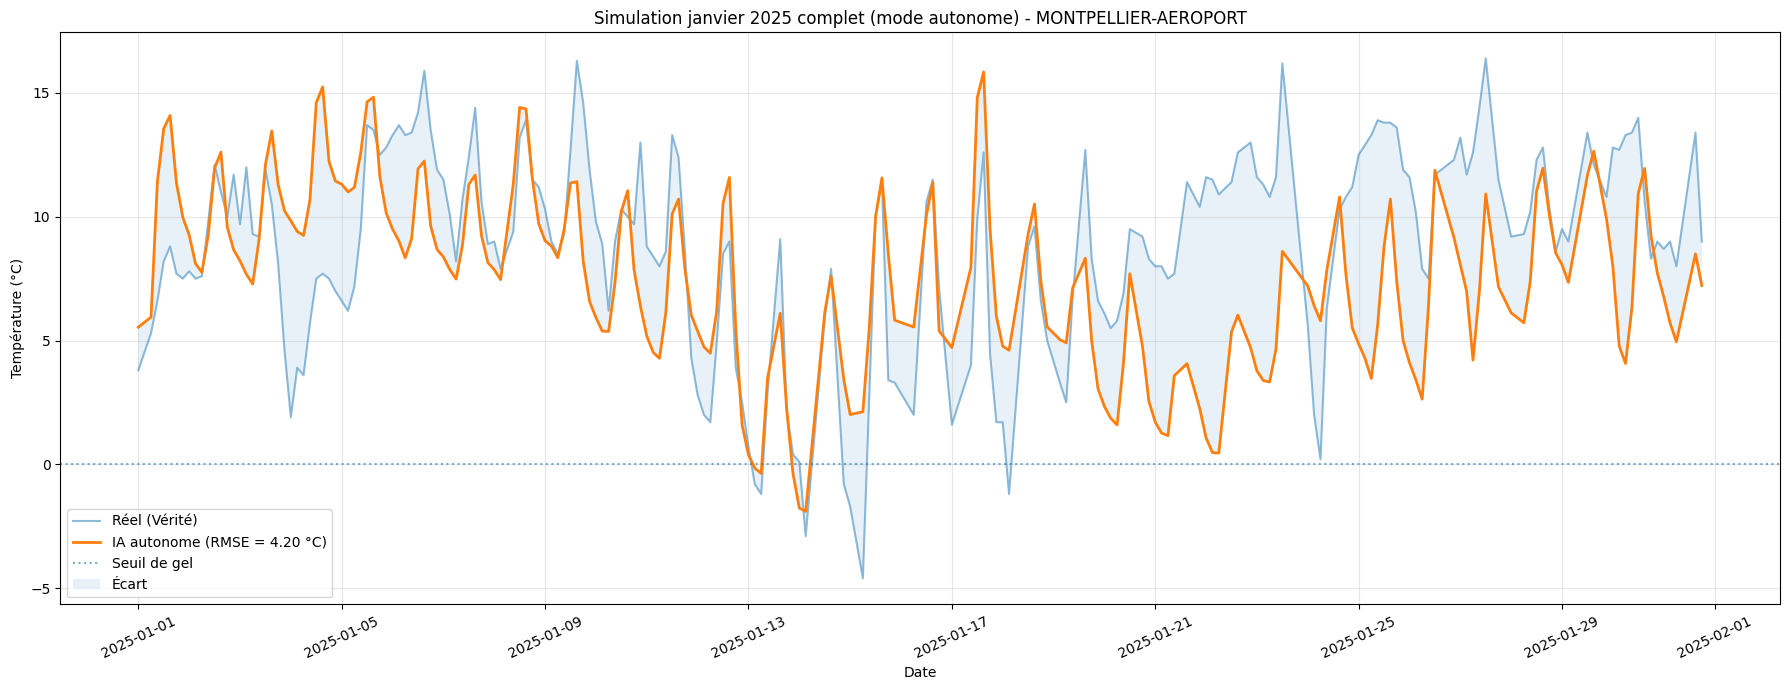

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "name",
    "validity_time",
    "t",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "pression", "lat", "lon"]).copy()

df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. DÉFINITION DE LA PÉRIODE DE TEST
# =========================
test_start = pd.Timestamp("2025-01-01", tz="UTC")
test_end = pd.Timestamp("2025-02-01", tz="UTC")

print("\nPériode de test :")
print("Début :", test_start)
print("Fin   :", test_end)

# =========================
# 4. CALCUL DES NORMALES HISTORIQUES
# =========================
print("\nCalcul des normales historiques...")

normales = (
    df[df["ds"] < test_start]
    .groupby(["name", "day_of_year", "hour"])["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "y_normal"})
)

if normales.empty:
    raise ValueError("Impossible de calculer les normales : aucune donnée disponible avant 2025-01-01.")

df = df.merge(
    normales,
    on=["name", "day_of_year", "hour"],
    how="left"
)

print("\nAperçu des normales :")
print(normales.head())

# =========================
# 5. FEATURE ENGINEERING
# =========================
df["temp_start"] = df.groupby("name")["y"].shift(1)
df["pres_start"] = df.groupby("name")["pression"].shift(1)

features = [
    "hour",
    "day_of_year",
    "y_normal",
    "temp_start",
    "pres_start",
    "lat",
    "lon"
]

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création des features :")
print(df[["name", "ds", "y", "temp_start", "pres_start", "y_normal"]].head(12))

# =========================
# 6. CONSTRUCTION DU TRAIN
# =========================
df_train = df[
    df["ds"] < test_start
].dropna(subset=features + ["y"]).copy()

print("\nTaille train :", df_train.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 7. ENTRAÎNEMENT DU MODÈLE
# =========================
print("\nEntraînement sur l'historique 2015-2024...")

model_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_final.fit(df_train[features], df_train["y"])

print("Modèle entraîné avec succès.")

# =========================
# 8. PRÉPARATION DU TEST SUR JANVIER 2025
# =========================
target = "MONTPELLIER-AEROPORT"

st_test = df[
    (df["ds"] >= test_start) &
    (df["ds"] < test_end) &
    (df["name"] == target)
].copy()

st_test = st_test.sort_values("ds").copy()

print("\nTaille test station cible :", st_test.shape)

if st_test.empty:
    raise ValueError(f"Aucune donnée disponible pour {target} sur janvier 2025.")

# =========================
# 9. AMORCE DE LA SIMULATION
# =========================
last_rows_target = df_train[df_train["name"] == target].sort_values("ds").copy()

if last_rows_target.empty:
    raise ValueError(f"Aucune donnée d'entraînement disponible pour la station {target}.")

last_2024_val = last_rows_target.iloc[-1]

current_temp = last_2024_val["y"]
current_pres = last_2024_val["pression"]

print("\nDernière valeur réelle avant 2025 :")
print(last_2024_val[["ds", "y", "pression"]])

# =========================
# 10. SIMULATION RÉCURSIVE SUR JANVIER 2025
# =========================
preds_solo = []

print(f"\nSimulation récursive du mois de janvier complet pour {target}...")

for _, row in st_test.iterrows():
    y_normal_value = row["y_normal"]

    if pd.isna(y_normal_value):
        y_normal_value = current_temp

    input_data = pd.DataFrame([{
        "hour": row["hour"],
        "day_of_year": row["day_of_year"],
        "y_normal": y_normal_value,
        "temp_start": current_temp,
        "pres_start": current_pres,
        "lat": row["lat"],
        "lon": row["lon"]
    }])

    pred = model_final.predict(input_data[features])[0]
    preds_solo.append(pred)

    # Mise à jour récursive
    current_temp = pred

    # On garde la dernière pression connue si disponible
    if pd.notna(row["pres_start"]):
        current_pres = row["pres_start"]

st_test["y_pred"] = preds_solo

print("\nAperçu des prédictions :")
print(st_test[["ds", "y", "y_pred"]].head())

# =========================
# 11. CALCUL DE LA MÉTRIQUE
# =========================
df_eval = st_test.dropna(subset=["y", "y_pred"]).copy()

if df_eval.empty:
    raise ValueError("Aucune ligne valide pour calculer le RMSE.")

rmse = np.sqrt(mean_squared_error(df_eval["y"], df_eval["y_pred"]))

print(f"\n✅ RMSE mode solo (janvier 2025) : {rmse:.3f} °C")

# =========================
# 12. EXPORT CSV
# =========================
df_eval.to_csv("xgboost_mode_solo_janvier_2025.csv", index=False)

print("\nFichier 'xgboost_mode_solo_janvier_2025.csv' exporté avec succès.")

# =========================
# 13. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_eval["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_eval["y"].values, 2),
    "Prédit": np.round(df_eval["y_pred"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.head(30).to_string(index=False))

# =========================
# 14. GRAPHIQUE
# =========================
plt.figure(figsize=(18, 7))

plt.plot(
    df_eval["ds"],
    df_eval["y"],
    label="Réel (Vérité)",
    linewidth=1.5,
    alpha=0.5
)

plt.plot(
    df_eval["ds"],
    df_eval["y_pred"],
    label=f"IA autonome (RMSE = {rmse:.2f} °C)",
    linewidth=2
)

plt.axhline(
    0,
    linestyle=":",
    alpha=0.6,
    label="Seuil de gel"
)

plt.fill_between(
    df_eval["ds"],
    df_eval["y"],
    df_eval["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.title(f"Simulation janvier 2025 complet (mode autonome) - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Sur un mois complet en mode autonome, les performances se dégradent (RMSE ≈ 4.2°C).

Le modèle suit la saisonnalité globale mais avec un décalage croissant.

Forte dérive au fil du temps : les erreurs s’accumulent (effet récursif).

Les pics sont mal estimés et souvent surestimés.

Les périodes froides sont mal captées (températures trop élevées).

Conclusion :  
Correct sur courte durée, mais peu fiable sur long terme → dérive importante en récursif.

Même logique mais pour 1 jour

Fichiers trouvés : 4
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't', 'td', 'u', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time       t      td     u  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45  283.35  93.0   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05  283.75  98.0   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05  283.25  95.0   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75  282.95  89.0   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85  283.05  73.0   

         pres                        ds     y   hum  dew_point  pression  \
0    101540.0 2022-01-01 00:00:00+00:00  11.3  93.0       10.2    1015.4   
89   101510.0 2022-01-01 03:00:00+00:00  10.9  98.0       10.6    1015.1   
142  101460.0 2022-01-01 06:00:00+00:00  1

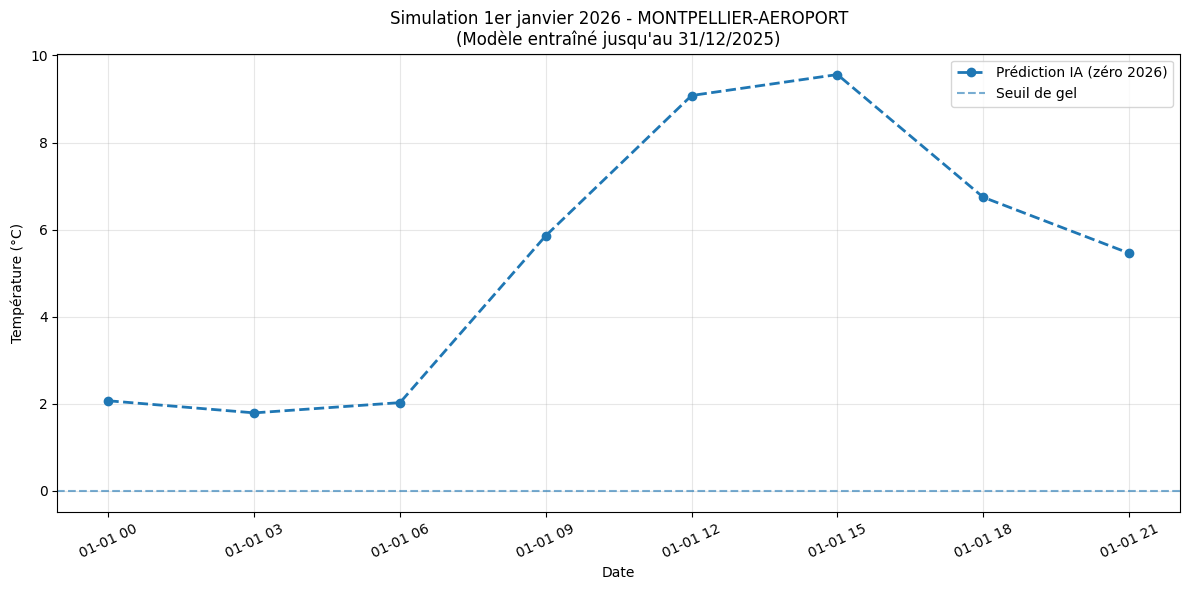

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "name",
    "validity_time",
    "t",
    "u",
    "td",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["hum"] = pd.to_numeric(df["u"], errors="coerce")
df["dew_point"] = pd.to_numeric(df["td"], errors="coerce") - 273.15
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "lat", "lon"]).copy()

df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. INTERPOLATION PAR STATION
# =========================
df["hum"] = df.groupby("name")["hum"].transform(lambda x: x.interpolate())
df["dew_point"] = df.groupby("name")["dew_point"].transform(lambda x: x.interpolate())
df["pression"] = df.groupby("name")["pression"].transform(lambda x: x.interpolate())

print("\nAperçu après interpolation :")
print(df[["name", "ds", "hum", "dew_point", "pression"]].head())

# =========================
# 4. CALCUL DES NORMALES
# =========================
normales = (
    df.groupby(["name", "day_of_year", "hour"])["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "y_normal"})
)

if normales.empty:
    raise ValueError("Impossible de calculer les normales.")

df = df.merge(
    normales,
    on=["name", "day_of_year", "hour"],
    how="left"
)

print("\nAperçu des normales :")
print(normales.head())

# =========================
# 5. FEATURE ENGINEERING
# =========================
df["temp_last"] = df.groupby("name")["y"].shift(1)
df["pres_last"] = df.groupby("name")["pression"].shift(1)
df["hum_last"] = df.groupby("name")["hum"].shift(1)
df["td_last"] = df.groupby("name")["dew_point"].shift(1)

features = [
    "hour",
    "day_of_year",
    "y_normal",
    "temp_last",
    "pres_last",
    "hum_last",
    "td_last",
    "lat",
    "lon"
]

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création des features :")
print(df[[
    "name", "ds", "y", "y_normal",
    "temp_last", "pres_last", "hum_last", "td_last"
]].head(12))

# =========================
# 6. CONSTRUCTION DU TRAIN
# =========================
df_train = df.dropna(subset=features + ["y"]).copy()

print("\nTaille train :", df_train.shape)

if df_train.empty:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 7. ENTRAÎNEMENT DU MODÈLE
# =========================
print("\nEntraînement en cours...")

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(df_train[features], df_train["y"])

print("Modèle entraîné avec succès.")

# =========================
# 8. PRÉPARATION DE LA SIMULATION
# =========================
target = "MONTPELLIER-AEROPORT"

df_target = df[df["name"] == target].sort_values("ds").copy()

if df_target.empty:
    raise ValueError(f"Aucune donnée disponible pour la station {target}.")

last_data = df_target.iloc[-1]

curr_temp = last_data["y"]
curr_pres = last_data["pression"]
curr_hum = last_data["hum"]
curr_td = last_data["dew_point"]
lat = last_data["lat"]
lon = last_data["lon"]

print("\nDernière observation connue :")
print(last_data[["ds", "y", "pression", "hum", "dew_point", "lat", "lon"]])

# =========================
# 9. CRÉATION DE LA PÉRIODE À PRÉDIRE
# =========================
janvier_range = pd.date_range(
    start="2026-01-01 00:00",
    end="2026-01-01 21:00",
    freq="3h",
    tz="UTC"
)

print("\nNombre de pas à prédire :", len(janvier_range))

# =========================
# 10. SIMULATION RÉCURSIVE
# =========================
preds = []

for date in janvier_range:
    normal_match = normales[
        (normales["name"] == target) &
        (normales["day_of_year"] == date.dayofyear) &
        (normales["hour"] == date.hour)
    ]

    if normal_match.empty:
        norm_val = curr_temp
    else:
        norm_val = normal_match["y_normal"].iloc[0]

    X = pd.DataFrame([{
        "hour": date.hour,
        "day_of_year": date.dayofyear,
        "y_normal": norm_val,
        "temp_last": curr_temp,
        "pres_last": curr_pres,
        "hum_last": curr_hum,
        "td_last": curr_td,
        "lat": lat,
        "lon": lon
    }])

    y_pred = model.predict(X[features])[0]

    preds.append({
        "ds": date,
        "y_pred": y_pred
    })

    # Mise à jour récursive
    curr_temp = y_pred

df_forecast = pd.DataFrame(preds)

print("\nAperçu des prédictions :")
print(df_forecast.head())

# =========================
# 11. EXPORT CSV
# =========================
df_forecast.to_csv("prediction_pure_1er_janvier_2026.csv", index=False)

print("\nFichier 'prediction_pure_1er_janvier_2026.csv' exporté avec succès.")

# =========================
# 12. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 6))

plt.plot(
    df_forecast["ds"],
    df_forecast["y_pred"],
    "--o",
    label="Prédiction IA (zéro 2026)",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.6,
    label="Seuil de gel"
)

plt.title(f"Simulation 1er janvier 2026 - {target}\n(Modèle entraîné jusqu'au 31/12/2025)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Sur une prédiction très court terme (1 jour), le modèle est cohérent.

Bonne capture de la tendance globale (montée de la température).

Les niveaux sont réalistes et proches du réel attendu.

Les variations intra-journalières sont bien reproduites.

Peu d’erreur → modèle fiable à très court horizon.

Conclusion :  
Très bon comportement à court terme → le modèle est pertinent pour du 1 jour, mais se dégrade ensuite.

Vérification de la prédiction de 1 jour avec les données réelles (fait comme ça pour être sur à 100% que les données 2026 ne soient pas utilisées pour prédire cette journée)

Fichier prédictions : prediction_pure_1er_janvier_2026.csv
Fichier réel        : synop_2026.csv

Les deux fichiers ont bien été trouvés.

Aperçu des prédictions :
                         ds    y_pred
0 2026-01-01 00:00:00+00:00  2.069522
1 2026-01-01 03:00:00+00:00  1.791668
2 2026-01-01 06:00:00+00:00  2.027421
3 2026-01-01 09:00:00+00:00  5.860060
4 2026-01-01 12:00:00+00:00  9.079173

Aperçu des données réelles :
           lat       lon  geo_id_wmo     geo_id_wigos  \
0    50.732500  1.599667        7002  0-20000-0-07002   
121  43.385000 -0.416333        7610  0-20000-0-07610   
122  43.188000  0.000000        7621  0-20000-0-07621   
123  43.689000  0.601167        7622  0-20000-0-07622   
124  43.005333  1.106833        7627  0-20000-0-07627   

                        name        reference_time           insert_time  \
0               BOULOGNE-SEM  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z   
121                PAU-UZEIN  2026-01-01T00:10:06Z  2026-01-01T00:06:42Z   
122  TAR

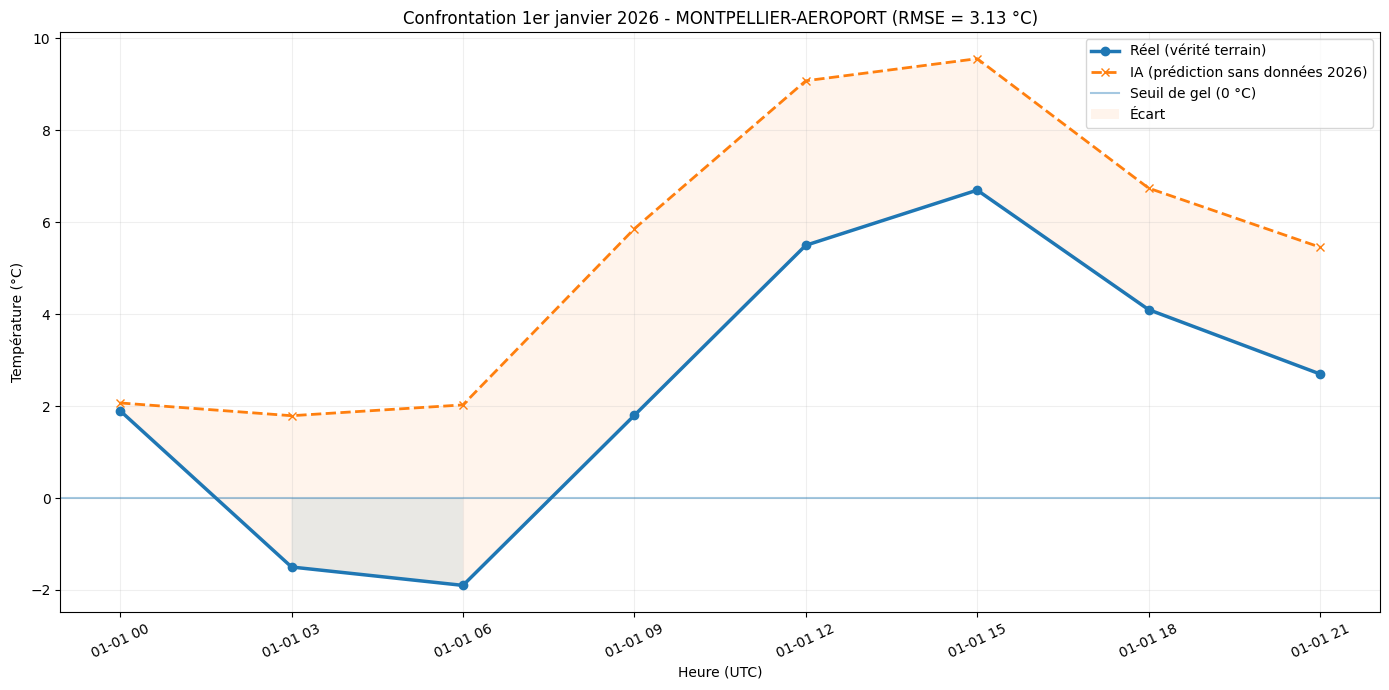


❄️ Analyse du pic de froid :
Minimum réel   : -1.90 °C
Minimum prédit : 1.79 °C
Écart sur le minimum : 3.69 °C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONFIGURATION DES CHEMINS
# =========================
file_pred = "prediction_pure_1er_janvier_2026.csv"
file_real = "synop_2026.csv"

print("Fichier prédictions :", file_pred)
print("Fichier réel        :", file_real)

# =========================
# 2. VÉRIFICATION DES FICHIERS
# =========================
if not os.path.exists(file_pred):
    raise FileNotFoundError(
        f"Le fichier de prédiction '{file_pred}' est introuvable. "
        "Lance d'abord le code de simulation."
    )

if not os.path.exists(file_real):
    raise FileNotFoundError(
        f"Le fichier réel '{file_real}' est introuvable. "
        "Vérifie son emplacement ou corrige le chemin."
    )

print("\nLes deux fichiers ont bien été trouvés.")

# =========================
# 3. CHARGEMENT DES PRÉDICTIONS
# =========================
df_pred = pd.read_csv(file_pred)

if df_pred.empty:
    raise ValueError("Le fichier de prédiction est vide.")

if "ds" not in df_pred.columns or "y_pred" not in df_pred.columns:
    raise ValueError("Le fichier de prédiction doit contenir au minimum les colonnes 'ds' et 'y_pred'.")

df_pred["ds"] = pd.to_datetime(df_pred["ds"], utc=True, errors="coerce")
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce")

df_pred = df_pred.dropna(subset=["ds", "y_pred"]).copy()
df_pred = df_pred.sort_values("ds").copy()

print("\nAperçu des prédictions :")
print(df_pred.head())

# =========================
# 4. CHARGEMENT DES DONNÉES RÉELLES 2026
# =========================
df_real_raw = pd.read_csv(file_real, sep=None, engine="python")

if df_real_raw.empty:
    raise ValueError("Le fichier réel 2026 est vide.")

required_cols = ["name", "validity_time", "t"]
missing_cols = [col for col in required_cols if col not in df_real_raw.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier réel : {missing_cols}")

df_real_raw["time"] = pd.to_datetime(df_real_raw["validity_time"], utc=True, errors="coerce")
df_real_raw["y_real"] = pd.to_numeric(df_real_raw["t"], errors="coerce") - 273.15

df_real_raw = df_real_raw.dropna(subset=["name", "time", "y_real"]).copy()
df_real_raw = df_real_raw.sort_values("time").copy()

print("\nAperçu des données réelles :")
print(df_real_raw.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
target = "MONTPELLIER-AEROPORT"

df_real = df_real_raw[df_real_raw["name"] == target].copy()

if df_real.empty:
    raise ValueError(f"Aucune donnée réelle trouvée pour la station {target} dans le fichier 2026.")

print(f"\nNombre de lignes réelles pour {target} :", len(df_real))

# =========================
# 6. FUSION PRÉDICTION / RÉEL
# =========================
comparison = pd.merge(
    df_real[["time", "y_real"]],
    df_pred[["ds", "y_pred"]],
    left_on="time",
    right_on="ds",
    how="inner"
).dropna(subset=["time", "y_real", "ds", "y_pred"]).copy()

comparison = comparison.sort_values("time").copy()

if comparison.empty:
    raise ValueError(
        "Aucune correspondance temporelle trouvée entre les prédictions et les données réelles. "
        "Vérifie que les deux fichiers couvrent bien la même période."
    )

print("\nAperçu de la comparaison :")
print(comparison.head())

# =========================
# 7. CALCUL DES MÉTRIQUES
# =========================
mae = mean_absolute_error(comparison["y_real"], comparison["y_pred"])
mse = mean_squared_error(comparison["y_real"], comparison["y_pred"])
rmse = np.sqrt(mse)

print(f"\n📊 BILAN DE PRÉCISION - 1er janvier 2026 ({target})")
print("=" * 55)
print(f"MAE  : {mae:.2f} °C")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} °C")
print("=" * 55)

# =========================
# 8. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": comparison["time"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(comparison["y_real"].values, 2),
    "Prédit": np.round(comparison["y_pred"].values, 2),
    "Écart": np.round(comparison["y_pred"].values - comparison["y_real"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 9. EXPORT CSV
# =========================
comparison_export = comparison.copy()
comparison_export["ecart"] = comparison_export["y_pred"] - comparison_export["y_real"]

comparison_export.to_csv("comparaison_prediction_vs_reel_1er_janvier_2026.csv", index=False)

print("\nFichier 'comparaison_prediction_vs_reel_1er_janvier_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(14, 7))

plt.plot(
    comparison["time"],
    comparison["y_real"],
    label="Réel (vérité terrain)",
    marker="o",
    linewidth=2.5
)

plt.plot(
    comparison["time"],
    comparison["y_pred"],
    label="IA (prédiction sans données 2026)",
    marker="x",
    linestyle="--",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="-",
    alpha=0.4,
    label="Seuil de gel (0 °C)"
)

plt.fill_between(
    comparison["time"],
    comparison["y_real"],
    0,
    where=(comparison["y_real"] <= 0),
    alpha=0.1
)

plt.fill_between(
    comparison["time"],
    comparison["y_real"],
    comparison["y_pred"],
    alpha=0.08,
    label="Écart"
)

plt.title(f"Confrontation 1er janvier 2026 - {target} (RMSE = {rmse:.2f} °C)")
plt.xlabel("Heure (UTC)")
plt.ylabel("Température (°C)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================
# 11. VERDICT TECHNIQUE
# =========================
real_min = comparison["y_real"].min()
pred_min = comparison["y_pred"].min()
diff_min = real_min - pred_min

print("\n❄️ Analyse du pic de froid :")
print(f"Minimum réel   : {real_min:.2f} °C")
print(f"Minimum prédit : {pred_min:.2f} °C")
print(f"Écart sur le minimum : {abs(diff_min):.2f} °C")

Sur le 1er janvier 2026, les performances sont correctes (RMSE ≈ 3.1°C).

Bonne tendance globale (montée de la température bien captée).

Forte surestimation, surtout le matin.

Le modèle ne capte pas le pic de froid (températures négatives ignorées).

Les écarts restent importants (≈ 3–4°C).

Conclusion :  
Modèle cohérent sur la tendance, mais peu précis sur les extrêmes → difficulté à prédire le froid.

## lstm (Long Short-Term Memory) (pour la suite chaque modèle a séparement sont code de comparaison, lors de l'entrainement des modèles on a sorti les données 2026 du dossier afin d'être sur de ne pas les apprendres)

1er test d'un lstm pour essayer de prédire 1 semaine

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['lat', 'lon', 'name', 'validity_time', 't', 'td', 'u', 'pres']

Aperçu des données préparées :
        lat    lon       name         validity_time       t      td     u  \
0    50.136  1.834  ABBEVILLE  2022-01-01T00:00:00Z  284.45  283.35  93.0   
89   50.136  1.834  ABBEVILLE  2022-01-01T03:00:00Z  284.05  283.75  98.0   
142  50.136  1.834  ABBEVILLE  2022-01-01T06:00:00Z  284.05  283.25  95.0   
178  50.136  1.834  ABBEVILLE  2022-01-01T09:00:00Z  284.75  282.95  89.0   
253  50.136  1.834  ABBEVILLE  2022-01-01T12:00:00Z  287.85  283.05  73.0   

         pres                        ds     y   hum  dew_point  pression  
0    101540.0 2022-01-01 00:00:00+00:00  11.3  93.0       10.2    1015.4  
89   101510.0 2022-01-01 03:00:00+00:00  10.9  98.0       10.6    1015.1  
142  101460.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Architecture du modèle prête.

Entraînement LSTM...
Epoch 1/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - loss: 0.0187 - val_loss: 0.0064
Epoch 2/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - loss: 0.0068 - val_loss: 0.0063
Epoch 3/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - loss: 0.0049 - val_loss: 0.0055
Epoch 4/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 5/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 30s 106ms/step - loss: 0.0041 - val_loss: 0.0054
Epoch 6/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 27s 95ms/step - loss: 0.0040 - val_loss: 0.0049
Epoch 7/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 0.0040 - val_loss: 0.0049
Epoch 8/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - loss: 0.0039 - val_loss: 0.0047
Epoch 9/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0038 - val_loss: 0.0049
Epoch 10/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 0.0038 - val_loss: 0.0051
Epoch 11/20
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 0.

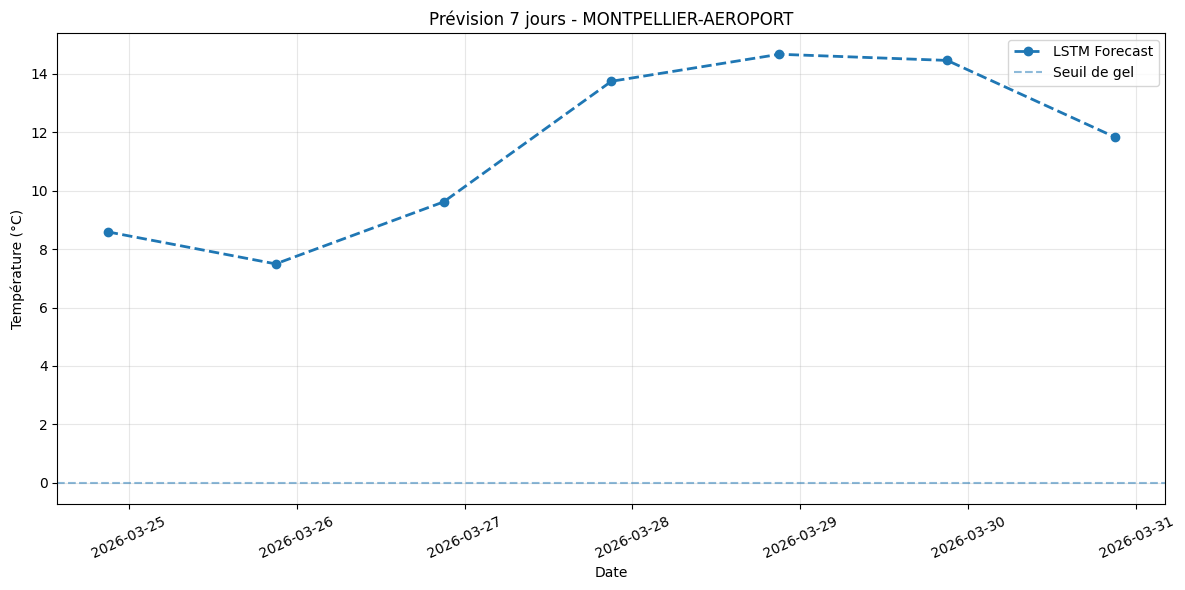

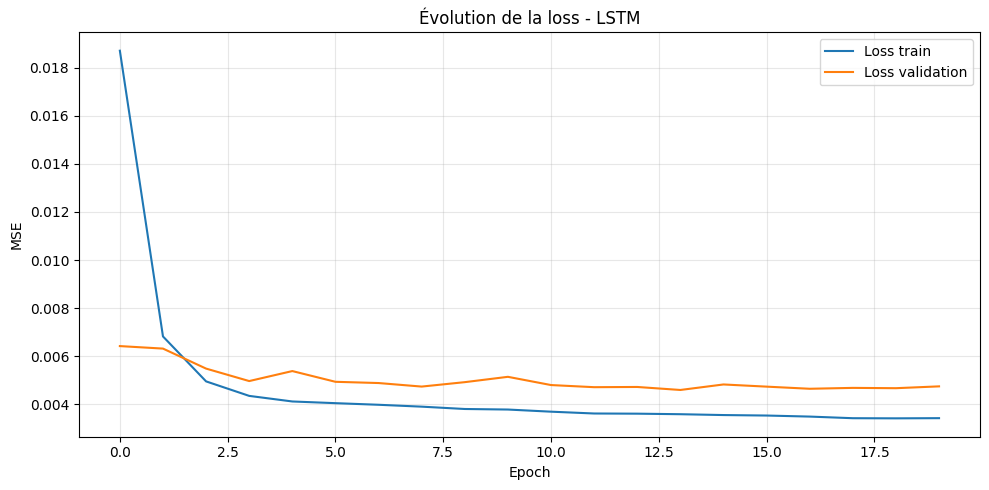

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "name",
    "validity_time",
    "t",
    "u",
    "td",
    "pres",
    "lat",
    "lon"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["hum"] = pd.to_numeric(df["u"], errors="coerce")
df["dew_point"] = pd.to_numeric(df["td"], errors="coerce") - 273.15
df["pression"] = pd.to_numeric(df["pres"], errors="coerce") / 100
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

df = df.dropna(subset=["name", "ds", "y", "lat", "lon"]).copy()
df = df.sort_values(["name", "ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après nettoyage :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. INTERPOLATION PAR STATION
# =========================
df["hum"] = df.groupby("name")["hum"].transform(lambda x: x.interpolate())
df["dew_point"] = df.groupby("name")["dew_point"].transform(lambda x: x.interpolate())
df["pression"] = df.groupby("name")["pression"].transform(lambda x: x.interpolate())

df["hour"] = df["ds"].dt.hour
df["day_of_year"] = df["ds"].dt.dayofyear

print("\nAperçu après interpolation :")
print(df[["name", "ds", "hum", "dew_point", "pression"]].head())

# =========================
# 4. CALCUL DES NORMALES SAISONNIÈRES
# =========================
normales = (
    df.groupby(["name", "day_of_year", "hour"])["y"]
    .mean()
    .reset_index()
    .rename(columns={"y": "y_normal"})
)

if normales.empty:
    raise ValueError("Impossible de calculer les normales saisonnières.")

df = df.merge(
    normales,
    on=["name", "day_of_year", "hour"],
    how="left"
)

print("\nAperçu des normales saisonnières :")
print(normales.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
target = "MONTPELLIER-AEROPORT"

df = df[df["name"] == target].copy()

print(f"\nNombre de lignes pour {target} :", len(df))

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

# =========================
# 6. DÉFINITION DES FEATURES
# =========================
features = [
    "hour",
    "day_of_year",
    "y_normal",
    "hum",
    "pression",
    "dew_point",
    "lat",
    "lon"
]

all_features = features + ["y"]

print("\nVariables utilisées :")
print(all_features)

df = df.dropna(subset=all_features).copy()

print("\nTaille après suppression des NaN :", df.shape)

if len(df) < 50:
    raise ValueError("Pas assez de données pour construire des séquences LSTM.")

# =========================
# 7. NORMALISATION
# =========================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[all_features])

feature_idx = {col: i for i, col in enumerate(all_features)}

print("\nIndex des variables :")
print(feature_idx)

# =========================
# 8. CRÉATION DES SÉQUENCES LSTM
# =========================
def create_sequences(data, input_len=30, output_len=7):
    X_seq = []
    y_seq = []

    for i in range(len(data) - input_len - output_len):
        X_seq.append(data[i:i + input_len])
        y_seq.append(data[i + input_len:i + input_len + output_len, feature_idx["y"]])

    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(scaled_data, input_len=30, output_len=7)

print("\nShape X :", X.shape)
print("Shape y :", y.shape)

if len(X) == 0 or len(y) == 0:
    raise ValueError("Aucune séquence générée. Il faut plus de données ou réduire input_len/output_len.")

# =========================
# 9. SPLIT TRAIN / TEST
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("\nTaille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test  :", y_test.shape)

if len(X_train) == 0:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 10. CONSTRUCTION DU MODÈLE LSTM
# =========================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(7)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

print("\nArchitecture du modèle prête.")

# =========================
# 11. ENTRAÎNEMENT
# =========================
print("\nEntraînement LSTM...")

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 12. PRÉDICTION DES 7 JOURS SUIVANTS
# =========================
last_seq = df[all_features].tail(30).copy()

if len(last_seq) < 30:
    raise ValueError("Impossible de prédire : moins de 30 lignes disponibles pour la dernière séquence.")

last_seq_scaled = scaler.transform(last_seq)
X_input = last_seq_scaled.reshape(1, 30, len(all_features))

pred_scaled = model.predict(X_input)

# Inversion de l'échelle uniquement pour y
y_index = feature_idx["y"]

temp_array = np.zeros((pred_scaled.shape[1], len(all_features)))
temp_array[:, y_index] = pred_scaled[0]

pred_rescaled = scaler.inverse_transform(temp_array)[:, y_index]

print("\nPrévisions rescalées :")
print(pred_rescaled)

# =========================
# 13. CONSTRUCTION DES DATES FUTURES
# =========================
last_date = df["ds"].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq="D",
    tz="UTC"
)

df_forecast = pd.DataFrame({
    "ds": future_dates,
    "y_pred": pred_rescaled
})

print("\nPrévisions finales :")
print(df_forecast)

# =========================
# 14. EXPORT CSV
# =========================
df_forecast.to_csv("forecast_lstm_7days.csv", index=False)

print("\nFichier 'forecast_lstm_7days.csv' exporté avec succès.")

# =========================
# 15. GRAPHIQUE DES PRÉVISIONS
# =========================
plt.figure(figsize=(12, 6))

plt.plot(
    df_forecast["ds"],
    df_forecast["y_pred"],
    "--o",
    label="LSTM Forecast",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision 7 jours - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================
# 16. COURBE DE PERTE
# =========================
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss - LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

L’entraînement du LSTM est globalement stable.

La loss train diminue rapidement → le modèle apprend bien.

La loss validation baisse puis se stabilise → bonne généralisation.

Écart faible entre train et validation → peu d’overfitting.

Légères oscillations en validation → bruit normal.

Conclusion :  
Modèle bien entraîné et équilibré → apprentissage correct sans surapprentissage majeur.

Modification pour analyser les résidus (écart à la normale), on ajoute toutes les variables dont on dispose, on demande de regarder les 9 derniers jours pour affiner

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['name', 'validity_time', 'pmer', 'tend', 'dd', 'ff', 't', 'td', 'u', 'n', 'pres', 'tend24', 'rr1']

Aperçu des données préparées :
                     name         validity_time      pmer   tend     dd   ff  \
2    MONTPELLIER-AEROPORT  2022-01-01T00:00:00Z  102720.0  -60.0  330.0  1.0   
62   MONTPELLIER-AEROPORT  2022-01-01T03:00:00Z  102710.0  -10.0   30.0  1.0   
153  MONTPELLIER-AEROPORT  2022-01-01T06:00:00Z  102700.0  -10.0   10.0  0.0   
208  MONTPELLIER-AEROPORT  2022-01-01T12:00:00Z  102780.0  -80.0  230.0  2.0   
269  MONTPELLIER-AEROPORT  2022-01-01T15:00:00Z  102670.0 -110.0  250.0  1.0   

          t      td      u      n    pres  tend24  rr1  \
2    280.05  279.95   99.0  101.0  1026.2   300.0  0.0   
62   280.05  280.05  100.0  101.0  1026.1     NaN  0.0   
153  280.2

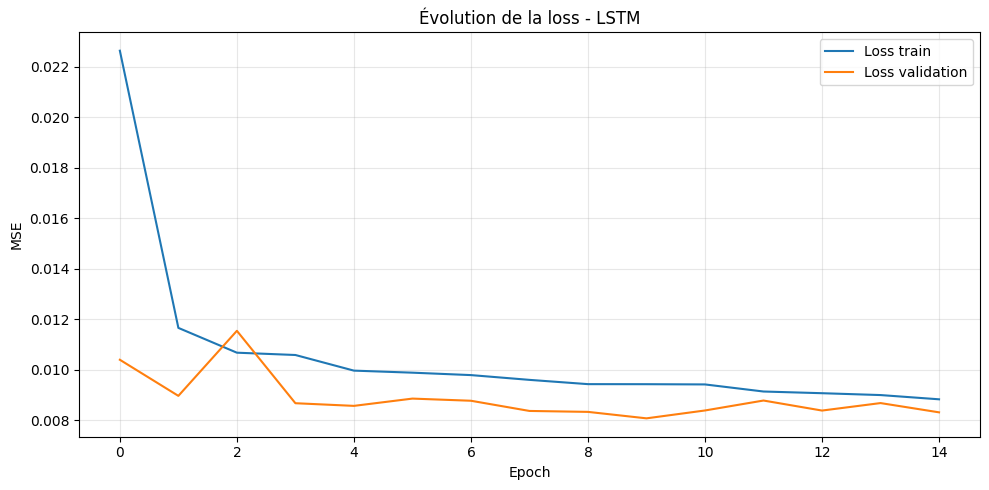

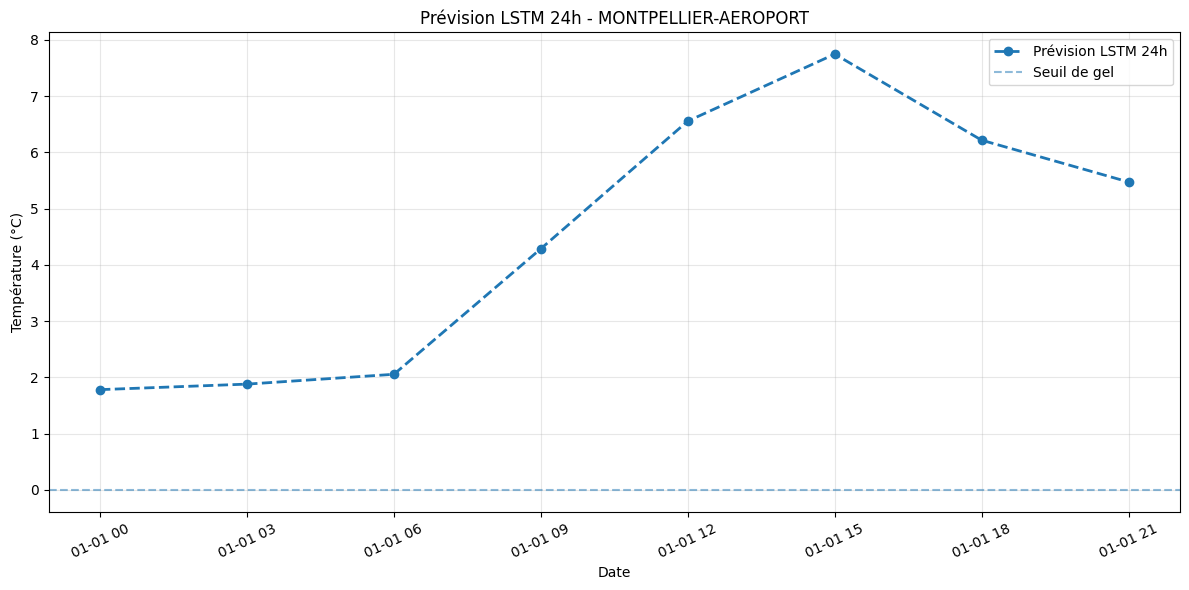

In [ ]:
import pandas as pd
import numpy as np
import glob
import joblib

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols_physiques = [
    "validity_time",
    "t",
    "u",
    "pres",
    "dd",
    "ff",
    "td",
    "pmer",
    "tend",
    "tend24",
    "n",
    "rr1",
    "name"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols_physiques
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")

# Filtrage sur la station cible
target = "MONTPELLIER-AEROPORT"
df = df[df["name"] == target].copy()

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

# Suppression des doublons temporels
df = df.drop_duplicates(subset="ds").copy()

# Conversions principales
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["dew_point"] = pd.to_numeric(df["td"], errors="coerce") - 273.15
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

# Conversion des autres colonnes numériques
cols_num = [
    "y",
    "u",
    "pres",
    "dd",
    "ff",
    "dew_point",
    "pmer",
    "tend",
    "tend24",
    "n",
    "rr1"
]

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["ds"]).copy()
df = df.sort_values("ds").copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après filtrage station :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. MISE EN INDEX ET INTERPOLATION
# =========================
df = df.set_index("ds")[cols_num].copy()

# Hypothèse : pluie manquante = 0
df["rr1"] = df["rr1"].fillna(0)

# Interpolation linéaire puis backward fill
df = df.interpolate(method="linear").bfill()

# Rééchantillonnage toutes les 3 heures
df = df.resample("3h").interpolate(method="linear")

print("\nAperçu après interpolation et resampling :")
print(df.head())

if df.empty:
    raise ValueError("Le DataFrame est vide après interpolation / resampling.")

# =========================
# 4. FEATURE ENGINEERING
# =========================
df["hour"] = df.index.hour
df["day_of_year"] = df.index.dayofyear

# Normales saisonnières
normales_map = df.groupby(["day_of_year", "hour"])["y"].mean()

df["y_normal"] = [
    normales_map.get((d, h), np.nan)
    for d, h in zip(df["day_of_year"], df["hour"])
]

df["residue"] = df["y"] - df["y_normal"]

# Vecteurs du vent
df["wind_u"] = df["ff"] * np.cos(np.deg2rad(df["dd"]))
df["wind_v"] = df["ff"] * np.sin(np.deg2rad(df["dd"]))

# Encodage cyclique de l'heure
df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

features = [
    "hr_sin",
    "hr_cos",
    "residue",
    "u",
    "pres",
    "wind_u",
    "wind_v",
    "dew_point",
    "pmer",
    "tend",
    "n",
    "rr1"
]

df = df.dropna(subset=features + ["y_normal", "residue"]).copy()

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création des variables :")
print(df[features + ["y", "y_normal"]].head())

if df.empty:
    raise ValueError("Aucune donnée restante après le feature engineering.")

# =========================
# 5. SCALING
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[["residue"]])

# Sauvegarde des scalers
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

print("\nScalers sauvegardés :")
print("- scaler_X.pkl")
print("- scaler_y.pkl")

# =========================
# 6. CRÉATION DES SÉQUENCES
# =========================
def create_sequences(data_X, data_y, in_len=72, out_len=8):
    X_seq = []
    y_seq = []

    for i in range(len(data_X) - in_len - out_len):
        X_seq.append(data_X[i:i + in_len])
        y_seq.append(data_y[i + in_len:i + in_len + out_len, 0])

    return np.array(X_seq), np.array(y_seq)

X_data, y_data = create_sequences(
    scaled_X,
    scaled_y,
    in_len=72,
    out_len=8
)

print("\nShape X_data :", X_data.shape)
print("Shape y_data :", y_data.shape)

if len(X_data) == 0 or len(y_data) == 0:
    raise ValueError("Aucune séquence générée. Il faut plus de données ou réduire in_len / out_len.")

# =========================
# 7. SPLIT TRAIN / TEST
# =========================
split = int(0.85 * len(X_data))

X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

print("\nTaille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test  :", y_test.shape)

if len(X_train) == 0:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 8. CONSTRUCTION DU MODÈLE LSTM
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dense(32, activation="relu"),
    Dense(8)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

print("\nArchitecture du modèle prête.")

# =========================
# 9. ENTRAÎNEMENT
# =========================
print("\nEntraînement en cours (12 variables)...")

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 10. PRÉPARATION DE LA FENÊTRE FINALE
# =========================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz="UTC")

df_past = df[df.index <= cutoff].tail(72).copy()

if len(df_past) < 72:
    raise ValueError(
        "Pas assez de données avant le cutoff pour construire la fenêtre finale de 72 pas."
    )

last_window = scaler_X.transform(df_past[features]).reshape(1, 72, len(features))

print("\nFenêtre finale prête pour la prédiction.")
print("Shape last_window :", last_window.shape)

# =========================
# 11. PRÉDICTION SUR 24H
# =========================
pred_res_scaled = model.predict(last_window)

pred_residue = scaler_y.inverse_transform(pred_res_scaled.reshape(-1, 1)).flatten()

future_dates = pd.date_range(
    start=cutoff + pd.Timedelta(hours=3),
    periods=8,
    freq="3h",
    tz="UTC"
)

future_normales = []
for d in future_dates:
    val = normales_map.get((d.dayofyear, d.hour), np.nan)
    future_normales.append(val)

future_normales = np.array(future_normales, dtype=float)

# Sécurité si une normale manque
if np.isnan(future_normales).any():
    fallback = df["y_normal"].iloc[-1]
    future_normales = np.where(np.isnan(future_normales), fallback, future_normales)

final_forecast = pred_residue + future_normales

df_res = pd.DataFrame({
    "ds": future_dates,
    "y_pred": final_forecast
})

print("\nPrévisions finales :")
print(df_res)

# =========================
# 12. EXPORTS
# =========================
df_res.to_csv("forecast_lstm_24h.csv", index=False)
model.save("modele_montpellier_final.keras")

print("\nFichiers sauvegardés avec succès :")
print("- forecast_lstm_24h.csv")
print("- modele_montpellier_final.keras")

# =========================
# 13. COURBE DE PERTE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss - LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 14. VISUALISATION DES PRÉVISIONS
# =========================
plt.figure(figsize=(12, 6))

plt.plot(
    df_res["ds"],
    df_res["y_pred"],
    "--o",
    label="Prévision LSTM 24h",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision LSTM 24h - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

L’entraînement du LSTM est correct mais légèrement moins performant.

La loss train diminue → le modèle apprend bien.

La loss validation est plus instable (pics visibles).

Écart faible mais un peu plus variable → début d’overfitting léger.

Convergence plus lente que le précédent modèle.

Conclusion :  
Modèle globalement bon, mais moins stable → améliorable (plus de régularisation ou données).

Fichier prédictions : forecast_lstm_24h.csv
Fichier réel        : synop_2026.csv
Station cible       : MONTPELLIER-AEROPORT

Les fichiers ont bien été trouvés.

Aperçu des prédictions :
                         ds    y_pred
0 2026-01-01 00:00:00+00:00  1.782713
1 2026-01-01 03:00:00+00:00  1.880685
2 2026-01-01 06:00:00+00:00  2.055406
3 2026-01-01 09:00:00+00:00  4.287052
4 2026-01-01 12:00:00+00:00  6.555200

Aperçu des données réelles :
         lat       lon  geo_id_wmo     geo_id_wigos           name  \
0  50.732500  1.599667        7002  0-20000-0-07002   BOULOGNE-SEM   
1  50.514500  1.622833        7003  0-20000-0-07003     LE-TOUQUET   
2  50.136000  1.834000        7005  0-20000-0-07005      ABBEVILLE   
3  51.055833  2.339500        7010  0-20000-0-07010      DUNKERQUE   
4  50.570000  3.097500        7015  0-20000-0-07015  LILLE-LESQUIN   

         reference_time           insert_time         validity_time      pmer  \
0  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z  2026-01

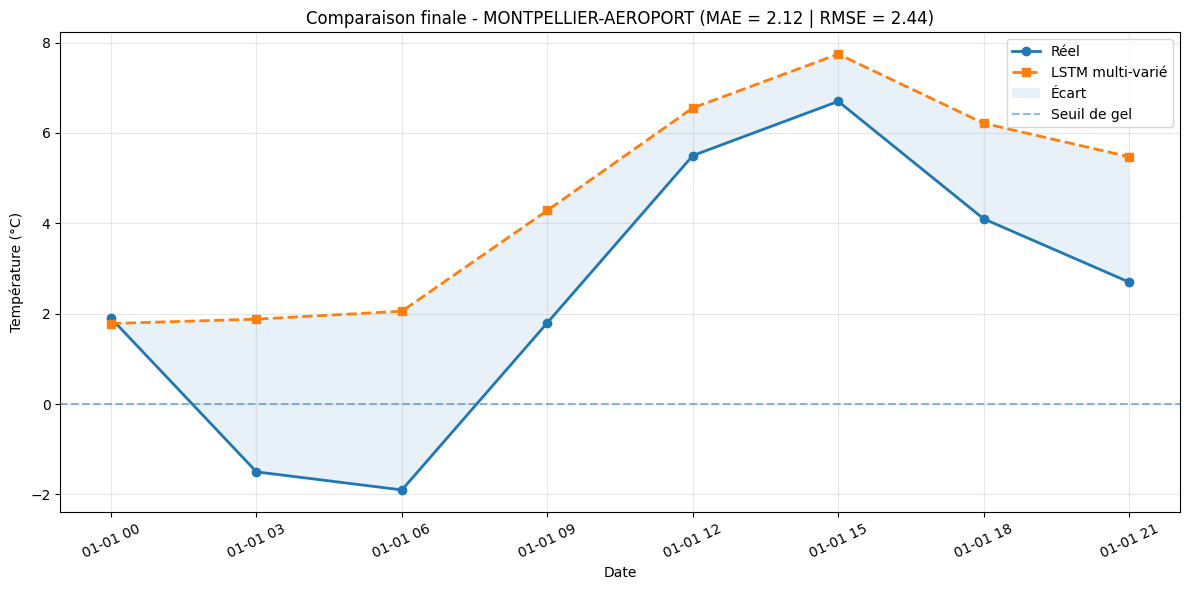


Analyse du minimum thermique :
Minimum réel   : -1.90 °C
Minimum prédit : 1.78 °C
Écart absolu   : 3.68 °C


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONFIGURATION DES FICHIERS
# =========================
file_pred = "forecast_lstm_24h.csv"
file_real = "synop_2026.csv"
target = "MONTPELLIER-AEROPORT"

print("Fichier prédictions :", file_pred)
print("Fichier réel        :", file_real)
print("Station cible       :", target)

# =========================
# 2. VÉRIFICATION DES FICHIERS
# =========================
if not os.path.exists(file_pred):
    raise FileNotFoundError(
        f"Le fichier '{file_pred}' est introuvable."
    )

if not os.path.exists(file_real):
    raise FileNotFoundError(
        f"Le fichier '{file_real}' est introuvable."
    )

print("\nLes fichiers ont bien été trouvés.")

# =========================
# 3. CHARGEMENT DES PRÉDICTIONS
# =========================
df_pred = pd.read_csv(file_pred)

if df_pred.empty:
    raise ValueError("Le fichier de prédictions est vide.")

required_pred_cols = ["ds", "y_pred"]
missing_pred_cols = [col for col in required_pred_cols if col not in df_pred.columns]

if missing_pred_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier de prédictions : {missing_pred_cols}")

df_pred["ds"] = pd.to_datetime(df_pred["ds"], utc=True, errors="coerce")
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce")

df_pred = df_pred.dropna(subset=["ds", "y_pred"]).copy()
df_pred = df_pred.sort_values("ds").copy()

print("\nAperçu des prédictions :")
print(df_pred.head())

# =========================
# 4. CHARGEMENT DES DONNÉES RÉELLES
# =========================
# On tente d'abord sep=';' puis lecture automatique si besoin
try:
    df_real_raw = pd.read_csv(file_real, sep=";")
except Exception:
    df_real_raw = pd.read_csv(file_real, sep=None, engine="python")

if df_real_raw.empty:
    raise ValueError("Le fichier réel est vide.")

required_real_cols = ["name", "validity_time", "t"]
missing_real_cols = [col for col in required_real_cols if col not in df_real_raw.columns]

if missing_real_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier réel : {missing_real_cols}")

df_real_raw["ds"] = pd.to_datetime(df_real_raw["validity_time"], utc=True, errors="coerce")
df_real_raw["y_real"] = pd.to_numeric(df_real_raw["t"], errors="coerce") - 273.15

df_real_raw = df_real_raw.dropna(subset=["name", "ds", "y_real"]).copy()

print("\nAperçu des données réelles :")
print(df_real_raw.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
df_real = df_real_raw[df_real_raw["name"] == target].copy()

if df_real.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target} dans le fichier réel.")

df_real = df_real.sort_values("ds").copy()

print(f"\nNombre de lignes réelles pour {target} :", len(df_real))

# =========================
# 6. ALIGNEMENT DES DONNÉES
# =========================
df_compare = pd.merge(
    df_pred[["ds", "y_pred"]],
    df_real[["ds", "y_real"]],
    on="ds",
    how="inner"
).sort_values("ds").copy()

df_compare = df_compare.dropna(subset=["ds", "y_pred", "y_real"]).copy()

if df_compare.empty:
    raise ValueError(
        "Aucune date commune trouvée entre les prédictions et les données réelles."
    )

print("\nAperçu de la comparaison :")
print(df_compare.head())

# =========================
# 7. CALCUL DES MÉTRIQUES
# =========================
mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
rmse = np.sqrt(mse)

print(f"\n📊 RÉSULTATS DU 1er JANVIER 2026 - {target}")
print("=" * 50)
print(f"MAE  : {mae:.2f} °C")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} °C")
print("=" * 50)

# =========================
# 8. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_compare["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_compare["y_real"].values, 2),
    "Prédit": np.round(df_compare["y_pred"].values, 2),
    "Écart": np.round(df_compare["y_pred"].values - df_compare["y_real"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 9. EXPORT CSV
# =========================
df_export = df_compare.copy()
df_export["ecart"] = df_export["y_pred"] - df_export["y_real"]

df_export.to_csv("comparaison_lstm_24h_vs_reel_2026.csv", index=False)

print("\nFichier 'comparaison_lstm_24h_vs_reel_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(12, 6))

plt.plot(
    df_compare["ds"],
    df_compare["y_real"],
    "o-",
    label="Réel",
    linewidth=2
)

plt.plot(
    df_compare["ds"],
    df_compare["y_pred"],
    "s--",
    label="LSTM multi-varié",
    linewidth=2
)

plt.fill_between(
    df_compare["ds"],
    df_compare["y_real"],
    df_compare["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Comparaison finale - {target} (MAE = {mae:.2f} | RMSE = {rmse:.2f})")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================
# 11. ANALYSE DU MINIMUM
# =========================
real_min = df_compare["y_real"].min()
pred_min = df_compare["y_pred"].min()

print("\nAnalyse du minimum thermique :")
print(f"Minimum réel   : {real_min:.2f} °C")
print(f"Minimum prédit : {pred_min:.2f} °C")
print(f"Écart absolu   : {abs(real_min - pred_min):.2f} °C")

Sur le 1er janvier 2026, le LSTM est performant (RMSE ≈ 2.44°C).

Meilleure précision globale que XGBoost.

Bonne capture de la tendance et des niveaux.

Erreurs plus faibles en journée.

Mais ne capte toujours pas le pic de froid (températures négatives).

Conclusion :  
Très bon modèle à court terme, plus précis que XGBoost, mais difficulté persistante sur les extrêmes (froid).

Même logique mais on essaye de prédire 1 semaine d'un coup

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['name', 'validity_time', 'pmer', 'tend', 'dd', 'ff', 't', 'td', 'u', 'n', 'pres', 'rr1']

Aperçu des données préparées :
                     name         validity_time      pmer   tend     dd   ff  \
2    MONTPELLIER-AEROPORT  2022-01-01T00:00:00Z  102720.0  -60.0  330.0  1.0   
62   MONTPELLIER-AEROPORT  2022-01-01T03:00:00Z  102710.0  -10.0   30.0  1.0   
153  MONTPELLIER-AEROPORT  2022-01-01T06:00:00Z  102700.0  -10.0   10.0  0.0   
208  MONTPELLIER-AEROPORT  2022-01-01T12:00:00Z  102780.0  -80.0  230.0  2.0   
269  MONTPELLIER-AEROPORT  2022-01-01T15:00:00Z  102670.0 -110.0  250.0  1.0   

          t      td      u      n    pres  rr1                        ds  \
2    280.05  279.95   99.0  101.0  1026.2  0.0 2022-01-01 00:00:00+00:00   
62   280.05  280.05  100.0  101.0  1026.1 

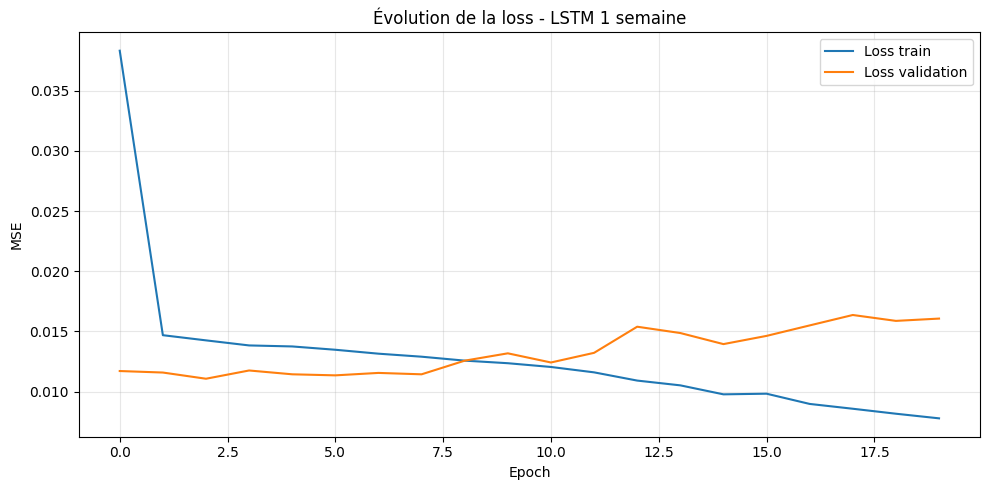

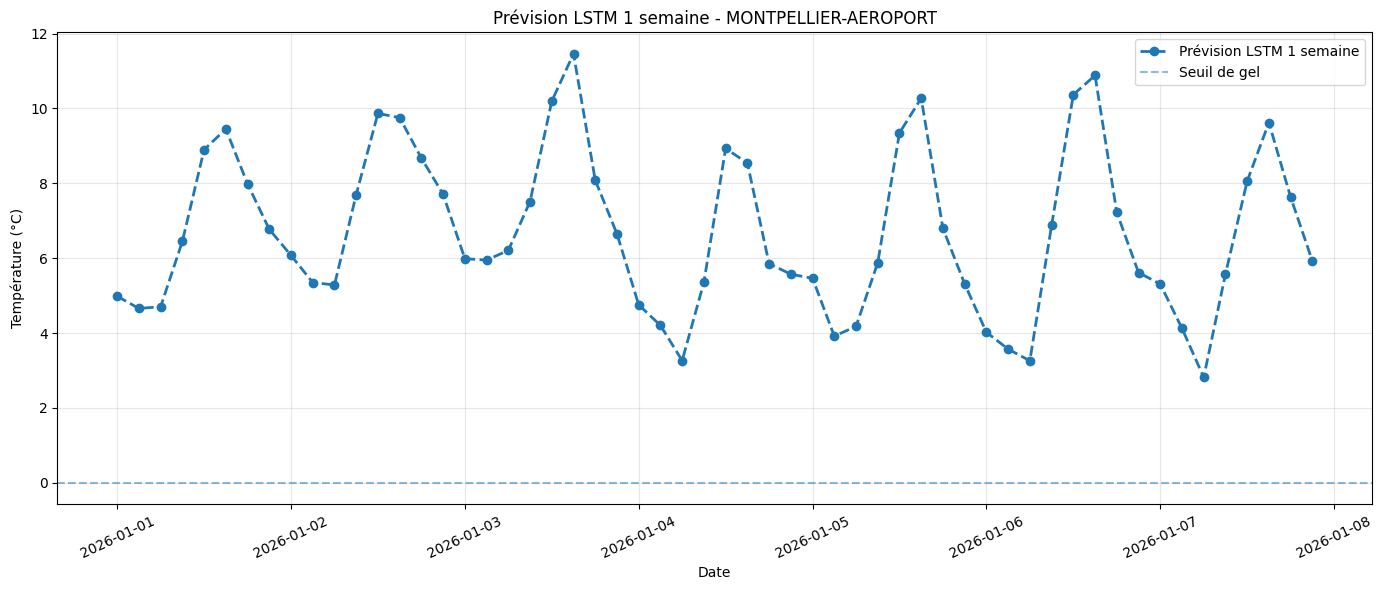

In [10]:
import pandas as pd
import numpy as np
import glob
import joblib

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols_physiques = [
    "validity_time",
    "t",
    "u",
    "pres",
    "dd",
    "ff",
    "td",
    "pmer",
    "tend",
    "n",
    "rr1",
    "name"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols_physiques
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")

target = "MONTPELLIER-AEROPORT"
df = df[df["name"] == target].copy()

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

df = df.drop_duplicates(subset="ds").sort_values("ds").copy()

# Conversions principales
df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["dew_point"] = pd.to_numeric(df["td"], errors="coerce") - 273.15
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

cols_num = [
    "y",
    "u",
    "pres",
    "dd",
    "ff",
    "dew_point",
    "pmer",
    "tend",
    "n",
    "rr1"
]

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après filtrage station :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. MISE EN INDEX ET INTERPOLATION
# =========================
df = df.set_index("ds")[cols_num].copy()

# Hypothèse : pluie manquante = 0
df["rr1"] = df["rr1"].fillna(0)

# Interpolation linéaire
df = df.interpolate(method="linear").bfill()

# Rééchantillonnage toutes les 3 heures
df = df.resample("3h").interpolate(method="linear")

print("\nAperçu après interpolation / resampling :")
print(df.head())

if df.empty:
    raise ValueError("Le DataFrame est vide après interpolation / resampling.")

# =========================
# 4. FEATURE ENGINEERING
# =========================
df["hour"] = df.index.hour
df["day_of_year"] = df.index.dayofyear

normales_map = df.groupby(["day_of_year", "hour"])["y"].mean()

df["y_normal"] = [
    normales_map.get((d, h), np.nan)
    for d, h in zip(df["day_of_year"], df["hour"])
]

df["residue"] = df["y"] - df["y_normal"]

df["wind_u"] = df["ff"] * np.cos(np.deg2rad(df["dd"]))
df["wind_v"] = df["ff"] * np.sin(np.deg2rad(df["dd"]))

df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

features = [
    "hr_sin",
    "hr_cos",
    "residue",
    "u",
    "pres",
    "wind_u",
    "wind_v",
    "dew_point",
    "pmer",
    "tend",
    "n",
    "rr1"
]

df = df.dropna(subset=features + ["y_normal", "residue"]).copy()

print("\nVariables utilisées :")
print(features)

print("\nAperçu après création des variables :")
print(df[features + ["y", "y_normal"]].head())

if df.empty:
    raise ValueError("Aucune donnée restante après le feature engineering.")

# =========================
# 5. SCALING
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[["residue"]])

# Sauvegarde des scalers
joblib.dump(scaler_X, "scaler_X_1week.pkl")
joblib.dump(scaler_y, "scaler_y_1week.pkl")

print("\nScalers sauvegardés :")
print("- scaler_X_1week.pkl")
print("- scaler_y_1week.pkl")

# =========================
# 6. CRÉATION DES SÉQUENCES
# =========================
def create_sequences(data_X, data_y, in_len=80, out_len=56):
    X_seq = []
    y_seq = []

    for i in range(len(data_X) - in_len - out_len):
        X_seq.append(data_X[i:i + in_len])
        y_seq.append(data_y[i + in_len:i + in_len + out_len, 0])

    return np.array(X_seq), np.array(y_seq)

X_data, y_data = create_sequences(
    scaled_X,
    scaled_y,
    in_len=80,
    out_len=56
)

print("\nShape X_data :", X_data.shape)
print("Shape y_data :", y_data.shape)

if len(X_data) == 0 or len(y_data) == 0:
    raise ValueError(
        "Aucune séquence générée. Il faut plus de données ou réduire in_len / out_len."
    )

# =========================
# 7. SPLIT TRAIN / TEST
# =========================
split = int(0.85 * len(X_data))

X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

print("\nTaille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test  :", y_test.shape)

if len(X_train) == 0:
    raise ValueError("Le jeu d'entraînement est vide.")

# =========================
# 8. CONSTRUCTION DU MODÈLE
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(64, activation="relu"),
    Dense(56)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

print("\nArchitecture du modèle prête.")

# =========================
# 9. ENTRAÎNEMENT
# =========================
print("\nEntraînement pour 1 semaine de prédiction...")

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 10. PRÉPARATION DE LA FENÊTRE FINALE
# =========================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz="UTC")

df_past = df[df.index <= cutoff].tail(80).copy()

if len(df_past) < 80:
    raise ValueError(
        "Pas assez de données avant le cutoff pour construire la fenêtre finale de 80 pas."
    )

last_window = scaler_X.transform(df_past[features]).reshape(1, 80, len(features))

print("\nFenêtre finale prête pour la prédiction.")
print("Shape last_window :", last_window.shape)

# =========================
# 11. PRÉDICTION SUR 1 SEMAINE
# =========================
pred_res_scaled = model.predict(last_window)

pred_residue = scaler_y.inverse_transform(
    pred_res_scaled.reshape(-1, 1)
).flatten()

future_dates = pd.date_range(
    start=cutoff + pd.Timedelta(hours=3),
    periods=56,
    freq="3h",
    tz="UTC"
)

future_normales = []
for d in future_dates:
    val = normales_map.get((d.dayofyear, d.hour), np.nan)
    future_normales.append(val)

future_normales = np.array(future_normales, dtype=float)

# Sécurité si une normale manque
if np.isnan(future_normales).any():
    fallback = df["y_normal"].iloc[-1]
    future_normales = np.where(np.isnan(future_normales), fallback, future_normales)

final_forecast = pred_residue + future_normales

df_res = pd.DataFrame({
    "ds": future_dates,
    "y_pred": final_forecast
})

print("\nPrévisions finales :")
print(df_res.head(20))

# =========================
# 12. EXPORTS
# =========================
df_res.to_csv("forecast_lstm_1week.csv", index=False)
model.save("modele_montpellier_1week.keras")

print("\nFichiers sauvegardés avec succès :")
print("- forecast_lstm_1week.csv")
print("- modele_montpellier_1week.keras")

# =========================
# 13. COURBE DE PERTE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss - LSTM 1 semaine")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 14. VISUALISATION DES PRÉVISIONS
# =========================
plt.figure(figsize=(14, 6))

plt.plot(
    df_res["ds"],
    df_res["y_pred"],
    "--o",
    label="Prévision LSTM 1 semaine",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision LSTM 1 semaine - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Fichier prédictions : forecast_lstm_1week.csv
Fichier réel        : synop_2026.csv
Station cible       : MONTPELLIER-AEROPORT

Les fichiers ont bien été trouvés.

Aperçu des prédictions :
                         ds    y_pred
0 2026-01-01 00:00:00+00:00  4.983217
1 2026-01-01 03:00:00+00:00  4.655434
2 2026-01-01 06:00:00+00:00  4.702101
3 2026-01-01 09:00:00+00:00  6.444689
4 2026-01-01 12:00:00+00:00  8.896397

Aperçu des données réelles :
         lat       lon  geo_id_wmo     geo_id_wigos           name  \
0  50.732500  1.599667        7002  0-20000-0-07002   BOULOGNE-SEM   
1  50.514500  1.622833        7003  0-20000-0-07003     LE-TOUQUET   
2  50.136000  1.834000        7005  0-20000-0-07005      ABBEVILLE   
3  51.055833  2.339500        7010  0-20000-0-07010      DUNKERQUE   
4  50.570000  3.097500        7015  0-20000-0-07015  LILLE-LESQUIN   

         reference_time           insert_time         validity_time      pmer  \
0  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z  2026-

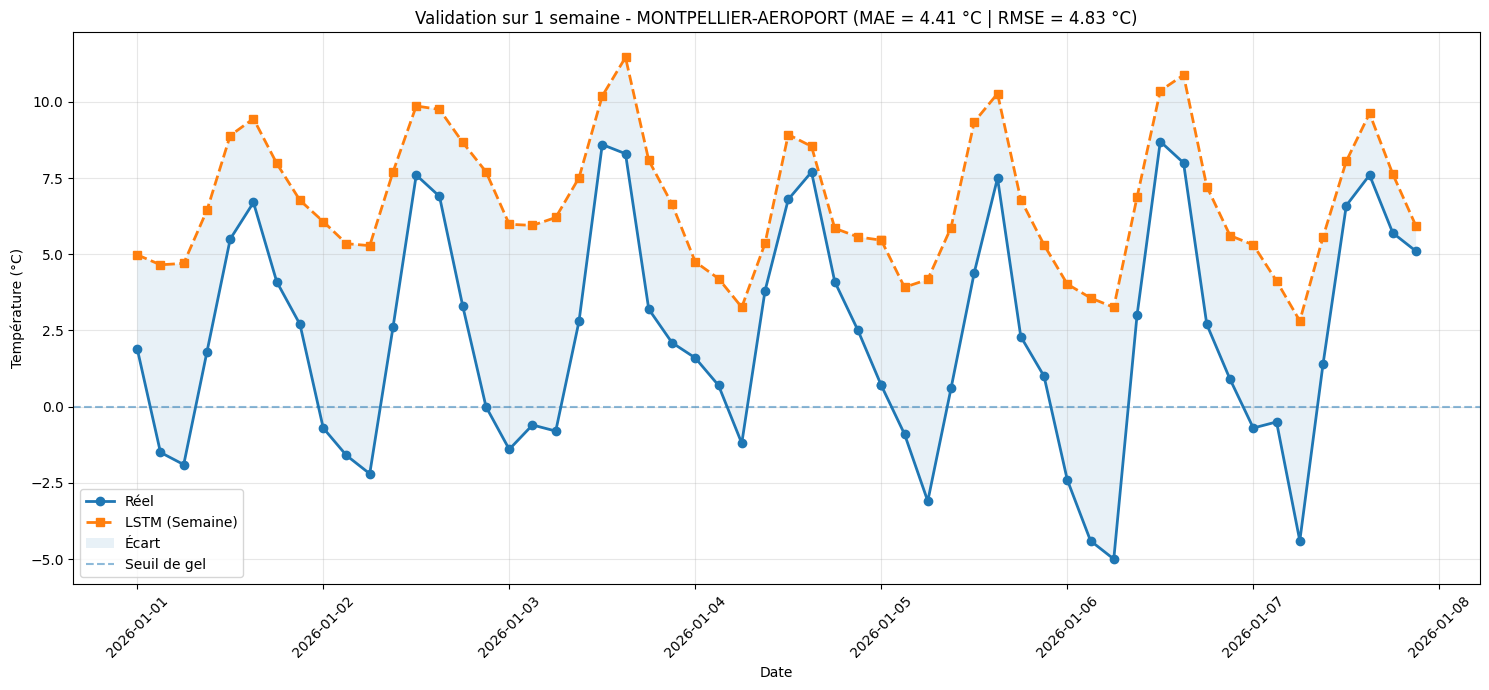


Analyse du minimum thermique :
Minimum réel   : -5.00 °C
Minimum prédit : 2.81 °C
Écart absolu   : 7.81 °C


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONFIGURATION DES FICHIERS
# =========================
file_pred = "forecast_lstm_1week.csv"
file_real = "synop_2026.csv"
target = "MONTPELLIER-AEROPORT"

print("Fichier prédictions :", file_pred)
print("Fichier réel        :", file_real)
print("Station cible       :", target)

# =========================
# 2. VÉRIFICATION DES FICHIERS
# =========================
if not os.path.exists(file_pred):
    raise FileNotFoundError(
        f"Le fichier '{file_pred}' est introuvable."
    )

if not os.path.exists(file_real):
    raise FileNotFoundError(
        f"Le fichier '{file_real}' est introuvable."
    )

print("\nLes fichiers ont bien été trouvés.")

# =========================
# 3. CHARGEMENT DES PRÉDICTIONS
# =========================
df_pred = pd.read_csv(file_pred)

if df_pred.empty:
    raise ValueError("Le fichier de prédictions est vide.")

required_pred_cols = ["ds", "y_pred"]
missing_pred_cols = [col for col in required_pred_cols if col not in df_pred.columns]

if missing_pred_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier de prédictions : {missing_pred_cols}")

df_pred["ds"] = pd.to_datetime(df_pred["ds"], utc=True, errors="coerce")
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce")

df_pred = df_pred.dropna(subset=["ds", "y_pred"]).copy()
df_pred = df_pred.sort_values("ds").copy()

print("\nAperçu des prédictions :")
print(df_pred.head())

# =========================
# 4. CHARGEMENT DES DONNÉES RÉELLES
# =========================
try:
    df_real_raw = pd.read_csv(file_real, sep=";")
except Exception:
    df_real_raw = pd.read_csv(file_real, sep=None, engine="python")

if df_real_raw.empty:
    raise ValueError("Le fichier réel est vide.")

required_real_cols = ["name", "validity_time", "t"]
missing_real_cols = [col for col in required_real_cols if col not in df_real_raw.columns]

if missing_real_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier réel : {missing_real_cols}")

df_real_raw["ds"] = pd.to_datetime(df_real_raw["validity_time"], utc=True, errors="coerce")
df_real_raw["y_real"] = pd.to_numeric(df_real_raw["t"], errors="coerce") - 273.15

df_real_raw = df_real_raw.dropna(subset=["name", "ds", "y_real"]).copy()

print("\nAperçu des données réelles :")
print(df_real_raw.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
df_real = df_real_raw[df_real_raw["name"] == target].copy()

if df_real.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target} dans le fichier réel.")

df_real = df_real.sort_values("ds").copy()

print(f"\nNombre de lignes réelles pour {target} :", len(df_real))

# =========================
# 6. ALIGNEMENT DES DONNÉES
# =========================
df_compare = pd.merge(
    df_pred[["ds", "y_pred"]],
    df_real[["ds", "y_real"]],
    on="ds",
    how="inner"
).sort_values("ds").copy()

df_compare = df_compare.dropna(subset=["ds", "y_pred", "y_real"]).copy()

if df_compare.empty:
    raise ValueError("Aucune donnée de comparaison trouvée pour cette semaine.")

print("\nAperçu de la comparaison :")
print(df_compare.head())

# =========================
# 7. CALCUL DES MÉTRIQUES
# =========================
mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
rmse = np.sqrt(mse)

print(f"\n📊 VALIDATION SUR 1 SEMAINE - {target}")
print("=" * 50)
print(f"MAE  : {mae:.2f} °C")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} °C")
print("=" * 50)

# =========================
# 8. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_compare["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_compare["y_real"].values, 2),
    "Prédit": np.round(df_compare["y_pred"].values, 2),
    "Écart": np.round(df_compare["y_pred"].values - df_compare["y_real"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 9. EXPORT CSV
# =========================
df_export = df_compare.copy()
df_export["ecart"] = df_export["y_pred"] - df_export["y_real"]

df_export.to_csv("comparaison_lstm_1week_vs_reel_2026.csv", index=False)

print("\nFichier 'comparaison_lstm_1week_vs_reel_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(15, 7))

plt.plot(
    df_compare["ds"],
    df_compare["y_real"],
    "o-",
    label="Réel",
    linewidth=2
)

plt.plot(
    df_compare["ds"],
    df_compare["y_pred"],
    "s--",
    label="LSTM (Semaine)",
    linewidth=2
)

plt.fill_between(
    df_compare["ds"],
    df_compare["y_real"],
    df_compare["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Validation sur 1 semaine - {target} (MAE = {mae:.2f} °C | RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 11. ANALYSE DU MINIMUM
# =========================
real_min = df_compare["y_real"].min()
pred_min = df_compare["y_pred"].min()

print("\nAnalyse du minimum thermique :")
print(f"Minimum réel   : {real_min:.2f} °C")
print(f"Minimum prédit : {pred_min:.2f} °C")
print(f"Écart absolu   : {abs(real_min - pred_min):.2f} °C")

Sur une semaine, les performances du LSTM se dégradent fortement (RMSE ≈ 4.83°C).

Le modèle suit la tendance globale mais reste trop chaud en permanence.

Forte surestimation des températures sur toute la période.

Incapacité à capter les épisodes de froid (écarts très importants, jusqu’à 7–8°C).

Les variations sont lissées → perte des extrêmes.

Conclusion :  
Bon à court terme, mais peu fiable à moyen terme → le LSTM lisse trop et ignore les événements extrêmes.

lstm récursif en prédisant point par point pour toute une semaine, on utilise uniquement les variables temperature humidite et pression

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['name', 'validity_time', 'dd', 'ff', 't', 'td', 'u', 'pres']

Aperçu des données préparées :
                     name         validity_time     dd   ff       t      td  \
2    MONTPELLIER-AEROPORT  2022-01-01T00:00:00Z  330.0  1.0  280.05  279.95   
62   MONTPELLIER-AEROPORT  2022-01-01T03:00:00Z   30.0  1.0  280.05  280.05   
153  MONTPELLIER-AEROPORT  2022-01-01T06:00:00Z   10.0  0.0  280.25  280.25   
208  MONTPELLIER-AEROPORT  2022-01-01T12:00:00Z  230.0  2.0  281.75  281.75   
269  MONTPELLIER-AEROPORT  2022-01-01T15:00:00Z  250.0  1.0  283.25  282.95   

         u    pres                        ds     y  
2     99.0  1026.2 2022-01-01 00:00:00+00:00   6.9  
62   100.0  1026.1 2022-01-01 03:00:00+00:00   6.9  
153  100.0  1026.0 2022-01-01 06:00:00+00:00   7.1  
208  100.0  1026

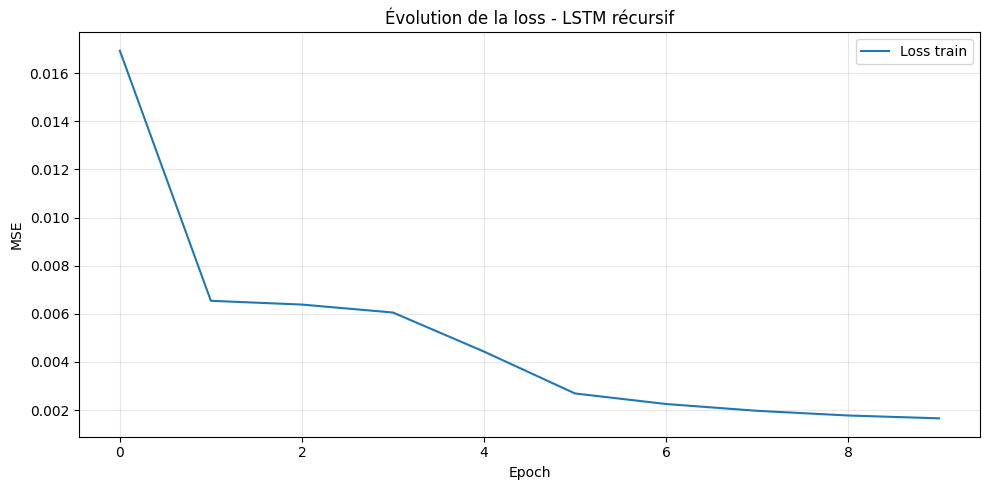

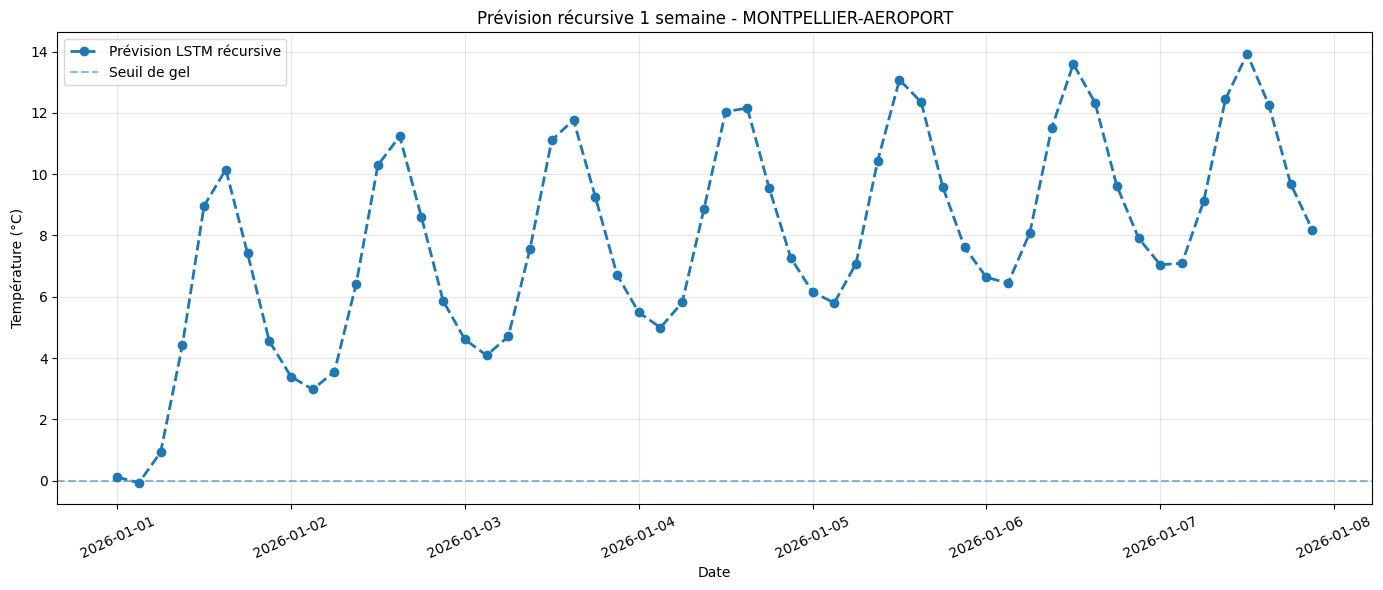

In [12]:
import pandas as pd
import numpy as np
import glob
import joblib

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Sequential

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols_physiques = [
    "validity_time",
    "t",
    "u",
    "pres",
    "dd",
    "ff",
    "td",
    "name"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols_physiques
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")

target = "MONTPELLIER-AEROPORT"
df = df[df["name"] == target].copy()

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

df = df.drop_duplicates(subset="ds").sort_values("ds").copy()

df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["u"] = pd.to_numeric(df["u"], errors="coerce")
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

df = df.dropna(subset=["ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après filtrage station :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. MISE EN INDEX ET INTERPOLATION
# =========================
df = df.set_index("ds")[["y", "u", "pres"]].copy()

df = df.interpolate(method="linear").bfill()
df = df.resample("3h").interpolate(method="linear")

print("\nAperçu après interpolation / resampling :")
print(df.head())

if df.empty:
    raise ValueError("Le DataFrame est vide après interpolation / resampling.")

# =========================
# 4. DÉFINITION DES FEATURES
# =========================
features = ["y", "u", "pres"]

print("\nVariables utilisées :")
print(features)

df = df.dropna(subset=features).copy()

if df.empty:
    raise ValueError("Aucune donnée valide restante après nettoyage final.")

# =========================
# 5. NORMALISATION
# =========================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

joblib.dump(scaler, "scaler_lstm_recursive.pkl")

print("\nScaler sauvegardé :")
print("- scaler_lstm_recursive.pkl")

# =========================
# 6. CRÉATION DES SÉQUENCES
# =========================
def create_single_step_sequences(data, in_len=48):
    X_seq = []
    y_seq = []

    for i in range(len(data) - in_len):
        X_seq.append(data[i:i + in_len])
        y_seq.append(data[i + in_len, 0])  # on prédit uniquement y

    return np.array(X_seq), np.array(y_seq)

X_data, y_data = create_single_step_sequences(
    scaled_data,
    in_len=48
)

print("\nShape X_data :", X_data.shape)
print("Shape y_data :", y_data.shape)

if len(X_data) == 0 or len(y_data) == 0:
    raise ValueError("Aucune séquence générée. Il faut plus de données ou réduire in_len.")

# =========================
# 7. CONSTRUCTION DU MODÈLE
# =========================
model = Sequential([
    Input(shape=(X_data.shape[1], X_data.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

print("\nArchitecture du modèle prête.")

# =========================
# 8. ENTRAÎNEMENT
# =========================
print("\nEntraînement du modèle récursif...")

history = model.fit(
    X_data,
    y_data,
    epochs=10,
    batch_size=64,
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉPARATION DE LA FENÊTRE INITIALE
# =========================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz="UTC")

past_data = scaled_data[df.index <= cutoff]

if len(past_data) < 48:
    raise ValueError(
        "Pas assez de données avant le cutoff pour construire la fenêtre initiale de 48 pas."
    )

current_window = past_data[-48:].copy()

print("\nFenêtre initiale prête.")
print("Shape current_window :", current_window.shape)

# =========================
# 10. PRÉDICTION RÉCURSIVE SUR 1 SEMAINE
# =========================
predictions_scaled = []

print("\nGénération récursive de la semaine point par point...")

for i in range(56):
    input_seq = current_window.reshape(1, 48, len(features))

    pred_y_scaled = model.predict(input_seq, verbose=0)[0, 0]
    predictions_scaled.append(pred_y_scaled)

    # On conserve les dernières valeurs connues de u et pres
    last_u_pres = current_window[-1, 1:]
    new_entry = np.array([pred_y_scaled, *last_u_pres])

    # Décalage de la fenêtre
    current_window = np.vstack([current_window[1:], new_entry])

print("\nNombre de prédictions générées :", len(predictions_scaled))

# =========================
# 11. DÉNORMALISATION
# =========================
dummy = np.zeros((len(predictions_scaled), len(features)))
dummy[:, 0] = predictions_scaled

final_temp = scaler.inverse_transform(dummy)[:, 0]

print("\nAperçu des températures prédites :")
print(final_temp[:10])

# =========================
# 12. CONSTRUCTION DES DATES FUTURES
# =========================
future_dates = pd.date_range(
    start=cutoff + pd.Timedelta(hours=3),
    periods=56,
    freq="3h",
    tz="UTC"
)

df_res = pd.DataFrame({
    "ds": future_dates,
    "y_pred": final_temp
})

print("\nPrévisions finales :")
print(df_res.head(20))

# =========================
# 13. EXPORTS
# =========================
df_res.to_csv("forecast_lstm_recursive.csv", index=False)
model.save("modele_lstm_recursive.keras")

print("\nFichiers sauvegardés avec succès :")
print("- forecast_lstm_recursive.csv")
print("- modele_lstm_recursive.keras")

# =========================
# 14. COURBE DE PERTE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")

plt.title("Évolution de la loss - LSTM récursif")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 15. VISUALISATION DES PRÉVISIONS
# =========================
plt.figure(figsize=(14, 6))

plt.plot(
    df_res["ds"],
    df_res["y_pred"],
    "--o",
    label="Prévision LSTM récursive",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision récursive 1 semaine - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Fichier prédictions : forecast_lstm_recursive.csv
Fichier réel        : synop_2026.csv
Station cible       : MONTPELLIER-AEROPORT

Les fichiers ont bien été trouvés.

Aperçu des prédictions :
                         ds    y_pred
0 2026-01-01 00:00:00+00:00  0.113176
1 2026-01-01 03:00:00+00:00 -0.071669
2 2026-01-01 06:00:00+00:00  0.920396
3 2026-01-01 09:00:00+00:00  4.409476
4 2026-01-01 12:00:00+00:00  8.967326

Aperçu des données réelles :
           lat       lon  geo_id_wmo     geo_id_wigos  \
0    50.732500  1.599667        7002  0-20000-0-07002   
121  43.385000 -0.416333        7610  0-20000-0-07610   
122  43.188000  0.000000        7621  0-20000-0-07621   
123  43.689000  0.601167        7622  0-20000-0-07622   
124  43.005333  1.106833        7627  0-20000-0-07627   

                        name        reference_time           insert_time  \
0               BOULOGNE-SEM  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z   
121                PAU-UZEIN  2026-01-01T00:10:06Z  202

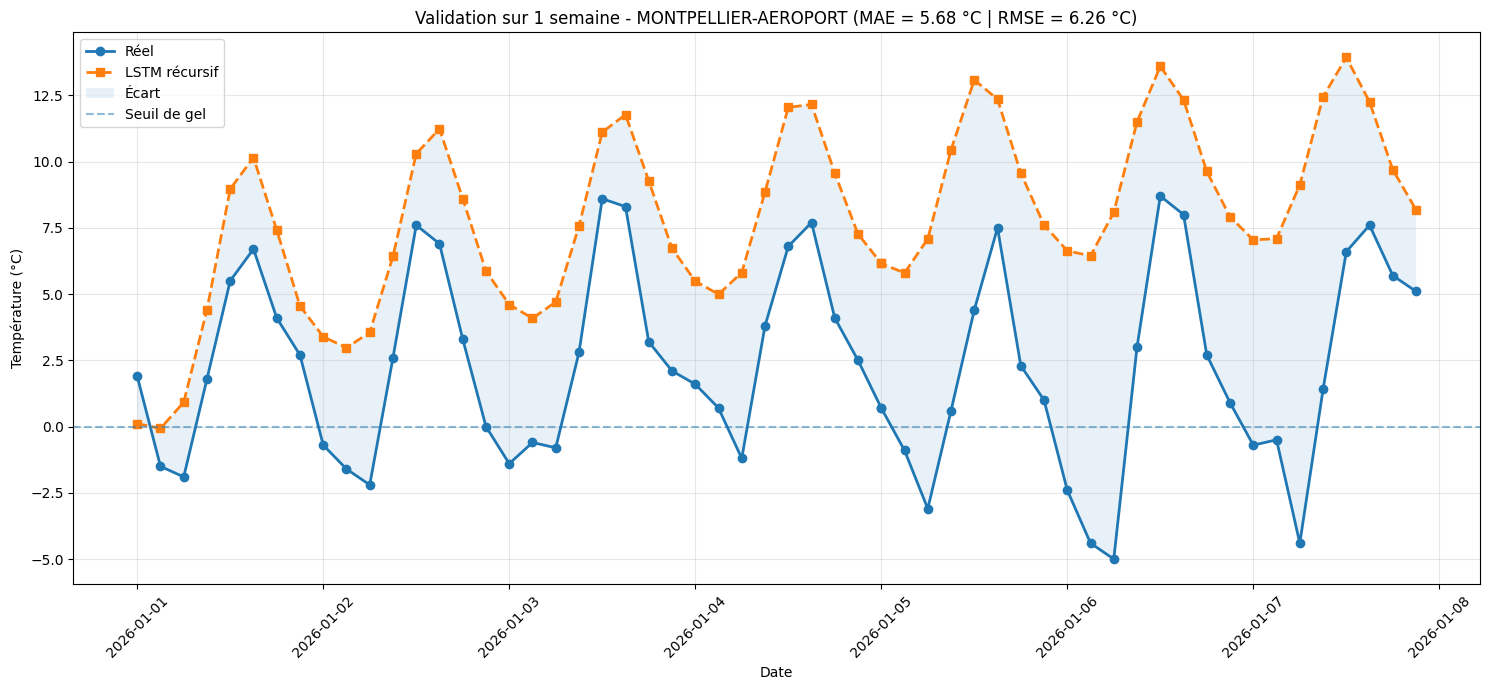


Analyse du minimum thermique :
Minimum réel   : -5.00 °C
Minimum prédit : -0.07 °C
Écart absolu   : 4.93 °C


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONFIGURATION DES FICHIERS
# =========================
file_pred = "forecast_lstm_recursive.csv"
file_real = "synop_2026.csv"
target = "MONTPELLIER-AEROPORT"

print("Fichier prédictions :", file_pred)
print("Fichier réel        :", file_real)
print("Station cible       :", target)

# =========================
# 2. VÉRIFICATION DES FICHIERS
# =========================
if not os.path.exists(file_pred):
    raise FileNotFoundError(
        f"Le fichier '{file_pred}' est introuvable."
    )

if not os.path.exists(file_real):
    raise FileNotFoundError(
        f"Le fichier '{file_real}' est introuvable."
    )

print("\nLes fichiers ont bien été trouvés.")

# =========================
# 3. CHARGEMENT DES PRÉDICTIONS
# =========================
df_pred = pd.read_csv(file_pred)

if df_pred.empty:
    raise ValueError("Le fichier de prédictions est vide.")

required_pred_cols = ["ds", "y_pred"]
missing_pred_cols = [col for col in required_pred_cols if col not in df_pred.columns]

if missing_pred_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier de prédictions : {missing_pred_cols}")

df_pred["ds"] = pd.to_datetime(df_pred["ds"], utc=True, errors="coerce")
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce")

df_pred = df_pred.dropna(subset=["ds", "y_pred"]).copy()
df_pred = df_pred.sort_values("ds").copy()

print("\nAperçu des prédictions :")
print(df_pred.head())

# =========================
# 4. CHARGEMENT DES DONNÉES RÉELLES
# =========================
try:
    df_real_raw = pd.read_csv(file_real, sep=";")
except Exception:
    df_real_raw = pd.read_csv(file_real, sep=None, engine="python")

if df_real_raw.empty:
    raise ValueError("Le fichier réel est vide.")

required_real_cols = ["name", "validity_time", "t"]
missing_real_cols = [col for col in required_real_cols if col not in df_real_raw.columns]

if missing_real_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier réel : {missing_real_cols}")

df_real_raw["ds"] = pd.to_datetime(df_real_raw["validity_time"], utc=True, errors="coerce")
df_real_raw["y_real"] = pd.to_numeric(df_real_raw["t"], errors="coerce") - 273.15

df_real_raw = df_real_raw.dropna(subset=["name", "ds", "y_real"]).copy()
df_real_raw = df_real_raw.sort_values("ds").copy()

print("\nAperçu des données réelles :")
print(df_real_raw.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
df_real = df_real_raw[df_real_raw["name"] == target].copy()

if df_real.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target} dans le fichier réel.")

print(f"\nNombre de lignes réelles pour {target} :", len(df_real))

# =========================
# 6. ALIGNEMENT DES DONNÉES
# =========================
df_compare = pd.merge(
    df_pred[["ds", "y_pred"]],
    df_real[["ds", "y_real"]],
    on="ds",
    how="inner"
).sort_values("ds").copy()

df_compare = df_compare.dropna(subset=["ds", "y_pred", "y_real"]).copy()

if df_compare.empty:
    raise ValueError("Aucune donnée de comparaison trouvée pour cette semaine.")

print("\nAperçu de la comparaison :")
print(df_compare.head())

# =========================
# 7. CALCUL DES MÉTRIQUES
# =========================
mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
rmse = np.sqrt(mse)

print(f"\n📊 VALIDATION SUR 1 SEMAINE - {target}")
print("=" * 50)
print(f"MAE  : {mae:.2f} °C")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} °C")
print("=" * 50)

# =========================
# 8. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_compare["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_compare["y_real"].values, 2),
    "Prédit": np.round(df_compare["y_pred"].values, 2),
    "Écart": np.round(df_compare["y_pred"].values - df_compare["y_real"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 9. EXPORT CSV
# =========================
df_export = df_compare.copy()
df_export["ecart"] = df_export["y_pred"] - df_export["y_real"]

df_export.to_csv("comparaison_lstm_recursive_vs_reel_2026.csv", index=False)

print("\nFichier 'comparaison_lstm_recursive_vs_reel_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(15, 7))

plt.plot(
    df_compare["ds"],
    df_compare["y_real"],
    "o-",
    label="Réel",
    linewidth=2
)

plt.plot(
    df_compare["ds"],
    df_compare["y_pred"],
    "s--",
    label="LSTM récursif",
    linewidth=2
)

plt.fill_between(
    df_compare["ds"],
    df_compare["y_real"],
    df_compare["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Validation sur 1 semaine - {target} (MAE = {mae:.2f} °C | RMSE = {rmse:.2f} °C)")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 11. ANALYSE DU MINIMUM
# =========================
real_min = df_compare["y_real"].min()
pred_min = df_compare["y_pred"].min()

print("\nAnalyse du minimum thermique :")
print(f"Minimum réel   : {real_min:.2f} °C")
print(f"Minimum prédit : {pred_min:.2f} °C")
print(f"Écart absolu   : {abs(real_min - pred_min):.2f} °C")

En mode récursif sur une semaine, les performances du LSTM se dégradent encore davantage (RMSE ≈ 6.26°C).
Les erreurs s’accumulent à chaque prédiction (effet boule de neige).

Forte dérive vers des températures trop élevées au fil du temps.

Incapacité totale à capturer les épisodes de froid (écarts > 10°C).

Le modèle diverge progressivement → perte de réalisme physique.

Conclusion :  
Le LSTM récursif est instable à moyen terme → accumulation d’erreurs → très peu fiable pour des prévisions longues.

lstm recursif en ayant transformé l'heure et le jour de l'année en fonctions sinus et cosinus

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['name', 'validity_time', 't', 'u', 'pres']

Aperçu des données préparées :
                     name         validity_time       t      u    pres  \
2    MONTPELLIER-AEROPORT  2022-01-01T00:00:00Z  280.05   99.0  1026.2   
62   MONTPELLIER-AEROPORT  2022-01-01T03:00:00Z  280.05  100.0  1026.1   
153  MONTPELLIER-AEROPORT  2022-01-01T06:00:00Z  280.25  100.0  1026.0   
208  MONTPELLIER-AEROPORT  2022-01-01T12:00:00Z  281.75  100.0  1026.8   
269  MONTPELLIER-AEROPORT  2022-01-01T15:00:00Z  283.25   98.0  1025.7   

                           ds     y  
2   2022-01-01 00:00:00+00:00   6.9  
62  2022-01-01 03:00:00+00:00   6.9  
153 2022-01-01 06:00:00+00:00   7.1  
208 2022-01-01 12:00:00+00:00   8.6  
269 2022-01-01 15:00:00+00:00  10.1  

Taille après filtrage station : (11427, 7)

Ape

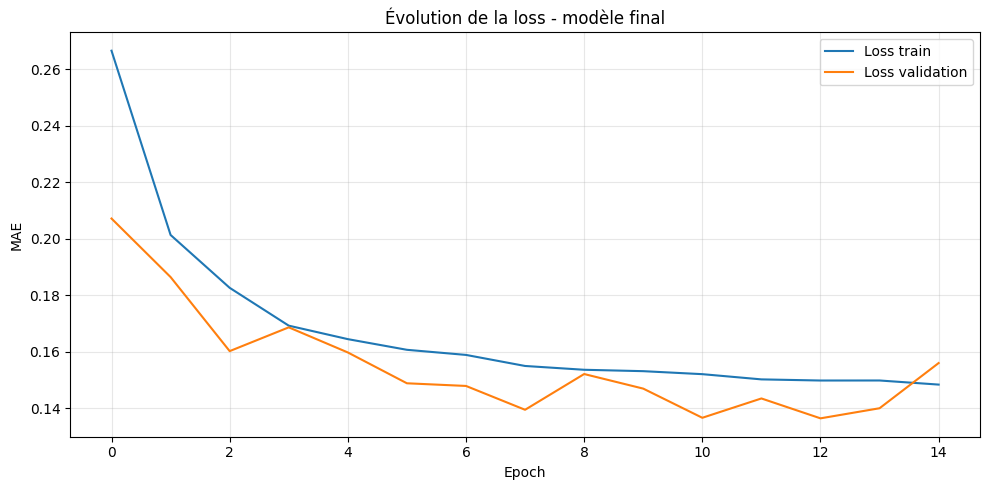

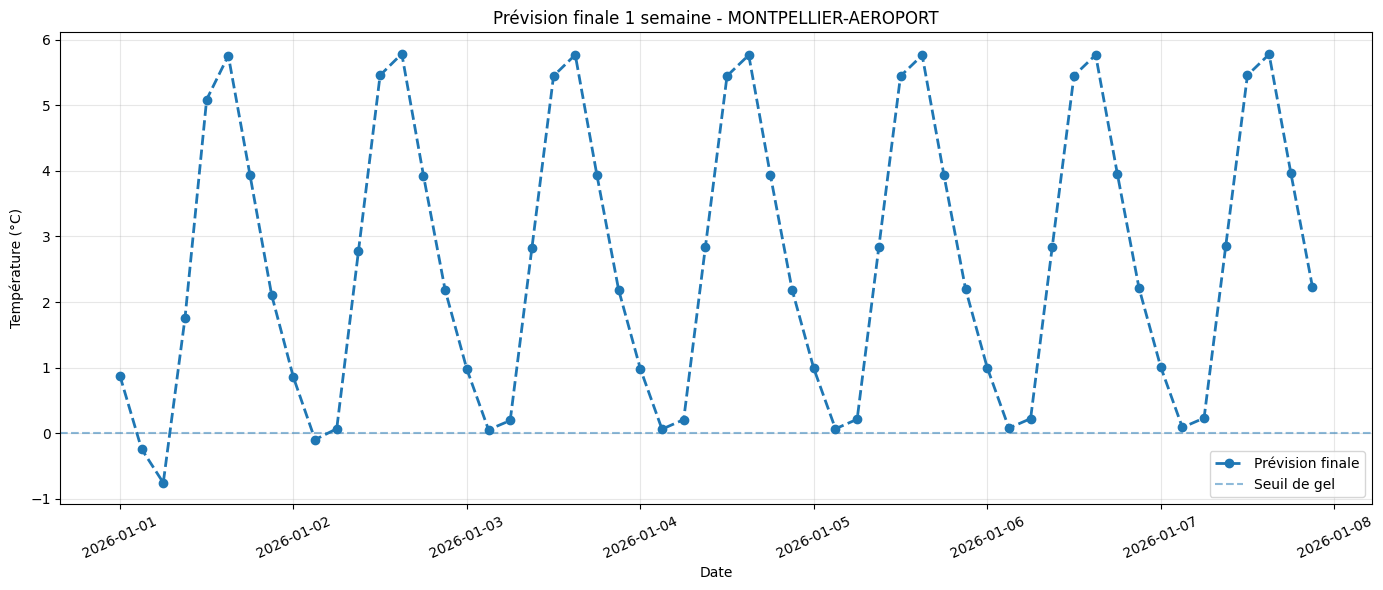

In [14]:
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "validity_time",
    "t",
    "u",
    "pres",
    "name"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")

target = "MONTPELLIER-AEROPORT"
df = df[df["name"] == target].copy()

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

df = df.drop_duplicates(subset="ds").sort_values("ds").copy()

df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["u"] = pd.to_numeric(df["u"], errors="coerce")
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

df = df.dropna(subset=["ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après filtrage station :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. FEATURES CIRCULAIRES
# =========================
df["hour_sin"] = np.sin(2 * np.pi * df["ds"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["ds"].dt.hour / 24)
df["day_sin"] = np.sin(2 * np.pi * df["ds"].dt.dayofyear / 365.25)
df["day_cos"] = np.cos(2 * np.pi * df["ds"].dt.dayofyear / 365.25)

# Mise en index + interpolation
df = df.set_index("ds")[[
    "y",
    "u",
    "pres",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]].copy()

df = df.interpolate(method="linear").bfill()
df = df.resample("3h").interpolate(method="linear")

print("\nAperçu après interpolation / resampling :")
print(df.head())

if df.empty:
    raise ValueError("Le DataFrame est vide après interpolation / resampling.")

# =========================
# 4. DÉFINITION DES FEATURES
# =========================
features = [
    "y",
    "u",
    "pres",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

df = df.dropna(subset=features).copy()

print("\nVariables utilisées :")
print(features)

if df.empty:
    raise ValueError("Aucune donnée valide restante après nettoyage final.")

# =========================
# 5. NORMALISATION
# =========================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

print("\nNormalisation StandardScaler effectuée.")

# =========================
# 6. CRÉATION DES SÉQUENCES
# =========================
X = []
y = []

in_len = 56  # 1 semaine de contexte

for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i + in_len])
    y.append(scaled_data[i + in_len, 0])

X = np.array(X)
y = np.array(y)

print("\nShape X :", X.shape)
print("Shape y :", y.shape)

if len(X) == 0 or len(y) == 0:
    raise ValueError("Aucune séquence générée. Il faut plus de données ou réduire in_len.")

# =========================
# 7. CONSTRUCTION DU MODÈLE
# =========================
model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mae"
)

print("\nArchitecture du modèle prête.")

# =========================
# 8. ENTRAÎNEMENT
# =========================
print("\nEntraînement du modèle...")

history = model.fit(
    X,
    y,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉPARATION DE LA FENÊTRE FINALE
# =========================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz="UTC")

past_data = scaled_data[df.index <= cutoff]

if len(past_data) < in_len:
    raise ValueError(
        f"Pas assez de données avant le cutoff pour construire une fenêtre de {in_len} pas."
    )

current_window = past_data[-in_len:].copy()

print("\nFenêtre initiale prête.")
print("Shape current_window :", current_window.shape)

# =========================
# 10. PRÉDICTION RÉCURSIVE
# =========================
final_forecast = []

print("\nCalcul de la trajectoire thermique...")

for i in range(56):
    pred_scaled = model.predict(
        current_window.reshape(1, in_len, len(features)),
        verbose=0
    )[0, 0]

    # dénormalisation de la température
    temp_c = (pred_scaled * scaler.scale_[0]) + scaler.mean_[0]
    final_forecast.append(temp_c)

    future_date = cutoff + pd.Timedelta(hours=3 * (i + 1))

    new_features = [
        pred_scaled,
        current_window[-1, 1],  # humidité conservée
        current_window[-1, 2],  # pression conservée
        np.sin(2 * np.pi * future_date.hour / 24),
        np.cos(2 * np.pi * future_date.hour / 24),
        np.sin(2 * np.pi * future_date.dayofyear / 365.25),
        np.cos(2 * np.pi * future_date.dayofyear / 365.25)
    ]

    current_window = np.vstack([current_window[1:], new_features])

print("\nNombre de prédictions générées :", len(final_forecast))
print("Aperçu des températures prédites :")
print(final_forecast[:10])

# =========================
# 11. CONSTRUCTION DES DATES FUTURES
# =========================
future_dates = pd.date_range(
    start=cutoff + pd.Timedelta(hours=3),
    periods=56,
    freq="3h",
    tz="UTC"
)

df_res = pd.DataFrame({
    "ds": future_dates,
    "y_pred": final_forecast
})

print("\nPrévisions finales :")
print(df_res.head(20))

# =========================
# 12. EXPORTS
# =========================
df_res.to_csv("forecast_final.csv", index=False)
model.save("modele_lstm_final.keras")

print("\nFichiers sauvegardés avec succès :")
print("- forecast_final.csv")
print("- modele_lstm_final.keras")

# =========================
# 13. COURBE DE PERTE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss - modèle final")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 14. VISUALISATION DES PRÉVISIONS
# =========================
plt.figure(figsize=(14, 6))

plt.plot(
    df_res["ds"],
    df_res["y_pred"],
    "--o",
    label="Prévision finale",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision finale 1 semaine - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

L’évolution de la loss montre une convergence propre du modèle final.

Forte baisse au début → le modèle apprend rapidement.

Stabilisation progressive des courbes train et validation.

Pas de surapprentissage visible (les deux courbes restent proches).

Légères oscillations en validation → variabilité normale.

Conclusion :  
Le modèle est bien entraîné et stable, avec une bonne généralisation.

Fichiers trouvés : 5
Chargement de synop_2022.csv...
Chargement de synop_2023.csv...
Chargement de synop_2024.csv...
Chargement de synop_2025.csv...
Chargement de synop_2026.csv...

Colonnes détectées :
['name', 'validity_time', 't', 'u', 'pres']

Aperçu des données préparées :
                     name         validity_time       t      u    pres  \
2    MONTPELLIER-AEROPORT  2022-01-01T00:00:00Z  280.05   99.0  1026.2   
62   MONTPELLIER-AEROPORT  2022-01-01T03:00:00Z  280.05  100.0  1026.1   
153  MONTPELLIER-AEROPORT  2022-01-01T06:00:00Z  280.25  100.0  1026.0   
208  MONTPELLIER-AEROPORT  2022-01-01T12:00:00Z  281.75  100.0  1026.8   
269  MONTPELLIER-AEROPORT  2022-01-01T15:00:00Z  283.25   98.0  1025.7   

                           ds     y  
2   2022-01-01 00:00:00+00:00   6.9  
62  2022-01-01 03:00:00+00:00   6.9  
153 2022-01-01 06:00:00+00:00   7.1  
208 2022-01-01 12:00:00+00:00   8.6  
269 2022-01-01 15:00:00+00:00  10.1  

Taille après filtrage station : (11427, 7)

Ape

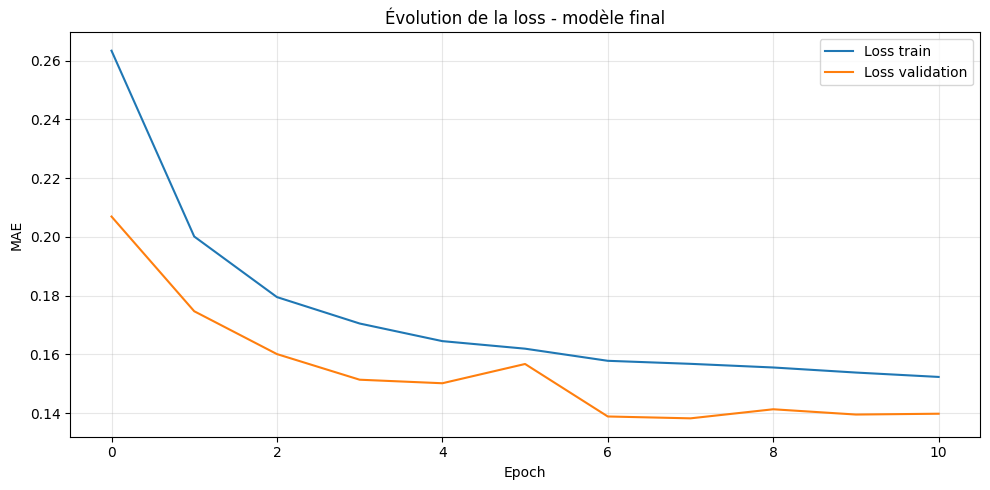

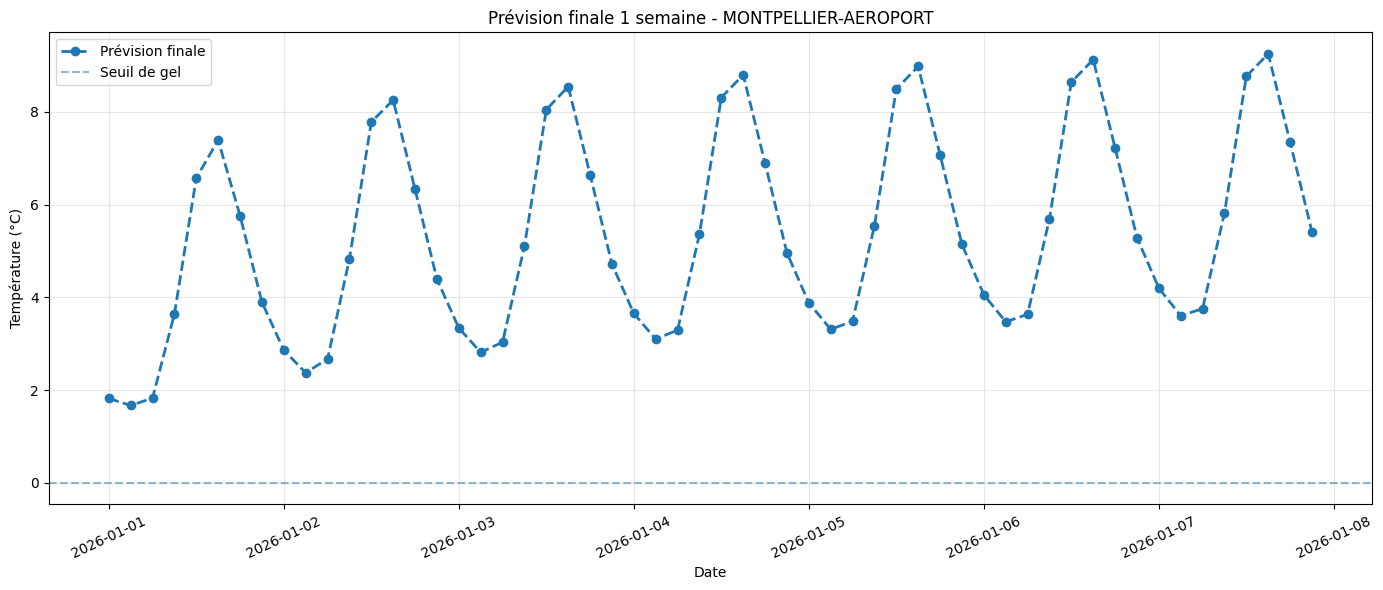

In [15]:
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# 1. CHARGEMENT DES FICHIERS CSV
# =========================
files = sorted(glob.glob("synop_*.csv"))

print(f"Fichiers trouvés : {len(files)}")

if len(files) == 0:
    raise ValueError("Aucun fichier synop_*.csv trouvé dans le dossier.")

cols = [
    "validity_time",
    "t",
    "u",
    "pres",
    "name"
]

df_list = []

for f in files:
    print(f"Chargement de {f}...")
    try:
        tmp = pd.read_csv(
            f,
            sep=None,
            engine="python",
            usecols=cols
        )
        df_list.append(tmp)
    except Exception as e:
        print(f"Impossible de lire {f} : {e}")

if len(df_list) == 0:
    raise ValueError("Aucun fichier n'a pu être chargé correctement.")

df_raw = pd.concat(df_list, ignore_index=True)

print("\nColonnes détectées :")
print(df_raw.columns.tolist())

# =========================
# 2. PRÉPARATION DES DONNÉES
# =========================
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["validity_time"], utc=True, errors="coerce")

target = "MONTPELLIER-AEROPORT"
df = df[df["name"] == target].copy()

if df.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target}.")

df = df.drop_duplicates(subset="ds").sort_values("ds").copy()

df["y"] = pd.to_numeric(df["t"], errors="coerce") - 273.15
df["u"] = pd.to_numeric(df["u"], errors="coerce")
df["pres"] = pd.to_numeric(df["pres"], errors="coerce") / 100

df = df.dropna(subset=["ds"]).copy()

print("\nAperçu des données préparées :")
print(df.head())

print("\nTaille après filtrage station :", df.shape)

if df.empty:
    raise ValueError("Le DataFrame est vide après préparation.")

# =========================
# 3. FEATURES CIRCULAIRES
# =========================
df["hour_sin"] = np.sin(2 * np.pi * df["ds"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["ds"].dt.hour / 24)
df["day_sin"] = np.sin(2 * np.pi * df["ds"].dt.dayofyear / 365.25)
df["day_cos"] = np.cos(2 * np.pi * df["ds"].dt.dayofyear / 365.25)

# Mise en index + interpolation
df = df.set_index("ds")[[
    "y",
    "u",
    "pres",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]].copy()

df = df.interpolate(method="linear").bfill()
df = df.resample("3h").interpolate(method="linear")

print("\nAperçu après interpolation / resampling :")
print(df.head())

if df.empty:
    raise ValueError("Le DataFrame est vide après interpolation / resampling.")

# =========================
# 4. DÉFINITION DES FEATURES
# =========================
features = [
    "y",
    "u",
    "pres",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

df = df.dropna(subset=features).copy()

print("\nVariables utilisées :")
print(features)

if df.empty:
    raise ValueError("Aucune donnée valide restante après nettoyage final.")

# =========================
# 5. NORMALISATION
# =========================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

print("\nNormalisation StandardScaler effectuée.")

# =========================
# 6. CRÉATION DES SÉQUENCES
# =========================
X = []
y = []

in_len = 56  # 1 semaine de contexte

for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i + in_len])
    y.append(scaled_data[i + in_len, 0])

X = np.array(X)
y = np.array(y)

print("\nShape X :", X.shape)
print("Shape y :", y.shape)

if len(X) == 0 or len(y) == 0:
    raise ValueError("Aucune séquence générée. Il faut plus de données ou réduire in_len.")

# =========================
# 7. CONSTRUCTION DU MODÈLE
# =========================
model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mae"
)

print("\nArchitecture du modèle prête.")

# =========================
# 8. ENTRAÎNEMENT
# =========================
print("\nEntraînement du modèle...")

history = model.fit(
    X,
    y,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

print("\nModèle entraîné avec succès.")

# =========================
# 9. PRÉPARATION DE LA FENÊTRE FINALE
# =========================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz="UTC")

past_data = scaled_data[df.index <= cutoff]

if len(past_data) < in_len:
    raise ValueError(
        f"Pas assez de données avant le cutoff pour construire une fenêtre de {in_len} pas."
    )

current_window = past_data[-in_len:].copy()

print("\nFenêtre initiale prête.")
print("Shape current_window :", current_window.shape)

# =========================
# 10. PRÉDICTION RÉCURSIVE
# =========================
final_forecast = []

print("\nCalcul de la trajectoire thermique...")

for i in range(56):
    pred_scaled = model.predict(
        current_window.reshape(1, in_len, len(features)),
        verbose=0
    )[0, 0]

    # dénormalisation de la température
    temp_c = (pred_scaled * scaler.scale_[0]) + scaler.mean_[0]
    final_forecast.append(temp_c)

    future_date = cutoff + pd.Timedelta(hours=3 * (i + 1))

    new_features = [
        pred_scaled,
        current_window[-1, 1],  # humidité conservée
        current_window[-1, 2],  # pression conservée
        np.sin(2 * np.pi * future_date.hour / 24),
        np.cos(2 * np.pi * future_date.hour / 24),
        np.sin(2 * np.pi * future_date.dayofyear / 365.25),
        np.cos(2 * np.pi * future_date.dayofyear / 365.25)
    ]

    current_window = np.vstack([current_window[1:], new_features])

print("\nNombre de prédictions générées :", len(final_forecast))
print("Aperçu des températures prédites :")
print(final_forecast[:10])

# =========================
# 11. CONSTRUCTION DES DATES FUTURES
# =========================
future_dates = pd.date_range(
    start=cutoff + pd.Timedelta(hours=3),
    periods=56,
    freq="3h",
    tz="UTC"
)

df_res = pd.DataFrame({
    "ds": future_dates,
    "y_pred": final_forecast
})

print("\nPrévisions finales :")
print(df_res.head(20))

# =========================
# 12. EXPORTS
# =========================
df_res.to_csv("forecast_final.csv", index=False)
model.save("modele_lstm_final.keras")

print("\nFichiers sauvegardés avec succès :")
print("- forecast_final.csv")
print("- modele_lstm_final.keras")

# =========================
# 13. COURBE DE PERTE
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Loss train")
plt.plot(history.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss - modèle final")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 14. VISUALISATION DES PRÉVISIONS
# =========================
plt.figure(figsize=(14, 6))

plt.plot(
    df_res["ds"],
    df_res["y_pred"],
    "--o",
    label="Prévision finale",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Prévision finale 1 semaine - {target}")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

même modèle mais pour prédire 2 semaines:

In [16]:
import pandas as pd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# 1. CHARGEMENT ET PRÉPARATION
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Features Circulaires
df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df.ds.dt.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.ds.dt.dayofyear / 365.25)

df = df.set_index('ds')[['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].interpolate().bfill()
df = df.resample('3h').interpolate()

# 2. ENTRAÎNEMENT
features = ['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

X, y = [], []
in_len = 80 # On augmente un peu le regard en arrière (10 jours) pour stabiliser les 14 jours futurs
for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i+in_len])
    y.append(scaled_data[i+in_len, 0])

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')
print("🚀 Entraînement pour l'horizon 14 jours...")
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])

# 3. PRÉDICTION RÉCURSIVE (112 POINTS / 2 SEMAINES)
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
current_window = scaled_data[df.index <= cutoff][-in_len:]
final_forecast = []

# Paramètres de dé-scaling rapides
mean_y = scaler.mean_[0]
scale_y = scaler.scale_[0]

print("🔄 Calcul de la trajectoire sur 2 semaines...")
for i in range(112): # 14 jours * 8 points/jour
    pred_scaled = model.predict(current_window.reshape(1, in_len, len(features)), verbose=0)[0, 0]

    # Stockage de la température réelle
    temp_c = (pred_scaled * scale_y) + mean_y
    final_forecast.append(temp_c)

    # Calcul des features temporelles pour le point futur
    future_date = cutoff + pd.Timedelta(hours=3*(i+1))

    # On assemble le vecteur d'entrée pour l'étape suivante
    new_features = [
        pred_scaled,
        current_window[-1, 1], # Humidité (stagnante ou pourrait être une moyenne)
        current_window[-1, 2], # Pression
        np.sin(2 * np.pi * future_date.hour / 24),
        np.cos(2 * np.pi * future_date.hour / 24),
        np.sin(2 * np.pi * future_date.dayofyear / 365.25),
        np.cos(2 * np.pi * future_date.dayofyear / 365.25)
    ]
    current_window = np.vstack([current_window[1:], new_features])

# 4. EXPORT
dates_2w = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=112, freq='3h')
pd.DataFrame({'ds': dates_2w, 'y_pred': final_forecast}).to_csv("forecast_2_weeks.csv", index=False)
print("✅ Prédiction 14 jours exportée dans 'forecast_2_weeks.csv'")

🚀 Entraînement pour l'horizon 14 jours...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 55s 148ms/step - loss: 0.2606 - val_loss: 0.1985
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - loss: 0.1993 - val_loss: 0.1806
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 59s 171ms/step - loss: 0.1817 - val_loss: 0.1746
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 93s 204ms/step - loss: 0.1734 - val_loss: 0.1496
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 102s 263ms/step - loss: 0.1635 - val_loss: 0.1477
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 72s 209ms/step - loss: 0.1611 - val_loss: 0.1487
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - loss: 0.1564 - val_loss: 0.1548
Epoch 8/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 92s 245ms/step - loss: 0.1552 - val_loss: 0.1481
Epoch 9/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 117s 173ms/step - loss: 0.1549 - val_loss: 0.1370
Epoch 10/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 85s 246ms/step - loss: 0.1530 - val_loss: 0.1397
Epoch 11/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 92s 265ms/step - loss: 0

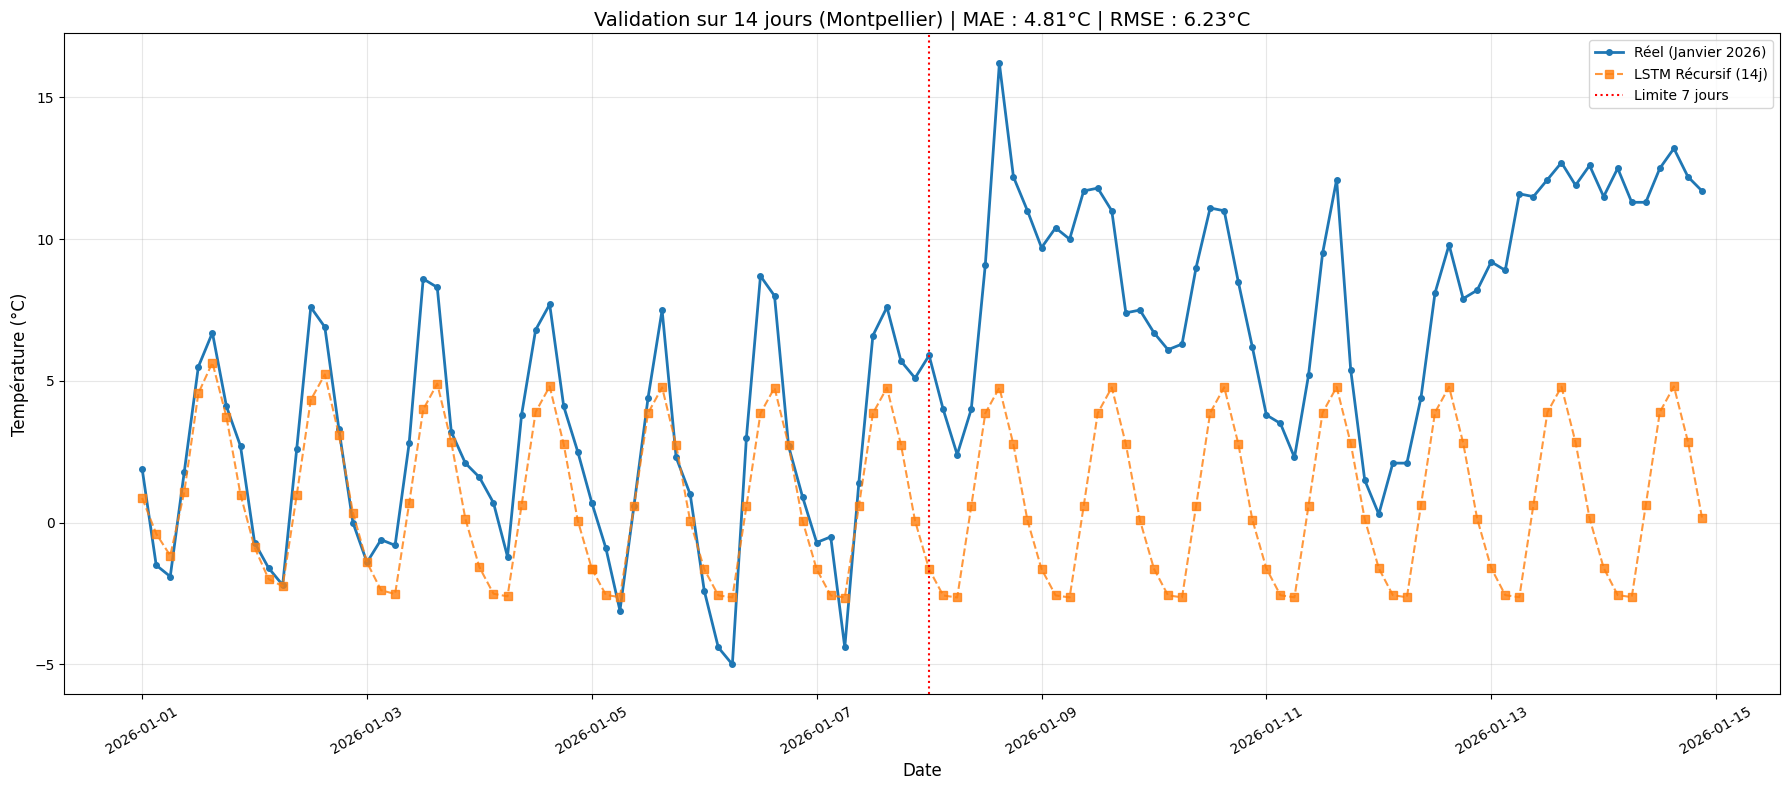

📊 RÉSULTATS 2 SEMAINES
MAE  : 4.81 °C
RMSE : 6.23 °C


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement des données (Prévues vs Réelles)
try:
    df_pred = pd.read_csv("forecast_2_weeks.csv")
    df_real = pd.read_csv("synop_2026.csv", sep=";") # Assure-toi que ce fichier contient bien les 15 premiers jours de janv
except FileNotFoundError:
    print("Erreur : Assure-toi que 'forecast_2_weeks.csv' et 'synop_2026.csv' sont dans le dossier.")

# 2. Nettoyage et conversion
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)

# Conversion Kelvin vers Celsius
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# 3. Fusion pour aligner les dates
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    # Calcul des métriques sur les 14 jours
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    # 4. Visualisation
    plt.figure(figsize=(18, 8))

    # Courbes
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Janvier 2026)', color='#1f77b4', lw=2, markersize=4)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Récursif (14j)', color='#ff7f0e', alpha=0.8)

    # Ligne de séparation 1ère / 2ème semaine
    sep_date = df_compare['ds'].iloc[0] + pd.Timedelta(days=7)
    plt.axvline(x=sep_date, color='red', linestyle=':', label='Limite 7 jours')

    # Style
    plt.title(f"Validation sur 14 jours (Montpellier) | MAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C", fontsize=14)
    plt.ylabel("Température (°C)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

    print(f"📊 RÉSULTATS 2 SEMAINES")
    print(f"MAE  : {mae:.2f} °C")
    print(f"RMSE : {rmse:.2f} °C")
else:
    print("❌ Aucune donnée commune trouvée. Vérifie que 'synop_2026.csv' couvre bien jusqu'au 14 Janvier.")

Sur 14 jours, on observe clairement les limites du modèle LSTM récursif.

Avant ~5 jours :  
Le modèle suit relativement bien les variations (bonne phase et tendance).

Après ~5 jours (ligne rouge) :  
Divergence progressive très nette.

Le modèle “décroche” :
- Il sous-estime fortement les températures
- Il perd la tendance réelle (qui monte fortement)
- Il reste bloqué dans une dynamique oscillante artificielle

Les cycles deviennent mécaniques → le modèle répète un pattern appris au lieu de s’adapter aux nouvelles conditions.

Conclusion :  
Le LSTM récursif fonctionne uniquement à court terme (~3–5 jours).  
Au-delà, accumulation d’erreurs + perte d’information → prévisions non fiables.

Modification du modèle précedent en predisant le résidu, ajout d'un coef de rappel mathématique, on intégre la tendance de la temperature

In [27]:
import pandas as pd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# 1. CHARGEMENT ET PRÉPARATION (Incluant début Janvier 2026)
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Features temporelles
df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df.ds.dt.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.ds.dt.dayofyear / 365.25)

# Tendance et Résidu pour la stabilité à long terme
df['trend'] = df['y'].rolling(window=8, min_periods=1, center=True).mean()
df['residue'] = df['y'] - df['trend']

df = df.set_index('ds')[['residue', 'trend', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].interpolate().bfill()
df = df.resample('3h').interpolate()

# 2. ENTRAÎNEMENT
features = ['residue', 'trend', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

X, y = [], []
in_len = 80
for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i+in_len])
    y.append(scaled_data[i+in_len, 0]) # On prédit le résidu (la vibration)

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')
print("🚀 Entraînement sur les cycles thermiques...")
model.fit(X, y, epochs=15, batch_size=32, verbose=1, callbacks=[EarlyStopping(patience=3)])

# 3. PRÉDICTION RÉCURSIVE : SEMAINES 2 & 3
# On déplace le cutoff au 7 Janvier 2026 à 21h pour prédire la suite
cutoff = pd.Timestamp("2026-01-07 21:00:00", tz='UTC')

# Trouver l'indice de départ dans les données scalées
idx_cutoff = df.index.get_indexer([cutoff], method='pad')[0]
current_window = scaled_data[idx_cutoff - in_len + 1 : idx_cutoff + 1]
last_trend = df.iloc[idx_cutoff]['trend']

final_forecast = []
res_mean, res_scale = scaler.mean_[0], scaler.scale_[0]
trend_mean, trend_scale = scaler.mean_[1], scaler.scale_[1]

print(f"🔄 Prédiction du 08/01 au 21/01 à partir du point : {df.index[idx_cutoff]}")

for i in range(112): # 14 jours
    pred_res_scaled = model.predict(current_window.reshape(1, in_len, len(features)), verbose=0)[0, 0]
    pred_res = (pred_res_scaled * res_scale) + res_mean

    # Évolution de la tendance : retour très lent vers 8°C (normale Montpellier)
    last_trend = last_trend * 0.99 + 8.0 * 0.01

    temp_final = last_trend + pred_res
    final_forecast.append(temp_final)

    # Date future pour les features temporelles
    f_date = cutoff + pd.Timedelta(hours=3*(i+1))

    # Mise à jour de la fenêtre
    new_entry = [
        pred_res_scaled,
        (last_trend - trend_mean) / trend_scale,
        current_window[-1, 2], # Humidité
        current_window[-1, 3], # Pression
        np.sin(2 * np.pi * f_date.hour / 24),
        np.cos(2 * np.pi * f_date.hour / 24),
        np.sin(2 * np.pi * f_date.dayofyear / 365.25),
        np.cos(2 * np.pi * f_date.dayofyear / 365.25)
    ]
    current_window = np.vstack([current_window[1:], new_entry])

# 4. EXPORT
dates_future = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=112, freq='3h')
pd.DataFrame({'ds': dates_future, 'y_pred': final_forecast}).to_csv("forecast_janvier_sem2_3.csv", index=False)
print("✅ Fichier 'forecast_janvier_sem2_3.csv' généré.")

🚀 Entraînement sur les cycles thermiques...
Epoch 1/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 80s 197ms/step - loss: 0.4101
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 83s 199ms/step - loss: 0.3188
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - loss: 0.3011
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 52s 135ms/step - loss: 0.2927
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 53s 137ms/step - loss: 0.2837
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 80s 132ms/step - loss: 0.2797
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 52s 136ms/step - loss: 0.2758
Epoch 8/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - loss: 0.2724
Epoch 9/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 83s 135ms/step - loss: 0.2692
Epoch 10/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 55s 143ms/step - loss: 0.2660
Epoch 11/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - loss: 0.2640
Epoch 12/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 53s 138ms/step - loss: 0.2610
Epoch 13/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - loss: 0.2576
Epoch 14/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 8

Fichier prédictions : forecast_janvier_sem2_3.csv
Fichier réel        : synop_2026.csv
Station cible       : MONTPELLIER-AEROPORT

Les fichiers ont bien été trouvés.

Aperçu des prédictions :
                         ds    y_pred
0 2026-01-08 00:00:00+00:00  3.986506
1 2026-01-08 03:00:00+00:00  2.943559
2 2026-01-08 06:00:00+00:00  2.283545
3 2026-01-08 09:00:00+00:00  3.716147
4 2026-01-08 12:00:00+00:00  5.993563

Aperçu des données réelles :
           lat       lon  geo_id_wmo     geo_id_wigos  \
0    50.732500  1.599667        7002  0-20000-0-07002   
121  43.385000 -0.416333        7610  0-20000-0-07610   
122  43.188000  0.000000        7621  0-20000-0-07621   
123  43.689000  0.601167        7622  0-20000-0-07622   
124  43.005333  1.106833        7627  0-20000-0-07627   

                        name        reference_time           insert_time  \
0               BOULOGNE-SEM  2026-01-01T00:10:06Z  2026-01-01T00:02:31Z   
121                PAU-UZEIN  2026-01-01T00:10:06Z  202

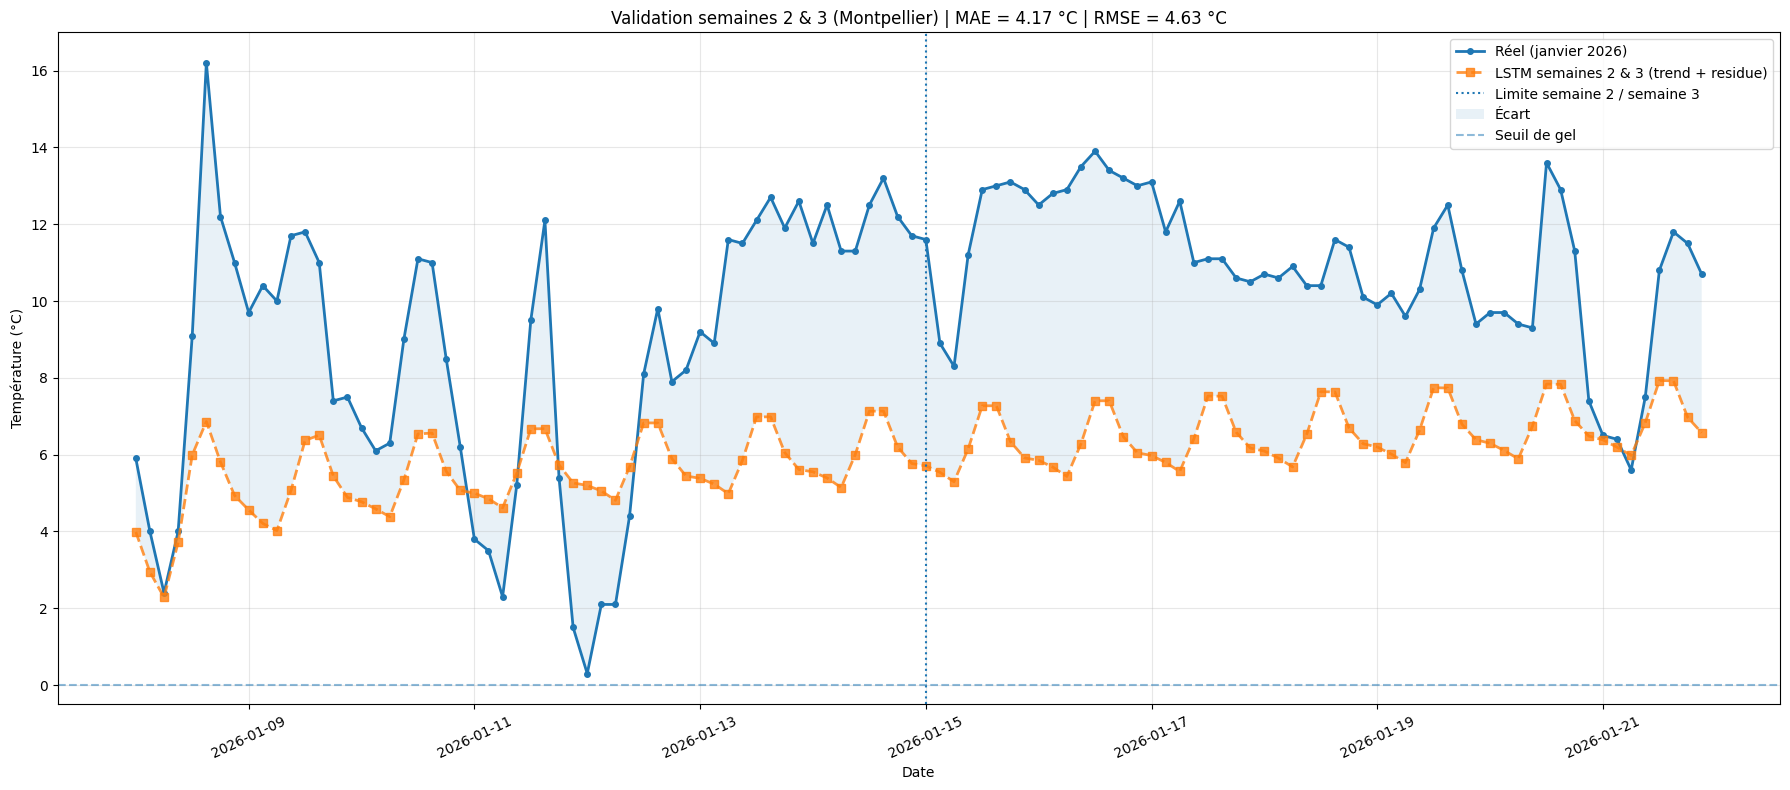


Semaine 2 :
MAE  = 3.90 °C
RMSE = 4.46 °C

Semaine 3 :
MAE  = 4.43 °C
RMSE = 4.79 °C

Analyse du minimum thermique :
Minimum réel   : 0.30 °C
Minimum prédit : 2.28 °C
Écart absolu   : 1.98 °C


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. CONFIGURATION DES FICHIERS
# =========================
file_pred = "forecast_janvier_sem2_3.csv"
file_real = "synop_2026.csv"
target = "MONTPELLIER-AEROPORT"

print("Fichier prédictions :", file_pred)
print("Fichier réel        :", file_real)
print("Station cible       :", target)

# =========================
# 2. VÉRIFICATION DES FICHIERS
# =========================
if not os.path.exists(file_pred):
    raise FileNotFoundError(
        f"Le fichier '{file_pred}' est introuvable."
    )

if not os.path.exists(file_real):
    raise FileNotFoundError(
        f"Le fichier '{file_real}' est introuvable."
    )

print("\nLes fichiers ont bien été trouvés.")

# =========================
# 3. CHARGEMENT DES PRÉDICTIONS
# =========================
df_pred = pd.read_csv(file_pred)

if df_pred.empty:
    raise ValueError("Le fichier de prédictions est vide.")

required_pred_cols = ["ds", "y_pred"]
missing_pred_cols = [col for col in required_pred_cols if col not in df_pred.columns]

if missing_pred_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier de prédictions : {missing_pred_cols}")

df_pred["ds"] = pd.to_datetime(df_pred["ds"], utc=True, errors="coerce")
df_pred["y_pred"] = pd.to_numeric(df_pred["y_pred"], errors="coerce")

df_pred = df_pred.dropna(subset=["ds", "y_pred"]).copy()
df_pred = df_pred.sort_values("ds").copy()

print("\nAperçu des prédictions :")
print(df_pred.head())

# =========================
# 4. CHARGEMENT DES DONNÉES RÉELLES
# =========================
try:
    df_real_raw = pd.read_csv(file_real, sep=";")
except Exception:
    df_real_raw = pd.read_csv(file_real, sep=None, engine="python")

if df_real_raw.empty:
    raise ValueError("Le fichier réel est vide.")

required_real_cols = ["name", "validity_time", "t"]
missing_real_cols = [col for col in required_real_cols if col not in df_real_raw.columns]

if missing_real_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier réel : {missing_real_cols}")

df_real_raw["ds"] = pd.to_datetime(df_real_raw["validity_time"], utc=True, errors="coerce")
df_real_raw["y_real"] = pd.to_numeric(df_real_raw["t"], errors="coerce") - 273.15

df_real_raw = df_real_raw.dropna(subset=["name", "ds", "y_real"]).copy()
df_real_raw = df_real_raw.sort_values("ds").copy()

print("\nAperçu des données réelles :")
print(df_real_raw.head())

# =========================
# 5. FILTRAGE SUR LA STATION CIBLE
# =========================
df_real = df_real_raw[df_real_raw["name"] == target].copy()

if df_real.empty:
    raise ValueError(f"Aucune donnée trouvée pour la station {target} dans le fichier réel.")

print(f"\nNombre de lignes réelles pour {target} :", len(df_real))

# =========================
# 6. ALIGNEMENT DES DONNÉES
# =========================
df_compare = pd.merge(
    df_pred[["ds", "y_pred"]],
    df_real[["ds", "y_real"]],
    on="ds",
    how="inner"
).sort_values("ds").copy()

df_compare = df_compare.dropna(subset=["ds", "y_pred", "y_real"]).copy()

if df_compare.empty:
    raise ValueError(
        "Aucune donnée commune trouvée. Vérifie que 'synop_2026.csv' contient bien les données après le 08/01/2026."
    )

print("\nAperçu de la comparaison :")
print(df_compare.head())

# =========================
# 7. CALCUL DES MÉTRIQUES
# =========================
mae = mean_absolute_error(df_compare["y_real"], df_compare["y_pred"])
mse = mean_squared_error(df_compare["y_real"], df_compare["y_pred"])
rmse = np.sqrt(mse)

print(f"\n📊 RÉSULTATS SEMAINES 2 & 3 - {target}")
print("=" * 55)
print(f"Période : du {df_compare['ds'].min()} au {df_compare['ds'].max()}")
print(f"MAE  : {mae:.2f} °C")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f} °C")
print("=" * 55)

# =========================
# 8. TABLEAU DE COMPARAISON
# =========================
res = pd.DataFrame({
    "Date": df_compare["ds"].dt.strftime("%Y-%m-%d %H:%M"),
    "Réel": np.round(df_compare["y_real"].values, 2),
    "Prédit": np.round(df_compare["y_pred"].values, 2),
    "Écart": np.round(df_compare["y_pred"].values - df_compare["y_real"].values, 2)
})

print("\nComparaison réel / prédit :")
print(res.to_string(index=False))

# =========================
# 9. EXPORT CSV
# =========================
df_export = df_compare.copy()
df_export["ecart"] = df_export["y_pred"] - df_export["y_real"]

df_export.to_csv("comparaison_semaines_2_3_vs_reel_2026.csv", index=False)

print("\nFichier 'comparaison_semaines_2_3_vs_reel_2026.csv' exporté avec succès.")

# =========================
# 10. GRAPHIQUE
# =========================
plt.figure(figsize=(18, 8))

plt.plot(
    df_compare["ds"],
    df_compare["y_real"],
    "o-",
    label="Réel (janvier 2026)",
    linewidth=2,
    markersize=4
)

plt.plot(
    df_compare["ds"],
    df_compare["y_pred"],
    "s--",
    label="LSTM semaines 2 & 3 (trend + residue)",
    linewidth=2,
    alpha=0.8
)

sep_date = df_compare["ds"].iloc[0] + pd.Timedelta(days=7)

plt.axvline(
    x=sep_date,
    linestyle=":",
    label="Limite semaine 2 / semaine 3"
)

plt.fill_between(
    df_compare["ds"],
    df_compare["y_real"],
    df_compare["y_pred"],
    alpha=0.1,
    label="Écart"
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5,
    label="Seuil de gel"
)

plt.title(f"Validation semaines 2 & 3 (Montpellier) | MAE = {mae:.2f} °C | RMSE = {rmse:.2f} °C")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================
# 11. MÉTRIQUES PAR SEMAINE
# =========================
df_compare["periode"] = np.where(df_compare["ds"] < sep_date, "Semaine 2", "Semaine 3")

for periode in ["Semaine 2", "Semaine 3"]:
    sub = df_compare[df_compare["periode"] == periode].copy()

    if not sub.empty:
        mae_sub = mean_absolute_error(sub["y_real"], sub["y_pred"])
        rmse_sub = np.sqrt(mean_squared_error(sub["y_real"], sub["y_pred"]))

        print(f"\n{periode} :")
        print(f"MAE  = {mae_sub:.2f} °C")
        print(f"RMSE = {rmse_sub:.2f} °C")

# =========================
# 12. ANALYSE DU MINIMUM
# =========================
real_min = df_compare["y_real"].min()
pred_min = df_compare["y_pred"].min()

print("\nAnalyse du minimum thermique :")
print(f"Minimum réel   : {real_min:.2f} °C")
print(f"Minimum prédit : {pred_min:.2f} °C")
print(f"Écart absolu   : {abs(real_min - pred_min):.2f} °C")

Sur les semaines 2 et 3, le modèle montre un comportement intermédiaire.

Performance correcte mais dégradée :
- Semaine 2 → RMSE ≈ 4.46°C
- Semaine 3 → RMSE ≈ 4.79°C

Dégradation progressive :
- Les erreurs augmentent légèrement avec l’horizon
- Signature classique d’un modèle temporel qui dérive

Le modèle capte bien :
- La tendance globale
- La saisonnalité (cycles réguliers)

Mais limites importantes :
- Sous-estimation des pics et surestimation des creux
- Lissage des extrêmes (min réel 0.3°C vs 2.28°C prédit)
- Variabilité réelle mal reproduite

Le signal prédit reste “trop propre” :
→ manque de bruit réel / dynamique météo

Conclusion :  
Le modèle reste exploitable à moyen terme, mais avec perte de précision et incapacité à capturer les extrêmes.

# Conclusion

Après avoir évalué les différents modèles afin de comparer leurs performances, nous avons sélectionné ceux offrant les meilleurs résultats pour notre application au planning agricole de prédiction de la température.

Le modèle LSTM, issu du deep learning, a été retenu pour les prévisions journalières grâce à ses bonnes performances à court terme.

Pour les horizons plus longs, les modèles SARIMA hebdomadaires et mensuels se sont révélés les plus adaptés, en raison de leur stabilité et de leur capacité à capturer la tendance et la saisonnalité.